In [ ]:
# ============================================================
# CELDA 1 — Configuración del entorno y reproducibilidad
# Google Colab
# ============================================================

import os
import sys
import random
import platform
import warnings
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow se utilizará posteriormente para LSTM y GRU
import tensorflow as tf


# ------------------------------------------------------------
# 1. Reproducibilidad
# ------------------------------------------------------------

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# ------------------------------------------------------------
# 2. Configuración de advertencias y visualización
# ------------------------------------------------------------

warnings.resetwarnings()
warnings.simplefilter("default")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# ------------------------------------------------------------
# 3. Carpetas de trabajo en Colab
# ------------------------------------------------------------

BASE_DIR = Path("/content")
OUTPUT_DIR = BASE_DIR / "salidas_la_oca"
FIGURES_DIR = OUTPUT_DIR / "figuras"
TABLES_DIR = OUTPUT_DIR / "tablas"
MODELS_DIR = OUTPUT_DIR / "modelos"
DATASETS_DIR = OUTPUT_DIR / "datasets"

for carpeta in [
    OUTPUT_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    MODELS_DIR,
    DATASETS_DIR,
]:
    carpeta.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 4. Función para consultar versiones instaladas
# ------------------------------------------------------------

def obtener_version(paquete):
    try:
        return version(paquete)
    except PackageNotFoundError:
        return "NO INSTALADO"


paquetes = [
    "numpy",
    "pandas",
    "matplotlib",
    "scikit-learn",
    "statsmodels",
    "xgboost",
    "tensorflow",
    "pyarrow",
]

versiones = pd.DataFrame({
    "Componente": [
        "Python",
        "Sistema operativo",
        *paquetes,
    ],
    "Versión": [
        sys.version.split()[0],
        f"{platform.system()} {platform.release()}",
        *[obtener_version(paquete) for paquete in paquetes],
    ],
})


# ------------------------------------------------------------
# 5. Información de GPU
# ------------------------------------------------------------

gpus = tf.config.list_physical_devices("GPU")

print("=" * 70)
print("ENTORNO CONFIGURADO")
print("=" * 70)

print(f"\nDirectorio base: {BASE_DIR}")
print(f"Directorio de resultados: {OUTPUT_DIR}")
print(f"Semilla aleatoria: {SEED}")

print("\nVersiones instaladas:")
display(versiones)

print("\nDispositivos GPU detectados:")
if gpus:
    for gpu in gpus:
        print(f"- {gpu.name}")
else:
    print("- No se detectó GPU.")
    print("- Para LSTM y GRU puedes activarla en:")
    print("  Entorno de ejecución > Cambiar tipo de entorno de ejecución > T4 GPU")

print("\nCarpetas creadas:")
for carpeta in [
    FIGURES_DIR,
    TABLES_DIR,
    MODELS_DIR,
    DATASETS_DIR,
]:
    print(f"- {carpeta}")

print("\nConfiguración inicial completada correctamente.")

ENTORNO CONFIGURADO

Directorio base: /content
Directorio de resultados: /content/salidas_la_oca
Semilla aleatoria: 42

Versiones instaladas:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Componente,Versión
0,Python,3.12.13
1,Sistema operativo,Linux 6.6.122+
2,numpy,2.0.2
3,pandas,2.2.2
4,matplotlib,3.10.0
5,scikit-learn,1.6.1
6,statsmodels,0.14.6
7,xgboost,3.3.0
8,tensorflow,2.20.0
9,pyarrow,18.1.0



Dispositivos GPU detectados:
- No se detectó GPU.
- Para LSTM y GRU puedes activarla en:
  Entorno de ejecución > Cambiar tipo de entorno de ejecución > T4 GPU

Carpetas creadas:
- /content/salidas_la_oca/figuras
- /content/salidas_la_oca/tablas
- /content/salidas_la_oca/modelos
- /content/salidas_la_oca/datasets

Configuración inicial completada correctamente.


In [ ]:
# ============================================================
# CELDA 2 — Carga y verificación estructural de los datos
# ============================================================

SN1007_FILE = Path("/content/sn_1007_anomalias_detalle_nov.csv")
SP108_FILE  = Path("/content/sp_108_anomalias_detalle.csv")


def cargar_y_verificar_csv(ruta, nombre_sensor):
    """
    Carga el CSV sin realizar limpieza ni eliminar anomalías.
    Solo verifica estructura, columnas, fechas y parseo básico.
    """

    print("\n" + "=" * 75)
    print(f"{nombre_sensor}")
    print("=" * 75)

    # --------------------------------------------------------
    # 1. Verificar existencia
    # --------------------------------------------------------
    if not ruta.exists():
        raise FileNotFoundError(
            f"No se encontró el archivo:\n{ruta}\n\n"
            "Verifica que haya sido cargado directamente en /content."
        )

    tamano_mb = ruta.stat().st_size / (1024 ** 2)

    print(f"Archivo: {ruta.name}")
    print(f"Tamaño: {tamano_mb:.2f} MB")

    # --------------------------------------------------------
    # 2. Carga
    # --------------------------------------------------------
    df = pd.read_csv(ruta, low_memory=False)

    print(f"Filas: {len(df):,}")
    print(f"Columnas: {df.shape[1]}")

    print("\nColumnas encontradas:")
    print(list(df.columns))

    # --------------------------------------------------------
    # 3. Verificar columna temporal
    # --------------------------------------------------------
    if "fecha" not in df.columns:
        raise ValueError(
            f"{nombre_sensor}: no se encontró la columna 'fecha'."
        )

    # Conservamos 'fecha' original y creamos una columna estándar
    df["timestamp"] = pd.to_datetime(
        df["fecha"],
        errors="coerce",
        utc=True
    )

    fechas_invalidas = df["timestamp"].isna().sum()

    print("\nRango temporal:")
    print(f"Inicio : {df['timestamp'].min()}")
    print(f"Fin    : {df['timestamp'].max()}")
    print(f"Fechas que no pudieron interpretarse: {fechas_invalidas:,}")

    # --------------------------------------------------------
    # 4. Verificación temporal básica
    # --------------------------------------------------------
    duplicados_timestamp = df["timestamp"].duplicated().sum()

    print("\nConsistencia temporal:")
    print(f"Timestamps duplicados: {duplicados_timestamp:,}")
    print(
        "Orden cronológico original:",
        "Sí" if df["timestamp"].is_monotonic_increasing else "No"
    )

    # --------------------------------------------------------
    # 5. Tipos de datos
    # --------------------------------------------------------
    print("\nTipos de datos:")
    display(
        pd.DataFrame({
            "columna": df.columns,
            "dtype": [str(df[c].dtype) for c in df.columns]
        })
    )

    # --------------------------------------------------------
    # 6. Valores ausentes
    # --------------------------------------------------------
    nulos = df.isna().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=False)

    print("\nValores NaN dentro de las filas:")

    if len(nulos) == 0:
        print("No se encontraron valores NaN.")
    else:
        display(
            pd.DataFrame({
                "NaN": nulos,
                "Porcentaje": (nulos / len(df) * 100).round(4)
            })
        )

    # --------------------------------------------------------
    # 7. Muestra de registros
    # --------------------------------------------------------
    print("\nPrimeros 5 registros:")
    display(df.head())

    print("\nÚltimos 5 registros:")
    display(df.tail())

    return df


# ============================================================
# Cargar ambos sensores
# ============================================================

sn1007_raw = cargar_y_verificar_csv(
    SN1007_FILE,
    "SN_1007 — Sensor de nivel"
)

sp108_raw = cargar_y_verificar_csv(
    SP108_FILE,
    "SP_108 — Pluviómetro"
)


print("\n" + "=" * 75)
print("CARGA COMPLETADA")
print("=" * 75)

print(f"SN_1007: {sn1007_raw.shape}")
print(f"SP_108 : {sp108_raw.shape}")


SN_1007 — Sensor de nivel
Archivo: sn_1007_anomalias_detalle_nov.csv
Tamaño: 30.06 MB
Filas: 296,970
Columnas: 17

Columnas encontradas:
['fecha', 'muestra', 'nivel', 'caudal', 'calidad', 'categoria', 'z_score', 'score_compuesto', 'anomalia_if', 'anomalia_lof', 'anomalia_svm', 'anomalia_z3', 'anomalia_mad', 'anomalia_spike', 'anomalia_ewma', 'num_metodos', 'anomalia_final']

Rango temporal:
Inicio : 2025-11-10 07:02:00+00:00
Fin    : 2026-06-10 20:37:00+00:00
Fechas que no pudieron interpretarse: 0

Consistencia temporal:
Timestamps duplicados: 0
Orden cronológico original: Sí

Tipos de datos:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,columna,dtype
0,fecha,object
1,muestra,float64
2,nivel,float64
3,caudal,float64
4,calidad,int64
5,categoria,object
6,z_score,float64
7,score_compuesto,float64
8,anomalia_if,int64
9,anomalia_lof,int64



Valores NaN dentro de las filas:
No se encontraron valores NaN.

Primeros 5 registros:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

,fecha,muestra,calidad,z_score,score_compuesto,anomalia_if,anomalia_lof,anomalia_svm,anomalia_z3,anomalia_mad,anomalia_spike,anomalia_ewma,anomalia_alto_valor,num_metodos,anomalia_final,timestamp
0,2025-06-16T12:11:00Z,0.0000,1,-0.1135,0.4225,0,0,0,0,0,0,0,0,0,0,2025-06-16 12:11:00+00:00
1,2025-06-16T12:16:00Z,1.2700,1,3.9078,0.3977,0,0,0,1,0,0,1,0,2,1,2025-06-16 12:16:00+00:00
2,2025-06-16T12:21:00Z,0.0000,1,-0.1135,0.3741,1,0,0,0,0,0,0,0,1,0,2025-06-16 12:21:00+00:00
3,2025-06-16T12:26:00Z,0.0000,1,-0.1135,0.4227,0,0,0,0,0,0,0,0,0,0,2025-06-16 12:26:00+00:00
4,2025-06-16T12:31:00Z,0.0000,1,-0.1135,0.4127,0,0,0,0,0,0,0,0,0,0,2025-06-16 12:31:00+00:00



Últimos 5 registros:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,fecha,muestra,calidad,z_score,score_compuesto,anomalia_if,anomalia_lof,anomalia_svm,anomalia_z3,anomalia_mad,anomalia_spike,anomalia_ewma,anomalia_alto_valor,num_metodos,anomalia_final,timestamp
96933,2026-06-10T19:32:00Z,0.0000,1,-0.1135,0.5365,0,0,0,0,0,0,0,0,0,0,2026-06-10 19:32:00+00:00
96934,2026-06-10T19:37:00Z,0.0000,1,-0.1135,0.5927,0,0,0,0,0,0,0,0,0,0,2026-06-10 19:37:00+00:00
96935,2026-06-10T19:42:00Z,0.0000,1,-0.1135,0.5971,0,0,0,0,0,0,0,0,0,0,2026-06-10 19:42:00+00:00
96936,2026-06-10T19:47:00Z,0.0000,1,-0.1135,0.5971,0,0,0,0,0,0,0,0,0,0,2026-06-10 19:47:00+00:00
96937,2026-06-10T19:52:00Z,0.0000,1,-0.1135,0.5971,0,0,0,0,0,0,0,0,0,0,2026-06-10 19:52:00+00:00



CARGA COMPLETADA
SN_1007: (296970, 18)
SP_108 : (96938, 16)


In [ ]:
# ============================================================
# CELDA 3 — Auditoría del sensor de nivel SN_1007
# ============================================================

sn = sn1007_raw.copy().sort_values("timestamp").reset_index(drop=True)

print("=" * 75)
print("AUDITORÍA SN_1007 — SENSOR DE NIVEL")
print("=" * 75)


# ------------------------------------------------------------
# 1. Estadísticas básicas de las variables principales
# ------------------------------------------------------------

print("\n1. ESTADÍSTICAS DE MUESTRA, NIVEL Y CAUDAL")

display(
    sn[["muestra", "nivel", "caudal"]]
    .describe()
    .T
    .round(4)
)


# ------------------------------------------------------------
# 2. Comprobar relación muestra + nivel
# ------------------------------------------------------------

sn["suma_muestra_nivel"] = sn["muestra"] + sn["nivel"]

print("\n2. RELACIÓN ENTRE 'muestra' Y 'nivel'")

print(
    f"Valor mínimo de muestra + nivel: "
    f"{sn['suma_muestra_nivel'].min():.6f}"
)

print(
    f"Valor máximo de muestra + nivel: "
    f"{sn['suma_muestra_nivel'].max():.6f}"
)

print(
    f"Promedio de muestra + nivel: "
    f"{sn['suma_muestra_nivel'].mean():.6f}"
)

relacion_642 = np.isclose(
    sn["suma_muestra_nivel"],
    642,
    atol=1e-9
)

print(
    f"Registros donde muestra + nivel = 642: "
    f"{relacion_642.sum():,} de {len(sn):,} "
    f"({relacion_642.mean() * 100:.4f}%)"
)


# ------------------------------------------------------------
# 3. Comprobar si caudal es idéntico al nivel
# ------------------------------------------------------------

caudal_igual_nivel = np.isclose(
    sn["caudal"],
    sn["nivel"],
    atol=1e-9
)

print("\n3. RELACIÓN ENTRE 'caudal' Y 'nivel'")

print(
    f"Registros donde caudal = nivel: "
    f"{caudal_igual_nivel.sum():,} de {len(sn):,} "
    f"({caudal_igual_nivel.mean() * 100:.4f}%)"
)

print(
    f"Diferencia máxima absoluta entre caudal y nivel: "
    f"{np.abs(sn['caudal'] - sn['nivel']).max():.6f}"
)


# ------------------------------------------------------------
# 4. Revisar columna calidad
# ------------------------------------------------------------

print("\n4. VALORES DE LA COLUMNA 'calidad'")

display(
    sn["calidad"]
    .value_counts(dropna=False)
    .rename_axis("calidad")
    .reset_index(name="registros")
)


# ------------------------------------------------------------
# 5. Distribución y límites de las categorías
# ------------------------------------------------------------

print("\n5. CATEGORÍAS DE NIVEL")

resumen_categorias = (
    sn.groupby("categoria", observed=True)
    .agg(
        registros=("nivel", "size"),
        nivel_min=("nivel", "min"),
        nivel_max=("nivel", "max"),
        nivel_promedio=("nivel", "mean")
    )
)

resumen_categorias["porcentaje"] = (
    resumen_categorias["registros"] / len(sn) * 100
)

display(
    resumen_categorias[
        [
            "registros",
            "porcentaje",
            "nivel_min",
            "nivel_max",
            "nivel_promedio"
        ]
    ].round(4)
)


# ------------------------------------------------------------
# 6. Relación categoría vs anomalía final
# ------------------------------------------------------------

print("\n6. ANOMALÍA FINAL SEGÚN CATEGORÍA")

tabla_anomalias = pd.crosstab(
    sn["categoria"],
    sn["anomalia_final"],
    margins=False
)

tabla_anomalias.columns = [
    f"anomalia_final_{c}" for c in tabla_anomalias.columns
]

if "anomalia_final_1" in tabla_anomalias.columns:
    tabla_anomalias["porcentaje_anomalia"] = (
        tabla_anomalias["anomalia_final_1"] /
        tabla_anomalias.sum(axis=1) * 100
    )

display(tabla_anomalias.round(4))


# ------------------------------------------------------------
# 7. Frecuencia temporal observada
# ------------------------------------------------------------

print("\n7. INTERVALOS TEMPORALES ENTRE REGISTROS")

sn["delta_min"] = (
    sn["timestamp"]
    .diff()
    .dt.total_seconds()
    .div(60)
)

frecuencias = (
    sn["delta_min"]
    .value_counts()
    .sort_index()
    .head(15)
    .rename_axis("intervalo_min")
    .reset_index(name="cantidad")
)

display(frecuencias)


# ------------------------------------------------------------
# 8. Identificar vacíos temporales
# ------------------------------------------------------------

gaps_sn = sn.loc[
    sn["delta_min"] > 1,
    ["timestamp", "delta_min"]
].copy()

gaps_sn["inicio_gap"] = (
    sn["timestamp"].shift(1).loc[gaps_sn.index]
)

gaps_sn = gaps_sn[
    ["inicio_gap", "timestamp", "delta_min"]
].rename(
    columns={"timestamp": "fin_gap"}
)

print("\n8. VACÍOS TEMPORALES")

print(f"Cantidad de separaciones > 1 minuto: {len(gaps_sn):,}")

if len(gaps_sn) > 0:
    print(
        f"Mayor separación encontrada: "
        f"{gaps_sn['delta_min'].max():,.1f} minutos"
    )

    print("\n10 mayores separaciones:")
    display(
        gaps_sn
        .sort_values("delta_min", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 9. Distribución general del nivel
# ------------------------------------------------------------

print("\n9. DISTRIBUCIÓN DEL NIVEL")

percentiles = sn["nivel"].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

display(
    percentiles
    .rename("nivel_cm")
    .to_frame()
    .round(2)
)


# ------------------------------------------------------------
# 10. Resumen
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("RESUMEN DE AUDITORÍA SN_1007")
print("=" * 75)

print(f"Registros analizados       : {len(sn):,}")
print(f"Nivel mínimo               : {sn['nivel'].min():.2f} cm")
print(f"Nivel máximo               : {sn['nivel'].max():.2f} cm")
print(f"Nivel promedio             : {sn['nivel'].mean():.2f} cm")
print(f"Separaciones > 1 minuto    : {len(gaps_sn):,}")
print(f"Anomalías finales          : {sn['anomalia_final'].sum():,}")
print(
    f"Porcentaje anomalía final  : "
    f"{sn['anomalia_final'].mean() * 100:.3f}%"
)

AUDITORÍA SN_1007 — SENSOR DE NIVEL

1. ESTADÍSTICAS DE MUESTRA, NIVEL Y CAUDAL


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,count,mean,std,min,25%,50%,75%,max
muestra,"296,970.0000",408.4767,23.9766,229.0000,407.0000,414.0000,421.0000,432.0000
nivel,"296,970.0000",233.5233,23.9766,210.0000,221.0000,228.0000,235.0000,413.0000
caudal,"296,970.0000",233.5233,23.9766,210.0000,221.0000,228.0000,235.0000,413.0000



2. RELACIÓN ENTRE 'muestra' Y 'nivel'
Valor mínimo de muestra + nivel: 642.000000
Valor máximo de muestra + nivel: 642.000000
Promedio de muestra + nivel: 642.000000
Registros donde muestra + nivel = 642: 296,970 de 296,970 (100.0000%)

3. RELACIÓN ENTRE 'caudal' Y 'nivel'
Registros donde caudal = nivel: 296,970 de 296,970 (100.0000%)
Diferencia máxima absoluta entre caudal y nivel: 0.000000

4. VALORES DE LA COLUMNA 'calidad'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

,inicio_gap,fin_gap,delta_min
0,2026-04-11 13:24:00+00:00,2026-04-11 18:04:00+00:00,280.0000
1,2026-05-04 16:12:00+00:00,2026-05-04 18:25:00+00:00,133.0000
2,2026-05-04 22:28:00+00:00,2026-05-05 00:02:00+00:00,94.0000
3,2025-12-30 09:58:00+00:00,2025-12-30 11:32:00+00:00,94.0000
4,2025-12-03 12:36:00+00:00,2025-12-03 14:09:00+00:00,93.0000
5,2026-03-01 00:07:00+00:00,2026-03-01 01:40:00+00:00,93.0000
6,2026-03-24 05:48:00+00:00,2026-03-24 07:21:00+00:00,93.0000
7,2025-12-26 20:25:00+00:00,2025-12-26 21:58:00+00:00,93.0000
8,2026-02-05 18:49:00+00:00,2026-02-05 20:22:00+00:00,93.0000
9,2026-04-11 19:19:00+00:00,2026-04-11 19:44:00+00:00,25.0000



9. DISTRIBUCIÓN DEL NIVEL


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,nivel_cm
0.0100,213.0000
0.0500,216.0000
0.2500,221.0000
0.5000,228.0000
0.7500,235.0000
0.9500,277.0000
0.9900,354.0000



RESUMEN DE AUDITORÍA SN_1007
Registros analizados       : 296,970
Nivel mínimo               : 210.00 cm
Nivel máximo               : 413.00 cm
Nivel promedio             : 233.52 cm
Separaciones > 1 minuto    : 6,481
Anomalías finales          : 6,182
Porcentaje anomalía final  : 2.082%


In [ ]:
# ============================================================
# CELDA 4 — Auditoría del pluviómetro SP_108
# Periodo común con SN_1007
# ============================================================

# ------------------------------------------------------------
# 1. Definir periodo común de análisis
# ------------------------------------------------------------

ANALYSIS_START = sn1007_raw["timestamp"].min()

ANALYSIS_END = min(
    sn1007_raw["timestamp"].max(),
    sp108_raw["timestamp"].max()
)

sp = (
    sp108_raw[
        (sp108_raw["timestamp"] >= ANALYSIS_START) &
        (sp108_raw["timestamp"] <= ANALYSIS_END)
    ]
    .copy()
    .sort_values("timestamp")
    .reset_index(drop=True)
)

print("=" * 75)
print("AUDITORÍA SP_108 — PLUVIÓMETRO")
print("=" * 75)

print("\nPeriodo común definido:")
print(f"Inicio solicitado : {ANALYSIS_START}")
print(f"Final común       : {ANALYSIS_END}")
print(f"Primer dato SP108 : {sp['timestamp'].min()}")
print(f"Último dato SP108 : {sp['timestamp'].max()}")
print(f"Registros SP108   : {len(sp):,}")


# ------------------------------------------------------------
# 2. Estadísticas generales de precipitación
# ------------------------------------------------------------

print("\n1. ESTADÍSTICAS DE LA PRECIPITACIÓN")

display(
    sp["muestra"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
            0.999
        ]
    )
    .rename("precipitacion_mm")
    .to_frame()
    .round(4)
)

print(f"\nPrecipitación mínima : {sp['muestra'].min():.4f} mm")
print(f"Precipitación máxima : {sp['muestra'].max():.4f} mm")
print(f"Precipitación acumulada del periodo: {sp['muestra'].sum():,.3f} mm")


# ------------------------------------------------------------
# 3. Registros secos y registros con lluvia
# ------------------------------------------------------------

n_total = len(sp)
n_cero = (sp["muestra"] == 0).sum()
n_positivos = (sp["muestra"] > 0).sum()
n_negativos = (sp["muestra"] < 0).sum()

print("\n2. DISTRIBUCIÓN SECO / LLUVIA")

print(
    f"Registros con 0 mm : {n_cero:,} "
    f"({n_cero / n_total * 100:.3f}%)"
)

print(
    f"Registros > 0 mm   : {n_positivos:,} "
    f"({n_positivos / n_total * 100:.3f}%)"
)

print(
    f"Registros < 0 mm   : {n_negativos:,} "
    f"({n_negativos / n_total * 100:.3f}%)"
)


# ------------------------------------------------------------
# 4. Estadísticas solamente cuando llueve
# ------------------------------------------------------------

lluvia_positiva = sp.loc[
    sp["muestra"] > 0,
    "muestra"
]

print("\n3. DISTRIBUCIÓN DE LOS REGISTROS CON LLUVIA")

if len(lluvia_positiva) > 0:

    display(
        lluvia_positiva
        .describe(
            percentiles=[
                0.25,
                0.50,
                0.75,
                0.90,
                0.95,
                0.99
            ]
        )
        .rename("precipitacion_mm")
        .to_frame()
        .round(4)
    )


# ------------------------------------------------------------
# 5. Valores positivos más frecuentes
# ------------------------------------------------------------

print("\n4. VALORES POSITIVOS MÁS FRECUENTES")

valores_frecuentes = (
    sp.loc[sp["muestra"] > 0, "muestra"]
    .value_counts()
    .head(20)
    .rename_axis("precipitacion_mm")
    .reset_index(name="cantidad")
)

display(valores_frecuentes)


# ------------------------------------------------------------
# 6. Mayores registros de precipitación
# ------------------------------------------------------------

print("\n5. 20 MAYORES REGISTROS DE PRECIPITACIÓN")

display(
    sp[
        [
            "timestamp",
            "muestra",
            "anomalia_final",
            "anomalia_alto_valor",
            "num_metodos"
        ]
    ]
    .sort_values("muestra", ascending=False)
    .head(20)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. Columna calidad
# ------------------------------------------------------------

print("\n6. VALORES DE LA COLUMNA 'calidad'")

display(
    sp["calidad"]
    .value_counts(dropna=False)
    .rename_axis("calidad")
    .reset_index(name="registros")
)


# ------------------------------------------------------------
# 8. Anomalías vs presencia de lluvia
# ------------------------------------------------------------

print("\n7. ANOMALÍAS Y PRECIPITACIÓN")

sp["estado_lluvia"] = np.where(
    sp["muestra"] > 0,
    "LLUVIA",
    "SECO"
)

tabla_anomalias_sp = pd.crosstab(
    sp["estado_lluvia"],
    sp["anomalia_final"]
)

tabla_anomalias_sp.columns = [
    f"anomalia_final_{c}"
    for c in tabla_anomalias_sp.columns
]

if "anomalia_final_1" in tabla_anomalias_sp.columns:

    tabla_anomalias_sp["porcentaje_anomalia"] = (
        tabla_anomalias_sp["anomalia_final_1"] /
        tabla_anomalias_sp.sum(axis=1)
        * 100
    )

display(tabla_anomalias_sp.round(4))


# ------------------------------------------------------------
# 9. Precipitación acumulada según anomalía final
# ------------------------------------------------------------

print("\n8. PRECIPITACIÓN ACUMULADA SEGÚN ANOMALÍA")

resumen_anomalia_lluvia = (
    sp.groupby("anomalia_final")
    .agg(
        registros=("muestra", "size"),
        precip_total_mm=("muestra", "sum"),
        precip_media_mm=("muestra", "mean"),
        precip_max_mm=("muestra", "max")
    )
)

resumen_anomalia_lluvia["porcentaje_precipitacion"] = (
    resumen_anomalia_lluvia["precip_total_mm"] /
    sp["muestra"].sum()
    * 100
)

display(resumen_anomalia_lluvia.round(4))


# ------------------------------------------------------------
# 10. Frecuencia temporal
# ------------------------------------------------------------

sp["delta_min"] = (
    sp["timestamp"]
    .diff()
    .dt.total_seconds()
    .div(60)
)

print("\n9. INTERVALOS TEMPORALES MÁS FRECUENTES")

display(
    sp["delta_min"]
    .value_counts()
    .sort_values(ascending=False)
    .head(15)
    .rename_axis("intervalo_min")
    .reset_index(name="cantidad")
)


# ------------------------------------------------------------
# 11. Vacíos mayores de 5 minutos
# ------------------------------------------------------------

gaps_sp = sp.loc[
    sp["delta_min"] > 5,
    ["timestamp", "delta_min"]
].copy()

gaps_sp["inicio_gap"] = (
    sp["timestamp"]
    .shift(1)
    .loc[gaps_sp.index]
)

gaps_sp = (
    gaps_sp[
        ["inicio_gap", "timestamp", "delta_min"]
    ]
    .rename(columns={"timestamp": "fin_gap"})
)

print("\n10. VACÍOS TEMPORALES")

print(
    f"Separaciones > 5 minutos: "
    f"{len(gaps_sp):,}"
)

if len(gaps_sp) > 0:

    print(
        f"Mayor separación: "
        f"{gaps_sp['delta_min'].max():,.1f} minutos"
    )

    print("\n15 mayores separaciones:")

    display(
        gaps_sp
        .sort_values("delta_min", ascending=False)
        .head(15)
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 12. Posición del timestamp dentro de cada bloque de 5 min
# ------------------------------------------------------------

print("\n11. POSICIÓN TEMPORAL DE LAS MEDICIONES")

sp["minuto_mod_5"] = sp["timestamp"].dt.minute % 5

display(
    sp["minuto_mod_5"]
    .value_counts()
    .sort_index()
    .rename_axis("minuto_mod_5")
    .reset_index(name="cantidad")
)


# ------------------------------------------------------------
# 13. Cambio del offset temporal por mes
# ------------------------------------------------------------

print("\n12. OFFSET TEMPORAL POR MES")

tabla_offset = pd.crosstab(
    sp["timestamp"].dt.to_period("M").astype(str),
    sp["minuto_mod_5"]
)

display(tabla_offset)


# ------------------------------------------------------------
# 14. Precipitación acumulada mensual
# ------------------------------------------------------------

print("\n13. PRECIPITACIÓN ACUMULADA POR MES")

precip_mensual = (
    sp.set_index("timestamp")["muestra"]
    .resample("MS")
    .sum()
    .rename("precipitacion_mm")
    .to_frame()
)

display(precip_mensual.round(3))


# ------------------------------------------------------------
# 15. Resumen final
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("RESUMEN DE AUDITORÍA SP_108")
print("=" * 75)

print(f"Registros analizados       : {len(sp):,}")
print(f"Registros con lluvia       : {n_positivos:,}")
print(f"Registros secos            : {n_cero:,}")
print(f"Precipitación máxima       : {sp['muestra'].max():.3f} mm")
print(f"Precipitación acumulada    : {sp['muestra'].sum():,.3f} mm")
print(f"Separaciones > 5 minutos   : {len(gaps_sp):,}")
print(f"Anomalías finales          : {sp['anomalia_final'].sum():,}")
print(
    f"Porcentaje anomalía final  : "
    f"{sp['anomalia_final'].mean() * 100:.3f}%"
)

AUDITORÍA SP_108 — PLUVIÓMETRO

Periodo común definido:
Inicio solicitado : 2025-11-10 07:02:00+00:00
Final común       : 2026-06-10 19:52:00+00:00
Primer dato SP108 : 2025-11-10 07:16:00+00:00
Último dato SP108 : 2026-06-10 19:52:00+00:00
Registros SP108   : 59,834

1. ESTADÍSTICAS DE LA PRECIPITACIÓN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,precipitacion_mm
count,"59,834.0000"
mean,0.0328
std,0.2870
min,0.0000
1%,0.0000
5%,0.0000
25%,0.0000
50%,0.0000
75%,0.0000
90%,0.0000



Precipitación mínima : 0.0000 mm
Precipitación máxima : 9.1440 mm
Precipitación acumulada del periodo: 1,959.738 mm

2. DISTRIBUCIÓN SECO / LLUVIA
Registros con 0 mm : 57,532 (96.153%)
Registros > 0 mm   : 2,302 (3.847%)
Registros < 0 mm   : 0 (0.000%)

3. DISTRIBUCIÓN DE LOS REGISTROS CON LLUVIA


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

minuto_mod_5,0,1,2,3,4
timestamp,,,,,
2025-11,31,5902,13,0,2
2025-12,14,8896,6,1,0
2026-01,54,8873,13,0,0
2026-02,5,7964,3,0,2
2026-03,4,8897,1,1,0
2026-04,6,8299,2,0,0
2026-05,17,6121,1872,4,0
2026-06,0,1,2826,4,0



13. PRECIPITACIÓN ACUMULADA POR MES


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,precipitacion_mm
timestamp,
2025-11-01 00:00:00+00:00,336.2960
2025-12-01 00:00:00+00:00,116.3320
2026-01-01 00:00:00+00:00,238.5060
2026-02-01 00:00:00+00:00,253.4920
2026-03-01 00:00:00+00:00,275.3360
2026-04-01 00:00:00+00:00,321.0560
2026-05-01 00:00:00+00:00,220.6200
2026-06-01 00:00:00+00:00,198.1000



RESUMEN DE AUDITORÍA SP_108
Registros analizados       : 59,834
Registros con lluvia       : 2,302
Registros secos            : 57,532
Precipitación máxima       : 9.144 mm
Precipitación acumulada    : 1,959.738 mm
Separaciones > 5 minutos   : 201
Anomalías finales          : 1,004
Porcentaje anomalía final  : 1.678%


In [ ]:
# ============================================================
# CELDA 5 — Regularización y alineación temporal a 5 minutos
# ============================================================

FREQ = "5min"

print("=" * 75)
print("ALINEACIÓN TEMPORAL SN_1007 + SP_108")
print("=" * 75)


# ------------------------------------------------------------
# 1. Definir periodo realmente común
# ------------------------------------------------------------

inicio_comun_raw = max(
    sn1007_raw["timestamp"].min(),
    sp108_raw.loc[
        sp108_raw["timestamp"] >= sn1007_raw["timestamp"].min(),
        "timestamp"
    ].min()
)

fin_comun_raw = min(
    sn1007_raw["timestamp"].max(),
    sp108_raw["timestamp"].max()
)

# Usamos límites completos de 5 minutos.
# ceil al inicio y floor al final evita utilizar intervalos
# incompletos fuera del periodo común.

GRID_START = inicio_comun_raw.ceil(FREQ)
GRID_END = fin_comun_raw.floor(FREQ)

grid_5min = pd.date_range(
    start=GRID_START,
    end=GRID_END,
    freq=FREQ,
    tz="UTC"
)

print("\nPeriodo común bruto:")
print(f"Inicio: {inicio_comun_raw}")
print(f"Fin   : {fin_comun_raw}")

print("\nGrilla regular de 5 minutos:")
print(f"Inicio: {GRID_START}")
print(f"Fin   : {GRID_END}")
print(f"Intervalos esperados: {len(grid_5min):,}")


# ------------------------------------------------------------
# 2. Filtrar SN_1007 al periodo de interés
# ------------------------------------------------------------

sn_periodo = (
    sn1007_raw[
        (sn1007_raw["timestamp"] >= ANALYSIS_START) &
        (sn1007_raw["timestamp"] <= GRID_END)
    ]
    .copy()
    .sort_values("timestamp")
)

sn_periodo = sn_periodo.set_index("timestamp")


# ------------------------------------------------------------
# 3. Regularizar nivel
#
# closed="right", label="right":
#
# El intervalo etiquetado 10:00 contiene datos de:
# (09:55, 10:00]
#
# Así evitamos utilizar información posterior al instante
# en el que posteriormente haremos una predicción.
# ------------------------------------------------------------

nivel_last = (
    sn_periodo["nivel"]
    .resample(
        FREQ,
        closed="right",
        label="right"
    )
    .last()
    .rename("nivel_cm")
)

nivel_mean = (
    sn_periodo["nivel"]
    .resample(
        FREQ,
        closed="right",
        label="right"
    )
    .mean()
    .rename("nivel_media_5min")
)

nivel_min = (
    sn_periodo["nivel"]
    .resample(
        FREQ,
        closed="right",
        label="right"
    )
    .min()
    .rename("nivel_min_5min")
)

nivel_max = (
    sn_periodo["nivel"]
    .resample(
        FREQ,
        closed="right",
        label="right"
    )
    .max()
    .rename("nivel_max_5min")
)

nivel_count = (
    sn_periodo["nivel"]
    .resample(
        FREQ,
        closed="right",
        label="right"
    )
    .count()
    .rename("n_obs_nivel")
)


# ------------------------------------------------------------
# 4. Filtrar SP_108 desde noviembre de 2025
# ------------------------------------------------------------

sp_periodo = (
    sp108_raw[
        (sp108_raw["timestamp"] >= ANALYSIS_START) &
        (sp108_raw["timestamp"] <= GRID_END)
    ]
    .copy()
    .sort_values("timestamp")
)

sp_periodo = sp_periodo.set_index("timestamp")


# ------------------------------------------------------------
# 5. Regularizar precipitación
#
# sum(min_count=1) es MUY importante:
#
# - si existe una medición 0 → precip_mm = 0
# - si no hubo observación → precip_mm = NaN
# ------------------------------------------------------------

precip_5min = (
    sp_periodo["muestra"]
    .resample(
        FREQ,
        closed="right",
        label="right"
    )
    .sum(min_count=1)
    .rename("precip_mm")
)

precip_count = (
    sp_periodo["muestra"]
    .resample(
        FREQ,
        closed="right",
        label="right"
    )
    .count()
    .rename("n_obs_precip")
)


# ------------------------------------------------------------
# 6. Unir ambos sensores sobre una grilla común
# ------------------------------------------------------------

df_5min = pd.concat(
    [
        nivel_last,
        nivel_mean,
        nivel_min,
        nivel_max,
        nivel_count,
        precip_5min,
        precip_count
    ],
    axis=1
)

df_5min = df_5min.reindex(grid_5min)

df_5min.index.name = "timestamp"


# ------------------------------------------------------------
# 7. Indicadores de disponibilidad
# ------------------------------------------------------------

df_5min["nivel_disponible"] = df_5min["n_obs_nivel"] > 0
df_5min["precip_disponible"] = df_5min["n_obs_precip"] > 0

df_5min["ambos_disponibles"] = (
    df_5min["nivel_disponible"] &
    df_5min["precip_disponible"]
)

# Variación interna del nivel en cada bloque.
# Solo diagnóstico por ahora.

df_5min["rango_nivel_5min"] = (
    df_5min["nivel_max_5min"] -
    df_5min["nivel_min_5min"]
)


# ------------------------------------------------------------
# 8. Resumen de disponibilidad
# ------------------------------------------------------------

total_bins = len(df_5min)

nivel_ok = df_5min["nivel_disponible"].sum()
precip_ok = df_5min["precip_disponible"].sum()
ambos_ok = df_5min["ambos_disponibles"].sum()

print("\n" + "=" * 75)
print("DISPONIBILIDAD EN GRILLA DE 5 MINUTOS")
print("=" * 75)

print(
    f"Intervalos totales    : {total_bins:,}"
)

print(
    f"Nivel disponible      : {nivel_ok:,} "
    f"({nivel_ok / total_bins * 100:.3f}%)"
)

print(
    f"Precipitación disp.   : {precip_ok:,} "
    f"({precip_ok / total_bins * 100:.3f}%)"
)

print(
    f"Ambos disponibles     : {ambos_ok:,} "
    f"({ambos_ok / total_bins * 100:.3f}%)"
)

print(
    f"Nivel ausente         : "
    f"{(~df_5min['nivel_disponible']).sum():,}"
)

print(
    f"Precipitación ausente : "
    f"{(~df_5min['precip_disponible']).sum():,}"
)


# ------------------------------------------------------------
# 9. Número de observaciones originales por intervalo
# ------------------------------------------------------------

print("\nOBSERVACIONES DE NIVEL POR BLOQUE DE 5 MIN")

display(
    df_5min["n_obs_nivel"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("observaciones")
    .reset_index(name="intervalos")
)

print("\nOBSERVACIONES DE PRECIPITACIÓN POR BLOQUE DE 5 MIN")

display(
    df_5min["n_obs_precip"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("observaciones")
    .reset_index(name="intervalos")
)


# ------------------------------------------------------------
# 10. Diferencia entre nivel último y nivel promedio
# ------------------------------------------------------------

diferencia_last_mean = (
    df_5min["nivel_cm"] -
    df_5min["nivel_media_5min"]
).abs()

print("\nDIFERENCIA: ÚLTIMO NIVEL vs PROMEDIO DEL BLOQUE")

display(
    diferencia_last_mean
    .describe(
        percentiles=[0.50, 0.90, 0.95, 0.99]
    )
    .rename("diferencia_cm")
    .to_frame()
    .round(4)
)


# ------------------------------------------------------------
# 11. Precipitación: cero real vs ausencia de dato
# ------------------------------------------------------------

ceros_reales = (
    (df_5min["precip_mm"] == 0) &
    df_5min["precip_disponible"]
).sum()

lluvia_real = (
    (df_5min["precip_mm"] > 0) &
    df_5min["precip_disponible"]
).sum()

sin_dato_lluvia = (
    ~df_5min["precip_disponible"]
).sum()

print("\nPRECIPITACIÓN EN LA GRILLA")

print(f"Intervalos secos observados : {ceros_reales:,}")
print(f"Intervalos con lluvia        : {lluvia_real:,}")
print(f"Intervalos sin dato          : {sin_dato_lluvia:,}")


# ------------------------------------------------------------
# 12. Primeras y últimas filas
# ------------------------------------------------------------

print("\nPRIMEROS 10 INTERVALOS")

display(df_5min.head(10))

print("\nÚLTIMOS 10 INTERVALOS")

display(df_5min.tail(10))


# ------------------------------------------------------------
# 13. Control de integridad
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CONTROL DE INTEGRIDAD")
print("=" * 75)

print(
    "Índice regular de 5 min:",
    pd.infer_freq(df_5min.index)
)

print(
    "Timestamps duplicados:",
    df_5min.index.duplicated().sum()
)

print(
    "Precipitación negativa:",
    (df_5min["precip_mm"] < 0).sum()
)

print(
    "Nivel negativo:",
    (df_5min["nivel_cm"] < 0).sum()
)

ALINEACIÓN TEMPORAL SN_1007 + SP_108

Periodo común bruto:
Inicio: 2025-11-10 07:16:00+00:00
Fin   : 2026-06-10 19:52:00+00:00

Grilla regular de 5 minutos:
Inicio: 2025-11-10 07:20:00+00:00
Fin   : 2026-06-10 19:50:00+00:00
Intervalos esperados: 61,207

DISPONIBILIDAD EN GRILLA DE 5 MINUTOS
Intervalos totales    : 61,207
Nivel disponible      : 60,940 (99.564%)
Precipitación disp.   : 59,699 (97.536%)
Ambos disponibles     : 59,437 (97.108%)
Nivel ausente         : 267
Precipitación ausente : 1,508

OBSERVACIONES DE NIVEL POR BLOQUE DE 5 MIN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,observaciones,intervalos
0,0,267
1,1,108
2,2,211
3,3,549
4,4,5626
5,5,54446



OBSERVACIONES DE PRECIPITACIÓN POR BLOQUE DE 5 MIN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

,nivel_cm,nivel_media_5min,nivel_min_5min,nivel_max_5min,n_obs_nivel,precip_mm,n_obs_precip,nivel_disponible,precip_disponible,ambos_disponibles,rango_nivel_5min
timestamp,,,,,,,,,,,
2025-11-10 07:20:00+00:00,249.0000,249.8000,249.0000,250.0000,5,0.0000,1.0000,True,True,True,1.0000
2025-11-10 07:25:00+00:00,249.0000,249.6000,249.0000,250.0000,5,0.0000,1.0000,True,True,True,1.0000
2025-11-10 07:30:00+00:00,248.0000,248.6000,248.0000,249.0000,5,0.0000,1.0000,True,True,True,1.0000
2025-11-10 07:35:00+00:00,247.0000,247.2500,247.0000,248.0000,4,0.0000,1.0000,True,True,True,1.0000
2025-11-10 07:40:00+00:00,246.0000,245.8000,245.0000,246.0000,5,0.0000,1.0000,True,True,True,1.0000
2025-11-10 07:45:00+00:00,245.0000,245.0000,245.0000,245.0000,5,0.0000,1.0000,True,True,True,0.0000
2025-11-10 07:50:00+00:00,245.0000,245.0000,245.0000,245.0000,5,0.0000,1.0000,True,True,True,0.0000
2025-11-10 07:55:00+00:00,245.0000,244.2000,244.0000,245.0000,5,0.0000,1.0000,True,True,True,1.0000
2025-11-10 08:00:00+00:00,244.0000,244.6000,244.0000,245.0000,5,0.0000,1.0000,True,True,True,1.0000



ÚLTIMOS 10 INTERVALOS


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,nivel_cm,nivel_media_5min,nivel_min_5min,nivel_max_5min,n_obs_nivel,precip_mm,n_obs_precip,nivel_disponible,precip_disponible,ambos_disponibles,rango_nivel_5min
timestamp,,,,,,,,,,,
2026-06-10 19:05:00+00:00,235.0000,235.0000,235.0000,235.0000,5,0.0000,1.0000,True,True,True,0.0000
2026-06-10 19:10:00+00:00,235.0000,235.0000,235.0000,235.0000,2,0.0000,1.0000,True,True,True,0.0000
2026-06-10 19:15:00+00:00,235.0000,235.0000,235.0000,235.0000,5,0.0000,1.0000,True,True,True,0.0000
2026-06-10 19:20:00+00:00,236.0000,235.6667,235.0000,236.0000,3,0.0000,1.0000,True,True,True,1.0000
2026-06-10 19:25:00+00:00,235.0000,235.0000,235.0000,235.0000,5,0.0000,1.0000,True,True,True,0.0000
2026-06-10 19:30:00+00:00,235.0000,235.0000,235.0000,235.0000,5,0.0000,1.0000,True,True,True,0.0000
2026-06-10 19:35:00+00:00,235.0000,235.0000,235.0000,235.0000,5,0.0000,1.0000,True,True,True,0.0000
2026-06-10 19:40:00+00:00,235.0000,235.0000,235.0000,235.0000,5,0.0000,1.0000,True,True,True,0.0000
2026-06-10 19:45:00+00:00,235.0000,235.0000,235.0000,235.0000,5,0.0000,1.0000,True,True,True,0.0000



CONTROL DE INTEGRIDAD
Índice regular de 5 min: 5min
Timestamps duplicados: 0
Precipitación negativa: 0
Nivel negativo: 0


In [ ]:
# ============================================================
# CELDA 6 — Continuidad temporal, gaps y segmentos válidos
# ============================================================

print("=" * 75)
print("ANÁLISIS DE CONTINUIDAD DE LA SERIE DE 5 MINUTOS")
print("=" * 75)


# ------------------------------------------------------------
# 1. Crear dataset base mínimo
# ------------------------------------------------------------

df_base_5min = df_5min[
    [
        "nivel_cm",
        "precip_mm",
        "n_obs_nivel",
        "n_obs_precip",
        "nivel_disponible",
        "precip_disponible",
        "ambos_disponibles"
    ]
].copy()


# ------------------------------------------------------------
# 2. Resumen general de faltantes
# ------------------------------------------------------------

total = len(df_base_5min)

faltan_nivel = (~df_base_5min["nivel_disponible"]).sum()
falta_precip = (~df_base_5min["precip_disponible"]).sum()

falta_alguno = (
    ~df_base_5min["ambos_disponibles"]
).sum()

faltan_ambos = (
    (~df_base_5min["nivel_disponible"]) &
    (~df_base_5min["precip_disponible"])
).sum()

solo_falta_nivel = (
    (~df_base_5min["nivel_disponible"]) &
    (df_base_5min["precip_disponible"])
).sum()

solo_falta_precip = (
    (df_base_5min["nivel_disponible"]) &
    (~df_base_5min["precip_disponible"])
).sum()


print("\n1. RESUMEN DE FALTANTES")

print(f"Intervalos totales       : {total:,}")
print(f"Ambos disponibles        : {df_base_5min['ambos_disponibles'].sum():,}")
print(f"Falta algún sensor       : {falta_alguno:,}")
print(f"Solo falta nivel         : {solo_falta_nivel:,}")
print(f"Solo falta precipitación : {solo_falta_precip:,}")
print(f"Faltan ambos             : {faltan_ambos:,}")


# ------------------------------------------------------------
# 3. Función para identificar rachas booleanas
# ------------------------------------------------------------

def obtener_rachas(mask, nombre):
    """
    Identifica rachas consecutivas donde mask == True.
    El índice debe ser temporal y regular a 5 minutos.
    """

    mask = mask.astype(bool)

    cambio = mask.ne(mask.shift(fill_value=False))
    grupo = cambio.cumsum()

    resultado = []

    for _, idx in mask[mask].groupby(grupo[mask]).groups.items():

        timestamps = pd.DatetimeIndex(idx)

        inicio = timestamps.min()
        fin = timestamps.max()
        n_intervalos = len(timestamps)

        resultado.append({
            "tipo": nombre,
            "inicio": inicio,
            "fin": fin,
            "n_intervalos": n_intervalos,
            "duracion_horas": n_intervalos * 5 / 60
        })

    return pd.DataFrame(resultado)


# ------------------------------------------------------------
# 4. Rachas de datos ausentes
# ------------------------------------------------------------

rachas_sin_nivel = obtener_rachas(
    ~df_base_5min["nivel_disponible"],
    "sin_nivel"
)

rachas_sin_precip = obtener_rachas(
    ~df_base_5min["precip_disponible"],
    "sin_precipitacion"
)

rachas_sin_alguno = obtener_rachas(
    ~df_base_5min["ambos_disponibles"],
    "falta_algun_sensor"
)


print("\n2. MAYORES RACHAS SIN NIVEL")

if len(rachas_sin_nivel):
    display(
        rachas_sin_nivel
        .sort_values("n_intervalos", ascending=False)
        .head(15)
        .reset_index(drop=True)
    )
else:
    print("No existen rachas sin nivel.")


print("\n3. MAYORES RACHAS SIN PRECIPITACIÓN")

if len(rachas_sin_precip):
    display(
        rachas_sin_precip
        .sort_values("n_intervalos", ascending=False)
        .head(15)
        .reset_index(drop=True)
    )
else:
    print("No existen rachas sin precipitación.")


print("\n4. MAYORES RACHAS CON ALGÚN SENSOR AUSENTE")

if len(rachas_sin_alguno):
    display(
        rachas_sin_alguno
        .sort_values("n_intervalos", ascending=False)
        .head(15)
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 5. Identificar segmentos completamente válidos
# ------------------------------------------------------------

valido = df_base_5min["ambos_disponibles"]

inicio_segmento = (
    valido &
    ~valido.shift(1, fill_value=False)
)

segment_id = inicio_segmento.cumsum()

df_base_5min["segmento_valido"] = (
    segment_id.where(valido)
)


segmentos_validos = (
    df_base_5min[
        df_base_5min["ambos_disponibles"]
    ]
    .groupby("segmento_valido")
    .agg(
        inicio=("nivel_cm", lambda x: x.index.min()),
        fin=("nivel_cm", lambda x: x.index.max()),
        n_intervalos=("nivel_cm", "size")
    )
)

segmentos_validos["duracion_horas"] = (
    segmentos_validos["n_intervalos"] * 5 / 60
)

segmentos_validos["duracion_dias"] = (
    segmentos_validos["duracion_horas"] / 24
)


print("\n5. SEGMENTOS CONTINUOS CON AMBOS SENSORES")

print(f"Número de segmentos: {len(segmentos_validos):,}")

print("\n15 segmentos continuos más largos:")

display(
    segmentos_validos
    .sort_values("n_intervalos", ascending=False)
    .head(15)
    .reset_index()
    .round({
        "duracion_horas": 2,
        "duracion_dias": 2
    })
)


# ------------------------------------------------------------
# 6. Distribución de duración de segmentos
# ------------------------------------------------------------

print("\n6. DISTRIBUCIÓN DE LA DURACIÓN DE SEGMENTOS")

display(
    segmentos_validos[
        ["n_intervalos", "duracion_horas", "duracion_dias"]
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .round(3)
)


# ------------------------------------------------------------
# 7. Función para verificar historia continua
# ------------------------------------------------------------

def mascara_historia_continua(disponibilidad, pasos):
    """
    True si el instante actual y los 'pasos-1' anteriores
    tienen ambos sensores disponibles.
    """

    return (
        disponibilidad
        .astype(int)
        .rolling(
            window=pasos,
            min_periods=pasos
        )
        .sum()
        .eq(pasos)
    )


# ------------------------------------------------------------
# 8. Evaluar diferentes cantidades de historia
# ------------------------------------------------------------

historias_horas = [1, 3, 6, 12, 24]
horizontes_horas = [1, 2, 3]

resultados_disponibilidad = []

for historia_h in historias_horas:

    pasos_historia = historia_h * 12

    historia_ok = mascara_historia_continua(
        df_base_5min["ambos_disponibles"],
        pasos_historia
    )

    for horizonte_h in horizontes_horas:

        pasos_futuro = horizonte_h * 12

        # Solo necesitamos que el nivel objetivo futuro exista.
        target_disponible = (
            df_base_5min["nivel_disponible"]
            .shift(-pasos_futuro)
            .fillna(False)
            .astype(bool)
        )

        mascara_final = (
            historia_ok &
            target_disponible
        )

        n_validas = mascara_final.sum()

        resultados_disponibilidad.append({
            "historia_horas": historia_h,
            "horizonte_horas": horizonte_h,
            "pasos_historia": pasos_historia,
            "pasos_horizonte": pasos_futuro,
            "muestras_validas": n_validas,
            "porcentaje_dataset": n_validas / total * 100
        })


tabla_disponibilidad = pd.DataFrame(
    resultados_disponibilidad
)


print("\n7. MUESTRAS DISPONIBLES SEGÚN HISTORIA Y HORIZONTE")

display(
    tabla_disponibilidad.round(3)
)


# ------------------------------------------------------------
# 9. Tabla matricial más sencilla de interpretar
# ------------------------------------------------------------

tabla_pivot = tabla_disponibilidad.pivot(
    index="historia_horas",
    columns="horizonte_horas",
    values="muestras_validas"
)

tabla_pivot.columns = [
    f"horizonte_{h}h"
    for h in tabla_pivot.columns
]

tabla_pivot.index.name = "historia_horas"


print("\n8. MATRIZ DE MUESTRAS VÁLIDAS")

display(tabla_pivot)


# ------------------------------------------------------------
# 10. Porcentaje de datos conservados
# ------------------------------------------------------------

tabla_pivot_pct = (
    tabla_pivot / total * 100
)

print("\n9. PORCENTAJE DEL DATASET CONSERVADO")

display(
    tabla_pivot_pct.round(2)
)


# ------------------------------------------------------------
# 11. Verificar conservación de precipitación
# ------------------------------------------------------------

precip_original_periodo = (
    sp108_raw.loc[
        (sp108_raw["timestamp"] >= GRID_START - pd.Timedelta(minutes=5)) &
        (sp108_raw["timestamp"] <= GRID_END),
        "muestra"
    ]
    .sum()
)

precip_grilla = df_base_5min["precip_mm"].sum(
    skipna=True
)

print("\n10. CONTROL DE PRECIPITACIÓN")

print(
    f"Suma en registros originales considerados : "
    f"{precip_original_periodo:,.3f} mm"
)

print(
    f"Suma después de regularizar a 5 min       : "
    f"{precip_grilla:,.3f} mm"
)

print(
    f"Diferencia                                : "
    f"{precip_grilla - precip_original_periodo:.6f} mm"
)


# ------------------------------------------------------------
# 12. Resumen final
# ------------------------------------------------------------

segmento_max = (
    segmentos_validos
    .sort_values("n_intervalos", ascending=False)
    .iloc[0]
)

print("\n" + "=" * 75)
print("RESUMEN DE CONTINUIDAD")
print("=" * 75)

print(
    f"Mayor segmento continuo con ambos sensores: "
    f"{segmento_max['duracion_dias']:.2f} días"
)

print(
    f"Desde: {segmento_max['inicio']}"
)

print(
    f"Hasta: {segmento_max['fin']}"
)

print(
    f"Intervalos donde falta algún sensor: "
    f"{falta_alguno:,} de {total:,} "
    f"({falta_alguno / total * 100:.3f}%)"
)

ANÁLISIS DE CONTINUIDAD DE LA SERIE DE 5 MINUTOS

1. RESUMEN DE FALTANTES
Intervalos totales       : 61,207
Ambos disponibles        : 59,437
Falta algún sensor       : 1,770
Solo falta nivel         : 262
Solo falta precipitación : 1,503
Faltan ambos             : 5

2. MAYORES RACHAS SIN NIVEL


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,tipo,inicio,fin,n_intervalos,duracion_horas
0,sin_nivel,2026-04-11 13:30:00+00:00,2026-04-11 18:00:00+00:00,55,4.5833
1,sin_nivel,2026-05-04 16:20:00+00:00,2026-05-04 18:20:00+00:00,25,2.0833
2,sin_nivel,2025-12-26 20:30:00+00:00,2025-12-26 21:55:00+00:00,18,1.5000
3,sin_nivel,2026-05-04 22:35:00+00:00,2026-05-05 00:00:00+00:00,18,1.5000
4,sin_nivel,2026-02-05 18:55:00+00:00,2026-02-05 20:20:00+00:00,18,1.5000
5,sin_nivel,2025-12-30 10:05:00+00:00,2025-12-30 11:30:00+00:00,18,1.5000
6,sin_nivel,2026-03-24 05:55:00+00:00,2026-03-24 07:20:00+00:00,18,1.5000
7,sin_nivel,2026-03-01 00:15:00+00:00,2026-03-01 01:35:00+00:00,17,1.4167
8,sin_nivel,2025-12-03 12:45:00+00:00,2025-12-03 14:05:00+00:00,17,1.4167
9,sin_nivel,2026-04-11 19:25:00+00:00,2026-04-11 19:40:00+00:00,4,0.3333



3. MAYORES RACHAS SIN PRECIPITACIÓN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

,horizonte_1h,horizonte_2h,horizonte_3h
historia_horas,,,
1,56980,56898,56881
3,52953,52890,52876
6,47880,47828,47802
12,39545,39487,39460
24,27402,27375,27374



9. PORCENTAJE DEL DATASET CONSERVADO


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,horizonte_1h,horizonte_2h,horizonte_3h
historia_horas,,,
1,93.0900,92.9600,92.9300
3,86.5100,86.4100,86.3900
6,78.2300,78.1400,78.1000
12,64.6100,64.5100,64.4700
24,44.7700,44.7300,44.7200



10. CONTROL DE PRECIPITACIÓN
Suma en registros originales considerados : 1,959.738 mm
Suma después de regularizar a 5 min       : 1,959.738 mm
Diferencia                                : 0.000000 mm

RESUMEN DE CONTINUIDAD
Mayor segmento continuo con ambos sensores: 13.70 días
Desde: 2026-05-27 03:40:00+00:00
Hasta: 2026-06-09 20:20:00+00:00
Intervalos donde falta algún sensor: 1,770 de 61,207 (2.892%)


In [ ]:
# ============================================================
# CELDA 7 — Relación temporal lluvia–nivel y memoria del cauce
# ============================================================

print("=" * 75)
print("ANÁLISIS TEMPORAL LLUVIA – NIVEL")
print("=" * 75)

df_rel = df_base_5min[
    ["nivel_cm", "precip_mm"]
].copy()


# ------------------------------------------------------------
# 1. Definir horizontes futuros
# ------------------------------------------------------------

HORIZONTES = {
    "1h": 12,
    "2h": 24,
    "3h": 36
}

for nombre, pasos in HORIZONTES.items():

    df_rel[f"nivel_futuro_{nombre}"] = (
        df_rel["nivel_cm"].shift(-pasos)
    )

    # Cambio futuro respecto al nivel conocido actualmente
    df_rel[f"cambio_nivel_{nombre}"] = (
        df_rel[f"nivel_futuro_{nombre}"] -
        df_rel["nivel_cm"]
    )


# ------------------------------------------------------------
# 2. Autocorrelación nivel actual vs nivel futuro
# ------------------------------------------------------------

print("\n1. MEMORIA DEL NIVEL")

resultados_autocorr = []

for nombre in HORIZONTES:

    datos = df_rel[
        ["nivel_cm", f"nivel_futuro_{nombre}"]
    ].dropna()

    pearson = datos.corr(
        method="pearson"
    ).iloc[0, 1]

    spearman = datos.corr(
        method="spearman"
    ).iloc[0, 1]

    resultados_autocorr.append({
        "horizonte": nombre,
        "muestras": len(datos),
        "correlacion_pearson": pearson,
        "correlacion_spearman": spearman
    })

tabla_autocorr = pd.DataFrame(resultados_autocorr)

display(
    tabla_autocorr.round(4)
)


# ------------------------------------------------------------
# 3. Crear acumulados de precipitación antecedente
#
# Todos utilizan exclusivamente información disponible
# hasta el instante t.
# ------------------------------------------------------------

VENTANAS_LLUVIA = {
    "15min": 3,
    "30min": 6,
    "1h": 12,
    "2h": 24,
    "3h": 36,
    "6h": 72,
    "12h": 144,
    "24h": 288
}

for nombre, pasos in VENTANAS_LLUVIA.items():

    df_rel[f"lluvia_acum_{nombre}"] = (
        df_rel["precip_mm"]
        .rolling(
            window=pasos,
            min_periods=pasos
        )
        .sum()
    )


# ------------------------------------------------------------
# 4. Correlación:
#
# lluvia antecedente vs cambio futuro del nivel
#
# Esto es más útil que correlacionar lluvia directamente
# con el nivel absoluto.
# ------------------------------------------------------------

print("\n2. LLUVIA ANTECEDENTE vs CAMBIO FUTURO DEL NIVEL")

resultados_lluvia = []

for ventana in VENTANAS_LLUVIA:

    col_lluvia = f"lluvia_acum_{ventana}"

    for horizonte in HORIZONTES:

        col_cambio = f"cambio_nivel_{horizonte}"

        datos = df_rel[
            [col_lluvia, col_cambio]
        ].dropna()

        pearson = datos.corr(
            method="pearson"
        ).iloc[0, 1]

        spearman = datos.corr(
            method="spearman"
        ).iloc[0, 1]

        resultados_lluvia.append({
            "ventana_lluvia": ventana,
            "horizonte": horizonte,
            "muestras": len(datos),
            "pearson": pearson,
            "spearman": spearman
        })

tabla_lluvia_cambio = pd.DataFrame(
    resultados_lluvia
)

display(
    tabla_lluvia_cambio.round(4)
)


# ------------------------------------------------------------
# 5. Matriz Pearson
# ------------------------------------------------------------

print("\n3. MATRIZ PEARSON")

pivot_pearson = tabla_lluvia_cambio.pivot(
    index="ventana_lluvia",
    columns="horizonte",
    values="pearson"
)

# Mantener orden lógico de las ventanas
pivot_pearson = pivot_pearson.reindex(
    VENTANAS_LLUVIA.keys()
)

display(
    pivot_pearson.round(4)
)


# ------------------------------------------------------------
# 6. Matriz Spearman
# ------------------------------------------------------------

print("\n4. MATRIZ SPEARMAN")

pivot_spearman = tabla_lluvia_cambio.pivot(
    index="ventana_lluvia",
    columns="horizonte",
    values="spearman"
)

pivot_spearman = pivot_spearman.reindex(
    VENTANAS_LLUVIA.keys()
)

display(
    pivot_spearman.round(4)
)


# ------------------------------------------------------------
# 7. Análisis solamente cuando existe lluvia antecedente
#
# Queremos evitar que los miles de intervalos secos dominen
# completamente la correlación.
# ------------------------------------------------------------

print("\n5. CORRELACIÓN SOLO CUANDO EXISTE LLUVIA ANTECEDENTE")

resultados_con_lluvia = []

for ventana in VENTANAS_LLUVIA:

    col_lluvia = f"lluvia_acum_{ventana}"

    for horizonte in HORIZONTES:

        col_cambio = f"cambio_nivel_{horizonte}"

        datos = df_rel[
            [col_lluvia, col_cambio]
        ].dropna()

        datos = datos[
            datos[col_lluvia] > 0
        ]

        if len(datos) >= 10:

            pearson = datos.corr(
                method="pearson"
            ).iloc[0, 1]

            spearman = datos.corr(
                method="spearman"
            ).iloc[0, 1]

        else:
            pearson = np.nan
            spearman = np.nan

        resultados_con_lluvia.append({
            "ventana_lluvia": ventana,
            "horizonte": horizonte,
            "muestras_con_lluvia": len(datos),
            "pearson": pearson,
            "spearman": spearman
        })

tabla_con_lluvia = pd.DataFrame(
    resultados_con_lluvia
)

display(
    tabla_con_lluvia.round(4)
)


# ------------------------------------------------------------
# 8. Estadísticas del cambio futuro de nivel
# ------------------------------------------------------------

print("\n6. DISTRIBUCIÓN DEL CAMBIO FUTURO DEL NIVEL")

estadisticas_cambio = []

for horizonte in HORIZONTES:

    serie = df_rel[
        f"cambio_nivel_{horizonte}"
    ].dropna()

    estadisticas_cambio.append({
        "horizonte": horizonte,
        "muestras": len(serie),
        "media_cm": serie.mean(),
        "mediana_cm": serie.median(),
        "std_cm": serie.std(),
        "min_cm": serie.min(),
        "p01_cm": serie.quantile(0.01),
        "p05_cm": serie.quantile(0.05),
        "p95_cm": serie.quantile(0.95),
        "p99_cm": serie.quantile(0.99),
        "max_cm": serie.max()
    })

tabla_cambios = pd.DataFrame(
    estadisticas_cambio
)

display(
    tabla_cambios.round(3)
)


# ------------------------------------------------------------
# 9. Cuántas veces el nivel aumenta de forma relevante
# ------------------------------------------------------------

print("\n7. FRECUENCIA DE CRECIENTES")

umbrales_cambio = [1, 5, 10, 20, 30]

filas_crecientes = []

for horizonte in HORIZONTES:

    cambio = df_rel[
        f"cambio_nivel_{horizonte}"
    ]

    for umbral in umbrales_cambio:

        mascara_valida = cambio.notna()

        cantidad = (
            cambio[mascara_valida] >= umbral
        ).sum()

        total_validas = mascara_valida.sum()

        filas_crecientes.append({
            "horizonte": horizonte,
            "aumento_minimo_cm": umbral,
            "casos": cantidad,
            "porcentaje": cantidad / total_validas * 100
        })

tabla_crecientes = pd.DataFrame(
    filas_crecientes
)

display(
    tabla_crecientes.round(3)
)


# ------------------------------------------------------------
# 10. Buscar la combinación lluvia/horizonte con mayor
#     correlación Pearson
# ------------------------------------------------------------

mejores = (
    tabla_lluvia_cambio
    .sort_values(
        "pearson",
        ascending=False
    )
    .head(10)
)

print("\n8. MAYORES CORRELACIONES LLUVIA → CAMBIO DE NIVEL")

display(
    mejores.round(4)
)


# ------------------------------------------------------------
# 11. Control de que las ventanas no atravesaron gaps
# ------------------------------------------------------------

print("\n9. MUESTRAS DISPONIBLES POR VENTANA DE LLUVIA")

control_ventanas = []

for ventana in VENTANAS_LLUVIA:

    col = f"lluvia_acum_{ventana}"

    control_ventanas.append({
        "ventana": ventana,
        "muestras_validas": df_rel[col].notna().sum(),
        "porcentaje": (
            df_rel[col].notna().mean() * 100
        )
    })

display(
    pd.DataFrame(control_ventanas).round(3)
)


print("\n" + "=" * 75)
print("ANÁLISIS TEMPORAL COMPLETADO")
print("=" * 75)

ANÁLISIS TEMPORAL LLUVIA – NIVEL

1. MEMORIA DEL NIVEL


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,horizonte,muestras,correlacion_pearson,correlacion_spearman
0,1h,60758,0.9641,0.9792
1,2h,60689,0.8911,0.9507
2,3h,60661,0.8041,0.9205



2. LLUVIA ANTECEDENTE vs CAMBIO FUTURO DEL NIVEL


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

,ventana_lluvia,horizonte,muestras,pearson,spearman
6,1h,1h,57504,0.5993,0.1595
9,2h,1h,55750,0.5723,0.1265
3,30min,1h,58419,0.5492,0.1739
7,1h,2h,57433,0.5294,0.1635
4,30min,2h,58349,0.5105,0.1803
12,3h,1h,54137,0.4949,0.0831
0,15min,1h,58905,0.4854,0.1795
10,2h,2h,55689,0.4837,0.1212
1,15min,2h,58836,0.4786,0.1855
8,1h,3h,57414,0.4451,0.1489



9. MUESTRAS DISPONIBLES POR VENTANA DE LLUVIA


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,ventana,muestras_validas,porcentaje
0,15min,59339,96.9480
1,30min,58847,96.1440
2,1h,57927,94.6410
3,2h,56169,91.7690
4,3h,54544,89.1140
5,6h,50138,81.9150
6,12h,42631,69.6510
7,24h,31502,51.4680



ANÁLISIS TEMPORAL COMPLETADO


In [ ]:
# ============================================================
# CELDA 8 — Construcción del dataset supervisado
# Historia máxima: 3 horas
# Horizontes: 1 h, 2 h y 3 h
# ============================================================

print("=" * 75)
print("CONSTRUCCIÓN DEL DATASET SUPERVISADO")
print("=" * 75)


# ------------------------------------------------------------
# 1. Dataset de partida
# ------------------------------------------------------------

df_sup = df_base_5min.copy()


# ------------------------------------------------------------
# 2. Lags del nivel
#
# IMPORTANTE:
# Cada paso equivale exactamente a 5 minutos.
# ------------------------------------------------------------

LAGS_NIVEL = {
    "5min": 1,
    "10min": 2,
    "15min": 3,
    "30min": 6,
    "1h": 12,
    "2h": 24,
    "3h": 36
}

for nombre, pasos in LAGS_NIVEL.items():

    df_sup[f"nivel_lag_{nombre}"] = (
        df_sup["nivel_cm"].shift(pasos)
    )


# ------------------------------------------------------------
# 3. Cambios recientes del nivel
# ------------------------------------------------------------

CAMBIOS_NIVEL = {
    "5min": 1,
    "15min": 3,
    "30min": 6,
    "1h": 12
}

for nombre, pasos in CAMBIOS_NIVEL.items():

    df_sup[f"nivel_cambio_{nombre}"] = (
        df_sup["nivel_cm"] -
        df_sup["nivel_cm"].shift(pasos)
    )


# ------------------------------------------------------------
# 4. Precipitación acumulada antecedente
#
# Estas ventanas terminan en el instante actual.
# No utilizan lluvia futura.
# ------------------------------------------------------------

VENTANAS_PRECIP = {
    "15min": 3,
    "30min": 6,
    "1h": 12,
    "2h": 24,
    "3h": 36
}

for nombre, pasos in VENTANAS_PRECIP.items():

    df_sup[f"precip_acum_{nombre}"] = (
        df_sup["precip_mm"]
        .rolling(
            window=pasos,
            min_periods=pasos
        )
        .sum()
    )


# ------------------------------------------------------------
# 5. Targets futuros
#
# 12 pasos = 1 hora
# 24 pasos = 2 horas
# 36 pasos = 3 horas
# ------------------------------------------------------------

HORIZONTES_MODELO = {
    "1h": 12,
    "2h": 24,
    "3h": 36
}

for nombre, pasos in HORIZONTES_MODELO.items():

    df_sup[f"target_nivel_{nombre}"] = (
        df_sup["nivel_cm"].shift(-pasos)
    )

    # También conservamos el cambio futuro para análisis,
    # pero NO será el target principal inicialmente.

    df_sup[f"target_cambio_{nombre}"] = (
        df_sup[f"target_nivel_{nombre}"] -
        df_sup["nivel_cm"]
    )


# ------------------------------------------------------------
# 6. Lista explícita de features
#
# Evitamos seleccionar columnas automáticamente para prevenir
# que accidentalmente entren targets, anomalías u otra
# información futura.
# ------------------------------------------------------------

FEATURE_COLS = [

    # Estado actual
    "nivel_cm",

    # Nivel histórico
    "nivel_lag_5min",
    "nivel_lag_10min",
    "nivel_lag_15min",
    "nivel_lag_30min",
    "nivel_lag_1h",
    "nivel_lag_2h",
    "nivel_lag_3h",

    # Tendencia del nivel
    "nivel_cambio_5min",
    "nivel_cambio_15min",
    "nivel_cambio_30min",
    "nivel_cambio_1h",

    # Precipitación
    "precip_mm",
    "precip_acum_15min",
    "precip_acum_30min",
    "precip_acum_1h",
    "precip_acum_2h",
    "precip_acum_3h"
]


print(f"\nNúmero de features: {len(FEATURE_COLS)}")

for i, feature in enumerate(FEATURE_COLS, start=1):
    print(f"{i:2d}. {feature}")


# ------------------------------------------------------------
# 7. Exigir continuidad completa durante las 3 horas previas
#
# Usamos 37 puntos porque queremos asegurar:
#
# t - 180 min
# ...
# t
#
# De esta forma incluso nivel_lag_3h pertenece al mismo
# segmento continuo.
# ------------------------------------------------------------

PASOS_MAX_LAG = 36

df_sup["historia_3h_continua"] = (
    df_sup["ambos_disponibles"]
    .astype(int)
    .rolling(
        window=PASOS_MAX_LAG + 1,
        min_periods=PASOS_MAX_LAG + 1
    )
    .sum()
    .eq(PASOS_MAX_LAG + 1)
)


# ------------------------------------------------------------
# 8. Verificar que todas las features realmente existan
# ------------------------------------------------------------

df_sup["features_completas"] = (
    df_sup[FEATURE_COLS]
    .notna()
    .all(axis=1)
)


# ------------------------------------------------------------
# 9. Máscaras válidas independientes para cada horizonte
# ------------------------------------------------------------

for horizonte in HORIZONTES_MODELO:

    target = f"target_nivel_{horizonte}"

    df_sup[f"valido_{horizonte}"] = (
        df_sup["historia_3h_continua"] &
        df_sup["features_completas"] &
        df_sup[target].notna()
    )


# ------------------------------------------------------------
# 10. Crear datasets independientes por horizonte
# ------------------------------------------------------------

df_modelo_1h = (
    df_sup[df_sup["valido_1h"]]
    [FEATURE_COLS + ["target_nivel_1h", "target_cambio_1h"]]
    .copy()
)

df_modelo_2h = (
    df_sup[df_sup["valido_2h"]]
    [FEATURE_COLS + ["target_nivel_2h", "target_cambio_2h"]]
    .copy()
)

df_modelo_3h = (
    df_sup[df_sup["valido_3h"]]
    [FEATURE_COLS + ["target_nivel_3h", "target_cambio_3h"]]
    .copy()
)


# ------------------------------------------------------------
# 11. Resumen de muestras
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("MUESTRAS SUPERVISADAS")
print("=" * 75)

resumen_modelos = pd.DataFrame({

    "horizonte": ["1h", "2h", "3h"],

    "muestras": [
        len(df_modelo_1h),
        len(df_modelo_2h),
        len(df_modelo_3h)
    ],

    "porcentaje_original": [
        len(df_modelo_1h) / len(df_sup) * 100,
        len(df_modelo_2h) / len(df_sup) * 100,
        len(df_modelo_3h) / len(df_sup) * 100
    ],

    "inicio": [
        df_modelo_1h.index.min(),
        df_modelo_2h.index.min(),
        df_modelo_3h.index.min()
    ],

    "fin": [
        df_modelo_1h.index.max(),
        df_modelo_2h.index.max(),
        df_modelo_3h.index.max()
    ]
})

display(resumen_modelos.round(3))


# ------------------------------------------------------------
# 12. Comprobar NaN
# ------------------------------------------------------------

print("\nNaN dentro de las FEATURES:")

for nombre, df_temp in [
    ("1h", df_modelo_1h),
    ("2h", df_modelo_2h),
    ("3h", df_modelo_3h)
]:

    n_nan = (
        df_temp[FEATURE_COLS]
        .isna()
        .sum()
        .sum()
    )

    print(
        f"Horizonte {nombre}: "
        f"{n_nan:,} NaN"
    )


# ------------------------------------------------------------
# 13. Verificación explícita de los targets
#
# Esto es crítico para evitar el error del notebook anterior.
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("VERIFICACIÓN MANUAL DE LOS SHIFTS")
print("=" * 75)

timestamp_prueba = df_modelo_3h.index[100]

print(f"\nInstante de emisión: {timestamp_prueba}")

nivel_actual_prueba = df_sup.loc[
    timestamp_prueba,
    "nivel_cm"
]

print(
    f"Nivel actual: "
    f"{nivel_actual_prueba:.2f} cm"
)

for horizonte, pasos in HORIZONTES_MODELO.items():

    timestamp_futuro = (
        timestamp_prueba +
        pd.Timedelta(minutes=pasos * 5)
    )

    target_generado = df_sup.loc[
        timestamp_prueba,
        f"target_nivel_{horizonte}"
    ]

    if timestamp_futuro in df_sup.index:

        valor_real = df_sup.loc[
            timestamp_futuro,
            "nivel_cm"
        ]

    else:
        valor_real = np.nan

    print(
        f"\nHorizonte {horizonte}:"
    )

    print(
        f"  Timestamp esperado : "
        f"{timestamp_futuro}"
    )

    print(
        f"  Target generado    : "
        f"{target_generado}"
    )

    print(
        f"  Nivel real futuro  : "
        f"{valor_real}"
    )

    if (
        pd.notna(target_generado) and
        pd.notna(valor_real)
    ):

        coincide = np.isclose(
            target_generado,
            valor_real
        )

        print(
            f"  ¿Coincide?         : "
            f"{coincide}"
        )


# ------------------------------------------------------------
# 14. Primeras observaciones del dataset final
# ------------------------------------------------------------

print("\nPRIMERAS 5 OBSERVACIONES — HORIZONTE 1H")

display(
    df_modelo_1h.head()
)


# ------------------------------------------------------------
# 15. Estadísticas de los targets
# ------------------------------------------------------------

print("\nESTADÍSTICAS DE LOS TARGETS")

resumen_targets = pd.DataFrame({

    "target_1h": df_modelo_1h["target_nivel_1h"].describe(),
    "target_2h": df_modelo_2h["target_nivel_2h"].describe(),
    "target_3h": df_modelo_3h["target_nivel_3h"].describe()

})

display(
    resumen_targets.round(3)
)


# ------------------------------------------------------------
# 16. Guardar dataset supervisado completo
# ------------------------------------------------------------

ruta_supervisado = (
    DATASETS_DIR /
    "dataset_supervisado_la_oca.parquet"
)

df_sup.to_parquet(
    ruta_supervisado
)

print("\nDataset supervisado guardado en:")
print(ruta_supervisado)


print("\n" + "=" * 75)
print("DATASET SUPERVISADO CONSTRUIDO CORRECTAMENTE")
print("=" * 75)

CONSTRUCCIÓN DEL DATASET SUPERVISADO

Número de features: 18
 1. nivel_cm
 2. nivel_lag_5min
 3. nivel_lag_10min
 4. nivel_lag_15min
 5. nivel_lag_30min
 6. nivel_lag_1h
 7. nivel_lag_2h
 8. nivel_lag_3h
 9. nivel_cambio_5min
10. nivel_cambio_15min
11. nivel_cambio_30min
12. nivel_cambio_1h
13. precip_mm
14. precip_acum_15min
15. precip_acum_30min
16. precip_acum_1h
17. precip_acum_2h
18. precip_acum_3h

MUESTRAS SUPERVISADAS


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,horizonte,muestras,porcentaje_original,inicio,fin
0,1h,52802,86.2680,2025-11-10 10:20:00+00:00,2026-06-10 18:50:00+00:00
1,2h,52739,86.1650,2025-11-10 10:20:00+00:00,2026-06-10 17:50:00+00:00
2,3h,52725,86.1420,2025-11-10 10:20:00+00:00,2026-06-10 16:50:00+00:00



NaN dentro de las FEATURES:
Horizonte 1h: 0 NaN
Horizonte 2h: 0 NaN
Horizonte 3h: 0 NaN

VERIFICACIÓN MANUAL DE LOS SHIFTS

Instante de emisión: 2025-11-10 21:45:00+00:00
Nivel actual: 218.00 cm

Horizonte 1h:
  Timestamp esperado : 2025-11-10 22:45:00+00:00
  Target generado    : 217.0
  Nivel real futuro  : 217.0
  ¿Coincide?         : True

Horizonte 2h:
  Timestamp esperado : 2025-11-10 23:45:00+00:00
  Target generado    : 218.0
  Nivel real futuro  : 218.0
  ¿Coincide?         : True

Horizonte 3h:
  Timestamp esperado : 2025-11-11 00:45:00+00:00
  Target generado    : 219.0
  Nivel real futuro  : 219.0
  ¿Coincide?         : True

PRIMERAS 5 OBSERVACIONES — HORIZONTE 1H


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,nivel_cm,nivel_lag_5min,nivel_lag_10min,nivel_lag_15min,nivel_lag_30min,nivel_lag_1h,nivel_lag_2h,nivel_lag_3h,nivel_cambio_5min,nivel_cambio_15min,nivel_cambio_30min,nivel_cambio_1h,precip_mm,precip_acum_15min,precip_acum_30min,precip_acum_1h,precip_acum_2h,precip_acum_3h,target_nivel_1h,target_cambio_1h
timestamp,,,,,,,,,,,,,,,,,,,,
2025-11-10 10:20:00+00:00,235.0000,236.0000,237.0000,238.0000,238.0000,238.0000,243.0000,249.0000,-1.0000,-3.0000,-3.0000,-3.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,232.0000,-3.0000
2025-11-10 10:25:00+00:00,235.0000,235.0000,236.0000,237.0000,238.0000,239.0000,243.0000,249.0000,0.0000,-2.0000,-3.0000,-4.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,232.0000,-3.0000
2025-11-10 10:30:00+00:00,236.0000,235.0000,235.0000,236.0000,237.0000,239.0000,243.0000,248.0000,1.0000,0.0000,-1.0000,-3.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,231.0000,-5.0000
2025-11-10 10:35:00+00:00,235.0000,236.0000,235.0000,235.0000,238.0000,239.0000,243.0000,247.0000,-1.0000,0.0000,-3.0000,-4.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,232.0000,-3.0000
2025-11-10 10:40:00+00:00,235.0000,235.0000,236.0000,235.0000,237.0000,237.0000,243.0000,246.0000,0.0000,0.0000,-2.0000,-2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,232.0000,-3.0000



ESTADÍSTICAS DE LOS TARGETS


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,target_1h,target_2h,target_3h
count,"52,802.0000","52,739.0000","52,725.0000"
mean,232.7750,232.7000,232.6650
std,22.4750,22.2360,22.1860
min,211.0000,211.0000,211.0000
25%,221.0000,221.0000,221.0000
50%,227.0000,227.0000,227.0000
75%,234.0000,234.0000,234.0000
max,409.0000,393.0000,411.0000



Dataset supervisado guardado en:
/content/salidas_la_oca/datasets/dataset_supervisado_la_oca.parquet

DATASET SUPERVISADO CONSTRUIDO CORRECTAMENTE


In [ ]:
# ============================================================
# CELDA 9 — Diagnóstico de división temporal Train / Val / Test
# ============================================================

print("=" * 75)
print("DIAGNÓSTICO DE DIVISIÓN TEMPORAL")
print("=" * 75)


# ------------------------------------------------------------
# 1. Límites temporales generales
# ------------------------------------------------------------

FECHA_INICIO = df_sup.index.min()
FECHA_FIN = df_sup.index.max()

duracion_total = FECHA_FIN - FECHA_INICIO

# Cortes candidatos:
# 70 % entrenamiento
# 15 % validación
# 15 % prueba

CORTE_TRAIN = (
    FECHA_INICIO +
    duracion_total * 0.70
).floor("5min")

CORTE_VAL = (
    FECHA_INICIO +
    duracion_total * 0.85
).floor("5min")


print("\nPeriodo total:")
print(f"Inicio : {FECHA_INICIO}")
print(f"Fin    : {FECHA_FIN}")

print("\nCortes candidatos:")
print(f"Train termina antes de : {CORTE_TRAIN}")
print(f"Validación termina antes de : {CORTE_VAL}")
print(f"Test comienza desde : {CORTE_VAL}")


# ------------------------------------------------------------
# 2. Función de categoría hidrológica
#
# Estos límites son los observados directamente en SN_1007.
# Por ahora son umbrales derivados del dataset.
# ------------------------------------------------------------

def categoria_nivel(nivel):

    if pd.isna(nivel):
        return np.nan

    if nivel < 260:
        return "NORMAL"
    elif nivel < 310:
        return "AMARILLO"
    elif nivel < 350:
        return "NARANJA"
    else:
        return "ROJO"


# ------------------------------------------------------------
# 3. Preparar datasets por horizonte incluyendo timestamp target
# ------------------------------------------------------------

datasets_horizonte = {}

for horizonte, pasos in HORIZONTES_MODELO.items():

    mascara = df_sup[f"valido_{horizonte}"]

    columnas = (
        FEATURE_COLS +
        [
            f"target_nivel_{horizonte}",
            f"target_cambio_{horizonte}"
        ]
    )

    temp = df_sup.loc[
        mascara,
        columnas
    ].copy()

    # Timestamp exacto al que corresponde el target
    temp["timestamp_emision"] = temp.index

    temp["timestamp_target"] = (
        temp.index +
        pd.Timedelta(minutes=pasos * 5)
    )

    temp["categoria_target"] = (
        temp[f"target_nivel_{horizonte}"]
        .apply(categoria_nivel)
    )

    datasets_horizonte[horizonte] = temp


# ------------------------------------------------------------
# 4. División temporal usando timestamp_target
#
# Esto evita que el target de Train caiga dentro de Validation,
# o que el target de Validation caiga dentro de Test.
# ------------------------------------------------------------

splits = {}

for horizonte, df_h in datasets_horizonte.items():

    train = df_h[
        df_h["timestamp_target"] < CORTE_TRAIN
    ].copy()

    val = df_h[
        (df_h["timestamp_target"] >= CORTE_TRAIN) &
        (df_h["timestamp_target"] < CORTE_VAL)
    ].copy()

    test = df_h[
        df_h["timestamp_target"] >= CORTE_VAL
    ].copy()

    splits[horizonte] = {
        "train": train,
        "val": val,
        "test": test
    }


# ------------------------------------------------------------
# 5. Resumen de tamaños
# ------------------------------------------------------------

resumen_split = []

for horizonte in HORIZONTES_MODELO:

    for conjunto in ["train", "val", "test"]:

        temp = splits[horizonte][conjunto]

        resumen_split.append({
            "horizonte": horizonte,
            "conjunto": conjunto,
            "muestras": len(temp),
            "porcentaje": (
                len(temp) /
                len(datasets_horizonte[horizonte])
                * 100
            ),
            "inicio_emision": (
                temp["timestamp_emision"].min()
                if len(temp) else pd.NaT
            ),
            "fin_emision": (
                temp["timestamp_emision"].max()
                if len(temp) else pd.NaT
            ),
            "inicio_target": (
                temp["timestamp_target"].min()
                if len(temp) else pd.NaT
            ),
            "fin_target": (
                temp["timestamp_target"].max()
                if len(temp) else pd.NaT
            )
        })


tabla_split = pd.DataFrame(resumen_split)

print("\n" + "=" * 75)
print("1. TAMAÑO DE LOS CONJUNTOS")
print("=" * 75)

display(
    tabla_split.round({
        "porcentaje": 2
    })
)


# ------------------------------------------------------------
# 6. Distribución de categorías por conjunto
# ------------------------------------------------------------

filas_categorias = []

orden_categorias = [
    "NORMAL",
    "AMARILLO",
    "NARANJA",
    "ROJO"
]

for horizonte in HORIZONTES_MODELO:

    for conjunto in ["train", "val", "test"]:

        temp = splits[horizonte][conjunto]

        conteos = (
            temp["categoria_target"]
            .value_counts()
            .reindex(
                orden_categorias,
                fill_value=0
            )
        )

        total_temp = len(temp)

        for categoria in orden_categorias:

            cantidad = int(conteos[categoria])

            filas_categorias.append({
                "horizonte": horizonte,
                "conjunto": conjunto,
                "categoria": categoria,
                "casos": cantidad,
                "porcentaje": (
                    cantidad / total_temp * 100
                    if total_temp > 0
                    else np.nan
                )
            })


tabla_categorias_split = pd.DataFrame(
    filas_categorias
)


print("\n" + "=" * 75)
print("2. DISTRIBUCIÓN DE CATEGORÍAS")
print("=" * 75)

display(
    tabla_categorias_split.round(3)
)


# ------------------------------------------------------------
# 7. Tablas más fáciles de leer por horizonte
# ------------------------------------------------------------

for horizonte in HORIZONTES_MODELO:

    print("\n" + "-" * 75)
    print(f"HORIZONTE {horizonte.upper()}")
    print("-" * 75)

    temp = (
        tabla_categorias_split[
            tabla_categorias_split["horizonte"] == horizonte
        ]
        .pivot(
            index="categoria",
            columns="conjunto",
            values="casos"
        )
        .reindex(orden_categorias)
    )

    display(temp)


# ------------------------------------------------------------
# 8. Distribución estadística del target
# ------------------------------------------------------------

estadisticas_target = []

for horizonte in HORIZONTES_MODELO:

    target_col = f"target_nivel_{horizonte}"

    for conjunto in ["train", "val", "test"]:

        temp = splits[horizonte][conjunto]

        serie = temp[target_col]

        estadisticas_target.append({
            "horizonte": horizonte,
            "conjunto": conjunto,
            "muestras": len(serie),
            "media": serie.mean(),
            "std": serie.std(),
            "min": serie.min(),
            "p25": serie.quantile(0.25),
            "mediana": serie.median(),
            "p75": serie.quantile(0.75),
            "p95": serie.quantile(0.95),
            "p99": serie.quantile(0.99),
            "max": serie.max()
        })


tabla_stats_split = pd.DataFrame(
    estadisticas_target
)

print("\n" + "=" * 75)
print("3. DISTRIBUCIÓN DEL TARGET POR CONJUNTO")
print("=" * 75)

display(
    tabla_stats_split.round(2)
)


# ------------------------------------------------------------
# 9. Crecientes relevantes dentro de cada conjunto
#
# Usamos el cambio futuro respecto al nivel en t.
# ------------------------------------------------------------

filas_crecientes_split = []

for horizonte in HORIZONTES_MODELO:

    cambio_col = f"target_cambio_{horizonte}"

    for conjunto in ["train", "val", "test"]:

        temp = splits[horizonte][conjunto]

        for umbral in [5, 10, 20, 30]:

            casos = (
                temp[cambio_col] >= umbral
            ).sum()

            filas_crecientes_split.append({
                "horizonte": horizonte,
                "conjunto": conjunto,
                "aumento_cm": umbral,
                "casos": int(casos),
                "porcentaje": (
                    casos / len(temp) * 100
                    if len(temp) > 0
                    else np.nan
                )
            })


tabla_crecientes_split = pd.DataFrame(
    filas_crecientes_split
)

print("\n" + "=" * 75)
print("4. CRECIENTES POR CONJUNTO")
print("=" * 75)

display(
    tabla_crecientes_split.round(3)
)


# ------------------------------------------------------------
# 10. Verificación explícita contra fuga temporal
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("5. CONTROL DE FUGA TEMPORAL")
print("=" * 75)

for horizonte in HORIZONTES_MODELO:

    train = splits[horizonte]["train"]
    val = splits[horizonte]["val"]
    test = splits[horizonte]["test"]

    print(f"\nHorizonte {horizonte}:")

    print(
        "Último target Train:",
        train["timestamp_target"].max()
    )

    print(
        "Primer target Validation:",
        val["timestamp_target"].min()
    )

    print(
        "Último target Validation:",
        val["timestamp_target"].max()
    )

    print(
        "Primer target Test:",
        test["timestamp_target"].min()
    )

    fuga_train_val = (
        train["timestamp_target"].max() >=
        val["timestamp_target"].min()
    )

    fuga_val_test = (
        val["timestamp_target"].max() >=
        test["timestamp_target"].min()
    )

    print(
        "Solapamiento Train/Val:",
        fuga_train_val
    )

    print(
        "Solapamiento Val/Test:",
        fuga_val_test
    )


print("\n" + "=" * 75)
print("DIAGNÓSTICO DE SPLIT COMPLETADO")
print("=" * 75)

DIAGNÓSTICO DE DIVISIÓN TEMPORAL

Periodo total:
Inicio : 2025-11-10 07:20:00+00:00
Fin    : 2026-06-10 19:50:00+00:00

Cortes candidatos:
Train termina antes de : 2026-04-08 01:40:00+00:00
Validación termina antes de : 2026-05-09 22:45:00+00:00
Test comienza desde : 2026-05-09 22:45:00+00:00

1. TAMAÑO DE LOS CONJUNTOS


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,horizonte,conjunto,muestras,porcentaje,inicio_emision,fin_emision,inicio_target,fin_target
0,1h,train,37323,70.6800,2025-11-10 10:20:00+00:00,2026-04-08 00:35:00+00:00,2025-11-10 11:20:00+00:00,2026-04-08 01:35:00+00:00
1,1h,val,7894,14.9500,2026-04-08 00:40:00+00:00,2026-05-09 21:40:00+00:00,2026-04-08 01:40:00+00:00,2026-05-09 22:40:00+00:00
2,1h,test,7585,14.3600,2026-05-09 21:45:00+00:00,2026-06-10 18:50:00+00:00,2026-05-09 22:45:00+00:00,2026-06-10 19:50:00+00:00
3,2h,train,37287,70.7000,2025-11-10 10:20:00+00:00,2026-04-07 20:35:00+00:00,2025-11-10 12:20:00+00:00,2026-04-07 22:35:00+00:00
4,2h,val,7868,14.9200,2026-04-08 00:10:00+00:00,2026-05-09 20:40:00+00:00,2026-04-08 02:10:00+00:00,2026-05-09 22:40:00+00:00
5,2h,test,7584,14.3800,2026-05-09 20:45:00+00:00,2026-06-10 17:50:00+00:00,2026-05-09 22:45:00+00:00,2026-06-10 19:50:00+00:00
6,3h,train,37291,70.7300,2025-11-10 10:20:00+00:00,2026-04-07 20:35:00+00:00,2025-11-10 13:20:00+00:00,2026-04-07 23:35:00+00:00
7,3h,val,7851,14.8900,2026-04-08 00:10:00+00:00,2026-05-09 19:40:00+00:00,2026-04-08 03:10:00+00:00,2026-05-09 22:40:00+00:00
8,3h,test,7583,14.3800,2026-05-09 19:45:00+00:00,2026-06-10 16:50:00+00:00,2026-05-09 22:45:00+00:00,2026-06-10 19:50:00+00:00



2. DISTRIBUCIÓN DE CATEGORÍAS


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

,horizonte,conjunto,muestras,media,std,min,p25,mediana,p75,p95,p99,max
0,1h,train,37323,228.9200,19.1100,211.0000,220.0000,224.0000,230.0000,265.0000,323.0000,409.0000
1,1h,val,7894,243.9300,28.6900,222.0000,228.2500,235.0000,243.0000,323.0000,358.0000,381.0000
2,1h,test,7585,240.1300,24.6400,224.0000,229.0000,231.0000,239.0000,289.0000,365.0000,377.0000
3,2h,train,37287,228.8300,18.7600,211.0000,220.0000,224.0000,230.0000,265.0000,321.0000,393.0000
4,2h,val,7868,243.8200,28.4800,222.0000,228.0000,235.0000,243.0000,321.0000,358.0000,381.0000
5,2h,test,7584,240.1800,24.6700,224.0000,229.0000,231.0000,240.0000,289.0000,365.0000,377.0000
6,3h,train,37291,228.7500,18.5900,211.0000,220.0000,224.0000,230.0000,264.0000,319.0000,411.0000
7,3h,val,7851,243.9300,28.6500,222.0000,228.5000,235.0000,243.0000,321.0000,358.0000,381.0000
8,3h,test,7583,240.2400,24.6800,224.0000,229.0000,231.0000,240.0000,289.0000,365.0000,377.0000



4. CRECIENTES POR CONJUNTO


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,horizonte,conjunto,aumento_cm,casos,porcentaje
0,1h,train,5,1126,3.0170
1,1h,train,10,679,1.8190
2,1h,train,20,366,0.9810
3,1h,train,30,238,0.6380
4,1h,val,5,371,4.7000
5,1h,val,10,245,3.1040
6,1h,val,20,147,1.8620
7,1h,val,30,101,1.2790
8,1h,test,5,248,3.2700
9,1h,test,10,150,1.9780



5. CONTROL DE FUGA TEMPORAL

Horizonte 1h:
Último target Train: 2026-04-08 01:35:00+00:00
Primer target Validation: 2026-04-08 01:40:00+00:00
Último target Validation: 2026-05-09 22:40:00+00:00
Primer target Test: 2026-05-09 22:45:00+00:00
Solapamiento Train/Val: False
Solapamiento Val/Test: False

Horizonte 2h:
Último target Train: 2026-04-07 22:35:00+00:00
Primer target Validation: 2026-04-08 02:10:00+00:00
Último target Validation: 2026-05-09 22:40:00+00:00
Primer target Test: 2026-05-09 22:45:00+00:00
Solapamiento Train/Val: False
Solapamiento Val/Test: False

Horizonte 3h:
Último target Train: 2026-04-07 23:35:00+00:00
Primer target Validation: 2026-04-08 03:10:00+00:00
Último target Validation: 2026-05-09 22:40:00+00:00
Primer target Test: 2026-05-09 22:45:00+00:00
Solapamiento Train/Val: False
Solapamiento Val/Test: False

DIAGNÓSTICO DE SPLIT COMPLETADO


In [ ]:
# ============================================================
# CELDA 9B — Split temporal definitivo con PURGE
# ============================================================

print("=" * 75)
print("SPLIT TEMPORAL DEFINITIVO — SIN INFORMACIÓN FUTURA")
print("=" * 75)

splits = {}
filas_resumen = []

for horizonte, pasos in HORIZONTES_MODELO.items():

    df_h = datasets_horizonte[horizonte].copy()

    # --------------------------------------------------------
    # TRAIN
    #
    # El TARGET más reciente de entrenamiento debe ocurrir
    # antes del comienzo calendario de validación.
    # --------------------------------------------------------

    train = df_h[
        df_h["timestamp_target"] < CORTE_TRAIN
    ].copy()

    # --------------------------------------------------------
    # VALIDACIÓN
    #
    # La emisión ya debe ocurrir DESPUÉS del corte de Train.
    #
    # Además, su target debe ocurrir antes del comienzo
    # calendario del Test.
    # --------------------------------------------------------

    val = df_h[
        (df_h["timestamp_emision"] >= CORTE_TRAIN) &
        (df_h["timestamp_target"] < CORTE_VAL)
    ].copy()

    # --------------------------------------------------------
    # TEST
    #
    # La emisión debe comenzar desde el corte de Test.
    # --------------------------------------------------------

    test = df_h[
        df_h["timestamp_emision"] >= CORTE_VAL
    ].copy()

    splits[horizonte] = {
        "train": train,
        "val": val,
        "test": test
    }

    total_utilizado = len(train) + len(val) + len(test)
    excluidas = len(df_h) - total_utilizado

    for nombre, temp in [
        ("train", train),
        ("val", val),
        ("test", test)
    ]:

        filas_resumen.append({
            "horizonte": horizonte,
            "conjunto": nombre,
            "muestras": len(temp),
            "inicio_emision": temp["timestamp_emision"].min(),
            "fin_emision": temp["timestamp_emision"].max(),
            "inicio_target": temp["timestamp_target"].min(),
            "fin_target": temp["timestamp_target"].max()
        })

    print(f"\nHorizonte {horizonte}")
    print(f"  Dataset disponible : {len(df_h):,}")
    print(f"  Train              : {len(train):,}")
    print(f"  Validación         : {len(val):,}")
    print(f"  Test               : {len(test):,}")
    print(f"  Filas purgadas     : {excluidas:,}")


tabla_split_definitivo = pd.DataFrame(filas_resumen)

print("\n" + "=" * 75)
print("1. PERIODOS DEFINITIVOS")
print("=" * 75)

display(tabla_split_definitivo)


# ============================================================
# 2. CONTROL ESTRICTO DE FUGA
# ============================================================

print("\n" + "=" * 75)
print("2. CONTROL ESTRICTO DE FUGA TEMPORAL")
print("=" * 75)

for horizonte in HORIZONTES_MODELO:

    train = splits[horizonte]["train"]
    val = splits[horizonte]["val"]
    test = splits[horizonte]["test"]

    print(f"\nHorizonte {horizonte}")

    train_target_max = train["timestamp_target"].max()
    val_emision_min = val["timestamp_emision"].min()

    val_target_max = val["timestamp_target"].max()
    test_emision_min = test["timestamp_emision"].min()

    print(
        f"Último target TRAIN : {train_target_max}"
    )

    print(
        f"Primera emisión VAL : {val_emision_min}"
    )

    print(
        f"Último target VAL   : {val_target_max}"
    )

    print(
        f"Primera emisión TEST: {test_emision_min}"
    )

    fuga_train_val = (
        train_target_max >= val_emision_min
    )

    fuga_val_test = (
        val_target_max >= test_emision_min
    )

    print(
        f"Fuga Train → Val    : {fuga_train_val}"
    )

    print(
        f"Fuga Val → Test     : {fuga_val_test}"
    )


# ============================================================
# 3. DISTRIBUCIÓN DE CATEGORÍAS EN EL SPLIT DEFINITIVO
# ============================================================

print("\n" + "=" * 75)
print("3. CATEGORÍAS EN LOS CONJUNTOS DEFINITIVOS")
print("=" * 75)

orden_categorias = [
    "NORMAL",
    "AMARILLO",
    "NARANJA",
    "ROJO"
]

for horizonte in HORIZONTES_MODELO:

    tabla = {}

    for conjunto in ["train", "val", "test"]:

        temp = splits[horizonte][conjunto]

        tabla[conjunto] = (
            temp["categoria_target"]
            .value_counts()
            .reindex(
                orden_categorias,
                fill_value=0
            )
        )

    tabla = pd.DataFrame(tabla)

    print(f"\nHorizonte {horizonte.upper()}")

    display(tabla)


# ============================================================
# 4. CRECIENTES IMPORTANTES EN EL SPLIT DEFINITIVO
# ============================================================

print("\n" + "=" * 75)
print("4. CRECIENTES EN LOS CONJUNTOS DEFINITIVOS")
print("=" * 75)

filas = []

for horizonte in HORIZONTES_MODELO:

    cambio_col = f"target_cambio_{horizonte}"

    for conjunto in ["train", "val", "test"]:

        temp = splits[horizonte][conjunto]

        for aumento in [5, 10, 20, 30]:

            casos = (
                temp[cambio_col] >= aumento
            ).sum()

            filas.append({
                "horizonte": horizonte,
                "conjunto": conjunto,
                "aumento_cm": aumento,
                "casos": int(casos),
                "porcentaje": (
                    casos / len(temp) * 100
                )
            })

tabla_crecientes_definitiva = pd.DataFrame(filas)

display(
    tabla_crecientes_definitiva.round(3)
)


print("\n" + "=" * 75)
print("SPLIT DEFINITIVO CONSTRUIDO")
print("=" * 75)

SPLIT TEMPORAL DEFINITIVO — SIN INFORMACIÓN FUTURA

Horizonte 1h
  Dataset disponible : 52,802
  Train              : 37,323
  Validación         : 7,882
  Test               : 7,573
  Filas purgadas     : 24

Horizonte 2h
  Dataset disponible : 52,739
  Train              : 37,287
  Validación         : 7,850
  Test               : 7,560
  Filas purgadas     : 42

Horizonte 3h
  Dataset disponible : 52,725
  Train              : 37,291
  Validación         : 7,833
  Test               : 7,547
  Filas purgadas     : 54

1. PERIODOS DEFINITIVOS


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,horizonte,conjunto,muestras,inicio_emision,fin_emision,inicio_target,fin_target
0,1h,train,37323,2025-11-10 10:20:00+00:00,2026-04-08 00:35:00+00:00,2025-11-10 11:20:00+00:00,2026-04-08 01:35:00+00:00
1,1h,val,7882,2026-04-08 01:40:00+00:00,2026-05-09 21:40:00+00:00,2026-04-08 02:40:00+00:00,2026-05-09 22:40:00+00:00
2,1h,test,7573,2026-05-09 22:45:00+00:00,2026-06-10 18:50:00+00:00,2026-05-09 23:45:00+00:00,2026-06-10 19:50:00+00:00
3,2h,train,37287,2025-11-10 10:20:00+00:00,2026-04-07 20:35:00+00:00,2025-11-10 12:20:00+00:00,2026-04-07 22:35:00+00:00
4,2h,val,7850,2026-04-08 01:40:00+00:00,2026-05-09 20:40:00+00:00,2026-04-08 03:40:00+00:00,2026-05-09 22:40:00+00:00
5,2h,test,7560,2026-05-09 22:45:00+00:00,2026-06-10 17:50:00+00:00,2026-05-10 00:45:00+00:00,2026-06-10 19:50:00+00:00
6,3h,train,37291,2025-11-10 10:20:00+00:00,2026-04-07 20:35:00+00:00,2025-11-10 13:20:00+00:00,2026-04-07 23:35:00+00:00
7,3h,val,7833,2026-04-08 01:40:00+00:00,2026-05-09 19:40:00+00:00,2026-04-08 04:40:00+00:00,2026-05-09 22:40:00+00:00
8,3h,test,7547,2026-05-09 22:45:00+00:00,2026-06-10 16:50:00+00:00,2026-05-10 01:45:00+00:00,2026-06-10 19:50:00+00:00



2. CONTROL ESTRICTO DE FUGA TEMPORAL

Horizonte 1h
Último target TRAIN : 2026-04-08 01:35:00+00:00
Primera emisión VAL : 2026-04-08 01:40:00+00:00
Último target VAL   : 2026-05-09 22:40:00+00:00
Primera emisión TEST: 2026-05-09 22:45:00+00:00
Fuga Train → Val    : False
Fuga Val → Test     : False

Horizonte 2h
Último target TRAIN : 2026-04-07 22:35:00+00:00
Primera emisión VAL : 2026-04-08 01:40:00+00:00
Último target VAL   : 2026-05-09 22:40:00+00:00
Primera emisión TEST: 2026-05-09 22:45:00+00:00
Fuga Train → Val    : False
Fuga Val → Test     : False

Horizonte 3h
Último target TRAIN : 2026-04-07 23:35:00+00:00
Primera emisión VAL : 2026-04-08 01:40:00+00:00
Último target VAL   : 2026-05-09 22:40:00+00:00
Primera emisión TEST: 2026-05-09 22:45:00+00:00
Fuga Train → Val    : False
Fuga Val → Test     : False

3. CATEGORÍAS EN LOS CONJUNTOS DEFINITIVOS

Horizonte 1H


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

,train,val,test
categoria_target,,,
NORMAL,35100,6739,6824
AMARILLO,1749,656,437
NARANJA,303,244,149
ROJO,139,194,137



4. CRECIENTES EN LOS CONJUNTOS DEFINITIVOS


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,horizonte,conjunto,aumento_cm,casos,porcentaje
0,1h,train,5,1126,3.0170
1,1h,train,10,679,1.8190
2,1h,train,20,366,0.9810
3,1h,train,30,238,0.6380
4,1h,val,5,371,4.7070
5,1h,val,10,245,3.1080
6,1h,val,20,147,1.8650
7,1h,val,30,101,1.2810
8,1h,test,5,248,3.2750
9,1h,test,10,150,1.9810



SPLIT DEFINITIVO CONSTRUIDO


In [ ]:
# ============================================================
# CELDA 10 — Métricas comunes + Baseline de Persistencia
# Evaluación inicial SOLO sobre VALIDACIÓN
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

print("=" * 75)
print("MÉTRICAS COMUNES + BASELINE DE PERSISTENCIA")
print("=" * 75)


# ------------------------------------------------------------
# 1. Función común de métricas
# ------------------------------------------------------------

def calcular_metricas_regresion(y_true, y_pred):
    """
    Métricas comunes que utilizaremos para todos los modelos.

    MAE  : error absoluto medio
    RMSE : penaliza más los errores grandes
    NSE  : eficiencia de Nash-Sutcliffe
    KGE  : eficiencia de Kling-Gupta
    BIAS : sesgo medio de la predicción
    R    : correlación lineal observación-predicción
    """

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    # --------------------------------------------------------
    # Control de valores válidos
    # --------------------------------------------------------

    mascara = (
        np.isfinite(y_true) &
        np.isfinite(y_pred)
    )

    y_true = y_true[mascara]
    y_pred = y_pred[mascara]

    if len(y_true) == 0:
        raise ValueError(
            "No existen observaciones válidas para calcular métricas."
        )

    # --------------------------------------------------------
    # MAE
    # --------------------------------------------------------

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    # --------------------------------------------------------
    # RMSE
    # --------------------------------------------------------

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    # --------------------------------------------------------
    # BIAS
    #
    # positivo -> sobreestimación
    # negativo -> subestimación
    # --------------------------------------------------------

    bias = np.mean(
        y_pred - y_true
    )

    # --------------------------------------------------------
    # NSE
    # --------------------------------------------------------

    denominador_nse = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    if denominador_nse > 0:

        nse = (
            1 -
            np.sum(
                (y_true - y_pred) ** 2
            ) /
            denominador_nse
        )

    else:
        nse = np.nan

    # --------------------------------------------------------
    # Correlación
    # --------------------------------------------------------

    std_true = np.std(
        y_true,
        ddof=0
    )

    std_pred = np.std(
        y_pred,
        ddof=0
    )

    if std_true > 0 and std_pred > 0:

        r = np.corrcoef(
            y_true,
            y_pred
        )[0, 1]

    else:
        r = np.nan

    # --------------------------------------------------------
    # KGE
    #
    # r     = correlación
    # alpha = relación de variabilidad
    # beta  = relación de medias
    # --------------------------------------------------------

    if (
        std_true > 0 and
        np.mean(y_true) != 0 and
        np.isfinite(r)
    ):

        alpha = (
            std_pred /
            std_true
        )

        beta = (
            np.mean(y_pred) /
            np.mean(y_true)
        )

        kge = (
            1 -
            np.sqrt(
                (r - 1) ** 2 +
                (alpha - 1) ** 2 +
                (beta - 1) ** 2
            )
        )

    else:

        alpha = np.nan
        beta = np.nan
        kge = np.nan

    return {
        "MAE_cm": mae,
        "RMSE_cm": rmse,
        "NSE": nse,
        "KGE": kge,
        "BIAS_cm": bias,
        "R": r
    }


# ------------------------------------------------------------
# 2. Prueba rápida de funcionamiento
# ------------------------------------------------------------

print("\nFunción de métricas creada correctamente.")


# ------------------------------------------------------------
# 3. Persistencia
#
# Predicción:
#
# nivel futuro = nivel actual
#
# No requiere entrenamiento.
# ------------------------------------------------------------

resultados_persistencia_val = []
predicciones_persistencia_val = {}

for horizonte in HORIZONTES_MODELO:

    val = splits[horizonte]["val"].copy()

    target_col = (
        f"target_nivel_{horizonte}"
    )

    # Valor observado futuro
    y_true = val[target_col].values

    # Persistencia correctamente definida:
    # nivel futuro predicho = nivel conocido en t
    y_pred = val["nivel_cm"].values

    metricas = calcular_metricas_regresion(
        y_true,
        y_pred
    )

    resultados_persistencia_val.append({
        "modelo": "Persistencia",
        "horizonte": horizonte,
        "conjunto": "validacion",
        "muestras": len(val),
        **metricas
    })

    # Guardamos predicciones para análisis posterior
    predicciones_persistencia_val[horizonte] = pd.DataFrame(
        {
            "timestamp_emision":
                val["timestamp_emision"],

            "timestamp_target":
                val["timestamp_target"],

            "nivel_actual":
                val["nivel_cm"],

            "nivel_observado":
                val[target_col],

            "nivel_predicho":
                y_pred,

            "error":
                y_pred - y_true,

            "error_absoluto":
                np.abs(y_pred - y_true)
        },
        index=val.index
    )


# ------------------------------------------------------------
# 4. Tabla de resultados
# ------------------------------------------------------------

df_resultados_persistencia_val = pd.DataFrame(
    resultados_persistencia_val
)

print("\n" + "=" * 75)
print("PERSISTENCIA — RESULTADOS EN VALIDACIÓN")
print("=" * 75)

display(
    df_resultados_persistencia_val.round(4)
)


# ------------------------------------------------------------
# 5. Interpretación directa del MAE
# ------------------------------------------------------------

print("\nERROR MEDIO ABSOLUTO")

for _, fila in df_resultados_persistencia_val.iterrows():

    print(
        f"Horizonte {fila['horizonte']}: "
        f"MAE = {fila['MAE_cm']:.3f} cm"
    )


# ------------------------------------------------------------
# 6. Distribución de errores por horizonte
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("DISTRIBUCIÓN DEL ERROR DE PERSISTENCIA")
print("=" * 75)

estadisticas_error = []

for horizonte in HORIZONTES_MODELO:

    pred = (
        predicciones_persistencia_val[
            horizonte
        ]
    )

    error = pred["error"]
    error_abs = pred["error_absoluto"]

    estadisticas_error.append({

        "horizonte": horizonte,

        "error_medio_cm":
            error.mean(),

        "error_abs_mediano_cm":
            error_abs.median(),

        "p90_error_abs_cm":
            error_abs.quantile(0.90),

        "p95_error_abs_cm":
            error_abs.quantile(0.95),

        "p99_error_abs_cm":
            error_abs.quantile(0.99),

        "error_abs_max_cm":
            error_abs.max()
    })


tabla_error_persistencia = pd.DataFrame(
    estadisticas_error
)

display(
    tabla_error_persistencia.round(3)
)


# ------------------------------------------------------------
# 7. Evaluar persistencia durante crecientes
#
# Esto es especialmente importante porque el error global
# puede verse artificialmente pequeño durante periodos
# hidrológicamente estables.
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("PERSISTENCIA DURANTE CRECIENTES")
print("=" * 75)

resultados_crecientes = []

for horizonte in HORIZONTES_MODELO:

    val = splits[horizonte]["val"].copy()

    target_col = (
        f"target_nivel_{horizonte}"
    )

    cambio_col = (
        f"target_cambio_{horizonte}"
    )

    for aumento_minimo in [
        5,
        10,
        20,
        30
    ]:

        evento = val[
            val[cambio_col] >= aumento_minimo
        ]

        if len(evento) > 0:

            y_true_evento = (
                evento[target_col].values
            )

            y_pred_evento = (
                evento["nivel_cm"].values
            )

            mae_evento = mean_absolute_error(
                y_true_evento,
                y_pred_evento
            )

            rmse_evento = np.sqrt(
                mean_squared_error(
                    y_true_evento,
                    y_pred_evento
                )
            )

        else:

            mae_evento = np.nan
            rmse_evento = np.nan

        resultados_crecientes.append({

            "horizonte": horizonte,

            "creciente_min_cm":
                aumento_minimo,

            "casos":
                len(evento),

            "MAE_cm":
                mae_evento,

            "RMSE_cm":
                rmse_evento
        })


tabla_persistencia_crecientes = pd.DataFrame(
    resultados_crecientes
)

display(
    tabla_persistencia_crecientes.round(3)
)


# ------------------------------------------------------------
# 8. Error según categoría futura
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("PERSISTENCIA SEGÚN CATEGORÍA HIDROLÓGICA FUTURA")
print("=" * 75)

resultados_categoria = []

for horizonte in HORIZONTES_MODELO:

    val = splits[horizonte]["val"].copy()

    target_col = (
        f"target_nivel_{horizonte}"
    )

    for categoria in [
        "NORMAL",
        "AMARILLO",
        "NARANJA",
        "ROJO"
    ]:

        temp = val[
            val["categoria_target"] ==
            categoria
        ]

        if len(temp) == 0:
            continue

        y_true_cat = (
            temp[target_col].values
        )

        y_pred_cat = (
            temp["nivel_cm"].values
        )

        resultados_categoria.append({

            "horizonte":
                horizonte,

            "categoria":
                categoria,

            "casos":
                len(temp),

            "MAE_cm":
                mean_absolute_error(
                    y_true_cat,
                    y_pred_cat
                ),

            "RMSE_cm":
                np.sqrt(
                    mean_squared_error(
                        y_true_cat,
                        y_pred_cat
                    )
                ),

            "BIAS_cm":
                np.mean(
                    y_pred_cat -
                    y_true_cat
                )
        })


tabla_persistencia_categoria = pd.DataFrame(
    resultados_categoria
)

display(
    tabla_persistencia_categoria.round(3)
)


# ------------------------------------------------------------
# 9. Guardar resultados baseline
# ------------------------------------------------------------

ruta_persistencia = (
    TABLES_DIR /
    "resultados_persistencia_validacion.csv"
)

df_resultados_persistencia_val.to_csv(
    ruta_persistencia,
    index=False
)

print("\nResultados guardados en:")
print(ruta_persistencia)


print("\n" + "=" * 75)
print("BASELINE DE PERSISTENCIA COMPLETADO")
print("=" * 75)

MÉTRICAS COMUNES + BASELINE DE PERSISTENCIA

Función de métricas creada correctamente.

PERSISTENCIA — RESULTADOS EN VALIDACIÓN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,modelo,horizonte,conjunto,muestras,MAE_cm,RMSE_cm,NSE,KGE,BIAS_cm,R
0,Persistencia,1h,validacion,7882,2.8768,7.2735,0.9358,0.9658,0.2079,0.9684
1,Persistencia,2h,validacion,7850,5.2882,13.2210,0.7849,0.8928,0.2586,0.8950
2,Persistencia,3h,validacion,7833,7.6567,18.5221,0.5827,0.7940,0.1365,0.7945



ERROR MEDIO ABSOLUTO
Horizonte 1h: MAE = 2.877 cm
Horizonte 2h: MAE = 5.288 cm
Horizonte 3h: MAE = 7.657 cm

DISTRIBUCIÓN DEL ERROR DE PERSISTENCIA


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

,horizonte,creciente_min_cm,casos,MAE_cm,RMSE_cm
0,1h,5,371,22.2510,28.9560
1,1h,10,245,30.2450,35.2920
2,1h,20,147,41.2240,44.0820
3,1h,30,101,49.2080,50.6770
4,2h,5,532,32.6540,43.5680
5,2h,10,380,43.2710,51.3990
6,2h,20,283,53.3570,58.9830
7,2h,30,221,61.3170,65.4030
8,3h,5,698,38.8410,52.9000
9,3h,10,480,53.7460,63.6580



PERSISTENCIA SEGÚN CATEGORÍA HIDROLÓGICA FUTURA


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,horizonte,categoria,casos,MAE_cm,RMSE_cm,BIAS_cm
0,1h,NORMAL,6788,1.2680,2.1740,0.3100
1,1h,AMARILLO,646,10.7650,15.7270,1.5850
2,1h,NARANJA,252,20.9130,27.9280,-3.4440
3,1h,ROJO,196,9.4030,12.0730,-3.1580
4,2h,NORMAL,6756,1.9180,3.1270,0.7580
5,2h,AMARILLO,656,21.4910,26.1850,4.6190
6,2h,NARANJA,253,39.8500,50.7000,-9.9920
7,2h,ROJO,185,23.6320,33.3650,-19.4160
8,3h,NORMAL,6739,2.6060,4.1920,1.2960
9,3h,AMARILLO,656,31.5300,35.4700,8.8080



Resultados guardados en:
/content/salidas_la_oca/tablas/resultados_persistencia_validacion.csv

BASELINE DE PERSISTENCIA COMPLETADO


In [ ]:
# ============================================================
# CELDA 12 — Preparación y selección inicial de ARIMA
# Solo datos de TRAIN
# ============================================================

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

import time
import warnings

print("=" * 75)
print("PREPARACIÓN Y SELECCIÓN INICIAL DE ARIMA")
print("=" * 75)


# ------------------------------------------------------------
# 1. Construir serie temporal de entrenamiento
#
# IMPORTANTE:
# ARIMA trabaja sobre una serie temporal regular.
# Utilizamos la grilla original de 5 minutos, no el dataset
# supervisado filtrado.
#
# Se conserva NaN en los gaps.
# ------------------------------------------------------------

FIN_TRAIN_ARIMA = CORTE_TRAIN - pd.Timedelta(minutes=5)

nivel_train_arima = (
    df_5min.loc[
        (df_5min.index >= GRID_START) &
        (df_5min.index <= FIN_TRAIN_ARIMA),
        "nivel_cm"
    ]
    .copy()
)

print("\n1. SERIE DE ENTRENAMIENTO")

print(f"Inicio             : {nivel_train_arima.index.min()}")
print(f"Fin                : {nivel_train_arima.index.max()}")
print(f"Intervalos totales : {len(nivel_train_arima):,}")
print(f"Valores disponibles: {nivel_train_arima.notna().sum():,}")
print(f"Valores NaN        : {nivel_train_arima.isna().sum():,}")

print(
    f"Cobertura          : "
    f"{nivel_train_arima.notna().mean() * 100:.3f}%"
)


# ------------------------------------------------------------
# 2. Estadísticas del nivel
# ------------------------------------------------------------

print("\n2. ESTADÍSTICAS DEL NIVEL — TRAIN")

display(
    nivel_train_arima
    .describe()
    .rename("nivel_cm")
    .to_frame()
    .round(3)
)


# ------------------------------------------------------------
# 3. Primera diferencia
#
# Solo aceptamos diferencias entre observaciones realmente
# consecutivas de 5 minutos.
#
# De esta manera NO calculamos diferencias atravesando gaps.
# ------------------------------------------------------------

nivel_diff = nivel_train_arima.diff()

consecutivos = (
    nivel_train_arima.notna() &
    nivel_train_arima.shift(1).notna()
)

nivel_diff_valida = (
    nivel_diff[consecutivos]
    .dropna()
)


print("\n3. PRIMERA DIFERENCIA DEL NIVEL")

display(
    nivel_diff_valida
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .rename("delta_nivel_5min_cm")
    .to_frame()
    .round(3)
)


# ------------------------------------------------------------
# 4. Prueba ADF
#
# Hacemos ADF tanto sobre el nivel observado como sobre
# la primera diferencia.
#
# Para ADF se eliminan NaN.
# Esto es únicamente diagnóstico de estacionariedad.
# ------------------------------------------------------------

print("\n4. PRUEBA AUGMENTED DICKEY-FULLER (ADF)")


def ejecutar_adf(serie, nombre):

    serie = serie.dropna()

    resultado = adfuller(
        serie,
        autolag="AIC"
    )

    salida = {
        "serie": nombre,
        "ADF": resultado[0],
        "p_value": resultado[1],
        "lags_usados": resultado[2],
        "observaciones": resultado[3],
        "critico_1%": resultado[4]["1%"],
        "critico_5%": resultado[4]["5%"],
        "critico_10%": resultado[4]["10%"]
    }

    return salida


resultados_adf = []

resultados_adf.append(
    ejecutar_adf(
        nivel_train_arima,
        "Nivel"
    )
)

resultados_adf.append(
    ejecutar_adf(
        nivel_diff_valida,
        "Primera diferencia"
    )
)

tabla_adf = pd.DataFrame(resultados_adf)

display(
    tabla_adf.round(5)
)


# ------------------------------------------------------------
# 5. Autocorrelación de la primera diferencia
#
# Esto ayuda a orientar p y q.
# ------------------------------------------------------------

print("\n5. ACF Y PACF DE LA PRIMERA DIFERENCIA")

MAX_LAG = 12

acf_values = acf(
    nivel_diff_valida,
    nlags=MAX_LAG,
    fft=True
)

pacf_values = pacf(
    nivel_diff_valida,
    nlags=MAX_LAG,
    method="ywm"
)

tabla_acf_pacf = pd.DataFrame({
    "lag_5min": np.arange(MAX_LAG + 1),
    "minutos": np.arange(MAX_LAG + 1) * 5,
    "ACF": acf_values,
    "PACF": pacf_values
})

display(
    tabla_acf_pacf.round(4)
)


# ------------------------------------------------------------
# 6. Órdenes candidatos
#
# No hacemos una búsqueda enorme.
# Probamos modelos relativamente parsimoniosos.
#
# Todos utilizan d=1 porque el objetivo es modelar la
# evolución de una serie de nivel con fuerte persistencia.
# ------------------------------------------------------------

ORDENES_ARIMA = [
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1),
    (2, 1, 0),
    (0, 1, 2),
    (2, 1, 1),
    (1, 1, 2),
    (2, 1, 2)
]

print("\n6. ÓRDENES ARIMA A EVALUAR")

for orden in ORDENES_ARIMA:
    print(orden)


# ------------------------------------------------------------
# 7. Ajustar candidatos exclusivamente sobre TRAIN
#
# SARIMAX se utiliza como implementación de ARIMA porque
# permite manejar observaciones faltantes mediante el
# filtro de Kalman.
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("AJUSTANDO CANDIDATOS ARIMA")
print("=" * 75)

resultados_ordenes_arima = []

for orden in ORDENES_ARIMA:

    print(f"\nProbando ARIMA{orden} ...")

    inicio_fit = time.time()

    try:

        with warnings.catch_warnings():

            warnings.simplefilter(
                "ignore",
                category=ConvergenceWarning
            )

            modelo = SARIMAX(
                nivel_train_arima,
                order=orden,

                # Sin componente estacional en esta primera etapa
                seasonal_order=(0, 0, 0, 0),

                # Para d=1 evitamos una constante artificial
                trend="n",

                enforce_stationarity=False,
                enforce_invertibility=False
            )

            ajuste = modelo.fit(
                disp=False,
                maxiter=200
            )

        tiempo = time.time() - inicio_fit

        convergio = ajuste.mle_retvals.get(
            "converged",
            np.nan
        )

        resultados_ordenes_arima.append({
            "orden": str(orden),
            "p": orden[0],
            "d": orden[1],
            "q": orden[2],
            "AIC": ajuste.aic,
            "BIC": ajuste.bic,
            "logLik": ajuste.llf,
            "convergio": convergio,
            "tiempo_seg": tiempo
        })

        print(
            f"  AIC={ajuste.aic:,.2f} | "
            f"BIC={ajuste.bic:,.2f} | "
            f"Convergió={convergio} | "
            f"{tiempo:.1f} s"
        )

    except Exception as e:

        tiempo = time.time() - inicio_fit

        print(f"  ERROR: {e}")

        resultados_ordenes_arima.append({
            "orden": str(orden),
            "p": orden[0],
            "d": orden[1],
            "q": orden[2],
            "AIC": np.nan,
            "BIC": np.nan,
            "logLik": np.nan,
            "convergio": False,
            "tiempo_seg": tiempo
        })


# ------------------------------------------------------------
# 8. Tabla comparativa
# ------------------------------------------------------------

tabla_ordenes_arima = pd.DataFrame(
    resultados_ordenes_arima
)

tabla_ordenes_arima = (
    tabla_ordenes_arima
    .sort_values(
        "AIC",
        ascending=True,
        na_position="last"
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 75)
print("7. COMPARACIÓN DE ÓRDENES ARIMA")
print("=" * 75)

display(
    tabla_ordenes_arima.round({
        "AIC": 2,
        "BIC": 2,
        "logLik": 2,
        "tiempo_seg": 2
    })
)


# ------------------------------------------------------------
# 9. Mejor candidato según AIC
# ------------------------------------------------------------

modelos_validos = tabla_ordenes_arima[
    tabla_ordenes_arima["AIC"].notna()
]

if len(modelos_validos) > 0:

    mejor_fila = modelos_validos.iloc[0]

    MEJOR_ORDEN_ARIMA = (
        int(mejor_fila["p"]),
        int(mejor_fila["d"]),
        int(mejor_fila["q"])
    )

    print("\n" + "=" * 75)
    print("MEJOR CANDIDATO SEGÚN AIC")
    print("=" * 75)

    print(f"Orden : {MEJOR_ORDEN_ARIMA}")
    print(f"AIC   : {mejor_fila['AIC']:,.2f}")
    print(f"BIC   : {mejor_fila['BIC']:,.2f}")
    print(f"Convergió: {mejor_fila['convergio']}")

else:

    MEJOR_ORDEN_ARIMA = None

    print(
        "\nNo fue posible ajustar ningún "
        "modelo ARIMA candidato."
    )


print("\n" + "=" * 75)
print("SELECCIÓN INICIAL ARIMA COMPLETADA")
print("=" * 75)

PREPARACIÓN Y SELECCIÓN INICIAL DE ARIMA

1. SERIE DE ENTRENAMIENTO
Inicio             : 2025-11-10 07:20:00+00:00
Fin                : 2026-04-08 01:35:00+00:00
Intervalos totales : 42,844
Valores disponibles: 42,702
Valores NaN        : 142
Cobertura          : 99.669%

2. ESTADÍSTICAS DEL NIVEL — TRAIN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,nivel_cm
count,"42,702.0000"
mean,229.9170
std,21.8480
min,211.0000
25%,220.0000
50%,224.0000
75%,230.0000
max,413.0000



3. PRIMERA DIFERENCIA DEL NIVEL


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  AIC=95,331.03 | BIC=95,374.36 | Convergió=True | 7.3 s

7. COMPARACIÓN DE ÓRDENES ARIMA


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,orden,p,d,q,AIC,BIC,logLik,convergio,tiempo_seg
0,"(2, 1, 2)",2,1,2,"95,331.0300","95,374.3600","-47,660.5200",True,7.2900
1,"(1, 1, 2)",1,1,2,"95,352.1100","95,386.7700","-47,672.0600",True,3.3800
2,"(2, 1, 1)",2,1,1,"95,440.0500","95,474.7100","-47,716.0200",True,2.8200
3,"(1, 1, 1)",1,1,1,"96,399.4100","96,425.4100","-48,196.7000",True,3.5700
4,"(2, 1, 0)",2,1,0,"99,545.4300","99,571.4300","-49,769.7200",True,1.0300
5,"(0, 1, 2)",0,1,2,"102,277.7400","102,303.7400","-51,135.8700",True,1.6100
6,"(1, 1, 0)",1,1,0,"103,889.9500","103,907.2900","-51,942.9800",True,1.3400
7,"(0, 1, 1)",0,1,1,"105,004.4300","105,021.7600","-52,500.2100",True,1.3100



MEJOR CANDIDATO SEGÚN AIC
Orden : (2, 1, 2)
AIC   : 95,331.03
BIC   : 95,374.36
Convergió: True

SELECCIÓN INICIAL ARIMA COMPLETADA


In [ ]:
# ============================================================
# CELDA 13 — Comparación ARIMA con d=0 y d=1
# Selección de candidatos para validación walk-forward
# ============================================================

print("=" * 75)
print("COMPARACIÓN ARIMA — d=0 vs d=1")
print("=" * 75)


# ------------------------------------------------------------
# 1. Recordatorio del resultado ADF
# ------------------------------------------------------------

print("\nRESULTADO ADF OBTENIDO EN LA CELDA 12")

display(
    tabla_adf.round(5)
)

print(
    "\nComo el nivel original presentó p-value < 0.05, "
    "también evaluaremos modelos ARIMA con d=0."
)


# ------------------------------------------------------------
# 2. Órdenes candidatos con d=0
#
# Al ser d=0, incluimos constante (trend='c').
# ------------------------------------------------------------

ORDENES_ARIMA_D0 = [
    (1, 0, 0),
    (2, 0, 0),
    (3, 0, 0),

    (0, 0, 1),
    (0, 0, 2),

    (1, 0, 1),
    (2, 0, 1),
    (1, 0, 2),
    (2, 0, 2)
]


print("\nÓRDENES d=0 A EVALUAR:")

for orden in ORDENES_ARIMA_D0:
    print(orden)


# ------------------------------------------------------------
# 3. Ajustar modelos d=0 solamente sobre TRAIN
# ------------------------------------------------------------

resultados_arima_d0 = []

print("\n" + "=" * 75)
print("AJUSTANDO MODELOS d=0")
print("=" * 75)


for orden in ORDENES_ARIMA_D0:

    print(f"\nProbando ARIMA{orden} ...")

    inicio_fit = time.time()

    try:

        with warnings.catch_warnings():

            warnings.simplefilter(
                "ignore",
                category=ConvergenceWarning
            )

            modelo = SARIMAX(
                nivel_train_arima,

                order=orden,

                seasonal_order=(0, 0, 0, 0),

                # Para serie estacionaria permitimos media distinta de 0
                trend="c",

                enforce_stationarity=False,
                enforce_invertibility=False
            )

            ajuste = modelo.fit(
                disp=False,
                maxiter=200
            )

        tiempo = time.time() - inicio_fit

        convergio = ajuste.mle_retvals.get(
            "converged",
            np.nan
        )

        resultados_arima_d0.append({

            "orden": str(orden),

            "p": orden[0],
            "d": orden[1],
            "q": orden[2],

            "AIC": ajuste.aic,
            "BIC": ajuste.bic,
            "logLik": ajuste.llf,

            "convergio": convergio,

            "tiempo_seg": tiempo
        })

        print(
            f"  AIC={ajuste.aic:,.2f} | "
            f"BIC={ajuste.bic:,.2f} | "
            f"Convergió={convergio} | "
            f"{tiempo:.1f} s"
        )

    except Exception as e:

        tiempo = time.time() - inicio_fit

        print(f"  ERROR: {e}")

        resultados_arima_d0.append({

            "orden": str(orden),

            "p": orden[0],
            "d": orden[1],
            "q": orden[2],

            "AIC": np.nan,
            "BIC": np.nan,
            "logLik": np.nan,

            "convergio": False,

            "tiempo_seg": tiempo
        })


# ------------------------------------------------------------
# 4. Tabla d=0
# ------------------------------------------------------------

tabla_arima_d0 = pd.DataFrame(
    resultados_arima_d0
)

tabla_arima_d0 = (
    tabla_arima_d0
    .sort_values(
        "AIC",
        ascending=True,
        na_position="last"
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 75)
print("RESULTADOS ARIMA d=0")
print("=" * 75)

display(
    tabla_arima_d0.round({
        "AIC": 2,
        "BIC": 2,
        "logLik": 2,
        "tiempo_seg": 2
    })
)


# ------------------------------------------------------------
# 5. Combinar resultados d=0 y d=1
#
# tabla_ordenes_arima proviene de la Celda 12.
# ------------------------------------------------------------

tabla_arima_d1 = tabla_ordenes_arima.copy()

tabla_arima_completa = pd.concat(
    [
        tabla_arima_d0,
        tabla_arima_d1
    ],
    ignore_index=True
)

tabla_arima_completa["familia"] = np.where(
    tabla_arima_completa["d"] == 0,
    "ARMA / ARIMA d=0",
    "ARIMA d=1"
)


# ------------------------------------------------------------
# 6. Ranking global por AIC
# ------------------------------------------------------------

ranking_aic = (
    tabla_arima_completa
    .sort_values(
        "AIC",
        ascending=True,
        na_position="last"
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 75)
print("RANKING GLOBAL POR AIC")
print("=" * 75)

display(
    ranking_aic[
        [
            "orden",
            "familia",
            "AIC",
            "BIC",
            "logLik",
            "convergio",
            "tiempo_seg"
        ]
    ]
    .head(15)
    .round({
        "AIC": 2,
        "BIC": 2,
        "logLik": 2,
        "tiempo_seg": 2
    })
)


# ------------------------------------------------------------
# 7. Ranking global por BIC
# ------------------------------------------------------------

ranking_bic = (
    tabla_arima_completa
    .sort_values(
        "BIC",
        ascending=True,
        na_position="last"
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 75)
print("RANKING GLOBAL POR BIC")
print("=" * 75)

display(
    ranking_bic[
        [
            "orden",
            "familia",
            "AIC",
            "BIC",
            "convergio"
        ]
    ]
    .head(15)
    .round(2)
)


# ------------------------------------------------------------
# 8. Mejor modelo de cada familia
# ------------------------------------------------------------

mejor_d0 = (
    tabla_arima_d0[
        tabla_arima_d0["AIC"].notna()
    ]
    .sort_values("AIC")
    .iloc[0]
)

mejor_d1 = (
    tabla_arima_d1[
        tabla_arima_d1["AIC"].notna()
    ]
    .sort_values("AIC")
    .iloc[0]
)


MEJOR_ORDEN_D0 = (
    int(mejor_d0["p"]),
    int(mejor_d0["d"]),
    int(mejor_d0["q"])
)

MEJOR_ORDEN_D1 = (
    int(mejor_d1["p"]),
    int(mejor_d1["d"]),
    int(mejor_d1["q"])
)


print("\n" + "=" * 75)
print("MEJOR MODELO DE CADA FAMILIA")
print("=" * 75)

print(
    f"d=0 → {MEJOR_ORDEN_D0} | "
    f"AIC={mejor_d0['AIC']:,.2f} | "
    f"BIC={mejor_d0['BIC']:,.2f}"
)

print(
    f"d=1 → {MEJOR_ORDEN_D1} | "
    f"AIC={mejor_d1['AIC']:,.2f} | "
    f"BIC={mejor_d1['BIC']:,.2f}"
)


# ------------------------------------------------------------
# 9. Crear shortlist para validación
#
# Tomamos:
# - los 3 mejores modelos globales por AIC
# - el mejor d=0
# - el mejor d=1
#
# Eliminamos duplicados.
# ------------------------------------------------------------

candidatos = []


# Top 3 global
for _, fila in ranking_aic.head(3).iterrows():

    candidatos.append(
        (
            int(fila["p"]),
            int(fila["d"]),
            int(fila["q"])
        )
    )


# Mejor de cada familia
candidatos.append(MEJOR_ORDEN_D0)
candidatos.append(MEJOR_ORDEN_D1)


# Eliminar duplicados conservando orden
CANDIDATOS_ARIMA_VALIDACION = []

for orden in candidatos:

    if orden not in CANDIDATOS_ARIMA_VALIDACION:
        CANDIDATOS_ARIMA_VALIDACION.append(orden)


print("\n" + "=" * 75)
print("CANDIDATOS PARA VALIDACIÓN WALK-FORWARD")
print("=" * 75)

for orden in CANDIDATOS_ARIMA_VALIDACION:
    print(orden)


print("\n" + "=" * 75)
print("COMPARACIÓN d=0 vs d=1 COMPLETADA")
print("=" * 75)

COMPARACIÓN ARIMA — d=0 vs d=1

RESULTADO ADF OBTENIDO EN LA CELDA 12


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,serie,ADF,p_value,lags_usados,observaciones,critico_1%,critico_5%,critico_10%
0,Nivel,-12.9921,0.0000,53,42648,-3.4305,-2.8616,-2.5668
1,Primera diferencia,-27.3451,0.0000,54,42606,-3.4305,-2.8616,-2.5668



Como el nivel original presentó p-value < 0.05, también evaluaremos modelos ARIMA con d=0.

ÓRDENES d=0 A EVALUAR:
(1, 0, 0)
(2, 0, 0)
(3, 0, 0)
(0, 0, 1)
(0, 0, 2)
(1, 0, 1)
(2, 0, 1)
(1, 0, 2)
(2, 0, 2)

AJUSTANDO MODELOS d=0

Probando ARIMA(1, 0, 0) ...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

,orden,familia,AIC,BIC,logLik,convergio,tiempo_seg
0,"(2, 1, 2)",ARIMA d=1,"95,331.0300","95,374.3600","-47,660.5200",True,7.2900
1,"(1, 1, 2)",ARIMA d=1,"95,352.1100","95,386.7700","-47,672.0600",True,3.3800
2,"(2, 1, 1)",ARIMA d=1,"95,440.0500","95,474.7100","-47,716.0200",True,2.8200
3,"(1, 1, 1)",ARIMA d=1,"96,399.4100","96,425.4100","-48,196.7000",True,3.5700
4,"(2, 0, 2)",ARMA / ARIMA d=0,"96,401.7300","96,453.7200","-48,194.8700",False,27.2700
5,"(2, 0, 1)",ARMA / ARIMA d=0,"97,048.6300","97,091.9500","-48,519.3100",True,43.1700
6,"(3, 0, 0)",ARMA / ARIMA d=0,"99,497.1500","99,540.4800","-49,743.5700",True,7.4400
7,"(2, 1, 0)",ARIMA d=1,"99,545.4300","99,571.4300","-49,769.7200",True,1.0300
8,"(1, 0, 2)",ARMA / ARIMA d=0,"102,261.5500","102,304.8800","-51,125.7700",True,66.0700
9,"(0, 1, 2)",ARIMA d=1,"102,277.7400","102,303.7400","-51,135.8700",True,1.6100



RANKING GLOBAL POR BIC


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,orden,familia,AIC,BIC,convergio
0,"(2, 1, 2)",ARIMA d=1,"95,331.0300","95,374.3600",True
1,"(1, 1, 2)",ARIMA d=1,"95,352.1100","95,386.7700",True
2,"(2, 1, 1)",ARIMA d=1,"95,440.0500","95,474.7100",True
3,"(1, 1, 1)",ARIMA d=1,"96,399.4100","96,425.4100",True
4,"(2, 0, 2)",ARMA / ARIMA d=0,"96,401.7300","96,453.7200",False
5,"(2, 0, 1)",ARMA / ARIMA d=0,"97,048.6300","97,091.9500",True
6,"(3, 0, 0)",ARMA / ARIMA d=0,"99,497.1500","99,540.4800",True
7,"(2, 1, 0)",ARIMA d=1,"99,545.4300","99,571.4300",True
8,"(0, 1, 2)",ARIMA d=1,"102,277.7400","102,303.7400",True
9,"(1, 0, 2)",ARMA / ARIMA d=0,"102,261.5500","102,304.8800",True



MEJOR MODELO DE CADA FAMILIA
d=0 → (2, 0, 2) | AIC=96,401.73 | BIC=96,453.72
d=1 → (2, 1, 2) | AIC=95,331.03 | BIC=95,374.36

CANDIDATOS PARA VALIDACIÓN WALK-FORWARD
(2, 1, 2)
(1, 1, 2)
(2, 1, 1)
(2, 0, 2)

COMPARACIÓN d=0 vs d=1 COMPLETADA


In [ ]:
# ============================================================
# CELDA 14 — Validación ARIMA mediante Walk-Forward
# Horizontes: 1 h, 2 h y 3 h
# Solo VALIDACIÓN
# ============================================================

print("=" * 75)
print("ARIMA — VALIDACIÓN WALK-FORWARD")
print("=" * 75)

import time
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning


# ------------------------------------------------------------
# 1. Candidatos definitivos
#
# (2,0,2) queda excluido porque NO convergió.
# Incluimos el mejor d=0 que sí convergió: (2,0,1).
# ------------------------------------------------------------

CANDIDATOS_ARIMA_VALIDACION = [
    (2, 1, 2),
    (1, 1, 2),
    (2, 1, 1),
    (2, 0, 1)
]

print("\nCandidatos ARIMA:")

for orden in CANDIDATOS_ARIMA_VALIDACION:
    print(f"- ARIMA{orden}")


# ------------------------------------------------------------
# 2. Preparar timestamps de validación
# ------------------------------------------------------------

val_por_horizonte = {}

for horizonte in HORIZONTES_MODELO:

    temp = splits[horizonte]["val"].copy()

    val_por_horizonte[horizonte] = temp


# Todas las emisiones posibles de validación
timestamps_val = set()

for horizonte in HORIZONTES_MODELO:

    timestamps_val.update(
        val_por_horizonte[horizonte].index
    )


# Último timestamp de emisión necesario
ultimo_timestamp_val = max(
    df["timestamp_emision"].max()
    for df in val_por_horizonte.values()
)


# Serie regular que utilizaremos para actualizar el estado
serie_actualizacion = (
    df_5min.loc[
        CORTE_TRAIN:ultimo_timestamp_val,
        "nivel_cm"
    ]
    .copy()
)


print("\nPeriodo walk-forward:")

print(
    f"Inicio actualización : "
    f"{serie_actualizacion.index.min()}"
)

print(
    f"Fin actualización    : "
    f"{serie_actualizacion.index.max()}"
)

print(
    f"Pasos de 5 minutos   : "
    f"{len(serie_actualizacion):,}"
)


# ------------------------------------------------------------
# 3. Función walk-forward
# ------------------------------------------------------------

def validar_arima_walk_forward(orden):

    """
    Ajusta ARIMA exclusivamente sobre TRAIN.

    Posteriormente recorre cronológicamente VALIDACIÓN.

    En cada instante:
    1. incorpora el nivel realmente observado en t;
    2. actualiza el estado del modelo SIN reestimar parámetros;
    3. genera un forecast de hasta 3 horas;
    4. guarda 1 h, 2 h y 3 h cuando corresponda.

    No utiliza información futura.
    """

    p, d, q = orden

    trend = "c" if d == 0 else "n"

    nombre_modelo = f"ARIMA{orden}"

    print("\n" + "-" * 75)
    print(nombre_modelo)
    print("-" * 75)

    # --------------------------------------------------------
    # Ajuste inicial exclusivamente con TRAIN
    # --------------------------------------------------------

    inicio_fit = time.time()

    with warnings.catch_warnings():

        warnings.simplefilter(
            "ignore",
            category=ConvergenceWarning
        )

        modelo = SARIMAX(
            nivel_train_arima,

            order=orden,

            seasonal_order=(0, 0, 0, 0),

            trend=trend,

            enforce_stationarity=False,
            enforce_invertibility=False
        )

        ajuste = modelo.fit(
            disp=False,
            maxiter=200
        )

    tiempo_fit = time.time() - inicio_fit

    convergio = ajuste.mle_retvals.get(
        "converged",
        np.nan
    )

    print(
        f"Ajuste inicial: {tiempo_fit:.2f} s | "
        f"Convergió: {convergio}"
    )


    # --------------------------------------------------------
    # Estructuras para guardar predicciones
    # --------------------------------------------------------

    predicciones = {
        "1h": [],
        "2h": [],
        "3h": []
    }

    estado = ajuste

    inicio_walk = time.time()


    # --------------------------------------------------------
    # Recorrido cronológico
    # --------------------------------------------------------

    for i, (timestamp, nivel_observado_t) in enumerate(
        serie_actualizacion.items(),
        start=1
    ):

        # ----------------------------------------------------
        # Incorporar la observación conocida en t
        #
        # Puede ser NaN si hubo gap.
        # SARIMAX puede manejar observaciones faltantes
        # mediante el filtro de Kalman.
        # ----------------------------------------------------

        nueva_obs = np.array(
            [nivel_observado_t],
            dtype=float
        )

        estado = estado.extend(
            nueva_obs
        )


        # ----------------------------------------------------
        # Solo pronosticamos cuando el timestamp corresponde
        # a alguna observación válida del dataset supervisado.
        # ----------------------------------------------------

        if timestamp in timestamps_val:

            # Una única trayectoria hasta 3 horas
            forecast = np.asarray(
                estado.forecast(steps=36),
                dtype=float
            )

            for horizonte, pasos in HORIZONTES_MODELO.items():

                df_val_h = val_por_horizonte[horizonte]

                if timestamp not in df_val_h.index:
                    continue

                y_pred = forecast[
                    pasos - 1
                ]

                fila = df_val_h.loc[
                    timestamp
                ]

                y_true = fila[
                    f"target_nivel_{horizonte}"
                ]

                predicciones[horizonte].append({

                    "timestamp_emision":
                        timestamp,

                    "timestamp_target":
                        fila["timestamp_target"],

                    "nivel_actual":
                        fila["nivel_cm"],

                    "nivel_observado":
                        y_true,

                    "nivel_predicho":
                        y_pred,

                    "error":
                        y_pred - y_true,

                    "error_absoluto":
                        abs(y_pred - y_true),

                    "target_cambio":
                        fila[f"target_cambio_{horizonte}"],

                    "categoria_target":
                        fila["categoria_target"]
                })


        # Progreso
        if i % 2000 == 0:

            print(
                f"  Procesados "
                f"{i:,}/{len(serie_actualizacion):,} "
                f"pasos..."
            )


    tiempo_walk = time.time() - inicio_walk

    print(
        f"Walk-forward completado: "
        f"{tiempo_walk:.2f} s"
    )


    # --------------------------------------------------------
    # Convertir predicciones a DataFrames
    # --------------------------------------------------------

    predicciones_df = {}

    resultados_metricas = []

    for horizonte in HORIZONTES_MODELO:

        df_pred = pd.DataFrame(
            predicciones[horizonte]
        )

        if len(df_pred) > 0:

            df_pred = (
                df_pred
                .set_index("timestamp_emision")
                .sort_index()
            )

        predicciones_df[horizonte] = df_pred


        # ----------------------------------------------------
        # Control: deben existir exactamente las mismas
        # muestras que en el split de validación.
        # ----------------------------------------------------

        esperadas = len(
            val_por_horizonte[horizonte]
        )

        obtenidas = len(df_pred)

        if obtenidas != esperadas:

            print(
                f"ADVERTENCIA {horizonte}: "
                f"esperadas={esperadas:,}, "
                f"obtenidas={obtenidas:,}"
            )


        # ----------------------------------------------------
        # Métricas
        # ----------------------------------------------------

        metricas = calcular_metricas_regresion(

            df_pred["nivel_observado"].values,

            df_pred["nivel_predicho"].values
        )

        resultados_metricas.append({

            "modelo":
                nombre_modelo,

            "orden":
                str(orden),

            "horizonte":
                horizonte,

            "muestras":
                obtenidas,

            "convergio":
                convergio,

            "tiempo_fit_s":
                tiempo_fit,

            "tiempo_walk_s":
                tiempo_walk,

            **metricas
        })


    return (
        pd.DataFrame(resultados_metricas),
        predicciones_df
    )


# ------------------------------------------------------------
# 4. Ejecutar todos los candidatos
# ------------------------------------------------------------

resultados_arima = []
predicciones_arima = {}

inicio_total = time.time()


for orden in CANDIDATOS_ARIMA_VALIDACION:

    resultados_orden, predicciones_orden = (
        validar_arima_walk_forward(
            orden
        )
    )

    resultados_arima.append(
        resultados_orden
    )

    predicciones_arima[
        str(orden)
    ] = predicciones_orden


tiempo_total = time.time() - inicio_total


# ------------------------------------------------------------
# 5. Tabla completa
# ------------------------------------------------------------

df_resultados_arima_val = pd.concat(
    resultados_arima,
    ignore_index=True
)

print("\n" + "=" * 75)
print("RESULTADOS ARIMA — VALIDACIÓN")
print("=" * 75)

display(
    df_resultados_arima_val[
        [
            "modelo",
            "horizonte",
            "muestras",
            "MAE_cm",
            "RMSE_cm",
            "NSE",
            "KGE",
            "BIAS_cm",
            "R"
        ]
    ]
    .sort_values(
        ["horizonte", "MAE_cm"]
    )
    .round(4)
)


# ------------------------------------------------------------
# 6. Comparación directa contra Persistencia
# ------------------------------------------------------------

comparacion_arima_persistencia = (
    df_resultados_arima_val
    .merge(
        df_resultados_persistencia_val[
            [
                "horizonte",
                "MAE_cm",
                "RMSE_cm",
                "NSE",
                "KGE"
            ]
        ],
        on="horizonte",
        suffixes=(
            "_ARIMA",
            "_Persistencia"
        )
    )
)


comparacion_arima_persistencia[
    "mejora_MAE_pct"
] = (

    (
        comparacion_arima_persistencia[
            "MAE_cm_Persistencia"
        ]
        -
        comparacion_arima_persistencia[
            "MAE_cm_ARIMA"
        ]
    )

    /

    comparacion_arima_persistencia[
        "MAE_cm_Persistencia"
    ]

    * 100
)


comparacion_arima_persistencia[
    "mejora_RMSE_pct"
] = (

    (
        comparacion_arima_persistencia[
            "RMSE_cm_Persistencia"
        ]
        -
        comparacion_arima_persistencia[
            "RMSE_cm_ARIMA"
        ]
    )

    /

    comparacion_arima_persistencia[
        "RMSE_cm_Persistencia"
    ]

    * 100
)


print("\n" + "=" * 75)
print("ARIMA vs PERSISTENCIA")
print("=" * 75)

display(
    comparacion_arima_persistencia[
        [
            "modelo",
            "horizonte",

            "MAE_cm_ARIMA",
            "MAE_cm_Persistencia",
            "mejora_MAE_pct",

            "RMSE_cm_ARIMA",
            "RMSE_cm_Persistencia",
            "mejora_RMSE_pct",

            "NSE_ARIMA",
            "NSE_Persistencia"
        ]
    ]
    .sort_values(
        ["horizonte", "MAE_cm_ARIMA"]
    )
    .round(4)
)


# ------------------------------------------------------------
# 7. Seleccionar mejor ARIMA para cada horizonte
#
# Métrica primaria: MAE en VALIDACIÓN.
#
# El test permanece completamente intacto.
# ------------------------------------------------------------

mejores_arima = (
    df_resultados_arima_val
    .sort_values(
        ["horizonte", "MAE_cm"]
    )
    .groupby(
        "horizonte",
        as_index=False
    )
    .first()
)


print("\n" + "=" * 75)
print("MEJOR ARIMA POR HORIZONTE")
print("=" * 75)

display(
    mejores_arima[
        [
            "horizonte",
            "modelo",
            "MAE_cm",
            "RMSE_cm",
            "NSE",
            "KGE",
            "BIAS_cm"
        ]
    ]
    .round(4)
)


# ------------------------------------------------------------
# 8. Guardar orden ganador en un diccionario
# ------------------------------------------------------------

MEJOR_ARIMA_POR_HORIZONTE = {}

for _, fila in mejores_arima.iterrows():

    horizonte = fila["horizonte"]

    # Recuperar la tupla desde el nombre del modelo
    orden_texto = (
        fila["modelo"]
        .replace("ARIMA", "")
    )

    orden = tuple(
        int(x.strip())
        for x in
        orden_texto
        .strip("()")
        .split(",")
    )

    MEJOR_ARIMA_POR_HORIZONTE[
        horizonte
    ] = orden


print("\nÓrdenes seleccionados:")

for horizonte, orden in (
    MEJOR_ARIMA_POR_HORIZONTE.items()
):

    print(
        f"{horizonte}: ARIMA{orden}"
    )


# ------------------------------------------------------------
# 9. Control de cantidades
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CONTROL DE MUESTRAS")
print("=" * 75)

for horizonte in HORIZONTES_MODELO:

    esperado = len(
        splits[horizonte]["val"]
    )

    print(
        f"{horizonte}: "
        f"{esperado:,} observaciones esperadas"
    )

    for orden in CANDIDATOS_ARIMA_VALIDACION:

        obtenido = len(
            predicciones_arima[
                str(orden)
            ][horizonte]
        )

        estado = (
            "OK"
            if obtenido == esperado
            else "REVISAR"
        )

        print(
            f"  ARIMA{orden}: "
            f"{obtenido:,} → {estado}"
        )


# ------------------------------------------------------------
# 10. Tiempo total
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("TIEMPO DE EJECUCIÓN")
print("=" * 75)

print(
    f"Tiempo total: "
    f"{tiempo_total / 60:.2f} minutos"
)


print("\n" + "=" * 75)
print("VALIDACIÓN ARIMA COMPLETADA")
print("=" * 75)

ARIMA — VALIDACIÓN WALK-FORWARD

Candidatos ARIMA:
- ARIMA(2, 1, 2)
- ARIMA(1, 1, 2)
- ARIMA(2, 1, 1)
- ARIMA(2, 0, 1)

Periodo walk-forward:
Inicio actualización : 2026-04-08 01:40:00+00:00
Fin actualización    : 2026-05-09 21:40:00+00:00
Pasos de 5 minutos   : 9,169

---------------------------------------------------------------------------
ARIMA(2, 1, 2)
---------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Ajuste inicial: 7.25 s | Convergió: True


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  Procesados 2,000/9,169 pasos...


...

,modelo,horizonte,MAE_cm_ARIMA,MAE_cm_Persistencia,mejora_MAE_pct,RMSE_cm_ARIMA,RMSE_cm_Persistencia,mejora_RMSE_pct,NSE_ARIMA,NSE_Persistencia
9,"ARIMA(2, 0, 1)",1h,2.6514,2.8768,7.8358,5.7897,7.2735,20.3992,0.9593,0.9358
6,"ARIMA(2, 1, 1)",1h,2.7256,2.8768,5.2556,5.5719,7.2735,23.3944,0.9623,0.9358
3,"ARIMA(1, 1, 2)",1h,2.7495,2.8768,4.4249,5.5726,7.2735,23.3842,0.9623,0.9358
0,"ARIMA(2, 1, 2)",1h,2.7661,2.8768,3.8490,5.5777,7.2735,23.3141,0.9623,0.9358
10,"ARIMA(2, 0, 1)",2h,4.5845,5.2882,13.3057,11.6215,13.2210,12.0984,0.8338,0.7849
7,"ARIMA(2, 1, 1)",2h,4.9766,5.2882,5.8907,11.2503,13.2210,14.9055,0.8442,0.7849
4,"ARIMA(1, 1, 2)",2h,5.0004,5.2882,5.4418,11.2570,13.2210,14.8552,0.8441,0.7849
1,"ARIMA(2, 1, 2)",2h,5.0140,5.2882,5.1846,11.2722,13.2210,14.7404,0.8436,0.7849
11,"ARIMA(2, 0, 1)",3h,6.5012,7.6567,15.0917,17.0587,18.5221,7.9009,0.6460,0.5827
8,"ARIMA(2, 1, 1)",3h,7.3289,7.6567,4.2813,16.8251,18.5221,9.1625,0.6556,0.5827



MEJOR ARIMA POR HORIZONTE


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,horizonte,modelo,MAE_cm,RMSE_cm,NSE,KGE,BIAS_cm
0,1h,"ARIMA(2, 0, 1)",2.6514,5.7897,0.9593,0.9301,-1.0887
1,2h,"ARIMA(2, 0, 1)",4.5845,11.6215,0.8338,0.7984,-2.7903
2,3h,"ARIMA(2, 0, 1)",6.5012,17.0587,0.6460,0.6363,-4.6189



Órdenes seleccionados:
1h: ARIMA(2, 0, 1)
2h: ARIMA(2, 0, 1)
3h: ARIMA(2, 0, 1)

CONTROL DE MUESTRAS
1h: 7,882 observaciones esperadas
  ARIMA(2, 1, 2): 7,882 → OK
  ARIMA(1, 1, 2): 7,882 → OK
  ARIMA(2, 1, 1): 7,882 → OK
  ARIMA(2, 0, 1): 7,882 → OK
2h: 7,850 observaciones esperadas
  ARIMA(2, 1, 2): 7,850 → OK
  ARIMA(1, 1, 2): 7,850 → OK
  ARIMA(2, 1, 1): 7,850 → OK
  ARIMA(2, 0, 1): 7,850 → OK
3h: 7,833 observaciones esperadas
  ARIMA(2, 1, 2): 7,833 → OK
  ARIMA(1, 1, 2): 7,833 → OK
  ARIMA(2, 1, 1): 7,833 → OK
  ARIMA(2, 0, 1): 7,833 → OK

TIEMPO DE EJECUCIÓN
Tiempo total: 5.29 minutos

VALIDACIÓN ARIMA COMPLETADA


In [ ]:
# ============================================================
# CELDA 15 — Diagnóstico hidrológico de ARIMA
#
# Comparación:
# - Persistencia
# - ARIMA(2,0,1)  -> mejor MAE global
# - ARIMA(2,1,1)  -> mejor equilibrio RMSE/KGE/BIAS
#
# SOLO VALIDACIÓN
# ============================================================

print("=" * 75)
print("DIAGNÓSTICO HIDROLÓGICO DE ARIMA")
print("=" * 75)


# ------------------------------------------------------------
# 1. Modelos ARIMA que queremos estudiar
# ------------------------------------------------------------

ARIMA_DIAGNOSTICO = [
    (2, 0, 1),
    (2, 1, 1)
]

print("\nModelos analizados:")

print("- Persistencia")

for orden in ARIMA_DIAGNOSTICO:
    print(f"- ARIMA{orden}")


# ------------------------------------------------------------
# 2. Construir una tabla homogénea de predicciones
#
# Queremos que Persistencia y ARIMA tengan exactamente
# la misma estructura para poder compararlos.
# ------------------------------------------------------------

predicciones_diagnostico = {}

for horizonte in HORIZONTES_MODELO:

    predicciones_diagnostico[horizonte] = {}


    # --------------------------------------------------------
    # PERSISTENCIA
    # --------------------------------------------------------

    val = splits[horizonte]["val"].copy()

    target_col = f"target_nivel_{horizonte}"
    cambio_col = f"target_cambio_{horizonte}"

    df_persistencia = pd.DataFrame(
        {
            "timestamp_target":
                val["timestamp_target"],

            "nivel_actual":
                val["nivel_cm"],

            "nivel_observado":
                val[target_col],

            "nivel_predicho":
                val["nivel_cm"],

            "target_cambio":
                val[cambio_col],

            "categoria_target":
                val["categoria_target"]
        },
        index=val.index
    )

    df_persistencia["error"] = (
        df_persistencia["nivel_predicho"]
        -
        df_persistencia["nivel_observado"]
    )

    df_persistencia["error_absoluto"] = (
        df_persistencia["error"].abs()
    )

    predicciones_diagnostico[
        horizonte
    ]["Persistencia"] = df_persistencia


    # --------------------------------------------------------
    # ARIMA
    # --------------------------------------------------------

    for orden in ARIMA_DIAGNOSTICO:

        nombre = f"ARIMA{orden}"

        df_arima = (
            predicciones_arima[
                str(orden)
            ][horizonte]
            .copy()
        )

        predicciones_diagnostico[
            horizonte
        ][nombre] = df_arima


# ------------------------------------------------------------
# 3. Verificar que todos usan exactamente las mismas muestras
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("1. CONTROL DE MUESTRAS")
print("=" * 75)

for horizonte in HORIZONTES_MODELO:

    print(f"\nHorizonte {horizonte}")

    indices_referencia = (
        predicciones_diagnostico[
            horizonte
        ]["Persistencia"].index
    )

    for modelo, df_pred in (
        predicciones_diagnostico[
            horizonte
        ].items()
    ):

        mismo_numero = (
            len(df_pred) ==
            len(indices_referencia)
        )

        mismo_indice = (
            df_pred.index.equals(
                indices_referencia
            )
        )

        print(
            f"{modelo:<18} "
            f"n={len(df_pred):,} | "
            f"mismo n={mismo_numero} | "
            f"mismo índice={mismo_indice}"
        )


# ------------------------------------------------------------
# 4. Métricas globales
# ------------------------------------------------------------

resultados_globales = []

for horizonte in HORIZONTES_MODELO:

    for modelo, df_pred in (
        predicciones_diagnostico[
            horizonte
        ].items()
    ):

        metricas = calcular_metricas_regresion(

            df_pred["nivel_observado"],

            df_pred["nivel_predicho"]
        )

        # Porcentaje de veces que el modelo subestima
        pct_subestima = (
            (
                df_pred["nivel_predicho"]
                <
                df_pred["nivel_observado"]
            ).mean()
            * 100
        )

        # Porcentaje de veces que sobreestima
        pct_sobreestima = (
            (
                df_pred["nivel_predicho"]
                >
                df_pred["nivel_observado"]
            ).mean()
            * 100
        )

        resultados_globales.append({

            "modelo":
                modelo,

            "horizonte":
                horizonte,

            "muestras":
                len(df_pred),

            **metricas,

            "subestima_pct":
                pct_subestima,

            "sobreestima_pct":
                pct_sobreestima
        })


tabla_diagnostico_global = pd.DataFrame(
    resultados_globales
)


print("\n" + "=" * 75)
print("2. MÉTRICAS GLOBALES")
print("=" * 75)

display(
    tabla_diagnostico_global[
        [
            "modelo",
            "horizonte",
            "muestras",
            "MAE_cm",
            "RMSE_cm",
            "NSE",
            "KGE",
            "BIAS_cm",
            "R",
            "subestima_pct",
            "sobreestima_pct"
        ]
    ]
    .sort_values(
        ["horizonte", "MAE_cm"]
    )
    .round(3)
)


# ------------------------------------------------------------
# 5. Evaluación según categoría futura
#
# RECORDATORIO:
# Los umbrales NORMAL / AMARILLO / NARANJA / ROJO son,
# por ahora, los inferidos del dataset.
# ------------------------------------------------------------

orden_categorias = [
    "NORMAL",
    "AMARILLO",
    "NARANJA",
    "ROJO"
]

resultados_categoria = []

for horizonte in HORIZONTES_MODELO:

    for modelo, df_pred in (
        predicciones_diagnostico[
            horizonte
        ].items()
    ):

        for categoria in orden_categorias:

            temp = df_pred[
                df_pred["categoria_target"]
                ==
                categoria
            ]

            if len(temp) == 0:
                continue

            mae = mean_absolute_error(
                temp["nivel_observado"],
                temp["nivel_predicho"]
            )

            rmse = np.sqrt(
                mean_squared_error(
                    temp["nivel_observado"],
                    temp["nivel_predicho"]
                )
            )

            bias = (
                temp["nivel_predicho"]
                -
                temp["nivel_observado"]
            ).mean()

            pct_subestima = (
                (
                    temp["nivel_predicho"]
                    <
                    temp["nivel_observado"]
                ).mean()
                * 100
            )

            resultados_categoria.append({

                "modelo":
                    modelo,

                "horizonte":
                    horizonte,

                "categoria":
                    categoria,

                "casos":
                    len(temp),

                "MAE_cm":
                    mae,

                "RMSE_cm":
                    rmse,

                "BIAS_cm":
                    bias,

                "subestima_pct":
                    pct_subestima
            })


tabla_arima_categoria = pd.DataFrame(
    resultados_categoria
)


print("\n" + "=" * 75)
print("3. ERROR SEGÚN CATEGORÍA HIDROLÓGICA FUTURA")
print("=" * 75)

display(
    tabla_arima_categoria.round(3)
)


# ------------------------------------------------------------
# 6. Tabla compacta: MAE por categoría
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("4. MAE POR CATEGORÍA — COMPARACIÓN DIRECTA")
print("=" * 75)

for horizonte in HORIZONTES_MODELO:

    temp = (
        tabla_arima_categoria[
            tabla_arima_categoria[
                "horizonte"
            ] == horizonte
        ]
        .pivot(
            index="categoria",
            columns="modelo",
            values="MAE_cm"
        )
        .reindex(
            orden_categorias
        )
    )

    print(f"\nHorizonte {horizonte.upper()}")

    display(
        temp.round(2)
    )


# ------------------------------------------------------------
# 7. Evaluación durante crecientes
# ------------------------------------------------------------

UMBRALES_CRECIDA = [
    5,
    10,
    20,
    30
]

resultados_crecientes_arima = []


for horizonte in HORIZONTES_MODELO:

    for modelo, df_pred in (
        predicciones_diagnostico[
            horizonte
        ].items()
    ):

        for aumento in UMBRALES_CRECIDA:

            evento = df_pred[
                df_pred["target_cambio"]
                >= aumento
            ]

            if len(evento) == 0:
                continue

            error = (
                evento["nivel_predicho"]
                -
                evento["nivel_observado"]
            )

            mae = (
                error
                .abs()
                .mean()
            )

            rmse = np.sqrt(
                np.mean(
                    error ** 2
                )
            )

            bias = (
                error.mean()
            )

            pct_subestima = (
                (error < 0).mean()
                * 100
            )

            resultados_crecientes_arima.append({

                "modelo":
                    modelo,

                "horizonte":
                    horizonte,

                "creciente_min_cm":
                    aumento,

                "casos":
                    len(evento),

                "MAE_cm":
                    mae,

                "RMSE_cm":
                    rmse,

                "BIAS_cm":
                    bias,

                "subestima_pct":
                    pct_subestima
            })


tabla_arima_crecientes = pd.DataFrame(
    resultados_crecientes_arima
)


print("\n" + "=" * 75)
print("5. RENDIMIENTO DURANTE CRECIENTES")
print("=" * 75)

display(
    tabla_arima_crecientes.round(3)
)


# ------------------------------------------------------------
# 8. MAE durante crecientes en formato matricial
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("6. MAE DURANTE CRECIENTES — COMPARACIÓN DIRECTA")
print("=" * 75)

for horizonte in HORIZONTES_MODELO:

    temp = (
        tabla_arima_crecientes[
            tabla_arima_crecientes[
                "horizonte"
            ] == horizonte
        ]
        .pivot(
            index="creciente_min_cm",
            columns="modelo",
            values="MAE_cm"
        )
    )

    print(f"\nHorizonte {horizonte.upper()}")

    display(
        temp.round(2)
    )


# ------------------------------------------------------------
# 9. ¿Cuánto mejora cada ARIMA frente a Persistencia
#    durante las crecientes?
# ------------------------------------------------------------

comparaciones_eventos = []

for horizonte in HORIZONTES_MODELO:

    for aumento in UMBRALES_CRECIDA:

        base = tabla_arima_crecientes[
            (
                tabla_arima_crecientes[
                    "horizonte"
                ] == horizonte
            )
            &
            (
                tabla_arima_crecientes[
                    "creciente_min_cm"
                ] == aumento
            )
            &
            (
                tabla_arima_crecientes[
                    "modelo"
                ] == "Persistencia"
            )
        ]

        if len(base) == 0:
            continue

        mae_base = base.iloc[0][
            "MAE_cm"
        ]

        for orden in ARIMA_DIAGNOSTICO:

            nombre = f"ARIMA{orden}"

            fila = tabla_arima_crecientes[
                (
                    tabla_arima_crecientes[
                        "horizonte"
                    ] == horizonte
                )
                &
                (
                    tabla_arima_crecientes[
                        "creciente_min_cm"
                    ] == aumento
                )
                &
                (
                    tabla_arima_crecientes[
                        "modelo"
                    ] == nombre
                )
            ]

            if len(fila) == 0:
                continue

            mae_modelo = fila.iloc[0][
                "MAE_cm"
            ]

            mejora = (
                (
                    mae_base
                    -
                    mae_modelo
                )
                /
                mae_base
                * 100
            )

            comparaciones_eventos.append({

                "modelo":
                    nombre,

                "horizonte":
                    horizonte,

                "creciente_min_cm":
                    aumento,

                "MAE_Persistencia":
                    mae_base,

                "MAE_ARIMA":
                    mae_modelo,

                "mejora_MAE_pct":
                    mejora
            })


tabla_mejora_eventos = pd.DataFrame(
    comparaciones_eventos
)


print("\n" + "=" * 75)
print("7. MEJORA SOBRE PERSISTENCIA DURANTE CRECIENTES")
print("=" * 75)

display(
    tabla_mejora_eventos.round(3)
)


# ------------------------------------------------------------
# 10. Casos de subestimación grande
#
# Especialmente relevante en un contexto de alerta.
# ------------------------------------------------------------

UMBRALES_SUBESTIMACION = [
    10,
    20,
    30
]

resultados_subestimacion = []


for horizonte in HORIZONTES_MODELO:

    for modelo, df_pred in (
        predicciones_diagnostico[
            horizonte
        ].items()
    ):

        error = (
            df_pred["nivel_predicho"]
            -
            df_pred["nivel_observado"]
        )

        for umbral in UMBRALES_SUBESTIMACION:

            # Ejemplo:
            # error <= -20 significa que predijimos
            # al menos 20 cm por debajo del nivel real.

            casos = (
                error <= -umbral
            ).sum()

            resultados_subestimacion.append({

                "modelo":
                    modelo,

                "horizonte":
                    horizonte,

                "subestimacion_min_cm":
                    umbral,

                "casos":
                    int(casos),

                "porcentaje":
                    casos / len(df_pred) * 100
            })


tabla_subestimaciones_grandes = pd.DataFrame(
    resultados_subestimacion
)


print("\n" + "=" * 75)
print("8. SUBESTIMACIONES IMPORTANTES")
print("=" * 75)

display(
    tabla_subestimaciones_grandes.round(3)
)


# ------------------------------------------------------------
# 11. Resumen simple por horizonte
#
# Ganador según:
# - MAE
# - RMSE
# - KGE
# - |BIAS|
# ------------------------------------------------------------

resumen_seleccion_arima = []

for horizonte in HORIZONTES_MODELO:

    temp = tabla_diagnostico_global[
        (
            tabla_diagnostico_global[
                "horizonte"
            ] == horizonte
        )
        &
        (
            tabla_diagnostico_global[
                "modelo"
            ] != "Persistencia"
        )
    ].copy()

    ganador_mae = (
        temp
        .sort_values("MAE_cm")
        .iloc[0]["modelo"]
    )

    ganador_rmse = (
        temp
        .sort_values("RMSE_cm")
        .iloc[0]["modelo"]
    )

    ganador_kge = (
        temp
        .sort_values(
            "KGE",
            ascending=False
        )
        .iloc[0]["modelo"]
    )

    temp["abs_bias"] = (
        temp["BIAS_cm"].abs()
    )

    ganador_bias = (
        temp
        .sort_values("abs_bias")
        .iloc[0]["modelo"]
    )

    resumen_seleccion_arima.append({

        "horizonte":
            horizonte,

        "mejor_MAE":
            ganador_mae,

        "mejor_RMSE":
            ganador_rmse,

        "mejor_KGE":
            ganador_kge,

        "menor_abs_BIAS":
            ganador_bias
    })


tabla_seleccion_arima = pd.DataFrame(
    resumen_seleccion_arima
)


print("\n" + "=" * 75)
print("9. RESUMEN DE SELECCIÓN ARIMA")
print("=" * 75)

display(
    tabla_seleccion_arima
)


print("\n" + "=" * 75)
print("DIAGNÓSTICO HIDROLÓGICO ARIMA COMPLETADO")
print("=" * 75)

DIAGNÓSTICO HIDROLÓGICO DE ARIMA

Modelos analizados:
- Persistencia
- ARIMA(2, 0, 1)
- ARIMA(2, 1, 1)

1. CONTROL DE MUESTRAS

Horizonte 1h
Persistencia       n=7,882 | mismo n=True | mismo índice=True
ARIMA(2, 0, 1)     n=7,882 | mismo n=True | mismo índice=True
ARIMA(2, 1, 1)     n=7,882 | mismo n=True | mismo índice=True

Horizonte 2h
Persistencia       n=7,850 | mismo n=True | mismo índice=True
ARIMA(2, 0, 1)     n=7,850 | mismo n=True | mismo índice=True
ARIMA(2, 1, 1)     n=7,850 | mismo n=True | mismo índice=True

Horizonte 3h
Persistencia       n=7,833 | mismo n=True | mismo índice=True
ARIMA(2, 0, 1)     n=7,833 | mismo n=True | mismo índice=True
ARIMA(2, 1, 1)     n=7,833 | mismo n=True | mismo índice=True

2. MÉTRICAS GLOBALES


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,modelo,horizonte,muestras,MAE_cm,RMSE_cm,NSE,KGE,BIAS_cm,R,subestima_pct,sobreestima_pct
1,"ARIMA(2, 0, 1)",1h,7882,2.6510,5.7900,0.9590,0.9300,-1.0890,0.9810,53.7810,46.2190
2,"ARIMA(2, 1, 1)",1h,7882,2.7260,5.5720,0.9620,0.9670,0.0810,0.9820,43.3900,56.6100
0,Persistencia,1h,7882,2.8770,7.2730,0.9360,0.9660,0.2080,0.9680,24.4730,47.9700
4,"ARIMA(2, 0, 1)",2h,7850,4.5850,11.6210,0.8340,0.7980,-2.7900,0.9250,57.0960,42.9040
5,"ARIMA(2, 1, 1)",2h,7850,4.9770,11.2500,0.8440,0.9110,0.0920,0.9270,41.5290,58.4710
3,Persistencia,2h,7850,5.2880,13.2210,0.7850,0.8930,0.2590,0.8950,24.9550,54.8280
7,"ARIMA(2, 0, 1)",3h,7833,6.5010,17.0590,0.6460,0.6360,-4.6190,0.8350,59.3640,40.6360
8,"ARIMA(2, 1, 1)",3h,7833,7.3290,16.8250,0.6560,0.8290,-0.0350,0.8380,40.7760,59.2240
6,Persistencia,3h,7833,7.6570,18.5220,0.5830,0.7940,0.1360,0.7950,26.5800,58.0620



3. ERROR SEGÚN CATEGORÍA HIDROLÓGICA FUTURA


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

,modelo,horizonte,subestimacion_min_cm,casos,porcentaje
0,Persistencia,1h,10,245,3.1080
1,Persistencia,1h,20,147,1.8650
2,Persistencia,1h,30,101,1.2810
3,"ARIMA(2, 0, 1)",1h,10,279,3.5400
4,"ARIMA(2, 0, 1)",1h,20,119,1.5100
5,"ARIMA(2, 0, 1)",1h,30,79,1.0020
6,"ARIMA(2, 1, 1)",1h,10,165,2.0930
7,"ARIMA(2, 1, 1)",1h,20,90,1.1420
8,"ARIMA(2, 1, 1)",1h,30,72,0.9130
9,Persistencia,2h,10,380,4.8410



9. RESUMEN DE SELECCIÓN ARIMA


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,horizonte,mejor_MAE,mejor_RMSE,mejor_KGE,menor_abs_BIAS
0,1h,"ARIMA(2, 0, 1)","ARIMA(2, 1, 1)","ARIMA(2, 1, 1)","ARIMA(2, 1, 1)"
1,2h,"ARIMA(2, 0, 1)","ARIMA(2, 1, 1)","ARIMA(2, 1, 1)","ARIMA(2, 1, 1)"
2,3h,"ARIMA(2, 0, 1)","ARIMA(2, 1, 1)","ARIMA(2, 1, 1)","ARIMA(2, 1, 1)"



DIAGNÓSTICO HIDROLÓGICO ARIMA COMPLETADO


In [ ]:
# ============================================================
# CELDA 16 — ARIMAX CAUSAL CON PRECIPITACIÓN ANTECEDENTE
# VERSIÓN CORREGIDA
#
# Núcleo ARIMA: (2, 1, 1)
#
# IMPORTANTE:
# - No utiliza precipitación futura observada.
# - Statsmodels trabaja internamente con arrays NumPy.
# - Los timestamps se controlan externamente con Pandas.
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

import warnings
import time

print("=" * 75)
print("ARIMAX CAUSAL — PRECIPITACIÓN ANTECEDENTE")
print("=" * 75)


# ------------------------------------------------------------
# 1. Núcleo ARIMA
# ------------------------------------------------------------

ORDEN_ARIMAX = (2, 1, 1)

print(
    f"\nNúcleo seleccionado: "
    f"ARIMA{ORDEN_ARIMAX}"
)


# ------------------------------------------------------------
# 2. Variables de precipitación antecedente
# ------------------------------------------------------------

exog_base = pd.DataFrame(
    index=df_5min.index
)

exog_base["lluvia_30min"] = (
    df_5min["precip_mm"]
    .rolling(
        window=6,
        min_periods=6
    )
    .sum()
)

exog_base["lluvia_1h"] = (
    df_5min["precip_mm"]
    .rolling(
        window=12,
        min_periods=12
    )
    .sum()
)

exog_base["lluvia_2h"] = (
    df_5min["precip_mm"]
    .rolling(
        window=24,
        min_periods=24
    )
    .sum()
)


# ------------------------------------------------------------
# 3. Indicadores de datos faltantes
#
# Un 0 real de precipitación debe seguir siendo diferente
# de un dato desconocido.
# ------------------------------------------------------------

VARIABLES_LLUVIA = [
    "lluvia_30min",
    "lluvia_1h",
    "lluvia_2h"
]

for col in VARIABLES_LLUVIA:

    exog_base[
        f"{col}_missing"
    ] = (
        exog_base[col]
        .isna()
        .astype(float)
    )

    # SARIMAX no admite NaN en exog.
    #
    # Sustituimos el valor por 0, pero conservamos
    # explícitamente missing=1.
    exog_base[col] = (
        exog_base[col]
        .fillna(0.0)
        .astype(float)
    )


# ------------------------------------------------------------
# 4. Configuraciones a probar
# ------------------------------------------------------------

CONFIGURACIONES_ARIMAX = {

    "ARIMAX_lluvia_1h": [
        "lluvia_1h",
        "lluvia_1h_missing"
    ],

    "ARIMAX_lluvia_multi": [
        "lluvia_30min",
        "lluvia_30min_missing",
        "lluvia_1h",
        "lluvia_1h_missing",
        "lluvia_2h",
        "lluvia_2h_missing"
    ]
}


print("\nConfiguraciones exógenas:")

for nombre, columnas in (
    CONFIGURACIONES_ARIMAX.items()
):

    print(f"\n{nombre}")

    for col in columnas:
        print(f"  - {col}")


# ------------------------------------------------------------
# 5. Construir exógenas causales por horizonte
#
# Para horizonte h:
#
# X_h(s) = X(s-h)
#
# Así:
#
# X_h(t+h) = X(t)
#
# y la variable usada para predecir t+h ya era conocida
# en el instante de emisión t.
# ------------------------------------------------------------

def construir_exog_horizonte(
    pasos_horizonte,
    columnas
):

    resultado = (
        exog_base[columnas]
        .shift(pasos_horizonte)
        .copy()
    )

    for col in columnas:

        if col.endswith("_missing"):

            resultado[col] = (
                resultado[col]
                .fillna(1.0)
                .astype(float)
            )

        else:

            resultado[col] = (
                resultado[col]
                .fillna(0.0)
                .astype(float)
            )

    return resultado


# ------------------------------------------------------------
# 6. Control explícito de causalidad
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CONTROL DE CAUSALIDAD DE LAS VARIABLES EXÓGENAS")
print("=" * 75)

timestamp_ejemplo = (
    splits["3h"]["val"]
    .index[100]
)

print(
    f"\nInstante de emisión de ejemplo: "
    f"{timestamp_ejemplo}"
)

for horizonte, pasos in (
    HORIZONTES_MODELO.items()
):

    timestamp_target = (
        timestamp_ejemplo
        +
        pd.Timedelta(
            minutes=pasos * 5
        )
    )

    origen_exog = (
        timestamp_target
        -
        pd.Timedelta(
            minutes=pasos * 5
        )
    )

    print(
        f"\nHorizonte {horizonte}:"
    )

    print(
        f"  Target                  : "
        f"{timestamp_target}"
    )

    print(
        f"  Exógena target procede de: "
        f"{origen_exog}"
    )

    print(
        f"  ¿Disponible al emitir?  : "
        f"{origen_exog <= timestamp_ejemplo}"
    )


# ------------------------------------------------------------
# 7. Walk-forward ARIMAX
#
# CORRECCIÓN PRINCIPAL:
#
# SARIMAX recibe arrays NumPy.
#
# Esto elimina el conflicto:
#
# "Given endog does not have an index that extends
#  the index of the model"
# ------------------------------------------------------------

def validar_arimax_walk_forward(
    nombre_config,
    columnas_exog,
    horizonte,
    pasos
):

    print("\n" + "-" * 75)

    print(
        f"{nombre_config} | "
        f"Horizonte {horizonte}"
    )

    print("-" * 75)


    # --------------------------------------------------------
    # Exógenas causales específicas del horizonte
    # --------------------------------------------------------

    exog_h = construir_exog_horizonte(
        pasos_horizonte=pasos,
        columnas=columnas_exog
    )


    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    y_train_series = (
        nivel_train_arima
        .copy()
    )

    X_train_df = (
        exog_h
        .reindex(
            y_train_series.index
        )
        [columnas_exog]
        .copy()
    )


    if X_train_df.isna().any().any():

        raise ValueError(
            "Existen NaN en las variables "
            "exógenas de TRAIN."
        )


    # --------------------------------------------------------
    # CONVERSIÓN A NUMPY
    #
    # Statsmodels no necesita conocer timestamps.
    # --------------------------------------------------------

    y_train_np = (
        y_train_series
        .to_numpy(
            dtype=float
        )
    )

    X_train_np = (
        X_train_df
        .to_numpy(
            dtype=float
        )
    )


    print(
        f"Train endog: {y_train_np.shape}"
    )

    print(
        f"Train exog : {X_train_np.shape}"
    )


    # --------------------------------------------------------
    # Ajuste de parámetros SOLO con TRAIN
    # --------------------------------------------------------

    inicio_fit = time.time()

    with warnings.catch_warnings():

        warnings.simplefilter(
            "ignore",
            category=ConvergenceWarning
        )

        modelo = SARIMAX(

            endog=y_train_np,

            exog=X_train_np,

            order=ORDEN_ARIMAX,

            seasonal_order=(
                0,
                0,
                0,
                0
            ),

            trend="n",

            enforce_stationarity=False,

            enforce_invertibility=False
        )

        ajuste = modelo.fit(
            disp=False,
            maxiter=200
        )


    tiempo_fit = (
        time.time()
        -
        inicio_fit
    )

    convergio = (
        ajuste
        .mle_retvals
        .get(
            "converged",
            np.nan
        )
    )


    print(
        f"Fit: "
        f"{tiempo_fit:.2f} s | "
        f"Convergió: {convergio} | "
        f"AIC: {ajuste.aic:,.2f}"
    )


    # --------------------------------------------------------
    # VALIDACIÓN
    # --------------------------------------------------------

    val = (
        splits[horizonte]["val"]
        .copy()
    )

    ultimo_timestamp = (
        val["timestamp_emision"]
        .max()
    )

    serie_walk = (
        df_5min
        .loc[
            CORTE_TRAIN:
            ultimo_timestamp,
            "nivel_cm"
        ]
        .copy()
    )


    estado = ajuste

    predicciones = []

    inicio_walk = time.time()


    # --------------------------------------------------------
    # Recorrido cronológico
    # --------------------------------------------------------

    for i, (
        timestamp,
        nivel_t
    ) in enumerate(
        serie_walk.items(),
        start=1
    ):

        # ----------------------------------------------------
        # Observación y exógenas conocidas en t
        # ----------------------------------------------------

        nueva_obs_np = np.array(
            [nivel_t],
            dtype=float
        )

        exog_actual_np = (
            exog_h
            .loc[
                [timestamp],
                columnas_exog
            ]
            .to_numpy(
                dtype=float
            )
        )


        # ----------------------------------------------------
        # Actualizar estado.
        #
        # SIN reestimar parámetros.
        # ----------------------------------------------------

        estado = estado.extend(

            endog=nueva_obs_np,

            exog=exog_actual_np
        )


        # Progreso
        if i % 2000 == 0:

            print(
                f"  Procesados "
                f"{i:,}/"
                f"{len(serie_walk):,} pasos"
            )


        # ----------------------------------------------------
        # Pronosticamos solamente timestamps pertenecientes
        # al conjunto válido de este horizonte.
        # ----------------------------------------------------

        if timestamp not in val.index:
            continue


        # ----------------------------------------------------
        # t+5min ... t+h
        # ----------------------------------------------------

        indices_futuros = pd.date_range(

            start=(
                timestamp
                +
                pd.Timedelta(
                    minutes=5
                )
            ),

            periods=pasos,

            freq="5min"
        )


        X_future_df = (
            exog_h
            .reindex(
                indices_futuros
            )
            [columnas_exog]
        )


        if X_future_df.isna().any().any():

            raise ValueError(
                f"NaN en exógenas futuras "
                f"para emisión {timestamp}"
            )


        X_future_np = (
            X_future_df
            .to_numpy(
                dtype=float
            )
        )


        # ----------------------------------------------------
        # Forecast
        # ----------------------------------------------------

        forecast = estado.forecast(

            steps=pasos,

            exog=X_future_np
        )


        # Puede ser Series o ndarray dependiendo de
        # statsmodels. np.asarray funciona en ambos casos.
        forecast_np = (
            np.asarray(
                forecast,
                dtype=float
            )
            .reshape(-1)
        )


        y_pred = float(
            forecast_np[-1]
        )


        # ----------------------------------------------------
        # Observación futura real
        # ----------------------------------------------------

        fila = val.loc[
            timestamp
        ]

        y_true = float(
            fila[
                f"target_nivel_{horizonte}"
            ]
        )


        predicciones.append({

            "timestamp_emision":
                timestamp,

            "timestamp_target":
                fila["timestamp_target"],

            "nivel_actual":
                fila["nivel_cm"],

            "nivel_observado":
                y_true,

            "nivel_predicho":
                y_pred,

            "error":
                y_pred - y_true,

            "error_absoluto":
                abs(y_pred - y_true),

            "target_cambio":
                fila[
                    f"target_cambio_{horizonte}"
                ],

            "categoria_target":
                fila["categoria_target"]
        })


    # --------------------------------------------------------
    # Final walk-forward
    # --------------------------------------------------------

    tiempo_walk = (
        time.time()
        -
        inicio_walk
    )

    print(
        f"Walk-forward: "
        f"{tiempo_walk:.2f} s"
    )


    # --------------------------------------------------------
    # Predicciones
    # --------------------------------------------------------

    pred = pd.DataFrame(
        predicciones
    )

    if len(pred) == 0:

        raise ValueError(
            "No se generaron predicciones."
        )


    pred = (
        pred
        .set_index(
            "timestamp_emision"
        )
        .sort_index()
    )


    # --------------------------------------------------------
    # Control de muestras
    # --------------------------------------------------------

    esperadas = len(val)
    obtenidas = len(pred)

    print(
        f"Muestras: "
        f"{obtenidas:,}/"
        f"{esperadas:,}"
    )

    if obtenidas != esperadas:

        print(
            "ADVERTENCIA: número de "
            "predicciones diferente "
            "al esperado."
        )


    # --------------------------------------------------------
    # Métricas globales
    # --------------------------------------------------------

    metricas = (
        calcular_metricas_regresion(

            pred[
                "nivel_observado"
            ],

            pred[
                "nivel_predicho"
            ]
        )
    )


    resultado = {

        "modelo":
            nombre_config,

        "orden":
            str(ORDEN_ARIMAX),

        "horizonte":
            horizonte,

        "muestras":
            obtenidas,

        "convergio":
            convergio,

        "AIC_train":
            ajuste.aic,

        "tiempo_fit_s":
            tiempo_fit,

        "tiempo_walk_s":
            tiempo_walk,

        **metricas
    }


    return (
        resultado,
        pred
    )


# ------------------------------------------------------------
# 8. Ejecutar los seis experimentos
#
# 2 configuraciones x 3 horizontes
# ------------------------------------------------------------

resultados_arimax = []

predicciones_arimax = {}

inicio_total = time.time()


for nombre_config, columnas in (
    CONFIGURACIONES_ARIMAX.items()
):

    predicciones_arimax[
        nombre_config
    ] = {}

    for horizonte, pasos in (
        HORIZONTES_MODELO.items()
    ):

        resultado, pred = (
            validar_arimax_walk_forward(

                nombre_config=
                    nombre_config,

                columnas_exog=
                    columnas,

                horizonte=
                    horizonte,

                pasos=
                    pasos
            )
        )

        resultados_arimax.append(
            resultado
        )

        predicciones_arimax[
            nombre_config
        ][horizonte] = pred


tiempo_total_arimax = (
    time.time()
    -
    inicio_total
)


# ------------------------------------------------------------
# 9. Resultados globales
# ------------------------------------------------------------

df_resultados_arimax_val = (
    pd.DataFrame(
        resultados_arimax
    )
)


print("\n" + "=" * 75)
print("RESULTADOS ARIMAX — VALIDACIÓN")
print("=" * 75)

display(
    df_resultados_arimax_val[
        [
            "modelo",
            "horizonte",
            "muestras",
            "MAE_cm",
            "RMSE_cm",
            "NSE",
            "KGE",
            "BIAS_cm",
            "R",
            "AIC_train"
        ]
    ]
    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )
    .round(4)
)


# ------------------------------------------------------------
# 10. Persistencia vs ARIMA vs ARIMAX
# ------------------------------------------------------------

comparadores_base = (
    tabla_diagnostico_global[
        tabla_diagnostico_global[
            "modelo"
        ].isin(
            [
                "Persistencia",
                "ARIMA(2, 1, 1)"
            ]
        )
    ][
        [
            "modelo",
            "horizonte",
            "muestras",
            "MAE_cm",
            "RMSE_cm",
            "NSE",
            "KGE",
            "BIAS_cm",
            "R"
        ]
    ]
    .copy()
)


comparacion_modelos_lluvia = (
    pd.concat(
        [
            comparadores_base,

            df_resultados_arimax_val[
                [
                    "modelo",
                    "horizonte",
                    "muestras",
                    "MAE_cm",
                    "RMSE_cm",
                    "NSE",
                    "KGE",
                    "BIAS_cm",
                    "R"
                ]
            ]
        ],

        ignore_index=True
    )
)


print("\n" + "=" * 75)
print("PERSISTENCIA vs ARIMA vs ARIMAX")
print("=" * 75)

display(
    comparacion_modelos_lluvia
    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )
    .round(3)
)


# ------------------------------------------------------------
# 11. Aporte de precipitación sobre ARIMA
# ------------------------------------------------------------

base_arima = (
    comparadores_base[
        comparadores_base[
            "modelo"
        ] == "ARIMA(2, 1, 1)"
    ][
        [
            "horizonte",
            "MAE_cm",
            "RMSE_cm"
        ]
    ]
    .rename(
        columns={
            "MAE_cm":
                "MAE_ARIMA",

            "RMSE_cm":
                "RMSE_ARIMA"
        }
    )
)


comparacion_arimax_arima = (
    df_resultados_arimax_val
    .merge(
        base_arima,
        on="horizonte"
    )
)


comparacion_arimax_arima[
    "mejora_MAE_vs_ARIMA_pct"
] = (

    (
        comparacion_arimax_arima[
            "MAE_ARIMA"
        ]
        -
        comparacion_arimax_arima[
            "MAE_cm"
        ]
    )

    /
    comparacion_arimax_arima[
        "MAE_ARIMA"
    ]

    * 100
)


comparacion_arimax_arima[
    "mejora_RMSE_vs_ARIMA_pct"
] = (

    (
        comparacion_arimax_arima[
            "RMSE_ARIMA"
        ]
        -
        comparacion_arimax_arima[
            "RMSE_cm"
        ]
    )

    /
    comparacion_arimax_arima[
        "RMSE_ARIMA"
    ]

    * 100
)


print("\n" + "=" * 75)
print("¿CUÁNTO APORTA LA LLUVIA SOBRE ARIMA?")
print("=" * 75)

display(
    comparacion_arimax_arima[
        [
            "modelo",
            "horizonte",

            "MAE_ARIMA",
            "MAE_cm",
            "mejora_MAE_vs_ARIMA_pct",

            "RMSE_ARIMA",
            "RMSE_cm",
            "mejora_RMSE_vs_ARIMA_pct",

            "NSE",
            "KGE",
            "BIAS_cm"
        ]
    ]
    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )
    .round(3)
)


# ------------------------------------------------------------
# 12. Crecientes >= 20 cm
# ------------------------------------------------------------

resultados_eventos_arimax = []


for nombre_config in (
    CONFIGURACIONES_ARIMAX
):

    for horizonte in (
        HORIZONTES_MODELO
    ):

        pred = (
            predicciones_arimax[
                nombre_config
            ][horizonte]
        )

        evento = pred[
            pred[
                "target_cambio"
            ] >= 20
        ]

        if len(evento) == 0:
            continue

        error = (
            evento[
                "nivel_predicho"
            ]
            -
            evento[
                "nivel_observado"
            ]
        )

        resultados_eventos_arimax.append({

            "modelo":
                nombre_config,

            "horizonte":
                horizonte,

            "casos":
                len(evento),

            "MAE_cm":
                error.abs().mean(),

            "RMSE_cm":
                np.sqrt(
                    np.mean(
                        error ** 2
                    )
                ),

            "BIAS_cm":
                error.mean(),

            "subestima_pct":
                (
                    error < 0
                ).mean()
                * 100
        })


tabla_eventos_arimax = (
    pd.DataFrame(
        resultados_eventos_arimax
    )
)


print("\n" + "=" * 75)
print("ARIMAX DURANTE CRECIENTES >= 20 CM")
print("=" * 75)

display(
    tabla_eventos_arimax
    .round(3)
)


# ------------------------------------------------------------
# 13. Categoría ROJO
# ------------------------------------------------------------

resultados_rojo_arimax = []


for nombre_config in (
    CONFIGURACIONES_ARIMAX
):

    for horizonte in (
        HORIZONTES_MODELO
    ):

        pred = (
            predicciones_arimax[
                nombre_config
            ][horizonte]
        )

        rojo = pred[
            pred[
                "categoria_target"
            ] == "ROJO"
        ]

        if len(rojo) == 0:
            continue

        error = (
            rojo[
                "nivel_predicho"
            ]
            -
            rojo[
                "nivel_observado"
            ]
        )

        resultados_rojo_arimax.append({

            "modelo":
                nombre_config,

            "horizonte":
                horizonte,

            "casos":
                len(rojo),

            "MAE_cm":
                error.abs().mean(),

            "RMSE_cm":
                np.sqrt(
                    np.mean(
                        error ** 2
                    )
                ),

            "BIAS_cm":
                error.mean(),

            "subestima_pct":
                (
                    error < 0
                ).mean()
                * 100
        })


tabla_rojo_arimax = (
    pd.DataFrame(
        resultados_rojo_arimax
    )
)


print("\n" + "=" * 75)
print("ARIMAX — CATEGORÍA ROJO")
print("=" * 75)

display(
    tabla_rojo_arimax
    .round(3)
)


# ------------------------------------------------------------
# 14. Control final de muestras
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CONTROL DE MUESTRAS")
print("=" * 75)


for horizonte in (
    HORIZONTES_MODELO
):

    esperado = len(
        splits[horizonte]["val"]
    )

    print(
        f"\nHorizonte {horizonte}: "
        f"{esperado:,} esperadas"
    )

    for config in (
        CONFIGURACIONES_ARIMAX
    ):

        obtenido = len(
            predicciones_arimax[
                config
            ][horizonte]
        )

        estado_control = (
            "OK"
            if obtenido == esperado
            else "REVISAR"
        )

        print(
            f"  {config}: "
            f"{obtenido:,} "
            f"→ {estado_control}"
        )


# ------------------------------------------------------------
# 15. Tiempo
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("TIEMPO TOTAL")
print("=" * 75)

print(
    f"{tiempo_total_arimax / 60:.2f} "
    f"minutos"
)


print("\n" + "=" * 75)
print("VALIDACIÓN ARIMAX COMPLETADA")
print("=" * 75)

ARIMAX CAUSAL — PRECIPITACIÓN ANTECEDENTE

Núcleo seleccionado: ARIMA(2, 1, 1)

Configuraciones exógenas:

ARIMAX_lluvia_1h
  - lluvia_1h
  - lluvia_1h_missing

ARIMAX_lluvia_multi
  - lluvia_30min
  - lluvia_30min_missing
  - lluvia_1h
  - lluvia_1h_missing
  - lluvia_2h
  - lluvia_2h_missing

CONTROL DE CAUSALIDAD DE LAS VARIABLES EXÓGENAS

Instante de emisión de ejemplo: 2026-04-08 10:00:00+00:00

Horizonte 1h:
  Target                  : 2026-04-08 11:00:00+00:00
  Exógena target procede de: 2026-04-08 10:00:00+00:00
  ¿Disponible al emitir?  : True

Horizonte 2h:
  Target                  : 2026-04-08 12:00:00+00:00
  Exógena target procede de: 2026-04-08 10:00:00+00:00
  ¿Disponible al emitir?  : True

Horizonte 3h:
  Target                  : 2026-04-08 13:00:00+00:00
  Exógena target procede de: 2026-04-08 10:00:00+00:00
  ¿Disponible al emitir?  : True

---------------------------------------------------------------------------
ARIMAX_lluvia_1h | Horizonte 1h
-----------------

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Fit: 12.85 s | Convergió: True | AIC: 95,410.97


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  Procesados 2,000/9,169 pasos


...

,modelo,horizonte,casos,MAE_cm,RMSE_cm,BIAS_cm,subestima_pct
0,ARIMAX_lluvia_1h,1h,147,27.8680,32.2210,-24.3490,83.6730
1,ARIMAX_lluvia_1h,2h,283,43.2830,50.5600,-39.1020,87.2790
2,ARIMAX_lluvia_1h,3h,403,54.5080,63.7840,-50.4380,90.3230
3,ARIMAX_lluvia_multi,1h,147,27.7430,32.1020,-24.3700,84.3540
4,ARIMAX_lluvia_multi,2h,283,43.3090,50.5850,-39.1170,87.2790
5,ARIMAX_lluvia_multi,3h,403,54.5120,63.7970,-50.4800,90.3230



ARIMAX — CATEGORÍA ROJO


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,modelo,horizonte,casos,MAE_cm,RMSE_cm,BIAS_cm,subestima_pct
0,ARIMAX_lluvia_1h,1h,196,6.6190,7.9490,2.7990,29.0820
1,ARIMAX_lluvia_1h,2h,185,16.1580,21.8610,-0.4950,42.7030
2,ARIMAX_lluvia_1h,3h,194,40.0690,55.6090,-26.0890,57.7320
3,ARIMAX_lluvia_multi,1h,196,6.6780,7.9680,2.7620,29.0820
4,ARIMAX_lluvia_multi,2h,185,16.1880,21.8860,-0.4670,42.7030
5,ARIMAX_lluvia_multi,3h,194,40.0620,55.6330,-26.1420,57.7320



CONTROL DE MUESTRAS

Horizonte 1h: 7,882 esperadas
  ARIMAX_lluvia_1h: 7,882 → OK
  ARIMAX_lluvia_multi: 7,882 → OK

Horizonte 2h: 7,850 esperadas
  ARIMAX_lluvia_1h: 7,850 → OK
  ARIMAX_lluvia_multi: 7,850 → OK

Horizonte 3h: 7,833 esperadas
  ARIMAX_lluvia_1h: 7,833 → OK
  ARIMAX_lluvia_multi: 7,833 → OK

TIEMPO TOTAL
8.36 minutos

VALIDACIÓN ARIMAX COMPLETADA


In [ ]:
# ============================================================
# CELDA 17 — RANDOM FOREST
#
# Predicción directa:
# - 1 hora
# - 2 horas
# - 3 horas
#
# TRAIN → entrenamiento
# VALIDACIÓN → selección
# TEST → NO SE TOCA
# ============================================================

from sklearn.ensemble import RandomForestRegressor

import time
import numpy as np
import pandas as pd

print("=" * 75)
print("RANDOM FOREST — ENTRENAMIENTO Y VALIDACIÓN")
print("=" * 75)


# ------------------------------------------------------------
# 1. Configuraciones a evaluar
# ------------------------------------------------------------

CONFIGURACIONES_RF = {

    "RF_base": {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": 1.0
    },

    "RF_regularizado": {
        "n_estimators": 400,
        "max_depth": 20,
        "min_samples_leaf": 2,
        "max_features": 0.7
    },

    "RF_suave": {
        "n_estimators": 400,
        "max_depth": 16,
        "min_samples_leaf": 4,
        "max_features": 0.7
    },

    "RF_sqrt": {
        "n_estimators": 400,
        "max_depth": 20,
        "min_samples_leaf": 2,
        "max_features": "sqrt"
    }
}


print("\nConfiguraciones:")

for nombre, params in CONFIGURACIONES_RF.items():

    print(f"\n{nombre}")

    for parametro, valor in params.items():
        print(
            f"  {parametro}: {valor}"
        )


# ------------------------------------------------------------
# 2. Estructuras para guardar resultados
# ------------------------------------------------------------

resultados_rf = []

predicciones_rf = {}

modelos_rf = {}

importancias_rf = []


# ------------------------------------------------------------
# 3. Entrenar modelo por horizonte
# ------------------------------------------------------------

inicio_total_rf = time.time()


for horizonte in HORIZONTES_MODELO:

    print("\n" + "=" * 75)
    print(f"HORIZONTE {horizonte.upper()}")
    print("=" * 75)


    # --------------------------------------------------------
    # Dataset
    # --------------------------------------------------------

    train = (
        splits[horizonte]["train"]
        .copy()
    )

    val = (
        splits[horizonte]["val"]
        .copy()
    )


    target_col = (
        f"target_nivel_{horizonte}"
    )


    X_train = (
        train[FEATURE_COLS]
        .copy()
    )

    y_train = (
        train[target_col]
        .copy()
    )

    X_val = (
        val[FEATURE_COLS]
        .copy()
    )

    y_val = (
        val[target_col]
        .copy()
    )


    print(
        f"\nTrain: "
        f"{X_train.shape}"
    )

    print(
        f"Validación: "
        f"{X_val.shape}"
    )


    # --------------------------------------------------------
    # Control NaN
    # --------------------------------------------------------

    print(
        "NaN Train:",
        int(
            X_train
            .isna()
            .sum()
            .sum()
        )
    )

    print(
        "NaN Validation:",
        int(
            X_val
            .isna()
            .sum()
            .sum()
        )
    )


    predicciones_rf[
        horizonte
    ] = {}

    modelos_rf[
        horizonte
    ] = {}


    # --------------------------------------------------------
    # Cada configuración
    # --------------------------------------------------------

    for nombre_modelo, params in (
        CONFIGURACIONES_RF.items()
    ):

        print("\n" + "-" * 75)

        print(
            f"{nombre_modelo} | "
            f"{horizonte}"
        )

        print("-" * 75)


        # ----------------------------------------------------
        # Modelo
        # ----------------------------------------------------

        modelo = RandomForestRegressor(

            **params,

            random_state=SEED,

            n_jobs=-1
        )


        # ----------------------------------------------------
        # Entrenamiento
        # ----------------------------------------------------

        inicio_fit = time.time()

        modelo.fit(
            X_train,
            y_train
        )

        tiempo_fit = (
            time.time()
            -
            inicio_fit
        )


        # ----------------------------------------------------
        # Predicción VALIDACIÓN
        # ----------------------------------------------------

        inicio_pred = time.time()

        y_pred = modelo.predict(
            X_val
        )

        tiempo_pred = (
            time.time()
            -
            inicio_pred
        )


        # ----------------------------------------------------
        # Métricas
        # ----------------------------------------------------

        metricas = (
            calcular_metricas_regresion(
                y_val,
                y_pred
            )
        )


        print(
            f"MAE  : "
            f"{metricas['MAE_cm']:.4f} cm"
        )

        print(
            f"RMSE : "
            f"{metricas['RMSE_cm']:.4f} cm"
        )

        print(
            f"NSE  : "
            f"{metricas['NSE']:.4f}"
        )

        print(
            f"KGE  : "
            f"{metricas['KGE']:.4f}"
        )

        print(
            f"BIAS : "
            f"{metricas['BIAS_cm']:.4f} cm"
        )

        print(
            f"Fit  : "
            f"{tiempo_fit:.2f} s"
        )


        resultados_rf.append({

            "modelo":
                nombre_modelo,

            "horizonte":
                horizonte,

            "muestras_train":
                len(X_train),

            "muestras_val":
                len(X_val),

            "tiempo_fit_s":
                tiempo_fit,

            "tiempo_pred_s":
                tiempo_pred,

            **metricas
        })


        # ----------------------------------------------------
        # Guardar predicciones
        # ----------------------------------------------------

        pred = pd.DataFrame(

            {
                "timestamp_target":
                    val[
                        "timestamp_target"
                    ],

                "nivel_actual":
                    val["nivel_cm"],

                "nivel_observado":
                    y_val,

                "nivel_predicho":
                    y_pred,

                "target_cambio":
                    val[
                        f"target_cambio_{horizonte}"
                    ],

                "categoria_target":
                    val[
                        "categoria_target"
                    ]
            },

            index=val.index
        )


        pred["error"] = (
            pred["nivel_predicho"]
            -
            pred["nivel_observado"]
        )

        pred["error_absoluto"] = (
            pred["error"]
            .abs()
        )


        predicciones_rf[
            horizonte
        ][
            nombre_modelo
        ] = pred


        # ----------------------------------------------------
        # Guardar modelo
        # ----------------------------------------------------

        modelos_rf[
            horizonte
        ][
            nombre_modelo
        ] = modelo


        # ----------------------------------------------------
        # Feature importance
        # ----------------------------------------------------

        for feature, importancia in zip(

            FEATURE_COLS,

            modelo.feature_importances_
        ):

            importancias_rf.append({

                "modelo":
                    nombre_modelo,

                "horizonte":
                    horizonte,

                "feature":
                    feature,

                "importancia":
                    importancia
            })


# ------------------------------------------------------------
# 4. Tabla global
# ------------------------------------------------------------

df_resultados_rf_val = pd.DataFrame(
    resultados_rf
)


print("\n" + "=" * 75)
print("RESULTADOS RANDOM FOREST — VALIDACIÓN")
print("=" * 75)


display(

    df_resultados_rf_val[
        [
            "modelo",
            "horizonte",
            "muestras_val",
            "MAE_cm",
            "RMSE_cm",
            "NSE",
            "KGE",
            "BIAS_cm",
            "R",
            "tiempo_fit_s"
        ]
    ]

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(4)
)


# ------------------------------------------------------------
# 5. Mejor RF por MAE para cada horizonte
# ------------------------------------------------------------

mejores_rf_mae = (

    df_resultados_rf_val

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .groupby(
        "horizonte",
        as_index=False
    )

    .first()
)


print("\n" + "=" * 75)
print("MEJOR RANDOM FOREST POR MAE")
print("=" * 75)

display(

    mejores_rf_mae[
        [
            "horizonte",
            "modelo",
            "MAE_cm",
            "RMSE_cm",
            "NSE",
            "KGE",
            "BIAS_cm"
        ]
    ]

    .round(4)
)


# ------------------------------------------------------------
# 6. Comparar contra:
#
# Persistencia
# ARIMA(2,1,1)
# Mejor ARIMAX causal
# ------------------------------------------------------------

# Elegimos el mejor ARIMAX por MAE de cada horizonte

mejor_arimax_por_h = (

    df_resultados_arimax_val

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .groupby(
        "horizonte",
        as_index=False
    )

    .first()
)


comparacion_rf = []


for horizonte in HORIZONTES_MODELO:

    # Persistencia
    fila_p = (
        tabla_diagnostico_global[
            (
                tabla_diagnostico_global[
                    "horizonte"
                ] == horizonte
            )
            &
            (
                tabla_diagnostico_global[
                    "modelo"
                ] == "Persistencia"
            )
        ]
        .iloc[0]
    )


    comparacion_rf.append({

        "modelo":
            "Persistencia",

        "horizonte":
            horizonte,

        "MAE_cm":
            fila_p["MAE_cm"],

        "RMSE_cm":
            fila_p["RMSE_cm"],

        "NSE":
            fila_p["NSE"],

        "KGE":
            fila_p["KGE"],

        "BIAS_cm":
            fila_p["BIAS_cm"]
    })


    # ARIMA
    fila_a = (
        tabla_diagnostico_global[
            (
                tabla_diagnostico_global[
                    "horizonte"
                ] == horizonte
            )
            &
            (
                tabla_diagnostico_global[
                    "modelo"
                ] == "ARIMA(2, 1, 1)"
            )
        ]
        .iloc[0]
    )


    comparacion_rf.append({

        "modelo":
            "ARIMA(2,1,1)",

        "horizonte":
            horizonte,

        "MAE_cm":
            fila_a["MAE_cm"],

        "RMSE_cm":
            fila_a["RMSE_cm"],

        "NSE":
            fila_a["NSE"],

        "KGE":
            fila_a["KGE"],

        "BIAS_cm":
            fila_a["BIAS_cm"]
    })


    # Mejor ARIMAX
    fila_x = (
        mejor_arimax_por_h[
            mejor_arimax_por_h[
                "horizonte"
            ] == horizonte
        ]
        .iloc[0]
    )


    comparacion_rf.append({

        "modelo":
            fila_x["modelo"],

        "horizonte":
            horizonte,

        "MAE_cm":
            fila_x["MAE_cm"],

        "RMSE_cm":
            fila_x["RMSE_cm"],

        "NSE":
            fila_x["NSE"],

        "KGE":
            fila_x["KGE"],

        "BIAS_cm":
            fila_x["BIAS_cm"]
    })


    # Mejor RF
    fila_rf = (
        mejores_rf_mae[
            mejores_rf_mae[
                "horizonte"
            ] == horizonte
        ]
        .iloc[0]
    )


    comparacion_rf.append({

        "modelo":
            f"RF:{fila_rf['modelo']}",

        "horizonte":
            horizonte,

        "MAE_cm":
            fila_rf["MAE_cm"],

        "RMSE_cm":
            fila_rf["RMSE_cm"],

        "NSE":
            fila_rf["NSE"],

        "KGE":
            fila_rf["KGE"],

        "BIAS_cm":
            fila_rf["BIAS_cm"]
    })


tabla_comparacion_rf = pd.DataFrame(
    comparacion_rf
)


print("\n" + "=" * 75)
print("PERSISTENCIA vs ARIMA vs ARIMAX vs RANDOM FOREST")
print("=" * 75)


display(

    tabla_comparacion_rf

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(3)
)


# ------------------------------------------------------------
# 7. Rendimiento RF durante crecientes >= 20 cm
# ------------------------------------------------------------

resultados_rf_eventos = []


for horizonte in HORIZONTES_MODELO:

    for nombre_modelo in CONFIGURACIONES_RF:

        pred = (
            predicciones_rf[
                horizonte
            ][
                nombre_modelo
            ]
        )

        evento = pred[
            pred["target_cambio"] >= 20
        ]

        if len(evento) == 0:
            continue


        error = (
            evento["nivel_predicho"]
            -
            evento["nivel_observado"]
        )


        resultados_rf_eventos.append({

            "modelo":
                nombre_modelo,

            "horizonte":
                horizonte,

            "casos":
                len(evento),

            "MAE_cm":
                error.abs().mean(),

            "RMSE_cm":
                np.sqrt(
                    np.mean(
                        error ** 2
                    )
                ),

            "BIAS_cm":
                error.mean(),

            "subestima_pct":
                (
                    error < 0
                ).mean()
                * 100
        })


tabla_rf_eventos = pd.DataFrame(
    resultados_rf_eventos
)


print("\n" + "=" * 75)
print("RANDOM FOREST — CRECIENTES >= 20 CM")
print("=" * 75)


display(

    tabla_rf_eventos

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(3)
)


# ------------------------------------------------------------
# 8. Rendimiento en categoría ROJO
# ------------------------------------------------------------

resultados_rf_rojo = []


for horizonte in HORIZONTES_MODELO:

    for nombre_modelo in CONFIGURACIONES_RF:

        pred = (
            predicciones_rf[
                horizonte
            ][
                nombre_modelo
            ]
        )

        rojo = pred[
            pred["categoria_target"]
            == "ROJO"
        ]

        if len(rojo) == 0:
            continue


        error = (
            rojo["nivel_predicho"]
            -
            rojo["nivel_observado"]
        )


        resultados_rf_rojo.append({

            "modelo":
                nombre_modelo,

            "horizonte":
                horizonte,

            "casos":
                len(rojo),

            "MAE_cm":
                error.abs().mean(),

            "RMSE_cm":
                np.sqrt(
                    np.mean(
                        error ** 2
                    )
                ),

            "BIAS_cm":
                error.mean(),

            "subestima_pct":
                (
                    error < 0
                ).mean()
                * 100
        })


tabla_rf_rojo = pd.DataFrame(
    resultados_rf_rojo
)


print("\n" + "=" * 75)
print("RANDOM FOREST — CATEGORÍA ROJO")
print("=" * 75)


display(

    tabla_rf_rojo

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(3)
)


# ------------------------------------------------------------
# 9. Feature importance del mejor RF por MAE
# ------------------------------------------------------------

df_importancias_rf = pd.DataFrame(
    importancias_rf
)


print("\n" + "=" * 75)
print("FEATURE IMPORTANCE — MEJOR RF DE CADA HORIZONTE")
print("=" * 75)


for horizonte in HORIZONTES_MODELO:

    nombre_ganador = (
        mejores_rf_mae[
            mejores_rf_mae[
                "horizonte"
            ] == horizonte
        ]
        .iloc[0][
            "modelo"
        ]
    )


    temp = (

        df_importancias_rf[
            (
                df_importancias_rf[
                    "horizonte"
                ] == horizonte
            )
            &
            (
                df_importancias_rf[
                    "modelo"
                ] == nombre_ganador
            )
        ]

        .sort_values(
            "importancia",
            ascending=False
        )

        .reset_index(
            drop=True
        )
    )


    print(
        f"\nHorizonte {horizonte} "
        f"— {nombre_ganador}"
    )

    display(
        temp[
            [
                "feature",
                "importancia"
            ]
        ]
        .head(12)
        .round(4)
    )


# ------------------------------------------------------------
# 10. Guardar mejor configuración por horizonte
# ------------------------------------------------------------

MEJOR_RF_POR_HORIZONTE = {}


for _, fila in mejores_rf_mae.iterrows():

    MEJOR_RF_POR_HORIZONTE[
        fila["horizonte"]
    ] = fila["modelo"]


print("\nMejores configuraciones RF:")

for horizonte, modelo in (
    MEJOR_RF_POR_HORIZONTE.items()
):

    print(
        f"{horizonte}: {modelo}"
    )


# ------------------------------------------------------------
# 11. Tiempo total
# ------------------------------------------------------------

tiempo_total_rf = (
    time.time()
    -
    inicio_total_rf
)


print("\n" + "=" * 75)
print("TIEMPO TOTAL RANDOM FOREST")
print("=" * 75)

print(
    f"{tiempo_total_rf / 60:.2f} minutos"
)


print("\n" + "=" * 75)
print("VALIDACIÓN RANDOM FOREST COMPLETADA")
print("=" * 75)

RANDOM FOREST — ENTRENAMIENTO Y VALIDACIÓN

Configuraciones:

RF_base
  n_estimators: 300
  max_depth: None
  min_samples_leaf: 1
  max_features: 1.0

RF_regularizado
  n_estimators: 400
  max_depth: 20
  min_samples_leaf: 2
  max_features: 0.7

RF_suave
  n_estimators: 400
  max_depth: 16
  min_samples_leaf: 4
  max_features: 0.7

RF_sqrt
  n_estimators: 400
  max_depth: 20
  min_samples_leaf: 2
  max_features: sqrt

HORIZONTE 1H

Train: (37323, 18)
Validación: (7882, 18)
NaN Train: 0
NaN Validation: 0

---------------------------------------------------------------------------
RF_base | 1h
---------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

MAE  : 2.3803 cm
RMSE : 5.5740 cm
NSE  : 0.9623
KGE  : 0.9634
BIAS : -0.3795 cm
Fit  : 28.15 s

---------------------------------------------------------------------------
RF_regularizado | 1h
---------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

MAE  : 2.2780 cm
RMSE : 5.3083 cm
NSE  : 0.9658
KGE  : 0.9619
BIAS : -0.4248 cm
Fit  : 21.44 s

---------------------------------------------------------------------------
RF_suave | 1h
---------------------------------------------------------------------------


...

,feature,importancia
0,nivel_cm,0.2148
1,nivel_lag_5min,0.1518
2,nivel_lag_10min,0.1299
3,nivel_lag_15min,0.0975
4,nivel_lag_30min,0.0796
5,nivel_lag_1h,0.0513
6,nivel_lag_2h,0.0441
7,precip_acum_3h,0.0340
8,precip_acum_2h,0.0293
9,nivel_cambio_30min,0.0291



Horizonte 3h — RF_sqrt


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,feature,importancia
0,nivel_cm,0.1884
1,nivel_lag_5min,0.1304
2,nivel_lag_10min,0.1145
3,nivel_lag_15min,0.0840
4,nivel_lag_30min,0.0689
5,precip_acum_3h,0.0484
6,nivel_lag_1h,0.0471
7,nivel_lag_2h,0.0452
8,precip_acum_2h,0.0412
9,precip_acum_1h,0.0393



Mejores configuraciones RF:
1h: RF_sqrt
2h: RF_sqrt
3h: RF_sqrt

TIEMPO TOTAL RANDOM FOREST
3.91 minutos

VALIDACIÓN RANDOM FOREST COMPLETADA


In [ ]:
# ============================================================
# CELDA 18 — XGBOOST
#
# Predicción directa:
# - 1 hora
# - 2 horas
# - 3 horas
#
# TRAIN      → entrenamiento
# VALIDACIÓN → selección
# TEST       → permanece intacto
# ============================================================

from xgboost import XGBRegressor

import numpy as np
import pandas as pd
import time

print("=" * 75)
print("XGBOOST — ENTRENAMIENTO Y VALIDACIÓN")
print("=" * 75)


# ------------------------------------------------------------
# 1. Configuraciones
#
# No hacemos todavía una búsqueda masiva.
# Queremos comparar algunas configuraciones razonables
# con diferente grado de complejidad y regularización.
# ------------------------------------------------------------

CONFIGURACIONES_XGB = {

    "XGB_base": {

        "n_estimators": 500,

        "max_depth": 6,

        "learning_rate": 0.05,

        "min_child_weight": 1,

        "subsample": 1.0,

        "colsample_bytree": 1.0,

        "reg_alpha": 0.0,

        "reg_lambda": 1.0,

        "gamma": 0.0
    },


    "XGB_regularizado": {

        "n_estimators": 700,

        "max_depth": 4,

        "learning_rate": 0.03,

        "min_child_weight": 3,

        "subsample": 0.9,

        "colsample_bytree": 0.8,

        "reg_alpha": 0.1,

        "reg_lambda": 5.0,

        "gamma": 0.0
    },


    "XGB_prof3": {

        "n_estimators": 600,

        "max_depth": 3,

        "learning_rate": 0.05,

        "min_child_weight": 2,

        "subsample": 0.9,

        "colsample_bytree": 0.9,

        "reg_alpha": 0.0,

        "reg_lambda": 3.0,

        "gamma": 0.0
    },


    "XGB_conservador": {

        "n_estimators": 800,

        "max_depth": 3,

        "learning_rate": 0.03,

        "min_child_weight": 5,

        "subsample": 0.8,

        "colsample_bytree": 0.8,

        "reg_alpha": 0.1,

        "reg_lambda": 10.0,

        "gamma": 0.05
    }
}


print("\nConfiguraciones XGBoost:")

for nombre, parametros in (
    CONFIGURACIONES_XGB.items()
):

    print(f"\n{nombre}")

    for parametro, valor in (
        parametros.items()
    ):

        print(
            f"  {parametro}: {valor}"
        )


# ------------------------------------------------------------
# 2. Estructuras de resultados
# ------------------------------------------------------------

resultados_xgb = []

predicciones_xgb = {}

modelos_xgb = {}

importancias_xgb = []


inicio_total_xgb = time.time()


# ------------------------------------------------------------
# 3. Un modelo directo por horizonte
# ------------------------------------------------------------

for horizonte in HORIZONTES_MODELO:

    print("\n" + "=" * 75)

    print(
        f"HORIZONTE "
        f"{horizonte.upper()}"
    )

    print("=" * 75)


    # --------------------------------------------------------
    # Train y validación
    # --------------------------------------------------------

    train = (
        splits[horizonte][
            "train"
        ]
        .copy()
    )

    val = (
        splits[horizonte][
            "val"
        ]
        .copy()
    )


    target_col = (
        f"target_nivel_{horizonte}"
    )


    X_train = (
        train[
            FEATURE_COLS
        ]
        .copy()
    )

    y_train = (
        train[
            target_col
        ]
        .copy()
    )


    X_val = (
        val[
            FEATURE_COLS
        ]
        .copy()
    )

    y_val = (
        val[
            target_col
        ]
        .copy()
    )


    print(
        f"\nTrain      : "
        f"{X_train.shape}"
    )

    print(
        f"Validación : "
        f"{X_val.shape}"
    )


    print(
        "NaN Train:",
        int(
            X_train
            .isna()
            .sum()
            .sum()
        )
    )

    print(
        "NaN Validación:",
        int(
            X_val
            .isna()
            .sum()
            .sum()
        )
    )


    predicciones_xgb[
        horizonte
    ] = {}

    modelos_xgb[
        horizonte
    ] = {}


    # --------------------------------------------------------
    # Probar configuraciones
    # --------------------------------------------------------

    for nombre_modelo, parametros in (
        CONFIGURACIONES_XGB.items()
    ):

        print("\n" + "-" * 75)

        print(
            f"{nombre_modelo} | "
            f"{horizonte}"
        )

        print("-" * 75)


        # ----------------------------------------------------
        # Modelo
        # ----------------------------------------------------

        modelo = XGBRegressor(

            **parametros,

            objective="reg:squarederror",

            tree_method="hist",

            random_state=SEED,

            n_jobs=-1,

            importance_type="gain"
        )


        # ----------------------------------------------------
        # Entrenamiento
        # ----------------------------------------------------

        inicio_fit = time.time()

        modelo.fit(
            X_train,
            y_train,
            verbose=False
        )

        tiempo_fit = (
            time.time()
            -
            inicio_fit
        )


        # ----------------------------------------------------
        # Predicción
        # ----------------------------------------------------

        inicio_pred = time.time()

        y_pred = modelo.predict(
            X_val
        )

        tiempo_pred = (
            time.time()
            -
            inicio_pred
        )


        # ----------------------------------------------------
        # Métricas
        # ----------------------------------------------------

        metricas = (
            calcular_metricas_regresion(
                y_val,
                y_pred
            )
        )


        print(
            f"MAE  : "
            f"{metricas['MAE_cm']:.4f} cm"
        )

        print(
            f"RMSE : "
            f"{metricas['RMSE_cm']:.4f} cm"
        )

        print(
            f"NSE  : "
            f"{metricas['NSE']:.4f}"
        )

        print(
            f"KGE  : "
            f"{metricas['KGE']:.4f}"
        )

        print(
            f"BIAS : "
            f"{metricas['BIAS_cm']:.4f} cm"
        )

        print(
            f"Fit  : "
            f"{tiempo_fit:.2f} s"
        )


        resultados_xgb.append({

            "modelo":
                nombre_modelo,

            "horizonte":
                horizonte,

            "muestras_train":
                len(X_train),

            "muestras_val":
                len(X_val),

            "tiempo_fit_s":
                tiempo_fit,

            "tiempo_pred_s":
                tiempo_pred,

            **metricas
        })


        # ----------------------------------------------------
        # Predicciones completas
        # ----------------------------------------------------

        pred = pd.DataFrame(

            {
                "timestamp_target":
                    val[
                        "timestamp_target"
                    ],

                "nivel_actual":
                    val[
                        "nivel_cm"
                    ],

                "nivel_observado":
                    y_val,

                "nivel_predicho":
                    y_pred,

                "target_cambio":
                    val[
                        f"target_cambio_{horizonte}"
                    ],

                "categoria_target":
                    val[
                        "categoria_target"
                    ]
            },

            index=val.index
        )


        pred[
            "error"
        ] = (

            pred[
                "nivel_predicho"
            ]

            -

            pred[
                "nivel_observado"
            ]
        )


        pred[
            "error_absoluto"
        ] = (

            pred[
                "error"
            ]
            .abs()
        )


        predicciones_xgb[
            horizonte
        ][
            nombre_modelo
        ] = pred


        modelos_xgb[
            horizonte
        ][
            nombre_modelo
        ] = modelo


        # ----------------------------------------------------
        # Feature importance
        # ----------------------------------------------------

        for feature, importancia in zip(

            FEATURE_COLS,

            modelo.feature_importances_
        ):

            importancias_xgb.append({

                "modelo":
                    nombre_modelo,

                "horizonte":
                    horizonte,

                "feature":
                    feature,

                "importancia":
                    float(
                        importancia
                    )
            })


# ------------------------------------------------------------
# 4. Tabla global
# ------------------------------------------------------------

df_resultados_xgb_val = (
    pd.DataFrame(
        resultados_xgb
    )
)


print("\n" + "=" * 75)
print("RESULTADOS XGBOOST — VALIDACIÓN")
print("=" * 75)


display(

    df_resultados_xgb_val[
        [
            "modelo",
            "horizonte",
            "muestras_val",
            "MAE_cm",
            "RMSE_cm",
            "NSE",
            "KGE",
            "BIAS_cm",
            "R",
            "tiempo_fit_s"
        ]
    ]

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(4)
)


# ------------------------------------------------------------
# 5. Mejor XGBoost global por horizonte
#
# Métrica primaria provisional: MAE.
# ------------------------------------------------------------

mejores_xgb_mae = (

    df_resultados_xgb_val

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .groupby(
        "horizonte",
        as_index=False
    )

    .first()
)


print("\n" + "=" * 75)
print("MEJOR XGBOOST POR MAE")
print("=" * 75)


display(

    mejores_xgb_mae[
        [
            "horizonte",
            "modelo",
            "MAE_cm",
            "RMSE_cm",
            "NSE",
            "KGE",
            "BIAS_cm"
        ]
    ]

    .round(4)
)


# ------------------------------------------------------------
# 6. Comparación contra los mejores modelos anteriores
# ------------------------------------------------------------

comparacion_xgb = []


for horizonte in HORIZONTES_MODELO:

    # --------------------------------------------------------
    # Persistencia
    # --------------------------------------------------------

    fila_p = (
        tabla_diagnostico_global[
            (
                tabla_diagnostico_global[
                    "horizonte"
                ] == horizonte
            )
            &
            (
                tabla_diagnostico_global[
                    "modelo"
                ] == "Persistencia"
            )
        ]
        .iloc[0]
    )


    comparacion_xgb.append({

        "modelo":
            "Persistencia",

        "horizonte":
            horizonte,

        "MAE_cm":
            fila_p["MAE_cm"],

        "RMSE_cm":
            fila_p["RMSE_cm"],

        "NSE":
            fila_p["NSE"],

        "KGE":
            fila_p["KGE"],

        "BIAS_cm":
            fila_p["BIAS_cm"]
    })


    # --------------------------------------------------------
    # ARIMA(2,1,1)
    # --------------------------------------------------------

    fila_arima = (
        tabla_diagnostico_global[
            (
                tabla_diagnostico_global[
                    "horizonte"
                ] == horizonte
            )
            &
            (
                tabla_diagnostico_global[
                    "modelo"
                ] == "ARIMA(2, 1, 1)"
            )
        ]
        .iloc[0]
    )


    comparacion_xgb.append({

        "modelo":
            "ARIMA(2,1,1)",

        "horizonte":
            horizonte,

        "MAE_cm":
            fila_arima["MAE_cm"],

        "RMSE_cm":
            fila_arima["RMSE_cm"],

        "NSE":
            fila_arima["NSE"],

        "KGE":
            fila_arima["KGE"],

        "BIAS_cm":
            fila_arima["BIAS_cm"]
    })


    # --------------------------------------------------------
    # Mejor ARIMAX
    # --------------------------------------------------------

    fila_arimax = (
        mejor_arimax_por_h[
            mejor_arimax_por_h[
                "horizonte"
            ] == horizonte
        ]
        .iloc[0]
    )


    comparacion_xgb.append({

        "modelo":
            fila_arimax[
                "modelo"
            ],

        "horizonte":
            horizonte,

        "MAE_cm":
            fila_arimax[
                "MAE_cm"
            ],

        "RMSE_cm":
            fila_arimax[
                "RMSE_cm"
            ],

        "NSE":
            fila_arimax[
                "NSE"
            ],

        "KGE":
            fila_arimax[
                "KGE"
            ],

        "BIAS_cm":
            fila_arimax[
                "BIAS_cm"
            ]
    })


    # --------------------------------------------------------
    # Mejor Random Forest global
    # --------------------------------------------------------

    fila_rf = (
        mejores_rf_mae[
            mejores_rf_mae[
                "horizonte"
            ] == horizonte
        ]
        .iloc[0]
    )


    comparacion_xgb.append({

        "modelo":
            f"RF:{fila_rf['modelo']}",

        "horizonte":
            horizonte,

        "MAE_cm":
            fila_rf["MAE_cm"],

        "RMSE_cm":
            fila_rf["RMSE_cm"],

        "NSE":
            fila_rf["NSE"],

        "KGE":
            fila_rf["KGE"],

        "BIAS_cm":
            fila_rf["BIAS_cm"]
    })


    # --------------------------------------------------------
    # Mejor XGBoost global
    # --------------------------------------------------------

    fila_xgb = (
        mejores_xgb_mae[
            mejores_xgb_mae[
                "horizonte"
            ] == horizonte
        ]
        .iloc[0]
    )


    comparacion_xgb.append({

        "modelo":
            f"XGB:{fila_xgb['modelo']}",

        "horizonte":
            horizonte,

        "MAE_cm":
            fila_xgb["MAE_cm"],

        "RMSE_cm":
            fila_xgb["RMSE_cm"],

        "NSE":
            fila_xgb["NSE"],

        "KGE":
            fila_xgb["KGE"],

        "BIAS_cm":
            fila_xgb["BIAS_cm"]
    })


tabla_comparacion_xgb = (
    pd.DataFrame(
        comparacion_xgb
    )
)


print("\n" + "=" * 75)

print(
    "PERSISTENCIA vs ARIMA vs ARIMAX "
    "vs RF vs XGBOOST"
)

print("=" * 75)


display(

    tabla_comparacion_xgb

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(3)
)


# ------------------------------------------------------------
# 7. XGBoost durante crecientes >= 20 cm
# ------------------------------------------------------------

resultados_xgb_eventos = []


for horizonte in HORIZONTES_MODELO:

    for nombre_modelo in (
        CONFIGURACIONES_XGB
    ):

        pred = (
            predicciones_xgb[
                horizonte
            ][
                nombre_modelo
            ]
        )


        evento = pred[
            pred[
                "target_cambio"
            ] >= 20
        ]


        if len(evento) == 0:
            continue


        error = (

            evento[
                "nivel_predicho"
            ]

            -

            evento[
                "nivel_observado"
            ]
        )


        resultados_xgb_eventos.append({

            "modelo":
                nombre_modelo,

            "horizonte":
                horizonte,

            "casos":
                len(evento),

            "MAE_cm":
                error.abs().mean(),

            "RMSE_cm":
                np.sqrt(
                    np.mean(
                        error ** 2
                    )
                ),

            "BIAS_cm":
                error.mean(),

            "subestima_pct":
                (
                    error < 0
                ).mean()
                * 100
        })


tabla_xgb_eventos = (
    pd.DataFrame(
        resultados_xgb_eventos
    )
)


print("\n" + "=" * 75)
print("XGBOOST — CRECIENTES >= 20 CM")
print("=" * 75)


display(

    tabla_xgb_eventos

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(3)
)


# ------------------------------------------------------------
# 8. Categoría ROJO
# ------------------------------------------------------------

resultados_xgb_rojo = []


for horizonte in HORIZONTES_MODELO:

    for nombre_modelo in (
        CONFIGURACIONES_XGB
    ):

        pred = (
            predicciones_xgb[
                horizonte
            ][
                nombre_modelo
            ]
        )


        rojo = pred[
            pred[
                "categoria_target"
            ] == "ROJO"
        ]


        if len(rojo) == 0:
            continue


        error = (

            rojo[
                "nivel_predicho"
            ]

            -

            rojo[
                "nivel_observado"
            ]
        )


        resultados_xgb_rojo.append({

            "modelo":
                nombre_modelo,

            "horizonte":
                horizonte,

            "casos":
                len(rojo),

            "MAE_cm":
                error.abs().mean(),

            "RMSE_cm":
                np.sqrt(
                    np.mean(
                        error ** 2
                    )
                ),

            "BIAS_cm":
                error.mean(),

            "subestima_pct":
                (
                    error < 0
                ).mean()
                * 100
        })


tabla_xgb_rojo = (
    pd.DataFrame(
        resultados_xgb_rojo
    )
)


print("\n" + "=" * 75)
print("XGBOOST — CATEGORÍA ROJO")
print("=" * 75)


display(

    tabla_xgb_rojo

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(3)
)


# ------------------------------------------------------------
# 9. Mejor XGBoost específicamente para crecientes
# ------------------------------------------------------------

mejor_xgb_eventos = (

    tabla_xgb_eventos

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .groupby(
        "horizonte",
        as_index=False
    )

    .first()
)


print("\n" + "=" * 75)
print("MEJOR XGBOOST EN CRECIENTES >= 20 CM")
print("=" * 75)


display(
    mejor_xgb_eventos.round(3)
)


# ------------------------------------------------------------
# 10. Comparación RF vs XGB durante crecientes
#
# Tomamos el mejor de cada familia en ese régimen.
# ------------------------------------------------------------

mejor_rf_eventos = (

    tabla_rf_eventos

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .groupby(
        "horizonte",
        as_index=False
    )

    .first()
)


comparacion_eventos_arboles = []


for horizonte in HORIZONTES_MODELO:

    rf = (
        mejor_rf_eventos[
            mejor_rf_eventos[
                "horizonte"
            ] == horizonte
        ]
        .iloc[0]
    )

    xgb = (
        mejor_xgb_eventos[
            mejor_xgb_eventos[
                "horizonte"
            ] == horizonte
        ]
        .iloc[0]
    )


    comparacion_eventos_arboles.append({

        "horizonte":
            horizonte,

        "modelo_RF":
            rf["modelo"],

        "MAE_RF":
            rf["MAE_cm"],

        "modelo_XGB":
            xgb["modelo"],

        "MAE_XGB":
            xgb["MAE_cm"]
    })


tabla_eventos_arboles = (
    pd.DataFrame(
        comparacion_eventos_arboles
    )
)


print("\n" + "=" * 75)

print(
    "MEJOR RANDOM FOREST vs "
    "MEJOR XGBOOST — CRECIENTES"
)

print("=" * 75)


display(
    tabla_eventos_arboles
    .round(3)
)


# ------------------------------------------------------------
# 11. Feature importance del ganador global XGBoost
# ------------------------------------------------------------

df_importancias_xgb = (
    pd.DataFrame(
        importancias_xgb
    )
)


print("\n" + "=" * 75)

print(
    "FEATURE IMPORTANCE — "
    "MEJOR XGBOOST POR HORIZONTE"
)

print("=" * 75)


for horizonte in HORIZONTES_MODELO:

    nombre_ganador = (
        mejores_xgb_mae[
            mejores_xgb_mae[
                "horizonte"
            ] == horizonte
        ]
        .iloc[0][
            "modelo"
        ]
    )


    temp = (

        df_importancias_xgb[
            (
                df_importancias_xgb[
                    "horizonte"
                ] == horizonte
            )
            &
            (
                df_importancias_xgb[
                    "modelo"
                ] == nombre_ganador
            )
        ]

        .sort_values(
            "importancia",
            ascending=False
        )

        .reset_index(
            drop=True
        )
    )


    print(
        f"\nHorizonte {horizonte} "
        f"— {nombre_ganador}"
    )


    display(

        temp[
            [
                "feature",
                "importancia"
            ]
        ]

        .head(12)

        .round(4)
    )


# ------------------------------------------------------------
# 12. Guardar ganadores provisionales
# ------------------------------------------------------------

MEJOR_XGB_POR_HORIZONTE = {}


for _, fila in (
    mejores_xgb_mae.iterrows()
):

    MEJOR_XGB_POR_HORIZONTE[
        fila["horizonte"]
    ] = fila["modelo"]


MEJOR_XGB_EVENTOS_POR_HORIZONTE = {}


for _, fila in (
    mejor_xgb_eventos.iterrows()
):

    MEJOR_XGB_EVENTOS_POR_HORIZONTE[
        fila["horizonte"]
    ] = fila["modelo"]


print("\nGanadores XGBoost globales:")

for horizonte, modelo in (
    MEJOR_XGB_POR_HORIZONTE.items()
):

    print(
        f"{horizonte}: {modelo}"
    )


print(
    "\nGanadores XGBoost "
    "en crecientes >=20 cm:"
)

for horizonte, modelo in (
    MEJOR_XGB_EVENTOS_POR_HORIZONTE.items()
):

    print(
        f"{horizonte}: {modelo}"
    )


# ------------------------------------------------------------
# 13. Tiempo total
# ------------------------------------------------------------

tiempo_total_xgb = (
    time.time()
    -
    inicio_total_xgb
)


print("\n" + "=" * 75)
print("TIEMPO TOTAL XGBOOST")
print("=" * 75)

print(
    f"{tiempo_total_xgb / 60:.2f} "
    f"minutos"
)


print("\n" + "=" * 75)
print("VALIDACIÓN XGBOOST COMPLETADA")
print("=" * 75)

XGBOOST — ENTRENAMIENTO Y VALIDACIÓN

Configuraciones XGBoost:

XGB_base
  n_estimators: 500
  max_depth: 6
  learning_rate: 0.05
  min_child_weight: 1
  subsample: 1.0
  colsample_bytree: 1.0
  reg_alpha: 0.0
  reg_lambda: 1.0
  gamma: 0.0

XGB_regularizado
  n_estimators: 700
  max_depth: 4
  learning_rate: 0.03
  min_child_weight: 3
  subsample: 0.9
  colsample_bytree: 0.8
  reg_alpha: 0.1
  reg_lambda: 5.0
  gamma: 0.0

XGB_prof3
  n_estimators: 600
  max_depth: 3
  learning_rate: 0.05
  min_child_weight: 2
  subsample: 0.9
  colsample_bytree: 0.9
  reg_alpha: 0.0
  reg_lambda: 3.0
  gamma: 0.0

XGB_conservador
  n_estimators: 800
  max_depth: 3
  learning_rate: 0.03
  min_child_weight: 5
  subsample: 0.8
  colsample_bytree: 0.8
  reg_alpha: 0.1
  reg_lambda: 10.0
  gamma: 0.05

HORIZONTE 1H

Train      : (37323, 18)
Validación : (7882, 18)
NaN Train: 0
NaN Validación: 0

---------------------------------------------------------------------------
XGB_base | 1h
---------------------

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


MAE  : 2.1503 cm
RMSE : 4.8553 cm
NSE  : 0.9714
KGE  : 0.9679
BIAS : -0.4254 cm
Fit  : 1.42 s

---------------------------------------------------------------------------
XGB_regularizado | 1h
---------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


MAE  : 2.0675 cm
RMSE : 4.2355 cm
NSE  : 0.9782
KGE  : 0.9762
BIAS : -0.5178 cm
Fit  : 2.76 s

---------------------------------------------------------------------------
XGB_prof3 | 1h
---------------------------------------------------------------------------


...

,feature,importancia
0,nivel_cm,0.4589
1,nivel_lag_5min,0.2564
2,nivel_lag_10min,0.0512
3,precip_acum_1h,0.0330
4,precip_acum_2h,0.0306
5,nivel_cambio_15min,0.0294
6,nivel_cambio_30min,0.0226
7,nivel_cambio_1h,0.0191
8,precip_acum_30min,0.0182
9,precip_mm,0.0149



Horizonte 3h — XGB_regularizado


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,feature,importancia
0,nivel_cm,0.3716
1,nivel_lag_5min,0.2400
2,precip_acum_1h,0.0570
3,nivel_cambio_15min,0.0437
4,nivel_lag_10min,0.0372
5,nivel_cambio_1h,0.0355
6,precip_mm,0.0342
7,precip_acum_2h,0.0297
8,nivel_cambio_30min,0.0265
9,precip_acum_15min,0.0235



Ganadores XGBoost globales:
1h: XGB_regularizado
2h: XGB_regularizado
3h: XGB_regularizado

Ganadores XGBoost en crecientes >=20 cm:
1h: XGB_regularizado
2h: XGB_regularizado
3h: XGB_regularizado

TIEMPO TOTAL XGBOOST
0.27 minutos

VALIDACIÓN XGBOOST COMPLETADA


In [ ]:
# ============================================================
# CELDA 19 — CONSTRUCCIÓN DE SECUENCIAS PARA LSTM Y GRU
#
# Historia:
# t - 3h ... t
#
# Frecuencia:
# 5 minutos
#
# 36 intervalos = 37 observaciones
#
# Variables:
# - nivel_cm
# - precip_mm
#
# TRAIN      -> ajuste de escaladores
# VALIDACIÓN -> evaluación
# TEST       -> NO SE TOCA
# ============================================================

from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd

print("=" * 75)
print("PREPARACIÓN DE SECUENCIAS PARA LSTM / GRU")
print("=" * 75)


# ------------------------------------------------------------
# 1. Configuración temporal
# ------------------------------------------------------------

SEQ_HORAS = 3

SEQ_INTERVALOS = int(
    SEQ_HORAS * 60 / 5
)

# Incluimos:
#
# t-3h, ..., t-5min, t
#
# Por eso son 37 observaciones.
SEQ_STEPS = (
    SEQ_INTERVALOS + 1
)


SEQ_VARS = [
    "nivel_cm",
    "precip_mm"
]


print(
    f"\nHistoria temporal : "
    f"{SEQ_HORAS} horas"
)

print(
    f"Intervalos        : "
    f"{SEQ_INTERVALOS}"
)

print(
    f"Observaciones     : "
    f"{SEQ_STEPS}"
)

print(
    f"Variables         : "
    f"{SEQ_VARS}"
)


# ------------------------------------------------------------
# 2. Fuente temporal regular
# ------------------------------------------------------------

fuente_rnn = (
    df_base_5min[
        SEQ_VARS
    ]
    .copy()
    .sort_index()
)


print("\nFuente temporal:")

print(
    f"Inicio : "
    f"{fuente_rnn.index.min()}"
)

print(
    f"Fin    : "
    f"{fuente_rnn.index.max()}"
)

print(
    f"Filas  : "
    f"{len(fuente_rnn):,}"
)


# ------------------------------------------------------------
# 3. Verificar regularidad temporal
# ------------------------------------------------------------

deltas = (
    fuente_rnn.index
    .to_series()
    .diff()
    .dropna()
)

frecuencia_correcta = (
    deltas
    ==
    pd.Timedelta(minutes=5)
).all()


print(
    f"\nGrilla completamente regular "
    f"a 5 min: {frecuencia_correcta}"
)


if not frecuencia_correcta:

    raise ValueError(
        "La grilla temporal no es "
        "completamente regular a 5 minutos."
    )


# ------------------------------------------------------------
# 4. Convertir fuente a array
# ------------------------------------------------------------

fuente_index = (
    fuente_rnn.index
)

fuente_values = (
    fuente_rnn
    .to_numpy(
        dtype=np.float32
    )
)


# ------------------------------------------------------------
# 5. Función para construir secuencias
#
# Para cada timestamp de emisión t:
#
# X =
#
# [
#   variables(t - 3h),
#   variables(t - 2h55m),
#   ...
#   variables(t)
# ]
#
# shape:
#
# muestras x 37 x 2
# ------------------------------------------------------------

def construir_secuencias_rnn(
    timestamps
):

    timestamps = (
        pd.DatetimeIndex(
            timestamps
        )
    )


    posiciones = (
        fuente_index
        .get_indexer(
            timestamps
        )
    )


    # --------------------------------------------------------
    # Todos los timestamps deben existir en la grilla
    # --------------------------------------------------------

    if np.any(
        posiciones < 0
    ):

        faltantes = timestamps[
            posiciones < 0
        ]

        raise ValueError(
            f"Hay {len(faltantes)} "
            f"timestamps que no existen "
            f"en la grilla."
        )


    # --------------------------------------------------------
    # Debe existir historia suficiente
    # --------------------------------------------------------

    inicios = (
        posiciones
        -
        (
            SEQ_STEPS - 1
        )
    )


    if np.any(
        inicios < 0
    ):

        raise ValueError(
            "Hay muestras sin 3 horas "
            "completas de historia."
        )


    # --------------------------------------------------------
    # Crear tensor
    # --------------------------------------------------------

    X = np.empty(

        (
            len(timestamps),
            SEQ_STEPS,
            len(SEQ_VARS)
        ),

        dtype=np.float32
    )


    for i, (
        inicio,
        fin
    ) in enumerate(
        zip(
            inicios,
            posiciones
        )
    ):

        X[i] = (
            fuente_values[
                inicio:
                fin + 1
            ]
        )


    return X


# ------------------------------------------------------------
# 6. Función para determinar qué puntos únicos de TRAIN
#    fueron utilizados por sus secuencias
#
# Esto servirá para ajustar StandardScaler sin contar
# miles de veces los mismos timestamps debido al solapamiento
# entre secuencias.
# ------------------------------------------------------------

def obtener_puntos_unicos_train(
    timestamps
):

    timestamps = (
        pd.DatetimeIndex(
            timestamps
        )
    )

    posiciones = (
        fuente_index
        .get_indexer(
            timestamps
        )
    )


    usados = np.zeros(
        len(fuente_index),
        dtype=bool
    )


    for posicion in posiciones:

        inicio = (
            posicion
            -
            (
                SEQ_STEPS - 1
            )
        )

        usados[
            inicio:
            posicion + 1
        ] = True


    return usados


# ------------------------------------------------------------
# 7. Contenedores
# ------------------------------------------------------------

datos_rnn = {}

scalers_rnn = {}

resumen_secuencias = []


# ------------------------------------------------------------
# 8. Construcción independiente por horizonte
# ------------------------------------------------------------

for horizonte in HORIZONTES_MODELO:

    print("\n" + "=" * 75)

    print(
        f"HORIZONTE "
        f"{horizonte.upper()}"
    )

    print("=" * 75)


    # --------------------------------------------------------
    # Splits ya definidos anteriormente
    # --------------------------------------------------------

    train = (
        splits[horizonte][
            "train"
        ]
        .copy()
    )

    val = (
        splits[horizonte][
            "val"
        ]
        .copy()
    )


    target_col = (
        f"target_nivel_{horizonte}"
    )


    # --------------------------------------------------------
    # Construir secuencias
    # --------------------------------------------------------

    X_train_raw = (
        construir_secuencias_rnn(
            train.index
        )
    )

    X_val_raw = (
        construir_secuencias_rnn(
            val.index
        )
    )


    y_train_raw = (
        train[
            target_col
        ]
        .to_numpy(
            dtype=np.float32
        )
    )

    y_val_raw = (
        val[
            target_col
        ]
        .to_numpy(
            dtype=np.float32
        )
    )


    print(
        f"\nX_train raw: "
        f"{X_train_raw.shape}"
    )

    print(
        f"X_val raw  : "
        f"{X_val_raw.shape}"
    )

    print(
        f"y_train    : "
        f"{y_train_raw.shape}"
    )

    print(
        f"y_val      : "
        f"{y_val_raw.shape}"
    )


    # --------------------------------------------------------
    # 9. Control NaN
    #
    # Los splits ya exigían 3 horas continuas de nivel
    # y precipitación, por lo que debe ser 0.
    # --------------------------------------------------------

    nan_train = int(
        np.isnan(
            X_train_raw
        ).sum()
    )

    nan_val = int(
        np.isnan(
            X_val_raw
        ).sum()
    )


    print(
        f"NaN X_train: "
        f"{nan_train}"
    )

    print(
        f"NaN X_val  : "
        f"{nan_val}"
    )


    if (
        nan_train > 0
        or
        nan_val > 0
    ):

        raise ValueError(
            f"Se encontraron NaN "
            f"en las secuencias "
            f"del horizonte {horizonte}."
        )


    # --------------------------------------------------------
    # 10. Verificar que una secuencia realmente cubre 3h
    # --------------------------------------------------------

    timestamp_ejemplo = (
        train.index[0]
    )

    inicio_ejemplo = (
        timestamp_ejemplo
        -
        pd.Timedelta(
            hours=3
        )
    )


    print(
        f"\nPrimera emisión TRAIN : "
        f"{timestamp_ejemplo}"
    )

    print(
        f"Inicio de secuencia   : "
        f"{inicio_ejemplo}"
    )

    print(
        f"Fin de secuencia      : "
        f"{timestamp_ejemplo}"
    )


    # --------------------------------------------------------
    # 11. Ajustar scaler de X
    #
    # SOLO TRAIN.
    #
    # Utilizamos timestamps únicos, no todas las secuencias
    # solapadas repetidamente.
    # --------------------------------------------------------

    puntos_train = (
        obtener_puntos_unicos_train(
            train.index
        )
    )


    datos_unicos_train = (
        fuente_values[
            puntos_train
        ]
    )


    # Los puntos utilizados deberían ser completos.
    if np.isnan(
        datos_unicos_train
    ).any():

        raise ValueError(
            "Los puntos únicos de TRAIN "
            "contienen NaN."
        )


    scaler_X = (
        StandardScaler()
    )


    scaler_X.fit(
        datos_unicos_train
    )


    print(
        f"\nPuntos temporales únicos "
        f"usados para scaler X: "
        f"{len(datos_unicos_train):,}"
    )


    print(
        "Media scaler X:"
    )

    for variable, media in zip(
        SEQ_VARS,
        scaler_X.mean_
    ):

        print(
            f"  {variable}: "
            f"{media:.4f}"
        )


    print(
        "Escala scaler X:"
    )

    for variable, escala in zip(
        SEQ_VARS,
        scaler_X.scale_
    ):

        print(
            f"  {variable}: "
            f"{escala:.4f}"
        )


    # --------------------------------------------------------
    # 12. Transformar X
    # --------------------------------------------------------

    shape_train = (
        X_train_raw.shape
    )

    shape_val = (
        X_val_raw.shape
    )


    X_train_scaled = (

        scaler_X.transform(

            X_train_raw.reshape(
                -1,
                len(SEQ_VARS)
            )
        )

        .reshape(
            shape_train
        )

        .astype(
            np.float32
        )
    )


    X_val_scaled = (

        scaler_X.transform(

            X_val_raw.reshape(
                -1,
                len(SEQ_VARS)
            )
        )

        .reshape(
            shape_val
        )

        .astype(
            np.float32
        )
    )


    # --------------------------------------------------------
    # 13. Escalador independiente del target
    #
    # También ajustado SOLO con TRAIN.
    # --------------------------------------------------------

    scaler_y = (
        StandardScaler()
    )


    scaler_y.fit(
        y_train_raw.reshape(
            -1,
            1
        )
    )


    y_train_scaled = (

        scaler_y.transform(
            y_train_raw.reshape(
                -1,
                1
            )
        )

        .reshape(-1)

        .astype(
            np.float32
        )
    )


    y_val_scaled = (

        scaler_y.transform(
            y_val_raw.reshape(
                -1,
                1
            )
        )

        .reshape(-1)

        .astype(
            np.float32
        )
    )


    print(
        f"\nMedia target TRAIN: "
        f"{scaler_y.mean_[0]:.4f} cm"
    )

    print(
        f"Escala target TRAIN: "
        f"{scaler_y.scale_[0]:.4f} cm"
    )


    # --------------------------------------------------------
    # 14. Control del escalamiento
    # --------------------------------------------------------

    print(
        f"\nX_train scaled "
        f"media aproximada:"
    )

    medias_scaled = (
        X_train_scaled
        .reshape(
            -1,
            len(SEQ_VARS)
        )
        .mean(
            axis=0
        )
    )


    for variable, media in zip(
        SEQ_VARS,
        medias_scaled
    ):

        print(
            f"  {variable}: "
            f"{media:.4f}"
        )


    print(
        f"y_train scaled "
        f"media: "
        f"{y_train_scaled.mean():.4f}"
    )


    # --------------------------------------------------------
    # 15. Guardar todo
    # --------------------------------------------------------

    datos_rnn[
        horizonte
    ] = {

        "X_train":
            X_train_scaled,

        "X_val":
            X_val_scaled,

        "y_train":
            y_train_scaled,

        "y_val":
            y_val_scaled,

        # Conservamos valores en cm para métricas posteriores
        "y_train_cm":
            y_train_raw,

        "y_val_cm":
            y_val_raw,

        "index_train":
            train.index.copy(),

        "index_val":
            val.index.copy(),

        "val_ref":
            val.copy()
    }


    scalers_rnn[
        horizonte
    ] = {

        "X":
            scaler_X,

        "y":
            scaler_y
    }


    resumen_secuencias.append({

        "horizonte":
            horizonte,

        "train":
            len(X_train_scaled),

        "validacion":
            len(X_val_scaled),

        "timesteps":
            X_train_scaled.shape[1],

        "variables":
            X_train_scaled.shape[2],

        "nan_train":
            nan_train,

        "nan_val":
            nan_val
    })


# ------------------------------------------------------------
# 16. Resumen final
# ------------------------------------------------------------

tabla_resumen_rnn = (
    pd.DataFrame(
        resumen_secuencias
    )
)


print("\n" + "=" * 75)
print("RESUMEN DE SECUENCIAS")
print("=" * 75)


display(
    tabla_resumen_rnn
)


# ------------------------------------------------------------
# 17. Comprobar una secuencia real
#
# Mostramos inicio y final de una secuencia sin escalar.
# ------------------------------------------------------------

horizonte_ejemplo = "1h"

timestamp_ejemplo = (
    splits[
        horizonte_ejemplo
    ]["train"]
    .index[0]
)


posicion_ejemplo = (
    fuente_index
    .get_loc(
        timestamp_ejemplo
    )
)


inicio_pos = (
    posicion_ejemplo
    -
    (
        SEQ_STEPS - 1
    )
)


secuencia_ejemplo = (

    fuente_rnn
    .iloc[
        inicio_pos:
        posicion_ejemplo + 1
    ]
)


print("\n" + "=" * 75)
print("EJEMPLO DE SECUENCIA REAL")
print("=" * 75)

print(
    f"Timestamp de emisión: "
    f"{timestamp_ejemplo}"
)

print(
    f"Inicio: "
    f"{secuencia_ejemplo.index.min()}"
)

print(
    f"Fin   : "
    f"{secuencia_ejemplo.index.max()}"
)

print(
    f"Filas : "
    f"{len(secuencia_ejemplo)}"
)


print("\nPrimeras 5 observaciones:")

display(
    secuencia_ejemplo.head()
)


print(
    "\nÚltimas 5 observaciones:"
)

display(
    secuencia_ejemplo.tail()
)


# ------------------------------------------------------------
# 18. Confirmar que TEST no fue utilizado
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CONTROL FINAL")
print("=" * 75)

print(
    "Scalers ajustados exclusivamente con TRAIN."
)

print(
    "Secuencias construidas solamente para "
    "TRAIN y VALIDACIÓN."
)

print(
    "TEST todavía NO fue utilizado."
)


print("\n" + "=" * 75)

print(
    "PREPARACIÓN PARA LSTM / GRU COMPLETADA"
)

print("=" * 75)

PREPARACIÓN DE SECUENCIAS PARA LSTM / GRU

Historia temporal : 3 horas
Intervalos        : 36
Observaciones     : 37
Variables         : ['nivel_cm', 'precip_mm']

Fuente temporal:
Inicio : 2025-11-10 07:20:00+00:00
Fin    : 2026-06-10 19:50:00+00:00
Filas  : 61,207

Grilla completamente regular a 5 min: True

HORIZONTE 1H

X_train raw: (37323, 37, 2)
X_val raw  : (7882, 37, 2)
y_train    : (37323,)
y_val      : (7882,)
NaN X_train: 0
NaN X_val  : 0

Primera emisión TRAIN : 2025-11-10 10:20:00+00:00
Inicio de secuencia   : 2025-11-10 07:20:00+00:00
Fin de secuencia      : 2025-11-10 10:20:00+00:00

Puntos temporales únicos usados para scaler X: 41,451
Media scaler X:
  nivel_cm: 229.6637
  precip_mm: 0.0267
Escala scaler X:
  nivel_cm: 21.4466
  precip_mm: 0.2438


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Media target TRAIN: 228.9210 cm
Escala target TRAIN: 19.1050 cm

X_train scaled media aproximada:
  nivel_cm: -0.0203
  precip_mm: -0.0107
y_train scaled media: 0.0000

HORIZONTE 2H

X_train raw: (37287, 37, 2)
X_val raw  : (7850, 37, 2)
y_train    : (37287,)
y_val      : (7850,)
NaN X_train: 0
NaN X_val  : 0

Primera emisión TRAIN : 2025-11-10 10:20:00+00:00
Inicio de secuencia   : 2025-11-10 07:20:00+00:00
Fin de secuencia      : 2025-11-10 10:20:00+00:00

Puntos temporales únicos usados para scaler X: 41,470
Media scaler X:
  nivel_cm: 229.6507
  precip_mm: 0.0266
Escala scaler X:
  nivel_cm: 21.4450
  precip_mm: 0.2435


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Media target TRAIN: 228.8310 cm
Escala target TRAIN: 18.7624 cm

X_train scaled media aproximada:
  nivel_cm: -0.0194
  precip_mm: -0.0105
y_train scaled media: -0.0000

HORIZONTE 3H

X_train raw: (37291, 37, 2)
X_val raw  : (7833, 37, 2)
y_train    : (37291,)
y_val      : (7833,)
NaN X_train: 0
NaN X_val  : 0

Primera emisión TRAIN : 2025-11-10 10:20:00+00:00
Inicio de secuencia   : 2025-11-10 07:20:00+00:00
Fin de secuencia      : 2025-11-10 10:20:00+00:00

Puntos temporales únicos usados para scaler X: 41,459
Media scaler X:
  nivel_cm: 229.6518
  precip_mm: 0.0266
Escala scaler X:
  nivel_cm: 21.4477
  precip_mm: 0.2435

Media target TRAIN: 228.7541 cm
Escala target TRAIN: 18.5917 cm

X_train scaled media aproximada:
  nivel_cm: -0.0194
  precip_mm: -0.0105
y_train scaled media: 0.0000

RESUMEN DE SECUENCIAS


...

,nivel_cm,precip_mm
timestamp,,
2025-11-10 07:20:00+00:00,249.0000,0.0000
2025-11-10 07:25:00+00:00,249.0000,0.0000
2025-11-10 07:30:00+00:00,248.0000,0.0000
2025-11-10 07:35:00+00:00,247.0000,0.0000
2025-11-10 07:40:00+00:00,246.0000,0.0000



Últimas 5 observaciones:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,nivel_cm,precip_mm
timestamp,,
2025-11-10 10:00:00+00:00,237.0000,0.0000
2025-11-10 10:05:00+00:00,238.0000,0.0000
2025-11-10 10:10:00+00:00,237.0000,0.0000
2025-11-10 10:15:00+00:00,236.0000,0.0000
2025-11-10 10:20:00+00:00,235.0000,0.0000



CONTROL FINAL
Scalers ajustados exclusivamente con TRAIN.
Secuencias construidas solamente para TRAIN y VALIDACIÓN.
TEST todavía NO fue utilizado.

PREPARACIÓN PARA LSTM / GRU COMPLETADA


In [ ]:
# ============================================================
# CELDA 20 — LSTM
#
# Secuencia real:
# 37 pasos temporales x 2 variables
#
# Variables:
# - nivel_cm
# - precip_mm
#
# TRAIN      -> entrenamiento
# VALIDACIÓN -> EarlyStopping + evaluación
# TEST       -> NO SE TOCA
# ============================================================

import tensorflow as tf
import numpy as np
import pandas as pd
import time


# ------------------------------------------------------------
# Componentes de Keras desde TensorFlow
# ------------------------------------------------------------

Sequential = tf.keras.Sequential

Input = tf.keras.layers.Input
LSTM = tf.keras.layers.LSTM
Dense = tf.keras.layers.Dense
Dropout = tf.keras.layers.Dropout

EarlyStopping = tf.keras.callbacks.EarlyStopping
ReduceLROnPlateau = tf.keras.callbacks.ReduceLROnPlateau

Adam = tf.keras.optimizers.Adam


print("=" * 75)
print("LSTM — ENTRENAMIENTO Y VALIDACIÓN")
print("=" * 75)


# ------------------------------------------------------------
# 1. Reproducibilidad
# ------------------------------------------------------------

np.random.seed(SEED)
tf.random.set_seed(SEED)


print(
    f"\nTensorFlow: {tf.__version__}"
)

try:
    print(
        f"Keras: {tf.keras.__version__}"
    )
except Exception:
    pass


print(
    "GPU disponible:",
    tf.config.list_physical_devices(
        "GPU"
    )
)


# ------------------------------------------------------------
# 2. Hiperparámetros
#
# Una única arquitectura inicial común para los tres
# horizontes.
# ------------------------------------------------------------

LSTM_CONFIG = {

    "lstm_1_units": 64,

    "lstm_2_units": 32,

    "dense_units": 32,

    "dropout": 0.10,

    "learning_rate": 0.001,

    "batch_size": 128,

    "epochs_max": 60,

    "patience": 8
}


print("\nConfiguración LSTM:")

for clave, valor in (
    LSTM_CONFIG.items()
):

    print(
        f"  {clave}: {valor}"
    )


# ------------------------------------------------------------
# 3. Función de construcción
# ------------------------------------------------------------

def construir_modelo_lstm(
    timesteps,
    n_variables
):

    modelo = Sequential(

        [
            Input(
                shape=(
                    timesteps,
                    n_variables
                )
            ),

            # Primera capa recurrente
            LSTM(
                LSTM_CONFIG[
                    "lstm_1_units"
                ],
                return_sequences=True
            ),

            Dropout(
                LSTM_CONFIG[
                    "dropout"
                ]
            ),

            # Segunda capa recurrente
            LSTM(
                LSTM_CONFIG[
                    "lstm_2_units"
                ],
                return_sequences=False
            ),

            Dense(
                LSTM_CONFIG[
                    "dense_units"
                ],
                activation="relu"
            ),

            Dense(
                1,
                activation="linear"
            )
        ]
    )


    optimizador = Adam(
        learning_rate=
        LSTM_CONFIG[
            "learning_rate"
        ]
    )


    modelo.compile(

        optimizer=optimizador,

        # El target está escalado.
        # MSE mantiene sensibilidad a errores grandes.
        loss="mse",

        metrics=[
            "mae"
        ]
    )


    return modelo


# ------------------------------------------------------------
# 4. Contenedores
# ------------------------------------------------------------

resultados_lstm = []

predicciones_lstm = {}

modelos_lstm = {}

historias_lstm = {}

resumen_entrenamiento_lstm = []


inicio_total_lstm = time.time()


# ------------------------------------------------------------
# 5. Entrenamiento independiente por horizonte
# ------------------------------------------------------------

for numero_h, horizonte in enumerate(
    HORIZONTES_MODELO,
    start=1
):

    print("\n" + "=" * 75)

    print(
        f"LSTM — HORIZONTE "
        f"{horizonte.upper()}"
    )

    print("=" * 75)


    # --------------------------------------------------------
    # Limpiar sesión anterior
    # --------------------------------------------------------

    tf.keras.backend.clear_session()

    np.random.seed(SEED)
    tf.random.set_seed(SEED)


    # --------------------------------------------------------
    # Datos
    # --------------------------------------------------------

    datos = (
        datos_rnn[
            horizonte
        ]
    )

    X_train = (
        datos[
            "X_train"
        ]
    )

    X_val = (
        datos[
            "X_val"
        ]
    )

    y_train = (
        datos[
            "y_train"
        ]
    )

    y_val = (
        datos[
            "y_val"
        ]
    )


    print(
        f"\nX_train: "
        f"{X_train.shape}"
    )

    print(
        f"X_val  : "
        f"{X_val.shape}"
    )

    print(
        f"y_train: "
        f"{y_train.shape}"
    )

    print(
        f"y_val  : "
        f"{y_val.shape}"
    )


    # --------------------------------------------------------
    # Modelo
    # --------------------------------------------------------

    modelo = construir_modelo_lstm(

        timesteps=
            X_train.shape[1],

        n_variables=
            X_train.shape[2]
    )


    # Mostrar arquitectura solo la primera vez
    if numero_h == 1:

        print(
            "\nArquitectura:"
        )

        modelo.summary()


    # --------------------------------------------------------
    # Callbacks
    # --------------------------------------------------------

    early_stopping = EarlyStopping(

        monitor="val_loss",

        mode="min",

        patience=
            LSTM_CONFIG[
                "patience"
            ],

        min_delta=1e-4,

        restore_best_weights=True,

        verbose=1
    )


    reducir_lr = ReduceLROnPlateau(

        monitor="val_loss",

        mode="min",

        factor=0.5,

        patience=4,

        min_lr=1e-5,

        verbose=1
    )


    # --------------------------------------------------------
    # Entrenamiento
    # --------------------------------------------------------

    inicio_fit = time.time()


    historia = modelo.fit(

        X_train,
        y_train,

        validation_data=(
            X_val,
            y_val
        ),

        epochs=
            LSTM_CONFIG[
                "epochs_max"
            ],

        batch_size=
            LSTM_CONFIG[
                "batch_size"
            ],

        # CRÍTICO:
        # no mezclamos aleatoriamente la serie temporal.
        shuffle=False,

        callbacks=[
            early_stopping,
            reducir_lr
        ],

        verbose=1
    )


    tiempo_fit = (
        time.time()
        -
        inicio_fit
    )


    # --------------------------------------------------------
    # Mejor época
    # --------------------------------------------------------

    val_losses = (
        historia.history[
            "val_loss"
        ]
    )

    mejor_epoch = (
        int(
            np.argmin(
                val_losses
            )
        )
        +
        1
    )

    mejor_val_loss = float(
        np.min(
            val_losses
        )
    )


    print(
        f"\nMejor epoch: "
        f"{mejor_epoch}"
    )

    print(
        f"Mejor val_loss: "
        f"{mejor_val_loss:.6f}"
    )

    print(
        f"Tiempo fit: "
        f"{tiempo_fit:.2f} s"
    )


    # --------------------------------------------------------
    # Predicción escalada
    # --------------------------------------------------------

    inicio_pred = time.time()


    y_pred_scaled = (

        modelo.predict(
            X_val,
            batch_size=512,
            verbose=0
        )

        .reshape(-1)
    )


    tiempo_pred = (
        time.time()
        -
        inicio_pred
    )


    # --------------------------------------------------------
    # Volver a centímetros
    # --------------------------------------------------------

    scaler_y = (
        scalers_rnn[
            horizonte
        ]["y"]
    )


    y_pred_cm = (

        scaler_y
        .inverse_transform(

            y_pred_scaled
            .reshape(
                -1,
                1
            )
        )

        .reshape(-1)
    )


    y_true_cm = (
        datos[
            "y_val_cm"
        ]
    )


    # --------------------------------------------------------
    # Métricas en centímetros
    # --------------------------------------------------------

    metricas = (
        calcular_metricas_regresion(

            y_true_cm,

            y_pred_cm
        )
    )


    print(
        "\nMÉTRICAS EN VALIDACIÓN"
    )

    print(
        f"MAE  : "
        f"{metricas['MAE_cm']:.4f} cm"
    )

    print(
        f"RMSE : "
        f"{metricas['RMSE_cm']:.4f} cm"
    )

    print(
        f"NSE  : "
        f"{metricas['NSE']:.4f}"
    )

    print(
        f"KGE  : "
        f"{metricas['KGE']:.4f}"
    )

    print(
        f"BIAS : "
        f"{metricas['BIAS_cm']:.4f} cm"
    )

    print(
        f"R    : "
        f"{metricas['R']:.4f}"
    )


    # --------------------------------------------------------
    # Guardar métricas
    # --------------------------------------------------------

    resultados_lstm.append({

        "modelo":
            "LSTM",

        "horizonte":
            horizonte,

        "muestras_train":
            len(X_train),

        "muestras_val":
            len(X_val),

        "mejor_epoch":
            mejor_epoch,

        "mejor_val_loss":
            mejor_val_loss,

        "tiempo_fit_s":
            tiempo_fit,

        "tiempo_pred_s":
            tiempo_pred,

        **metricas
    })


    # --------------------------------------------------------
    # Predicciones con metadatos
    # --------------------------------------------------------

    val_ref = (
        datos[
            "val_ref"
        ]
    )


    pred = pd.DataFrame(

        {
            "timestamp_target":
                val_ref[
                    "timestamp_target"
                ],

            "nivel_actual":
                val_ref[
                    "nivel_cm"
                ],

            "nivel_observado":
                y_true_cm,

            "nivel_predicho":
                y_pred_cm,

            "target_cambio":
                val_ref[
                    f"target_cambio_{horizonte}"
                ],

            "categoria_target":
                val_ref[
                    "categoria_target"
                ]
        },

        index=(
            datos[
                "index_val"
            ]
        )
    )


    pred[
        "error"
    ] = (

        pred[
            "nivel_predicho"
        ]

        -

        pred[
            "nivel_observado"
        ]
    )


    pred[
        "error_absoluto"
    ] = (

        pred[
            "error"
        ]
        .abs()
    )


    predicciones_lstm[
        horizonte
    ] = pred


    modelos_lstm[
        horizonte
    ] = modelo


    historias_lstm[
        horizonte
    ] = historia.history


    resumen_entrenamiento_lstm.append({

        "horizonte":
            horizonte,

        "epochs_ejecutados":
            len(
                historia.history[
                    "loss"
                ]
            ),

        "mejor_epoch":
            mejor_epoch,

        "train_loss_final":
            historia.history[
                "loss"
            ][-1],

        "val_loss_final":
            historia.history[
                "val_loss"
            ][-1],

        "mejor_val_loss":
            mejor_val_loss
    })


    # --------------------------------------------------------
    # Guardar modelo
    # --------------------------------------------------------

    try:

        ruta_modelo = (
            MODELS_DIR /
            f"lstm_{horizonte}.keras"
        )

        modelo.save(
            ruta_modelo
        )

        print(
            f"\nModelo guardado: "
            f"{ruta_modelo}"
        )

    except Exception as e:

        print(
            "\nNo se guardó el modelo, "
            f"pero el entrenamiento continúa: {e}"
        )


# ------------------------------------------------------------
# 6. Tabla de entrenamiento
# ------------------------------------------------------------

tabla_entrenamiento_lstm = (
    pd.DataFrame(
        resumen_entrenamiento_lstm
    )
)


print("\n" + "=" * 75)
print("RESUMEN DE ENTRENAMIENTO LSTM")
print("=" * 75)


display(
    tabla_entrenamiento_lstm
    .round(6)
)


# ------------------------------------------------------------
# 7. Resultados globales
# ------------------------------------------------------------

df_resultados_lstm_val = (
    pd.DataFrame(
        resultados_lstm
    )
)


print("\n" + "=" * 75)
print("RESULTADOS LSTM — VALIDACIÓN")
print("=" * 75)


display(

    df_resultados_lstm_val[
        [
            "modelo",
            "horizonte",
            "muestras_val",
            "mejor_epoch",
            "MAE_cm",
            "RMSE_cm",
            "NSE",
            "KGE",
            "BIAS_cm",
            "R",
            "tiempo_fit_s"
        ]
    ]

    .round(4)
)


# ------------------------------------------------------------
# 8. Comparación contra modelos anteriores
# ------------------------------------------------------------

comparacion_lstm = []


for horizonte in HORIZONTES_MODELO:

    # --------------------------------------------------------
    # Persistencia
    # --------------------------------------------------------

    fila_p = (

        tabla_diagnostico_global[
            (
                tabla_diagnostico_global[
                    "horizonte"
                ] == horizonte
            )
            &
            (
                tabla_diagnostico_global[
                    "modelo"
                ] == "Persistencia"
            )
        ]

        .iloc[0]
    )


    # --------------------------------------------------------
    # ARIMA
    # --------------------------------------------------------

    fila_arima = (

        tabla_diagnostico_global[
            (
                tabla_diagnostico_global[
                    "horizonte"
                ] == horizonte
            )
            &
            (
                tabla_diagnostico_global[
                    "modelo"
                ] == "ARIMA(2, 1, 1)"
            )
        ]

        .iloc[0]
    )


    # --------------------------------------------------------
    # Mejor RF
    # --------------------------------------------------------

    fila_rf = (

        mejores_rf_mae[
            mejores_rf_mae[
                "horizonte"
            ] == horizonte
        ]

        .iloc[0]
    )


    # --------------------------------------------------------
    # Mejor XGB
    # --------------------------------------------------------

    fila_xgb = (

        mejores_xgb_mae[
            mejores_xgb_mae[
                "horizonte"
            ] == horizonte
        ]

        .iloc[0]
    )


    # --------------------------------------------------------
    # LSTM
    # --------------------------------------------------------

    fila_lstm = (

        df_resultados_lstm_val[
            df_resultados_lstm_val[
                "horizonte"
            ] == horizonte
        ]

        .iloc[0]
    )


    modelos_comp = [

        (
            "Persistencia",
            fila_p
        ),

        (
            "ARIMA(2,1,1)",
            fila_arima
        ),

        (
            f"RF:{fila_rf['modelo']}",
            fila_rf
        ),

        (
            f"XGB:{fila_xgb['modelo']}",
            fila_xgb
        ),

        (
            "LSTM",
            fila_lstm
        )
    ]


    for nombre, fila in (
        modelos_comp
    ):

        comparacion_lstm.append({

            "modelo":
                nombre,

            "horizonte":
                horizonte,

            "MAE_cm":
                fila["MAE_cm"],

            "RMSE_cm":
                fila["RMSE_cm"],

            "NSE":
                fila["NSE"],

            "KGE":
                fila["KGE"],

            "BIAS_cm":
                fila["BIAS_cm"]
        })


tabla_comparacion_lstm = (
    pd.DataFrame(
        comparacion_lstm
    )
)


print("\n" + "=" * 75)

print(
    "COMPARACIÓN GLOBAL — "
    "PERSISTENCIA / ARIMA / RF / XGB / LSTM"
)

print("=" * 75)


display(

    tabla_comparacion_lstm

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(3)
)


# ------------------------------------------------------------
# 9. LSTM durante crecientes >= 20 cm
# ------------------------------------------------------------

resultados_lstm_eventos = []


for horizonte in HORIZONTES_MODELO:

    pred = (
        predicciones_lstm[
            horizonte
        ]
    )


    evento = pred[
        pred[
            "target_cambio"
        ] >= 20
    ]


    error = (

        evento[
            "nivel_predicho"
        ]

        -

        evento[
            "nivel_observado"
        ]
    )


    resultados_lstm_eventos.append({

        "modelo":
            "LSTM",

        "horizonte":
            horizonte,

        "casos":
            len(evento),

        "MAE_cm":
            error.abs().mean(),

        "RMSE_cm":
            np.sqrt(
                np.mean(
                    error ** 2
                )
            ),

        "BIAS_cm":
            error.mean(),

        "subestima_pct":
            (
                error < 0
            ).mean()
            * 100
    })


tabla_lstm_eventos = (
    pd.DataFrame(
        resultados_lstm_eventos
    )
)


print("\n" + "=" * 75)
print("LSTM — CRECIENTES >= 20 CM")
print("=" * 75)


display(
    tabla_lstm_eventos
    .round(3)
)


# ------------------------------------------------------------
# 10. LSTM categoría ROJO
# ------------------------------------------------------------

resultados_lstm_rojo = []


for horizonte in HORIZONTES_MODELO:

    pred = (
        predicciones_lstm[
            horizonte
        ]
    )


    rojo = pred[
        pred[
            "categoria_target"
        ] == "ROJO"
    ]


    error = (

        rojo[
            "nivel_predicho"
        ]

        -

        rojo[
            "nivel_observado"
        ]
    )


    resultados_lstm_rojo.append({

        "modelo":
            "LSTM",

        "horizonte":
            horizonte,

        "casos":
            len(rojo),

        "MAE_cm":
            error.abs().mean(),

        "RMSE_cm":
            np.sqrt(
                np.mean(
                    error ** 2
                )
            ),

        "BIAS_cm":
            error.mean(),

        "subestima_pct":
            (
                error < 0
            ).mean()
            * 100
    })


tabla_lstm_rojo = (
    pd.DataFrame(
        resultados_lstm_rojo
    )
)


print("\n" + "=" * 75)
print("LSTM — CATEGORÍA ROJO")
print("=" * 75)


display(
    tabla_lstm_rojo
    .round(3)
)


# ------------------------------------------------------------
# 11. Comparación XGB vs LSTM en crecientes
# ------------------------------------------------------------

comparacion_xgb_lstm_eventos = []


for horizonte in HORIZONTES_MODELO:

    fila_xgb = (

        mejor_xgb_eventos[
            mejor_xgb_eventos[
                "horizonte"
            ] == horizonte
        ]

        .iloc[0]
    )


    fila_lstm = (

        tabla_lstm_eventos[
            tabla_lstm_eventos[
                "horizonte"
            ] == horizonte
        ]

        .iloc[0]
    )


    comparacion_xgb_lstm_eventos.append({

        "horizonte":
            horizonte,

        "XGB_modelo":
            fila_xgb[
                "modelo"
            ],

        "XGB_MAE":
            fila_xgb[
                "MAE_cm"
            ],

        "LSTM_MAE":
            fila_lstm[
                "MAE_cm"
            ],

        "diferencia_LSTM_menos_XGB":
            (
                fila_lstm[
                    "MAE_cm"
                ]
                -
                fila_xgb[
                    "MAE_cm"
                ]
            )
    })


tabla_xgb_lstm_eventos = (
    pd.DataFrame(
        comparacion_xgb_lstm_eventos
    )
)


print("\n" + "=" * 75)
print("XGBOOST vs LSTM — CRECIENTES >= 20 CM")
print("=" * 75)


display(
    tabla_xgb_lstm_eventos
    .round(3)
)


# ------------------------------------------------------------
# 12. Tiempo total
# ------------------------------------------------------------

tiempo_total_lstm = (
    time.time()
    -
    inicio_total_lstm
)


print("\n" + "=" * 75)
print("TIEMPO TOTAL LSTM")
print("=" * 75)

print(
    f"{tiempo_total_lstm / 60:.2f} "
    f"minutos"
)


# ------------------------------------------------------------
# 13. Control final
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CONTROL FINAL")
print("=" * 75)

print(
    "shuffle=False durante entrenamiento."
)

print(
    "EarlyStopping utiliza únicamente VALIDACIÓN."
)

print(
    "Los pesos del mejor epoch fueron restaurados."
)

print(
    "Las métricas fueron calculadas en centímetros."
)

print(
    "TEST continúa sin utilizarse."
)


print("\n" + "=" * 75)
print("VALIDACIÓN LSTM COMPLETADA")
print("=" * 75)

LSTM — ENTRENAMIENTO Y VALIDACIÓN

TensorFlow: 2.20.0
Keras: 3.13.2
GPU disponible: []

Configuración LSTM:
  lstm_1_units: 64
  lstm_2_units: 32
  dense_units: 32
  dropout: 0.1
  learning_rate: 0.001
  batch_size: 128
  epochs_max: 60
  patience: 8

LSTM — HORIZONTE 1H

X_train: (37323, 37, 2)
X_val  : (7882, 37, 2)
y_train: (37323,)
y_val  : (7882,)

Arquitectura:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 37, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 37, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,657 (119.75 KB)

 Trainable params: 30,657 (119.75 KB)

...

,modelo,horizonte,casos,MAE_cm,RMSE_cm,BIAS_cm,subestima_pct
0,LSTM,1h,196,8.0230,10.9560,-1.7180,48.4690
1,LSTM,2h,185,20.5170,28.1910,-14.5760,69.1890
2,LSTM,3h,194,46.2120,58.6100,-34.1880,68.0410



XGBOOST vs LSTM — CRECIENTES >= 20 CM


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,horizonte,XGB_modelo,XGB_MAE,LSTM_MAE,diferencia_LSTM_menos_XGB
0,1h,XGB_regularizado,17.2530,22.3120,5.0590
1,2h,XGB_regularizado,32.6130,38.3710,5.7590
2,3h,XGB_regularizado,47.4010,50.2100,2.8100



TIEMPO TOTAL LSTM
33.39 minutos

CONTROL FINAL
shuffle=False durante entrenamiento.
EarlyStopping utiliza únicamente VALIDACIÓN.
Los pesos del mejor epoch fueron restaurados.
Las métricas fueron calculadas en centímetros.
TEST continúa sin utilizarse.

VALIDACIÓN LSTM COMPLETADA


In [ ]:
# ============================================================
# CELDA 21 — GRU
#
# Comparación directa con LSTM
#
# Secuencia:
# 37 pasos temporales x 2 variables
#
# Variables:
# - nivel_cm
# - precip_mm
#
# TRAIN      -> entrenamiento
# VALIDACIÓN -> EarlyStopping + evaluación
# TEST       -> NO SE TOCA
# ============================================================

import tensorflow as tf
import numpy as np
import pandas as pd
import time


# ------------------------------------------------------------
# Componentes Keras
# ------------------------------------------------------------

Sequential = tf.keras.Sequential

Input = tf.keras.layers.Input
GRU = tf.keras.layers.GRU
Dense = tf.keras.layers.Dense
Dropout = tf.keras.layers.Dropout

EarlyStopping = tf.keras.callbacks.EarlyStopping
ReduceLROnPlateau = tf.keras.callbacks.ReduceLROnPlateau

Adam = tf.keras.optimizers.Adam


print("=" * 75)
print("GRU — ENTRENAMIENTO Y VALIDACIÓN")
print("=" * 75)


# ------------------------------------------------------------
# 1. Reproducibilidad
# ------------------------------------------------------------

np.random.seed(SEED)
tf.random.set_seed(SEED)


print(
    f"\nTensorFlow: {tf.__version__}"
)

print(
    "GPU disponible:",
    tf.config.list_physical_devices("GPU")
)


# ------------------------------------------------------------
# 2. Configuración
#
# Mantenemos una arquitectura equivalente a la LSTM
# para que la comparación sea lo más limpia posible.
# ------------------------------------------------------------

GRU_CONFIG = {

    "gru_1_units": 64,

    "gru_2_units": 32,

    "dense_units": 32,

    "dropout": 0.10,

    "learning_rate": 0.001,

    "batch_size": 128,

    "epochs_max": 60,

    "patience": 8
}


print("\nConfiguración GRU:")

for clave, valor in GRU_CONFIG.items():

    print(
        f"  {clave}: {valor}"
    )


# ------------------------------------------------------------
# 3. Construcción del modelo
# ------------------------------------------------------------

def construir_modelo_gru(
    timesteps,
    n_variables
):

    modelo = Sequential(

        [
            Input(
                shape=(
                    timesteps,
                    n_variables
                )
            ),

            GRU(
                GRU_CONFIG[
                    "gru_1_units"
                ],
                return_sequences=True
            ),

            Dropout(
                GRU_CONFIG[
                    "dropout"
                ]
            ),

            GRU(
                GRU_CONFIG[
                    "gru_2_units"
                ],
                return_sequences=False
            ),

            Dense(
                GRU_CONFIG[
                    "dense_units"
                ],
                activation="relu"
            ),

            Dense(
                1,
                activation="linear"
            )
        ]
    )


    optimizador = Adam(

        learning_rate=
            GRU_CONFIG[
                "learning_rate"
            ]
    )


    modelo.compile(

        optimizer=optimizador,

        loss="mse",

        metrics=[
            "mae"
        ]
    )


    return modelo


# ------------------------------------------------------------
# 4. Contenedores
# ------------------------------------------------------------

resultados_gru = []

predicciones_gru = {}

modelos_gru = {}

historias_gru = {}

resumen_entrenamiento_gru = []


inicio_total_gru = time.time()


# ------------------------------------------------------------
# 5. Entrenar un modelo independiente por horizonte
# ------------------------------------------------------------

for numero_h, horizonte in enumerate(
    HORIZONTES_MODELO,
    start=1
):

    print("\n" + "=" * 75)

    print(
        f"GRU — HORIZONTE "
        f"{horizonte.upper()}"
    )

    print("=" * 75)


    # --------------------------------------------------------
    # Limpiar sesión
    # --------------------------------------------------------

    tf.keras.backend.clear_session()

    np.random.seed(SEED)
    tf.random.set_seed(SEED)


    # --------------------------------------------------------
    # Datos ya preparados en la Celda 19
    # --------------------------------------------------------

    datos = datos_rnn[
        horizonte
    ]


    X_train = datos[
        "X_train"
    ]

    X_val = datos[
        "X_val"
    ]

    y_train = datos[
        "y_train"
    ]

    y_val = datos[
        "y_val"
    ]


    print(
        f"\nX_train: "
        f"{X_train.shape}"
    )

    print(
        f"X_val  : "
        f"{X_val.shape}"
    )

    print(
        f"y_train: "
        f"{y_train.shape}"
    )

    print(
        f"y_val  : "
        f"{y_val.shape}"
    )


    # --------------------------------------------------------
    # Modelo
    # --------------------------------------------------------

    modelo = construir_modelo_gru(

        timesteps=
            X_train.shape[1],

        n_variables=
            X_train.shape[2]
    )


    if numero_h == 1:

        print(
            "\nArquitectura GRU:"
        )

        modelo.summary()


    # --------------------------------------------------------
    # Callbacks
    # --------------------------------------------------------

    early_stopping = EarlyStopping(

        monitor="val_loss",

        mode="min",

        patience=
            GRU_CONFIG[
                "patience"
            ],

        min_delta=1e-4,

        restore_best_weights=True,

        verbose=1
    )


    reducir_lr = ReduceLROnPlateau(

        monitor="val_loss",

        mode="min",

        factor=0.5,

        patience=4,

        min_lr=1e-5,

        verbose=1
    )


    # --------------------------------------------------------
    # Entrenamiento
    # --------------------------------------------------------

    inicio_fit = time.time()


    historia = modelo.fit(

        X_train,
        y_train,

        validation_data=(
            X_val,
            y_val
        ),

        epochs=
            GRU_CONFIG[
                "epochs_max"
            ],

        batch_size=
            GRU_CONFIG[
                "batch_size"
            ],

        # Mantenemos orden temporal.
        shuffle=False,

        callbacks=[
            early_stopping,
            reducir_lr
        ],

        verbose=1
    )


    tiempo_fit = (
        time.time()
        -
        inicio_fit
    )


    # --------------------------------------------------------
    # 6. Epoch realmente restaurado
    #
    # En Keras 3 EarlyStopping expone best_epoch.
    # --------------------------------------------------------

    if hasattr(
        early_stopping,
        "best_epoch"
    ):

        epoch_restaurado = (
            int(
                early_stopping.best_epoch
            )
            +
            1
        )

    else:

        epoch_restaurado = (
            int(
                np.argmin(
                    historia.history[
                        "val_loss"
                    ]
                )
            )
            +
            1
        )


    # Mínimo numérico bruto, solo diagnóstico
    epoch_minimo_bruto = (
        int(
            np.argmin(
                historia.history[
                    "val_loss"
                ]
            )
        )
        +
        1
    )


    mejor_val_loss = float(
        historia.history[
            "val_loss"
        ][
            epoch_restaurado - 1
        ]
    )


    print(
        f"\nEpoch restaurado: "
        f"{epoch_restaurado}"
    )

    print(
        f"Epoch mínimo bruto: "
        f"{epoch_minimo_bruto}"
    )

    print(
        f"Val loss restaurado: "
        f"{mejor_val_loss:.6f}"
    )

    print(
        f"Tiempo fit: "
        f"{tiempo_fit:.2f} s"
    )


    # --------------------------------------------------------
    # 7. Predicción
    # --------------------------------------------------------

    inicio_pred = time.time()


    y_pred_scaled = (

        modelo.predict(

            X_val,

            batch_size=512,

            verbose=0
        )

        .reshape(-1)
    )


    tiempo_pred = (
        time.time()
        -
        inicio_pred
    )


    # --------------------------------------------------------
    # 8. Volver de escala normalizada a centímetros
    # --------------------------------------------------------

    scaler_y = (
        scalers_rnn[
            horizonte
        ]["y"]
    )


    y_pred_cm = (

        scaler_y
        .inverse_transform(

            y_pred_scaled
            .reshape(
                -1,
                1
            )
        )

        .reshape(-1)
    )


    y_true_cm = (
        datos[
            "y_val_cm"
        ]
    )


    # --------------------------------------------------------
    # 9. Métricas
    # --------------------------------------------------------

    metricas = (
        calcular_metricas_regresion(

            y_true_cm,

            y_pred_cm
        )
    )


    print(
        "\nMÉTRICAS EN VALIDACIÓN"
    )

    print(
        f"MAE  : "
        f"{metricas['MAE_cm']:.4f} cm"
    )

    print(
        f"RMSE : "
        f"{metricas['RMSE_cm']:.4f} cm"
    )

    print(
        f"NSE  : "
        f"{metricas['NSE']:.4f}"
    )

    print(
        f"KGE  : "
        f"{metricas['KGE']:.4f}"
    )

    print(
        f"BIAS : "
        f"{metricas['BIAS_cm']:.4f} cm"
    )

    print(
        f"R    : "
        f"{metricas['R']:.4f}"
    )


    # --------------------------------------------------------
    # 10. Guardar resultado
    # --------------------------------------------------------

    resultados_gru.append({

        "modelo":
            "GRU",

        "horizonte":
            horizonte,

        "muestras_train":
            len(X_train),

        "muestras_val":
            len(X_val),

        "epochs_ejecutados":
            len(
                historia.history[
                    "loss"
                ]
            ),

        "epoch_restaurado":
            epoch_restaurado,

        "epoch_minimo_bruto":
            epoch_minimo_bruto,

        "mejor_val_loss":
            mejor_val_loss,

        "tiempo_fit_s":
            tiempo_fit,

        "tiempo_pred_s":
            tiempo_pred,

        **metricas
    })


    # --------------------------------------------------------
    # 11. Predicciones con metadatos
    # --------------------------------------------------------

    val_ref = datos[
        "val_ref"
    ]


    pred = pd.DataFrame(

        {
            "timestamp_target":
                val_ref[
                    "timestamp_target"
                ],

            "nivel_actual":
                val_ref[
                    "nivel_cm"
                ],

            "nivel_observado":
                y_true_cm,

            "nivel_predicho":
                y_pred_cm,

            "target_cambio":
                val_ref[
                    f"target_cambio_{horizonte}"
                ],

            "categoria_target":
                val_ref[
                    "categoria_target"
                ]
        },

        index=
            datos[
                "index_val"
            ]
    )


    pred[
        "error"
    ] = (

        pred[
            "nivel_predicho"
        ]

        -

        pred[
            "nivel_observado"
        ]
    )


    pred[
        "error_absoluto"
    ] = (

        pred[
            "error"
        ]
        .abs()
    )


    predicciones_gru[
        horizonte
    ] = pred


    modelos_gru[
        horizonte
    ] = modelo


    historias_gru[
        horizonte
    ] = historia.history


    resumen_entrenamiento_gru.append({

        "horizonte":
            horizonte,

        "epochs_ejecutados":
            len(
                historia.history[
                    "loss"
                ]
            ),

        "epoch_restaurado":
            epoch_restaurado,

        "epoch_minimo_bruto":
            epoch_minimo_bruto,

        "train_loss_final":
            historia.history[
                "loss"
            ][-1],

        "val_loss_final":
            historia.history[
                "val_loss"
            ][-1],

        "val_loss_restaurado":
            mejor_val_loss
    })


    # --------------------------------------------------------
    # 12. Guardar modelo
    # --------------------------------------------------------

    try:

        ruta_modelo = (

            MODELS_DIR
            /
            f"gru_{horizonte}.keras"
        )


        modelo.save(
            ruta_modelo
        )


        print(
            f"\nModelo guardado: "
            f"{ruta_modelo}"
        )


    except Exception as e:

        print(
            "\nNo se guardó el modelo, "
            f"pero continuamos: {e}"
        )


# ------------------------------------------------------------
# 13. Resumen entrenamiento
# ------------------------------------------------------------

tabla_entrenamiento_gru = (
    pd.DataFrame(
        resumen_entrenamiento_gru
    )
)


print("\n" + "=" * 75)
print("RESUMEN DE ENTRENAMIENTO GRU")
print("=" * 75)


display(
    tabla_entrenamiento_gru
    .round(6)
)


# ------------------------------------------------------------
# 14. Resultados globales
# ------------------------------------------------------------

df_resultados_gru_val = (
    pd.DataFrame(
        resultados_gru
    )
)


print("\n" + "=" * 75)
print("RESULTADOS GRU — VALIDACIÓN")
print("=" * 75)


display(

    df_resultados_gru_val[
        [
            "modelo",
            "horizonte",
            "muestras_val",
            "epochs_ejecutados",
            "epoch_restaurado",
            "MAE_cm",
            "RMSE_cm",
            "NSE",
            "KGE",
            "BIAS_cm",
            "R",
            "tiempo_fit_s"
        ]
    ]

    .round(4)
)


# ------------------------------------------------------------
# 15. Comparación:
#
# Persistencia
# ARIMA
# Random Forest
# XGBoost
# LSTM
# GRU
# ------------------------------------------------------------

comparacion_gru = []


for horizonte in HORIZONTES_MODELO:


    # Persistencia
    fila_p = (

        tabla_diagnostico_global[
            (
                tabla_diagnostico_global[
                    "horizonte"
                ] == horizonte
            )
            &
            (
                tabla_diagnostico_global[
                    "modelo"
                ] == "Persistencia"
            )
        ]

        .iloc[0]
    )


    # ARIMA
    fila_arima = (

        tabla_diagnostico_global[
            (
                tabla_diagnostico_global[
                    "horizonte"
                ] == horizonte
            )
            &
            (
                tabla_diagnostico_global[
                    "modelo"
                ] == "ARIMA(2, 1, 1)"
            )
        ]

        .iloc[0]
    )


    # Mejor RF
    fila_rf = (

        mejores_rf_mae[
            mejores_rf_mae[
                "horizonte"
            ] == horizonte
        ]

        .iloc[0]
    )


    # Mejor XGB
    fila_xgb = (

        mejores_xgb_mae[
            mejores_xgb_mae[
                "horizonte"
            ] == horizonte
        ]

        .iloc[0]
    )


    # LSTM
    fila_lstm = (

        df_resultados_lstm_val[
            df_resultados_lstm_val[
                "horizonte"
            ] == horizonte
        ]

        .iloc[0]
    )


    # GRU
    fila_gru = (

        df_resultados_gru_val[
            df_resultados_gru_val[
                "horizonte"
            ] == horizonte
        ]

        .iloc[0]
    )


    modelos_comp = [

        (
            "Persistencia",
            fila_p
        ),

        (
            "ARIMA(2,1,1)",
            fila_arima
        ),

        (
            f"RF:{fila_rf['modelo']}",
            fila_rf
        ),

        (
            f"XGB:{fila_xgb['modelo']}",
            fila_xgb
        ),

        (
            "LSTM",
            fila_lstm
        ),

        (
            "GRU",
            fila_gru
        )
    ]


    for nombre, fila in modelos_comp:

        comparacion_gru.append({

            "modelo":
                nombre,

            "horizonte":
                horizonte,

            "MAE_cm":
                fila["MAE_cm"],

            "RMSE_cm":
                fila["RMSE_cm"],

            "NSE":
                fila["NSE"],

            "KGE":
                fila["KGE"],

            "BIAS_cm":
                fila["BIAS_cm"]
        })


tabla_comparacion_gru = (
    pd.DataFrame(
        comparacion_gru
    )
)


print("\n" + "=" * 75)

print(
    "COMPARACIÓN GLOBAL — "
    "TODOS LOS MODELOS"
)

print("=" * 75)


display(

    tabla_comparacion_gru

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(3)
)


# ------------------------------------------------------------
# 16. GRU durante crecientes >=20 cm
# ------------------------------------------------------------

resultados_gru_eventos = []


for horizonte in HORIZONTES_MODELO:

    pred = (
        predicciones_gru[
            horizonte
        ]
    )


    evento = pred[
        pred[
            "target_cambio"
        ] >= 20
    ]


    error = (

        evento[
            "nivel_predicho"
        ]

        -

        evento[
            "nivel_observado"
        ]
    )


    resultados_gru_eventos.append({

        "modelo":
            "GRU",

        "horizonte":
            horizonte,

        "casos":
            len(evento),

        "MAE_cm":
            error.abs().mean(),

        "RMSE_cm":
            np.sqrt(
                np.mean(
                    error ** 2
                )
            ),

        "BIAS_cm":
            error.mean(),

        "subestima_pct":
            (
                error < 0
            ).mean()
            * 100
    })


tabla_gru_eventos = (
    pd.DataFrame(
        resultados_gru_eventos
    )
)


print("\n" + "=" * 75)
print("GRU — CRECIENTES >= 20 CM")
print("=" * 75)


display(
    tabla_gru_eventos
    .round(3)
)


# ------------------------------------------------------------
# 17. GRU en categoría ROJO
# ------------------------------------------------------------

resultados_gru_rojo = []


for horizonte in HORIZONTES_MODELO:

    pred = (
        predicciones_gru[
            horizonte
        ]
    )


    rojo = pred[
        pred[
            "categoria_target"
        ] == "ROJO"
    ]


    error = (

        rojo[
            "nivel_predicho"
        ]

        -

        rojo[
            "nivel_observado"
        ]
    )


    resultados_gru_rojo.append({

        "modelo":
            "GRU",

        "horizonte":
            horizonte,

        "casos":
            len(rojo),

        "MAE_cm":
            error.abs().mean(),

        "RMSE_cm":
            np.sqrt(
                np.mean(
                    error ** 2
                )
            ),

        "BIAS_cm":
            error.mean(),

        "subestima_pct":
            (
                error < 0
            ).mean()
            * 100
    })


tabla_gru_rojo = (
    pd.DataFrame(
        resultados_gru_rojo
    )
)


print("\n" + "=" * 75)
print("GRU — CATEGORÍA ROJO")
print("=" * 75)


display(
    tabla_gru_rojo
    .round(3)
)


# ------------------------------------------------------------
# 18. Comparación directa LSTM vs GRU
# ------------------------------------------------------------

comparacion_lstm_gru = []


for horizonte in HORIZONTES_MODELO:

    lstm = (

        df_resultados_lstm_val[
            df_resultados_lstm_val[
                "horizonte"
            ] == horizonte
        ]

        .iloc[0]
    )


    gru = (

        df_resultados_gru_val[
            df_resultados_gru_val[
                "horizonte"
            ] == horizonte
        ]

        .iloc[0]
    )


    comparacion_lstm_gru.append({

        "horizonte":
            horizonte,

        "MAE_LSTM":
            lstm["MAE_cm"],

        "MAE_GRU":
            gru["MAE_cm"],

        "RMSE_LSTM":
            lstm["RMSE_cm"],

        "RMSE_GRU":
            gru["RMSE_cm"],

        "KGE_LSTM":
            lstm["KGE"],

        "KGE_GRU":
            gru["KGE"],

        "diferencia_MAE_GRU_menos_LSTM":
            (
                gru["MAE_cm"]
                -
                lstm["MAE_cm"]
            )
    })


tabla_lstm_vs_gru = (
    pd.DataFrame(
        comparacion_lstm_gru
    )
)


print("\n" + "=" * 75)
print("LSTM vs GRU")
print("=" * 75)


display(
    tabla_lstm_vs_gru
    .round(4)
)


# ------------------------------------------------------------
# 19. Comparación eventos:
#
# XGB vs LSTM vs GRU
# ------------------------------------------------------------

comparacion_eventos_rnn = []


for horizonte in HORIZONTES_MODELO:

    xgb = (

        mejor_xgb_eventos[
            mejor_xgb_eventos[
                "horizonte"
            ] == horizonte
        ]

        .iloc[0]
    )


    lstm = (

        tabla_lstm_eventos[
            tabla_lstm_eventos[
                "horizonte"
            ] == horizonte
        ]

        .iloc[0]
    )


    gru = (

        tabla_gru_eventos[
            tabla_gru_eventos[
                "horizonte"
            ] == horizonte
        ]

        .iloc[0]
    )


    comparacion_eventos_rnn.append({

        "horizonte":
            horizonte,

        "XGB_MAE":
            xgb["MAE_cm"],

        "LSTM_MAE":
            lstm["MAE_cm"],

        "GRU_MAE":
            gru["MAE_cm"],

        "XGB_BIAS":
            xgb["BIAS_cm"],

        "LSTM_BIAS":
            lstm["BIAS_cm"],

        "GRU_BIAS":
            gru["BIAS_cm"]
    })


tabla_eventos_xgb_lstm_gru = (
    pd.DataFrame(
        comparacion_eventos_rnn
    )
)


print("\n" + "=" * 75)

print(
    "XGBOOST vs LSTM vs GRU — "
    "CRECIENTES >= 20 CM"
)

print("=" * 75)


display(
    tabla_eventos_xgb_lstm_gru
    .round(3)
)


# ------------------------------------------------------------
# 20. Tiempo total
# ------------------------------------------------------------

tiempo_total_gru = (
    time.time()
    -
    inicio_total_gru
)


print("\n" + "=" * 75)
print("TIEMPO TOTAL GRU")
print("=" * 75)

print(
    f"{tiempo_total_gru / 60:.2f} "
    f"minutos"
)


# ------------------------------------------------------------
# 21. Control final
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CONTROL FINAL")
print("=" * 75)

print(
    "GRU utilizó exactamente las mismas "
    "secuencias que LSTM."
)

print(
    "shuffle=False durante entrenamiento."
)

print(
    "EarlyStopping utiliza únicamente VALIDACIÓN."
)

print(
    "TEST continúa sin utilizarse."
)


print("\n" + "=" * 75)
print("VALIDACIÓN GRU COMPLETADA")
print("=" * 75)

GRU — ENTRENAMIENTO Y VALIDACIÓN

TensorFlow: 2.20.0
GPU disponible: []

Configuración GRU:
  gru_1_units: 64
  gru_2_units: 32
  dense_units: 32
  dropout: 0.1
  learning_rate: 0.001
  batch_size: 128
  epochs_max: 60
  patience: 8

GRU — HORIZONTE 1H

X_train: (37323, 37, 2)
X_val  : (7882, 37, 2)
y_train: (37323,)
y_val  : (7882,)

Arquitectura GRU:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 37, 64)         │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 37, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,553 (92.00 KB)

 Trainable params: 23,553 (92.00 KB)

...

,horizonte,MAE_LSTM,MAE_GRU,RMSE_LSTM,RMSE_GRU,KGE_LSTM,KGE_GRU,diferencia_MAE_GRU_menos_LSTM
0,1h,2.0167,1.9581,4.8478,4.6091,0.9722,0.9753,-0.0586
1,2h,3.4095,3.4799,9.5984,9.3951,0.8973,0.9081,0.0704
2,3h,5.4196,5.2288,14.7103,14.8764,0.8134,0.7500,-0.1908



XGBOOST vs LSTM vs GRU — CRECIENTES >= 20 CM


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,horizonte,XGB_MAE,LSTM_MAE,GRU_MAE,XGB_BIAS,LSTM_BIAS,GRU_BIAS
0,1h,17.2530,22.3120,20.4660,-14.7190,-19.5700,-17.6340
1,2h,32.6130,38.3710,36.9920,-29.2310,-36.8760,-36.2780
2,3h,47.4010,50.2100,51.6210,-43.3930,-46.9460,-50.9870



TIEMPO TOTAL GRU
38.71 minutos

CONTROL FINAL
GRU utilizó exactamente las mismas secuencias que LSTM.
shuffle=False durante entrenamiento.
EarlyStopping utiliza únicamente VALIDACIÓN.
TEST continúa sin utilizarse.

VALIDACIÓN GRU COMPLETADA


In [ ]:
# ============================================================
# CELDA 22 — CONSOLIDACIÓN FINAL DE VALIDACIÓN
# Y CONGELACIÓN DE CONFIGURACIONES
#
# IMPORTANTE:
# - NO entrena modelos.
# - NO utiliza TEST.
# - Solo consolida resultados de VALIDACIÓN.
# ============================================================

import numpy as np
import pandas as pd
import json

print("=" * 75)
print("CONSOLIDACIÓN FINAL DE VALIDACIÓN")
print("=" * 75)


# ------------------------------------------------------------
# 1. Seleccionar representante ARIMAX por horizonte
#
# La selección se hace por MAE de VALIDACIÓN.
# Después de esta celda queda congelada.
# ------------------------------------------------------------

MEJOR_ARIMAX_POR_HORIZONTE = {}


for horizonte in HORIZONTES_MODELO:

    fila = (

        df_resultados_arimax_val[
            df_resultados_arimax_val[
                "horizonte"
            ] == horizonte
        ]

        .sort_values(
            "MAE_cm"
        )

        .iloc[0]
    )


    MEJOR_ARIMAX_POR_HORIZONTE[
        horizonte
    ] = fila["modelo"]


print("\nARIMAX seleccionado:")

for horizonte, modelo in (
    MEJOR_ARIMAX_POR_HORIZONTE.items()
):

    print(
        f"{horizonte}: {modelo}"
    )


# ------------------------------------------------------------
# 2. Configuraciones congeladas por familia
#
# Estas serán las configuraciones que podrán pasar a TEST.
# ------------------------------------------------------------

CONFIGURACIONES_CONGELADAS = {}


for horizonte in HORIZONTES_MODELO:

    CONFIGURACIONES_CONGELADAS[
        horizonte
    ] = {

        "Persistencia":
            "Persistencia",

        # Elegido por equilibrio entre:
        # RMSE, KGE, BIAS y comportamiento en crecientes.
        "ARIMA":
            "ARIMA(2,1,1)",

        "ARIMAX":
            MEJOR_ARIMAX_POR_HORIZONTE[
                horizonte
            ],

        "Random Forest":
            MEJOR_RF_POR_HORIZONTE[
                horizonte
            ],

        "XGBoost":
            MEJOR_XGB_POR_HORIZONTE[
                horizonte
            ],

        # Arquitecturas ya entrenadas.
        "LSTM":
            "LSTM_64_32_Dense32",

        "GRU":
            "GRU_64_32_Dense32"
    }


print("\n" + "=" * 75)
print("CONFIGURACIONES CONGELADAS")
print("=" * 75)


for horizonte in HORIZONTES_MODELO:

    print(
        f"\nHorizonte {horizonte}"
    )

    for familia, modelo in (
        CONFIGURACIONES_CONGELADAS[
            horizonte
        ].items()
    ):

        print(
            f"  {familia:<15} "
            f"→ {modelo}"
        )


# ------------------------------------------------------------
# 3. Función para recuperar las predicciones de VALIDACIÓN
#    del representante congelado de cada familia.
# ------------------------------------------------------------

def obtener_predicciones_validacion(
    familia,
    horizonte
):

    if familia == "Persistencia":

        return (
            predicciones_diagnostico[
                horizonte
            ][
                "Persistencia"
            ]
            .copy()
        )


    elif familia == "ARIMA":

        return (
            predicciones_diagnostico[
                horizonte
            ][
                "ARIMA(2, 1, 1)"
            ]
            .copy()
        )


    elif familia == "ARIMAX":

        modelo = (
            MEJOR_ARIMAX_POR_HORIZONTE[
                horizonte
            ]
        )

        return (
            predicciones_arimax[
                modelo
            ][
                horizonte
            ]
            .copy()
        )


    elif familia == "Random Forest":

        modelo = (
            MEJOR_RF_POR_HORIZONTE[
                horizonte
            ]
        )

        return (
            predicciones_rf[
                horizonte
            ][
                modelo
            ]
            .copy()
        )


    elif familia == "XGBoost":

        modelo = (
            MEJOR_XGB_POR_HORIZONTE[
                horizonte
            ]
        )

        return (
            predicciones_xgb[
                horizonte
            ][
                modelo
            ]
            .copy()
        )


    elif familia == "LSTM":

        return (
            predicciones_lstm[
                horizonte
            ]
            .copy()
        )


    elif familia == "GRU":

        return (
            predicciones_gru[
                horizonte
            ]
            .copy()
        )


    else:

        raise ValueError(
            f"Familia desconocida: "
            f"{familia}"
        )


# ------------------------------------------------------------
# 4. Control estricto de muestras
#
# Todos los modelos deben evaluarse exactamente sobre
# los mismos timestamps dentro de cada horizonte.
# ------------------------------------------------------------

FAMILIAS = [

    "Persistencia",
    "ARIMA",
    "ARIMAX",
    "Random Forest",
    "XGBoost",
    "LSTM",
    "GRU"
]


print("\n" + "=" * 75)
print("CONTROL DE MUESTRAS DE VALIDACIÓN")
print("=" * 75)


for horizonte in HORIZONTES_MODELO:

    referencia = (
        obtener_predicciones_validacion(
            "Persistencia",
            horizonte
        )
    )


    print(
        f"\nHorizonte {horizonte}"
    )


    for familia in FAMILIAS:

        pred = (
            obtener_predicciones_validacion(
                familia,
                horizonte
            )
        )


        mismo_n = (
            len(pred)
            ==
            len(referencia)
        )


        mismo_indice = (
            pred.index.equals(
                referencia.index
            )
        )


        print(
            f"{familia:<15} "
            f"n={len(pred):,} | "
            f"mismo n={mismo_n} | "
            f"mismo índice={mismo_indice}"
        )


        if (
            not mismo_n
            or
            not mismo_indice
        ):

            raise ValueError(
                f"Inconsistencia de muestras "
                f"en {familia} — {horizonte}"
            )


# ------------------------------------------------------------
# 5. Métricas globales recalculadas de forma uniforme
# ------------------------------------------------------------

resultados_globales_finales_val = []


for horizonte in HORIZONTES_MODELO:

    for familia in FAMILIAS:

        pred = (
            obtener_predicciones_validacion(
                familia,
                horizonte
            )
        )


        metricas = (
            calcular_metricas_regresion(

                pred[
                    "nivel_observado"
                ],

                pred[
                    "nivel_predicho"
                ]
            )
        )


        resultados_globales_finales_val.append({

            "familia":
                familia,

            "modelo":
                CONFIGURACIONES_CONGELADAS[
                    horizonte
                ][familia],

            "horizonte":
                horizonte,

            "muestras":
                len(pred),

            **metricas
        })


tabla_global_final_val = (
    pd.DataFrame(
        resultados_globales_finales_val
    )
)


print("\n" + "=" * 75)
print("TABLA GLOBAL FINAL — VALIDACIÓN")
print("=" * 75)


display(

    tabla_global_final_val

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(4)
)


# ------------------------------------------------------------
# 6. Evaluación uniforme:
#    CRECIENTES >= 20 cm
# ------------------------------------------------------------

resultados_eventos_finales_val = []


for horizonte in HORIZONTES_MODELO:

    for familia in FAMILIAS:

        pred = (
            obtener_predicciones_validacion(
                familia,
                horizonte
            )
        )


        evento = pred[
            pred[
                "target_cambio"
            ] >= 20
        ]


        if len(evento) == 0:
            continue


        error = (

            evento[
                "nivel_predicho"
            ]

            -

            evento[
                "nivel_observado"
            ]
        )


        resultados_eventos_finales_val.append({

            "familia":
                familia,

            "modelo":
                CONFIGURACIONES_CONGELADAS[
                    horizonte
                ][familia],

            "horizonte":
                horizonte,

            "casos":
                len(evento),

            "MAE_cm":
                error.abs().mean(),

            "RMSE_cm":
                np.sqrt(
                    np.mean(
                        error ** 2
                    )
                ),

            "BIAS_cm":
                error.mean(),

            "subestima_pct":
                (
                    error < 0
                ).mean()
                * 100
        })


tabla_eventos_final_val = (
    pd.DataFrame(
        resultados_eventos_finales_val
    )
)


print("\n" + "=" * 75)
print("CRECIENTES >= 20 CM — VALIDACIÓN")
print("=" * 75)


display(

    tabla_eventos_final_val

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(3)
)


# ------------------------------------------------------------
# 7. Evaluación uniforme:
#    categoría ROJO
# ------------------------------------------------------------

resultados_rojo_finales_val = []


for horizonte in HORIZONTES_MODELO:

    for familia in FAMILIAS:

        pred = (
            obtener_predicciones_validacion(
                familia,
                horizonte
            )
        )


        rojo = pred[
            pred[
                "categoria_target"
            ] == "ROJO"
        ]


        if len(rojo) == 0:
            continue


        error = (

            rojo[
                "nivel_predicho"
            ]

            -

            rojo[
                "nivel_observado"
            ]
        )


        resultados_rojo_finales_val.append({

            "familia":
                familia,

            "modelo":
                CONFIGURACIONES_CONGELADAS[
                    horizonte
                ][familia],

            "horizonte":
                horizonte,

            "casos":
                len(rojo),

            "MAE_cm":
                error.abs().mean(),

            "RMSE_cm":
                np.sqrt(
                    np.mean(
                        error ** 2
                    )
                ),

            "BIAS_cm":
                error.mean(),

            "subestima_pct":
                (
                    error < 0
                ).mean()
                * 100
        })


tabla_rojo_final_val = (
    pd.DataFrame(
        resultados_rojo_finales_val
    )
)


print("\n" + "=" * 75)
print("CATEGORÍA ROJO — VALIDACIÓN")
print("=" * 75)


display(

    tabla_rojo_final_val

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(3)
)


# ------------------------------------------------------------
# 8. Ganadores por criterio
#
# Esto NO define todavía un ganador definitivo.
# Simplemente documenta qué familia lidera cada métrica.
# ------------------------------------------------------------

ganadores_validacion = []


for horizonte in HORIZONTES_MODELO:

    global_h = (
        tabla_global_final_val[
            tabla_global_final_val[
                "horizonte"
            ] == horizonte
        ]
        .copy()
    )


    eventos_h = (
        tabla_eventos_final_val[
            tabla_eventos_final_val[
                "horizonte"
            ] == horizonte
        ]
        .copy()
    )


    rojo_h = (
        tabla_rojo_final_val[
            tabla_rojo_final_val[
                "horizonte"
            ] == horizonte
        ]
        .copy()
    )


    # Menor MAE
    ganador_mae = (
        global_h
        .sort_values(
            "MAE_cm"
        )
        .iloc[0]
    )


    # Menor RMSE
    ganador_rmse = (
        global_h
        .sort_values(
            "RMSE_cm"
        )
        .iloc[0]
    )


    # Mayor NSE
    ganador_nse = (
        global_h
        .sort_values(
            "NSE",
            ascending=False
        )
        .iloc[0]
    )


    # Mayor KGE
    ganador_kge = (
        global_h
        .sort_values(
            "KGE",
            ascending=False
        )
        .iloc[0]
    )


    # Menor bias absoluto
    global_h[
        "abs_bias"
    ] = (
        global_h[
            "BIAS_cm"
        ].abs()
    )


    ganador_bias = (
        global_h
        .sort_values(
            "abs_bias"
        )
        .iloc[0]
    )


    # Crecientes
    ganador_evento = (
        eventos_h
        .sort_values(
            "MAE_cm"
        )
        .iloc[0]
    )


    # Rojo
    ganador_rojo = (
        rojo_h
        .sort_values(
            "MAE_cm"
        )
        .iloc[0]
    )


    ganadores_validacion.append({

        "horizonte":
            horizonte,

        "mejor_MAE":
            ganador_mae[
                "familia"
            ],

        "mejor_RMSE":
            ganador_rmse[
                "familia"
            ],

        "mejor_NSE":
            ganador_nse[
                "familia"
            ],

        "mejor_KGE":
            ganador_kge[
                "familia"
            ],

        "menor_abs_BIAS":
            ganador_bias[
                "familia"
            ],

        "mejor_creciente_20":
            ganador_evento[
                "familia"
            ],

        "mejor_ROJO":
            ganador_rojo[
                "familia"
            ]
    })


tabla_ganadores_validacion = (
    pd.DataFrame(
        ganadores_validacion
    )
)


print("\n" + "=" * 75)
print("GANADORES POR CRITERIO — VALIDACIÓN")
print("=" * 75)


display(
    tabla_ganadores_validacion
)


# ------------------------------------------------------------
# 9. Ranking global por MAE
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("RANKING DE MAE GLOBAL")
print("=" * 75)


for horizonte in HORIZONTES_MODELO:

    temp = (

        tabla_global_final_val[
            tabla_global_final_val[
                "horizonte"
            ] == horizonte
        ]

        .sort_values(
            "MAE_cm"
        )

        [
            [
                "familia",
                "modelo",
                "MAE_cm",
                "RMSE_cm",
                "NSE",
                "KGE",
                "BIAS_cm"
            ]
        ]
    )


    print(
        f"\nHorizonte "
        f"{horizonte.upper()}"
    )


    display(
        temp.round(4)
    )


# ------------------------------------------------------------
# 10. Candidatos principales antes de TEST
#
# A) candidato de menor MAE global
# B) candidato de mejor comportamiento en crecientes
#
# No significa que descartemos las otras familias del
# análisis final.
# ------------------------------------------------------------

CANDIDATO_MAE_POR_HORIZONTE = {}

CANDIDATO_EVENTOS_POR_HORIZONTE = {}


for horizonte in HORIZONTES_MODELO:

    global_h = (
        tabla_global_final_val[
            tabla_global_final_val[
                "horizonte"
            ] == horizonte
        ]
        .sort_values(
            "MAE_cm"
        )
    )


    eventos_h = (
        tabla_eventos_final_val[
            tabla_eventos_final_val[
                "horizonte"
            ] == horizonte
        ]
        .sort_values(
            "MAE_cm"
        )
    )


    CANDIDATO_MAE_POR_HORIZONTE[
        horizonte
    ] = (
        global_h
        .iloc[0][
            "familia"
        ]
    )


    CANDIDATO_EVENTOS_POR_HORIZONTE[
        horizonte
    ] = (
        eventos_h
        .iloc[0][
            "familia"
        ]
    )


print("\n" + "=" * 75)
print("CANDIDATOS PRINCIPALES CONGELADOS")
print("=" * 75)


for horizonte in HORIZONTES_MODELO:

    print(
        f"\n{horizonte}:"
    )

    print(
        "  Menor MAE global : "
        f"{CANDIDATO_MAE_POR_HORIZONTE[horizonte]}"
    )

    print(
        "  Mejor creciente  : "
        f"{CANDIDATO_EVENTOS_POR_HORIZONTE[horizonte]}"
    )


# ------------------------------------------------------------
# 11. Guardar tablas de validación
# ------------------------------------------------------------

tabla_global_final_val.to_csv(

    TABLES_DIR /
    "comparacion_final_validacion_global.csv",

    index=False
)


tabla_eventos_final_val.to_csv(

    TABLES_DIR /
    "comparacion_final_validacion_crecientes20.csv",

    index=False
)


tabla_rojo_final_val.to_csv(

    TABLES_DIR /
    "comparacion_final_validacion_rojo.csv",

    index=False
)


tabla_ganadores_validacion.to_csv(

    TABLES_DIR /
    "ganadores_por_criterio_validacion.csv",

    index=False
)


# ------------------------------------------------------------
# 12. Guardar configuración congelada
# ------------------------------------------------------------

ruta_config = (

    TABLES_DIR /
    "configuraciones_congeladas_antes_test.json"
)


with open(
    ruta_config,
    "w",
    encoding="utf-8"
) as f:

    json.dump(

        CONFIGURACIONES_CONGELADAS,

        f,

        indent=4,

        ensure_ascii=False
    )


print(
    "\nConfiguraciones guardadas en:"
)

print(
    ruta_config
)


# ------------------------------------------------------------
# 13. Control metodológico final
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CONTROL METODOLÓGICO")
print("=" * 75)

print(
    "Configuraciones seleccionadas "
    "únicamente con TRAIN + VALIDACIÓN."
)

print(
    "No se realizó ningún nuevo ajuste "
    "de hiperparámetros."
)

print(
    "No se generaron predicciones sobre TEST."
)

print(
    "TEST permanece intacto."
)


print("\n" + "=" * 75)

print(
    "CONFIGURACIONES CONGELADAS — "
    "LISTAS PARA EVALUACIÓN FINAL"
)

print("=" * 75)

CONSOLIDACIÓN FINAL DE VALIDACIÓN

ARIMAX seleccionado:
1h: ARIMAX_lluvia_multi
2h: ARIMAX_lluvia_1h
3h: ARIMAX_lluvia_1h

CONFIGURACIONES CONGELADAS

Horizonte 1h
  Persistencia    → Persistencia
  ARIMA           → ARIMA(2,1,1)
  ARIMAX          → ARIMAX_lluvia_multi
  Random Forest   → RF_sqrt
  XGBoost         → XGB_regularizado
  LSTM            → LSTM_64_32_Dense32
  GRU             → GRU_64_32_Dense32

Horizonte 2h
  Persistencia    → Persistencia
  ARIMA           → ARIMA(2,1,1)
  ARIMAX          → ARIMAX_lluvia_1h
  Random Forest   → RF_sqrt
  XGBoost         → XGB_regularizado
  LSTM            → LSTM_64_32_Dense32
  GRU             → GRU_64_32_Dense32

Horizonte 3h
  Persistencia    → Persistencia
  ARIMA           → ARIMA(2,1,1)
  ARIMAX          → ARIMAX_lluvia_1h
  Random Forest   → RF_sqrt
  XGBoost         → XGB_regularizado
  LSTM            → LSTM_64_32_Dense32
  GRU             → GRU_64_32_Dense32

CONTROL DE MUESTRAS DE VALIDACIÓN

Horizonte 1h
Persistencia    n=7,8

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,familia,modelo,horizonte,muestras,MAE_cm,RMSE_cm,NSE,KGE,BIAS_cm,R
6,GRU,GRU_64_32_Dense32,1h,7882,1.9581,4.6091,0.9742,0.9753,-0.2835,0.9871
5,LSTM,LSTM_64_32_Dense32,1h,7882,2.0167,4.8478,0.9715,0.9722,-0.3869,0.9858
4,XGBoost,XGB_regularizado,1h,7882,2.0675,4.2355,0.9782,0.9762,-0.5178,0.9893
3,Random Forest,RF_sqrt,1h,7882,2.1676,4.8102,0.9719,0.9570,-0.5856,0.9865
2,ARIMAX,ARIMAX_lluvia_multi,1h,7882,2.7105,5.5229,0.9630,0.9678,0.0811,0.9823
1,ARIMA,"ARIMA(2,1,1)",1h,7882,2.7256,5.5719,0.9623,0.9673,0.0807,0.9820
0,Persistencia,Persistencia,1h,7882,2.8768,7.2735,0.9358,0.9658,0.2079,0.9684
12,LSTM,LSTM_64_32_Dense32,2h,7850,3.4095,9.5984,0.8866,0.8973,-1.1803,0.9429
13,GRU,GRU_64_32_Dense32,2h,7850,3.4799,9.3951,0.8914,0.9081,-1.2011,0.9453
11,XGBoost,XGB_regularizado,2h,7850,3.7994,9.0758,0.8986,0.9224,-1.3607,0.9492



CRECIENTES >= 20 CM — VALIDACIÓN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

,familia,modelo,MAE_cm,RMSE_cm,NSE,KGE,BIAS_cm
12,LSTM,LSTM_64_32_Dense32,3.4095,9.5984,0.8866,0.8973,-1.1803
13,GRU,GRU_64_32_Dense32,3.4799,9.3951,0.8914,0.9081,-1.2011
11,XGBoost,XGB_regularizado,3.7994,9.0758,0.8986,0.9224,-1.3607
10,Random Forest,RF_sqrt,3.8629,9.5555,0.8876,0.8918,-1.4518
9,ARIMAX,ARIMAX_lluvia_1h,4.9732,11.2413,0.8445,0.9116,0.0930
8,ARIMA,"ARIMA(2,1,1)",4.9766,11.2503,0.8442,0.9113,0.0921
7,Persistencia,Persistencia,5.2882,13.2210,0.7849,0.8928,0.2586



Horizonte 3H


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,familia,modelo,MAE_cm,RMSE_cm,NSE,KGE,BIAS_cm
20,GRU,GRU_64_32_Dense32,5.2288,14.8764,0.7308,0.7500,-2.9740
19,LSTM,LSTM_64_32_Dense32,5.4196,14.7103,0.7368,0.8134,-2.6409
18,XGBoost,XGB_regularizado,5.6805,14.1277,0.7572,0.8102,-2.7387
17,Random Forest,RF_sqrt,5.7832,14.5775,0.7415,0.7716,-2.6735
16,ARIMAX,ARIMAX_lluvia_1h,7.3262,16.8204,0.6558,0.8295,-0.0346
15,ARIMA,"ARIMA(2,1,1)",7.3289,16.8251,0.6556,0.8294,-0.0350
14,Persistencia,Persistencia,7.6567,18.5221,0.5827,0.7940,0.1365



CANDIDATOS PRINCIPALES CONGELADOS

1h:
  Menor MAE global : GRU
  Mejor creciente  : XGBoost

2h:
  Menor MAE global : LSTM
  Mejor creciente  : XGBoost

3h:
  Menor MAE global : GRU
  Mejor creciente  : XGBoost

Configuraciones guardadas en:
/content/salidas_la_oca/tablas/configuraciones_congeladas_antes_test.json

CONTROL METODOLÓGICO
Configuraciones seleccionadas únicamente con TRAIN + VALIDACIÓN.
No se realizó ningún nuevo ajuste de hiperparámetros.
No se generaron predicciones sobre TEST.
TEST permanece intacto.

CONFIGURACIONES CONGELADAS — LISTAS PARA EVALUACIÓN FINAL


In [ ]:
# ============================================================
# CELDA 23 — PREPARACIÓN DEFINITIVA ANTES DEL TEST
#
# Objetivo:
# construir toda la información permitida para el
# entrenamiento FINAL sin observar resultados de TEST.
#
# NO entrena modelos.
# NO calcula métricas de TEST.
# ============================================================

from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import json

print("=" * 75)
print("PREPARACIÓN DEFINITIVA ANTES DEL TEST")
print("=" * 75)


# ------------------------------------------------------------
# 1. Instante oficial de inicio del TEST
# ------------------------------------------------------------

INICIO_TEST = CORTE_VAL


print(
    f"\nInicio oficial del TEST: "
    f"{INICIO_TEST}"
)


# ------------------------------------------------------------
# 2. Regla del entrenamiento final
#
# Una muestra puede utilizarse para entrenar solamente si
# su TARGET ya habría sido conocido antes de comenzar TEST.
#
# target_timestamp < INICIO_TEST
#
# Esto permite recuperar algunas muestras que fueron
# purgadas entre TRAIN y VALIDACIÓN, porque ahora ya no
# estamos utilizando VALIDACIÓN para seleccionar modelos.
# ------------------------------------------------------------

train_final_por_horizonte = {}

test_final_por_horizonte = {}

resumen_train_final = []


for horizonte in HORIZONTES_MODELO:

    df_h = (
        datasets_horizonte[
            horizonte
        ]
        .copy()
        .sort_index()
    )


    # --------------------------------------------------------
    # Entrenamiento final permitido
    # --------------------------------------------------------

    train_final = (
        df_h[
            df_h[
                "timestamp_target"
            ] < INICIO_TEST
        ]
        .copy()
    )


    # --------------------------------------------------------
    # TEST oficial ya definido anteriormente
    #
    # NO recalculamos ni alteramos sus timestamps.
    # --------------------------------------------------------

    test_final = (
        splits[
            horizonte
        ]["test"]
        .copy()
        .sort_index()
    )


    train_final_por_horizonte[
        horizonte
    ] = train_final


    test_final_por_horizonte[
        horizonte
    ] = test_final


    # --------------------------------------------------------
    # Comparar con TRAIN + VALIDACIÓN que teníamos
    # --------------------------------------------------------

    n_train_anterior = len(
        splits[
            horizonte
        ]["train"]
    )

    n_val_anterior = len(
        splits[
            horizonte
        ]["val"]
    )

    n_train_val = (
        n_train_anterior
        +
        n_val_anterior
    )

    recuperadas = (
        len(train_final)
        -
        n_train_val
    )


    # --------------------------------------------------------
    # Controles estrictos de fuga
    # --------------------------------------------------------

    ultimo_target_train = (
        train_final[
            "timestamp_target"
        ].max()
    )


    primera_emision_test = (
        test_final.index.min()
    )


    fuga = (
        ultimo_target_train
        >=
        primera_emision_test
    )


    resumen_train_final.append({

        "horizonte":
            horizonte,

        "train_original":
            n_train_anterior,

        "validacion_original":
            n_val_anterior,

        "train_mas_val":
            n_train_val,

        "train_final":
            len(train_final),

        "muestras_recuperadas":
            recuperadas,

        "test":
            len(test_final),

        "ultimo_target_train":
            ultimo_target_train,

        "primera_emision_test":
            primera_emision_test,

        "fuga":
            fuga
    })


tabla_train_final = pd.DataFrame(
    resumen_train_final
)


print("\n" + "=" * 75)
print("1. ENTRENAMIENTO FINAL DISPONIBLE")
print("=" * 75)


display(
    tabla_train_final
)


# ------------------------------------------------------------
# 3. Verificación crítica de fuga temporal
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("2. CONTROL DE FUGA TEMPORAL")
print("=" * 75)


for horizonte in HORIZONTES_MODELO:

    train_final = (
        train_final_por_horizonte[
            horizonte
        ]
    )

    test_final = (
        test_final_por_horizonte[
            horizonte
        ]
    )


    ultimo_target = (
        train_final[
            "timestamp_target"
        ].max()
    )

    primera_emision = (
        test_final.index.min()
    )


    correcto = (
        ultimo_target
        <
        primera_emision
    )


    print(
        f"\n{horizonte}:"
    )

    print(
        f"  Último target entrenamiento : "
        f"{ultimo_target}"
    )

    print(
        f"  Primera emisión TEST        : "
        f"{primera_emision}"
    )

    print(
        f"  Sin fuga temporal           : "
        f"{correcto}"
    )


    if not correcto:

        raise ValueError(
            f"Se detectó fuga temporal "
            f"en horizonte {horizonte}."
        )


# ------------------------------------------------------------
# 4. Preparar matrices finales para RF / XGBoost
#
# Solo construimos matrices.
# TODAVÍA NO entrenamos.
# ------------------------------------------------------------

datos_tabulares_finales = {}


for horizonte in HORIZONTES_MODELO:

    train_final = (
        train_final_por_horizonte[
            horizonte
        ]
    )

    test_final = (
        test_final_por_horizonte[
            horizonte
        ]
    )


    target_col = (
        f"target_nivel_{horizonte}"
    )


    X_train_final = (
        train_final[
            FEATURE_COLS
        ]
        .copy()
    )

    y_train_final = (
        train_final[
            target_col
        ]
        .copy()
    )


    X_test_final = (
        test_final[
            FEATURE_COLS
        ]
        .copy()
    )


    # Guardamos y_test, pero NO calculamos
    # absolutamente ninguna estadística sobre él.
    y_test_final = (
        test_final[
            target_col
        ]
        .copy()
    )


    # --------------------------------------------------------
    # Control NaN
    # --------------------------------------------------------

    nan_train = int(
        X_train_final
        .isna()
        .sum()
        .sum()
    )

    nan_test = int(
        X_test_final
        .isna()
        .sum()
        .sum()
    )


    if (
        nan_train != 0
        or
        nan_test != 0
    ):

        raise ValueError(
            f"NaN inesperados en datos "
            f"tabulares {horizonte}."
        )


    datos_tabulares_finales[
        horizonte
    ] = {

        "X_train":
            X_train_final,

        "y_train":
            y_train_final,

        "X_test":
            X_test_final,

        "y_test":
            y_test_final,

        "test_ref":
            test_final.copy()
    }


print("\n" + "=" * 75)
print("3. MATRICES TABULARES PREPARADAS")
print("=" * 75)


for horizonte in HORIZONTES_MODELO:

    datos = (
        datos_tabulares_finales[
            horizonte
        ]
    )


    print(
        f"\n{horizonte}:"
    )

    print(
        f"  X_train: "
        f"{datos['X_train'].shape}"
    )

    print(
        f"  y_train: "
        f"{datos['y_train'].shape}"
    )

    print(
        f"  X_test : "
        f"{datos['X_test'].shape}"
    )

    print(
        "  NaN X_train: "
        f"{int(datos['X_train'].isna().sum().sum())}"
    )

    print(
        "  NaN X_test : "
        f"{int(datos['X_test'].isna().sum().sum())}"
    )


# ------------------------------------------------------------
# 5. Preparación FINAL de secuencias para LSTM / GRU
#
# IMPORTANTE:
# Los scalers anteriores fueron ajustados solo con TRAIN,
# porque VALIDACIÓN era entonces información futura.
#
# Ahora que las configuraciones están congeladas podemos
# reajustarlos utilizando TODO el entrenamiento pre-test.
# ------------------------------------------------------------

datos_rnn_final = {}

scalers_rnn_final = {}

resumen_rnn_final = []


for horizonte in HORIZONTES_MODELO:

    print("\n" + "=" * 75)

    print(
        f"SECUENCIAS FINALES — "
        f"{horizonte.upper()}"
    )

    print("=" * 75)


    train_final = (
        train_final_por_horizonte[
            horizonte
        ]
    )

    test_final = (
        test_final_por_horizonte[
            horizonte
        ]
    )


    target_col = (
        f"target_nivel_{horizonte}"
    )


    # --------------------------------------------------------
    # Secuencias sin escalar
    # --------------------------------------------------------

    X_train_raw = (
        construir_secuencias_rnn(
            train_final.index
        )
    )


    X_test_raw = (
        construir_secuencias_rnn(
            test_final.index
        )
    )


    y_train_cm = (
        train_final[
            target_col
        ]
        .to_numpy(
            dtype=np.float32
        )
    )


    # Se almacena sin inspeccionarlo.
    y_test_cm = (
        test_final[
            target_col
        ]
        .to_numpy(
            dtype=np.float32
        )
    )


    # --------------------------------------------------------
    # Control NaN
    # --------------------------------------------------------

    nan_train = int(
        np.isnan(
            X_train_raw
        ).sum()
    )

    nan_test = int(
        np.isnan(
            X_test_raw
        ).sum()
    )


    print(
        f"\nX_train raw: "
        f"{X_train_raw.shape}"
    )

    print(
        f"X_test raw : "
        f"{X_test_raw.shape}"
    )

    print(
        f"NaN train  : "
        f"{nan_train}"
    )

    print(
        f"NaN test   : "
        f"{nan_test}"
    )


    if (
        nan_train > 0
        or
        nan_test > 0
    ):

        raise ValueError(
            f"Secuencias finales con NaN "
            f"en {horizonte}."
        )


    # --------------------------------------------------------
    # 6. Scaler X final
    #
    # SOLO información perteneciente al entrenamiento
    # pre-test.
    #
    # Igual que antes, usamos puntos temporales únicos
    # para evitar ponderar artificialmente timestamps
    # por el solapamiento entre secuencias.
    # --------------------------------------------------------

    puntos_train_final = (
        obtener_puntos_unicos_train(
            train_final.index
        )
    )


    datos_unicos_train_final = (
        fuente_values[
            puntos_train_final
        ]
    )


    if np.isnan(
        datos_unicos_train_final
    ).any():

        raise ValueError(
            f"NaN en puntos únicos "
            f"de entrenamiento {horizonte}."
        )


    scaler_X_final = (
        StandardScaler()
    )


    scaler_X_final.fit(
        datos_unicos_train_final
    )


    # --------------------------------------------------------
    # 7. Transformar secuencias X
    # --------------------------------------------------------

    X_train_scaled = (

        scaler_X_final
        .transform(

            X_train_raw.reshape(
                -1,
                len(SEQ_VARS)
            )
        )

        .reshape(
            X_train_raw.shape
        )

        .astype(
            np.float32
        )
    )


    X_test_scaled = (

        scaler_X_final
        .transform(

            X_test_raw.reshape(
                -1,
                len(SEQ_VARS)
            )
        )

        .reshape(
            X_test_raw.shape
        )

        .astype(
            np.float32
        )
    )


    # --------------------------------------------------------
    # 8. Scaler target final
    #
    # SOLO targets de entrenamiento pre-test.
    # --------------------------------------------------------

    scaler_y_final = (
        StandardScaler()
    )


    scaler_y_final.fit(

        y_train_cm.reshape(
            -1,
            1
        )
    )


    y_train_scaled = (

        scaler_y_final
        .transform(

            y_train_cm.reshape(
                -1,
                1
            )
        )

        .reshape(-1)

        .astype(
            np.float32
        )
    )


    # --------------------------------------------------------
    # Guardar
    # --------------------------------------------------------

    datos_rnn_final[
        horizonte
    ] = {

        "X_train":
            X_train_scaled,

        "y_train":
            y_train_scaled,

        "X_test":
            X_test_scaled,

        # NO escalamos y_test porque las métricas finales
        # se calcularán directamente en centímetros.
        "y_test_cm":
            y_test_cm,

        "index_train":
            train_final.index.copy(),

        "index_test":
            test_final.index.copy(),

        "test_ref":
            test_final.copy()
    }


    scalers_rnn_final[
        horizonte
    ] = {

        "X":
            scaler_X_final,

        "y":
            scaler_y_final
    }


    resumen_rnn_final.append({

        "horizonte":
            horizonte,

        "train":
            len(X_train_scaled),

        "test":
            len(X_test_scaled),

        "timesteps":
            X_train_scaled.shape[1],

        "variables":
            X_train_scaled.shape[2],

        "puntos_unicos_scaler":
            len(
                datos_unicos_train_final
            ),

        "nan_train":
            nan_train,

        "nan_test":
            nan_test
    })


# ------------------------------------------------------------
# 9. Resumen RNN final
# ------------------------------------------------------------

tabla_rnn_final = (
    pd.DataFrame(
        resumen_rnn_final
    )
)


print("\n" + "=" * 75)
print("4. SECUENCIAS RNN FINALES")
print("=" * 75)


display(
    tabla_rnn_final
)


# ------------------------------------------------------------
# 10. Congelar epochs para entrenamiento FINAL
#
# LSTM:
# 1h -> el callback realmente restauró epoch 37
# 2h -> epoch 31
# 3h -> epoch 40
#
# GRU:
# 1h -> 38
# 2h -> 36
# 3h -> 38
#
# En el entrenamiento final NO usaremos EarlyStopping:
# VALIDACIÓN ya formará parte del entrenamiento.
# ------------------------------------------------------------

EPOCHS_FINALES_LSTM = {

    "1h": 37,

    "2h": 31,

    "3h": 40
}


EPOCHS_FINALES_GRU = {

    "1h": 38,

    "2h": 36,

    "3h": 38
}


print("\n" + "=" * 75)
print("5. EPOCHS CONGELADOS PARA REDES")
print("=" * 75)


for horizonte in HORIZONTES_MODELO:

    print(
        f"\n{horizonte}:"
    )

    print(
        f"  LSTM: "
        f"{EPOCHS_FINALES_LSTM[horizonte]}"
    )

    print(
        f"  GRU : "
        f"{EPOCHS_FINALES_GRU[horizonte]}"
    )


# ------------------------------------------------------------
# 11. Serie final disponible para ARIMA / ARIMAX
#
# Para modelos temporales podemos utilizar todos los niveles
# observados anteriores al primer instante de TEST.
# ------------------------------------------------------------

nivel_final_pretest = (

    df_5min.loc[
        df_5min.index
        <
        INICIO_TEST,

        "nivel_cm"
    ]

    .copy()
)


print("\n" + "=" * 75)
print("6. SERIE FINAL PARA ARIMA / ARIMAX")
print("=" * 75)


print(
    f"Inicio          : "
    f"{nivel_final_pretest.index.min()}"
)

print(
    f"Fin             : "
    f"{nivel_final_pretest.index.max()}"
)

print(
    f"Intervalos      : "
    f"{len(nivel_final_pretest):,}"
)

print(
    f"Nivel disponible: "
    f"{nivel_final_pretest.notna().sum():,}"
)

print(
    f"NaN nivel       : "
    f"{nivel_final_pretest.isna().sum():,}"
)


# ------------------------------------------------------------
# 12. Congelar parámetros tabulares
# ------------------------------------------------------------

RF_FINAL_PARAMS = (
    CONFIGURACIONES_RF[
        "RF_sqrt"
    ].copy()
)


XGB_FINAL_PARAMS = (
    CONFIGURACIONES_XGB[
        "XGB_regularizado"
    ].copy()
)


print("\n" + "=" * 75)
print("7. HIPERPARÁMETROS TABULARES CONGELADOS")
print("=" * 75)


print("\nRandom Forest:")

for clave, valor in (
    RF_FINAL_PARAMS.items()
):

    print(
        f"  {clave}: {valor}"
    )


print("\nXGBoost:")

for clave, valor in (
    XGB_FINAL_PARAMS.items()
):

    print(
        f"  {clave}: {valor}"
    )


# ------------------------------------------------------------
# 13. Resumen metodológico
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CONTROL METODOLÓGICO FINAL")
print("=" * 75)


print(
    "1. Hiperparámetros congelados "
    "ANTES de observar TEST."
)

print(
    "2. Entrenamiento final utiliza únicamente "
    "targets conocidos antes del inicio de TEST."
)

print(
    "3. Se recuperaron muestras del purge interno "
    "que ahora son causalmente utilizables."
)

print(
    "4. Scalers de LSTM/GRU fueron reajustados "
    "únicamente con entrenamiento pre-test."
)

print(
    "5. Ninguna métrica de TEST fue calculada."
)

print(
    "6. No se inspeccionaron estadísticas "
    "de los targets de TEST."
)


print("\n" + "=" * 75)
print("PREPARACIÓN FINAL COMPLETADA")
print("=" * 75)

PREPARACIÓN DEFINITIVA ANTES DEL TEST

Inicio oficial del TEST: 2026-05-09 22:45:00+00:00

1. ENTRENAMIENTO FINAL DISPONIBLE


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,horizonte,train_original,validacion_original,train_mas_val,train_final,muestras_recuperadas,test,ultimo_target_train,primera_emision_test,fuga
0,1h,37323,7882,45205,45217,12,7573,2026-05-09 22:40:00+00:00,2026-05-09 22:45:00+00:00,False
1,2h,37287,7850,45137,45155,18,7560,2026-05-09 22:40:00+00:00,2026-05-09 22:45:00+00:00,False
2,3h,37291,7833,45124,45142,18,7547,2026-05-09 22:40:00+00:00,2026-05-09 22:45:00+00:00,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



2. CONTROL DE FUGA TEMPORAL

1h:
  Último target entrenamiento : 2026-05-09 22:40:00+00:00
  Primera emisión TEST        : 2026-05-09 22:45:00+00:00
  Sin fuga temporal           : True

2h:
  Último target entrenamiento : 2026-05-09 22:40:00+00:00
  Primera emisión TEST        : 2026-05-09 22:45:00+00:00
  Sin fuga temporal           : True

3h:
  Último target entrenamiento : 2026-05-09 22:40:00+00:00
  Primera emisión TEST        : 2026-05-09 22:45:00+00:00
  Sin fuga temporal           : True

3. MATRICES TABULARES PREPARADAS

1h:
  X_train: (45217, 18)
  y_train: (45217,)
  X_test : (7573, 18)
  NaN X_train: 0
  NaN X_test : 0

2h:
  X_train: (45155, 18)
  y_train: (45155,)
  X_test : (7560, 18)
  NaN X_train: 0
  NaN X_test : 0

3h:
  X_train: (45142, 18)
  y_train: (45142,)
  X_test : (7547, 18)
  NaN X_train: 0
  NaN X_test : 0

SECUENCIAS FINALES — 1H

X_train raw: (45217, 37, 2)
X_test raw : (7573, 37, 2)
NaN train  : 0
NaN test   : 0

SECUENCIAS FINALES — 2H


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



X_train raw: (45142, 37, 2)
X_test raw : (7547, 37, 2)
NaN train  : 0
NaN test   : 0

4. SECUENCIAS RNN FINALES


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,horizonte,train,test,timesteps,variables,puntos_unicos_scaler,nan_train,nan_test
0,1h,45217,7573,37,2,50213,0,0
1,2h,45155,7560,37,2,50242,0,0
2,3h,45142,7547,37,2,50239,0,0



5. EPOCHS CONGELADOS PARA REDES

1h:
  LSTM: 37
  GRU : 38

2h:
  LSTM: 31
  GRU : 36

3h:
  LSTM: 40
  GRU : 38

6. SERIE FINAL PARA ARIMA / ARIMAX
Inicio          : 2025-11-10 07:20:00+00:00
Fin             : 2026-05-09 22:40:00+00:00
Intervalos      : 52,025
Nivel disponible: 51,776
NaN nivel       : 249

7. HIPERPARÁMETROS TABULARES CONGELADOS

Random Forest:
  n_estimators: 400
  max_depth: 20
  min_samples_leaf: 2
  max_features: sqrt

XGBoost:
  n_estimators: 700
  max_depth: 4
  learning_rate: 0.03
  min_child_weight: 3
  subsample: 0.9
  colsample_bytree: 0.8
  reg_alpha: 0.1
  reg_lambda: 5.0
  gamma: 0.0

CONTROL METODOLÓGICO FINAL
1. Hiperparámetros congelados ANTES de observar TEST.
2. Entrenamiento final utiliza únicamente targets conocidos antes del inicio de TEST.
3. Se recuperaron muestras del purge interno que ahora son causalmente utilizables.
4. Scalers de LSTM/GRU fueron reajustados únicamente con entrenamiento pre-test.
5. Ninguna métrica de TEST fue calculada.
6

In [ ]:
# ============================================================
# CELDA 24 — EVALUACIÓN FINAL EN TEST
#
# Modelos:
# - Persistencia
# - ARIMA(2,1,1)
# - ARIMAX causal
# - Random Forest RF_sqrt
# - XGBoost regularizado
#
# IMPORTANTE:
# - Hiperparámetros YA congelados.
# - No se modifica ninguna configuración usando TEST.
# ============================================================

import numpy as np
import pandas as pd
import time
import warnings

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from joblib import dump


print("=" * 75)
print("EVALUACIÓN FINAL EN TEST")
print("=" * 75)


# ------------------------------------------------------------
# 1. Contenedores
# ------------------------------------------------------------

FAMILIAS_TEST_24 = [
    "Persistencia",
    "ARIMA",
    "ARIMAX",
    "Random Forest",
    "XGBoost"
]


predicciones_test = {
    familia: {}
    for familia in FAMILIAS_TEST_24
}


modelos_finales = {
    "ARIMA": {},
    "ARIMAX": {},
    "Random Forest": {},
    "XGBoost": {}
}


resultados_test_24 = []


inicio_total_test24 = time.time()


# ============================================================
# 2. PERSISTENCIA
# ============================================================

print("\n" + "=" * 75)
print("1. PERSISTENCIA")
print("=" * 75)


for horizonte in HORIZONTES_MODELO:

    test = (
        test_final_por_horizonte[
            horizonte
        ]
        .copy()
    )


    target_col = (
        f"target_nivel_{horizonte}"
    )


    pred = pd.DataFrame(
        {
            "timestamp_target":
                test["timestamp_target"],

            "nivel_actual":
                test["nivel_cm"],

            "nivel_observado":
                test[target_col],

            # Persistencia correcta:
            # y_hat(t+h) = nivel(t)
            "nivel_predicho":
                test["nivel_cm"],

            "target_cambio":
                test[
                    f"target_cambio_{horizonte}"
                ],

            "categoria_target":
                test["categoria_target"]
        },
        index=test.index
    )


    pred["error"] = (
        pred["nivel_predicho"]
        -
        pred["nivel_observado"]
    )


    pred["error_absoluto"] = (
        pred["error"].abs()
    )


    predicciones_test[
        "Persistencia"
    ][horizonte] = pred


    metricas = calcular_metricas_regresion(
        pred["nivel_observado"],
        pred["nivel_predicho"]
    )


    resultados_test_24.append(
        {
            "familia":
                "Persistencia",

            "modelo":
                "Persistencia",

            "horizonte":
                horizonte,

            "muestras":
                len(pred),

            **metricas
        }
    )


    print(
        f"{horizonte}: "
        f"{len(pred):,} predicciones"
    )


# ============================================================
# 3. ARIMA(2,1,1)
#
# Ajustamos UNA vez con todos los niveles disponibles
# anteriores al TEST.
#
# Después realizamos walk-forward causal y generamos
# simultáneamente pronósticos a 1h, 2h y 3h.
# ============================================================

print("\n" + "=" * 75)
print("2. ARIMA(2,1,1) — WALK-FORWARD FINAL")
print("=" * 75)


ORDEN_ARIMA_FINAL = (2, 1, 1)


y_arima_train = (
    nivel_final_pretest
    .to_numpy(
        dtype=float
    )
)


inicio_fit_arima = time.time()


with warnings.catch_warnings():

    warnings.simplefilter(
        "ignore",
        category=ConvergenceWarning
    )


    modelo_arima_final = SARIMAX(

        endog=y_arima_train,

        order=ORDEN_ARIMA_FINAL,

        seasonal_order=(
            0, 0, 0, 0
        ),

        trend="n",

        enforce_stationarity=False,

        enforce_invertibility=False
    )


    ajuste_arima_final = (
        modelo_arima_final.fit(
            disp=False,
            maxiter=200
        )
    )


tiempo_fit_arima = (
    time.time()
    -
    inicio_fit_arima
)


print(
    f"Fit ARIMA: "
    f"{tiempo_fit_arima:.2f} s"
)

print(
    "Convergió:",
    ajuste_arima_final
    .mle_retvals
    .get(
        "converged",
        np.nan
    )
)

print(
    f"AIC: "
    f"{ajuste_arima_final.aic:,.2f}"
)


modelos_finales[
    "ARIMA"
]["global"] = ajuste_arima_final


# ------------------------------------------------------------
# Timestamps válidos de TEST
# ------------------------------------------------------------

indices_test = {
    horizonte:
        set(
            test_final_por_horizonte[
                horizonte
            ].index
        )
    for horizonte in HORIZONTES_MODELO
}


ultimo_timestamp_test = max(

    test_final_por_horizonte[
        horizonte
    ].index.max()

    for horizonte in HORIZONTES_MODELO
)


serie_walk_test = (
    df_5min.loc[
        INICIO_TEST:
        ultimo_timestamp_test,
        "nivel_cm"
    ]
    .copy()
)


pred_arima_temp = {
    horizonte: []
    for horizonte in HORIZONTES_MODELO
}


estado_arima = ajuste_arima_final


inicio_walk_arima = time.time()


for i, (
    timestamp,
    nivel_t
) in enumerate(
    serie_walk_test.items(),
    start=1
):

    # --------------------------------------------------------
    # Incorporar la observación realmente disponible en t
    # --------------------------------------------------------

    estado_arima = estado_arima.extend(

        endog=np.array(
            [nivel_t],
            dtype=float
        )
    )


    # --------------------------------------------------------
    # Solo pronosticar si t pertenece a algún TEST válido
    # --------------------------------------------------------

    if not any(
        timestamp
        in indices_test[h]
        for h in HORIZONTES_MODELO
    ):

        continue


    # Una sola trayectoria hasta 3 horas
    forecast = np.asarray(

        estado_arima.forecast(
            steps=36
        ),

        dtype=float
    ).reshape(-1)


    for horizonte, pasos in (
        HORIZONTES_MODELO.items()
    ):

        if (
            timestamp
            not in
            indices_test[horizonte]
        ):

            continue


        test = (
            test_final_por_horizonte[
                horizonte
            ]
        )


        fila = (
            test.loc[
                timestamp
            ]
        )


        y_true = float(
            fila[
                f"target_nivel_{horizonte}"
            ]
        )


        y_pred = float(
            forecast[
                pasos - 1
            ]
        )


        pred_arima_temp[
            horizonte
        ].append(
            {
                "timestamp_emision":
                    timestamp,

                "timestamp_target":
                    fila[
                        "timestamp_target"
                    ],

                "nivel_actual":
                    fila[
                        "nivel_cm"
                    ],

                "nivel_observado":
                    y_true,

                "nivel_predicho":
                    y_pred,

                "target_cambio":
                    fila[
                        f"target_cambio_{horizonte}"
                    ],

                "categoria_target":
                    fila[
                        "categoria_target"
                    ],

                "error":
                    y_pred - y_true,

                "error_absoluto":
                    abs(
                        y_pred - y_true
                    )
            }
        )


    if i % 2000 == 0:

        print(
            f"  Procesados "
            f"{i:,}/"
            f"{len(serie_walk_test):,}"
        )


tiempo_walk_arima = (
    time.time()
    -
    inicio_walk_arima
)


print(
    f"Walk-forward ARIMA: "
    f"{tiempo_walk_arima:.2f} s"
)


# ------------------------------------------------------------
# Convertir a DataFrames + métricas
# ------------------------------------------------------------

for horizonte in HORIZONTES_MODELO:

    pred = pd.DataFrame(
        pred_arima_temp[
            horizonte
        ]
    )


    pred = (
        pred
        .set_index(
            "timestamp_emision"
        )
        .sort_index()
    )


    predicciones_test[
        "ARIMA"
    ][horizonte] = pred


    metricas = calcular_metricas_regresion(

        pred[
            "nivel_observado"
        ],

        pred[
            "nivel_predicho"
        ]
    )


    resultados_test_24.append(
        {
            "familia":
                "ARIMA",

            "modelo":
                "ARIMA(2,1,1)",

            "horizonte":
                horizonte,

            "muestras":
                len(pred),

            **metricas
        }
    )


# ============================================================
# 4. ARIMAX FINAL
#
# Configuración congelada:
#
# 1h -> lluvia multi
# 2h -> lluvia 1h
# 3h -> lluvia 1h
#
# Cada horizonte requiere su propio modelo porque
# las exógenas están desplazadas según h.
# ============================================================

print("\n" + "=" * 75)
print("3. ARIMAX CAUSAL — WALK-FORWARD FINAL")
print("=" * 75)


ORDEN_ARIMAX_FINAL = (
    2, 1, 1
)


for horizonte, pasos in (
    HORIZONTES_MODELO.items()
):

    print("\n" + "-" * 75)

    print(
        f"ARIMAX — "
        f"{horizonte.upper()}"
    )

    print("-" * 75)


    nombre_config = (
        MEJOR_ARIMAX_POR_HORIZONTE[
            horizonte
        ]
    )


    columnas_exog = (
        CONFIGURACIONES_ARIMAX[
            nombre_config
        ]
    )


    print(
        f"Configuración: "
        f"{nombre_config}"
    )


    # --------------------------------------------------------
    # Construir las mismas exógenas causales
    # congeladas durante validación
    # --------------------------------------------------------

    exog_h = (
        construir_exog_horizonte(
            pasos_horizonte=pasos,
            columnas=columnas_exog
        )
    )


    # --------------------------------------------------------
    # Entrenamiento pre-test
    # --------------------------------------------------------

    X_arimax_train = (

        exog_h
        .reindex(
            nivel_final_pretest.index
        )
        [
            columnas_exog
        ]
        .to_numpy(
            dtype=float
        )
    )


    y_arimax_train = (

        nivel_final_pretest
        .to_numpy(
            dtype=float
        )
    )


    if np.isnan(
        X_arimax_train
    ).any():

        raise ValueError(
            f"NaN en exógenas "
            f"ARIMAX {horizonte}."
        )


    inicio_fit = time.time()


    with warnings.catch_warnings():

        warnings.simplefilter(
            "ignore",
            category=ConvergenceWarning
        )


        modelo_arimax = SARIMAX(

            endog=
                y_arimax_train,

            exog=
                X_arimax_train,

            order=
                ORDEN_ARIMAX_FINAL,

            seasonal_order=(
                0, 0, 0, 0
            ),

            trend="n",

            enforce_stationarity=False,

            enforce_invertibility=False
        )


        ajuste_arimax = (
            modelo_arimax.fit(
                disp=False,
                maxiter=200
            )
        )


    tiempo_fit = (
        time.time()
        -
        inicio_fit
    )


    print(
        f"Fit: "
        f"{tiempo_fit:.2f} s | "
        f"Convergió: "
        f"{ajuste_arimax.mle_retvals.get('converged', np.nan)}"
    )


    modelos_finales[
        "ARIMAX"
    ][horizonte] = ajuste_arimax


    # --------------------------------------------------------
    # Walk-forward
    # --------------------------------------------------------

    test = (
        test_final_por_horizonte[
            horizonte
        ]
    )


    ultimo_timestamp = (
        test.index.max()
    )


    serie_walk = (
        df_5min.loc[
            INICIO_TEST:
            ultimo_timestamp,
            "nivel_cm"
        ]
        .copy()
    )


    estado = ajuste_arimax

    predicciones = []


    inicio_walk = time.time()


    for i, (
        timestamp,
        nivel_t
    ) in enumerate(
        serie_walk.items(),
        start=1
    ):

        # Exógena causal correspondiente a t
        exog_actual = (

            exog_h
            .loc[
                [timestamp],
                columnas_exog
            ]
            .to_numpy(
                dtype=float
            )
        )


        estado = estado.extend(

            endog=np.array(
                [nivel_t],
                dtype=float
            ),

            exog=exog_actual
        )


        if (
            timestamp
            not in test.index
        ):

            continue


        # ----------------------------------------------------
        # Exógenas requeridas para t+5min ... t+h.
        #
        # Por el desplazamiento causal ya construido,
        # todas proceden de información <= t.
        # ----------------------------------------------------

        indices_futuros = (
            pd.date_range(

                start=(
                    timestamp
                    +
                    pd.Timedelta(
                        minutes=5
                    )
                ),

                periods=pasos,

                freq="5min"
            )
        )


        X_future = (

            exog_h
            .reindex(
                indices_futuros
            )
            [
                columnas_exog
            ]
            .to_numpy(
                dtype=float
            )
        )


        if np.isnan(
            X_future
        ).any():

            raise ValueError(
                f"NaN en forecast ARIMAX "
                f"{horizonte}, "
                f"emisión {timestamp}"
            )


        forecast = np.asarray(

            estado.forecast(

                steps=pasos,

                exog=X_future
            ),

            dtype=float

        ).reshape(-1)


        y_pred = float(
            forecast[-1]
        )


        fila = (
            test.loc[
                timestamp
            ]
        )


        y_true = float(
            fila[
                f"target_nivel_{horizonte}"
            ]
        )


        predicciones.append(
            {
                "timestamp_emision":
                    timestamp,

                "timestamp_target":
                    fila[
                        "timestamp_target"
                    ],

                "nivel_actual":
                    fila[
                        "nivel_cm"
                    ],

                "nivel_observado":
                    y_true,

                "nivel_predicho":
                    y_pred,

                "target_cambio":
                    fila[
                        f"target_cambio_{horizonte}"
                    ],

                "categoria_target":
                    fila[
                        "categoria_target"
                    ],

                "error":
                    y_pred - y_true,

                "error_absoluto":
                    abs(
                        y_pred - y_true
                    )
            }
        )


    tiempo_walk = (
        time.time()
        -
        inicio_walk
    )


    pred = pd.DataFrame(
        predicciones
    )


    pred = (
        pred
        .set_index(
            "timestamp_emision"
        )
        .sort_index()
    )


    predicciones_test[
        "ARIMAX"
    ][horizonte] = pred


    metricas = calcular_metricas_regresion(

        pred[
            "nivel_observado"
        ],

        pred[
            "nivel_predicho"
        ]
    )


    resultados_test_24.append(
        {
            "familia":
                "ARIMAX",

            "modelo":
                nombre_config,

            "horizonte":
                horizonte,

            "muestras":
                len(pred),

            **metricas
        }
    )


    print(
        f"Walk-forward: "
        f"{tiempo_walk:.2f} s"
    )


# ============================================================
# 5. RANDOM FOREST FINAL
# ============================================================

print("\n" + "=" * 75)
print("4. RANDOM FOREST FINAL")
print("=" * 75)


for horizonte in HORIZONTES_MODELO:

    datos = (
        datos_tabulares_finales[
            horizonte
        ]
    )


    X_train = (
        datos["X_train"]
    )

    y_train = (
        datos["y_train"]
    )

    X_test = (
        datos["X_test"]
    )

    y_test = (
        datos["y_test"]
    )

    test_ref = (
        datos["test_ref"]
    )


    modelo_rf = RandomForestRegressor(

        **RF_FINAL_PARAMS,

        random_state=SEED,

        n_jobs=-1
    )


    inicio_fit = time.time()


    modelo_rf.fit(
        X_train,
        y_train
    )


    tiempo_fit = (
        time.time()
        -
        inicio_fit
    )


    y_pred = (
        modelo_rf.predict(
            X_test
        )
    )


    pred = pd.DataFrame(
        {
            "timestamp_target":
                test_ref[
                    "timestamp_target"
                ],

            "nivel_actual":
                test_ref[
                    "nivel_cm"
                ],

            "nivel_observado":
                y_test,

            "nivel_predicho":
                y_pred,

            "target_cambio":
                test_ref[
                    f"target_cambio_{horizonte}"
                ],

            "categoria_target":
                test_ref[
                    "categoria_target"
                ]
        },

        index=test_ref.index
    )


    pred["error"] = (
        pred["nivel_predicho"]
        -
        pred["nivel_observado"]
    )


    pred["error_absoluto"] = (
        pred["error"].abs()
    )


    predicciones_test[
        "Random Forest"
    ][horizonte] = pred


    modelos_finales[
        "Random Forest"
    ][horizonte] = modelo_rf


    metricas = calcular_metricas_regresion(

        pred[
            "nivel_observado"
        ],

        pred[
            "nivel_predicho"
        ]
    )


    resultados_test_24.append(
        {
            "familia":
                "Random Forest",

            "modelo":
                "RF_sqrt",

            "horizonte":
                horizonte,

            "muestras":
                len(pred),

            **metricas
        }
    )


    print(
        f"{horizonte}: "
        f"fit={tiempo_fit:.2f}s | "
        f"MAE={metricas['MAE_cm']:.4f}"
    )


    # Guardar modelo
    try:

        dump(
            modelo_rf,

            MODELS_DIR
            /
            f"rf_final_{horizonte}.joblib"
        )

    except Exception as e:

        print(
            f"No se pudo guardar RF "
            f"{horizonte}: {e}"
        )


# ============================================================
# 6. XGBOOST FINAL
# ============================================================

print("\n" + "=" * 75)
print("5. XGBOOST FINAL")
print("=" * 75)


for horizonte in HORIZONTES_MODELO:

    datos = (
        datos_tabulares_finales[
            horizonte
        ]
    )


    X_train = (
        datos["X_train"]
    )

    y_train = (
        datos["y_train"]
    )

    X_test = (
        datos["X_test"]
    )

    y_test = (
        datos["y_test"]
    )

    test_ref = (
        datos["test_ref"]
    )


    modelo_xgb = XGBRegressor(

        **XGB_FINAL_PARAMS,

        objective=
            "reg:squarederror",

        tree_method=
            "hist",

        random_state=
            SEED,

        n_jobs=-1,

        importance_type=
            "gain"
    )


    inicio_fit = time.time()


    modelo_xgb.fit(

        X_train,
        y_train,

        verbose=False
    )


    tiempo_fit = (
        time.time()
        -
        inicio_fit
    )


    y_pred = (
        modelo_xgb.predict(
            X_test
        )
    )


    pred = pd.DataFrame(
        {
            "timestamp_target":
                test_ref[
                    "timestamp_target"
                ],

            "nivel_actual":
                test_ref[
                    "nivel_cm"
                ],

            "nivel_observado":
                y_test,

            "nivel_predicho":
                y_pred,

            "target_cambio":
                test_ref[
                    f"target_cambio_{horizonte}"
                ],

            "categoria_target":
                test_ref[
                    "categoria_target"
                ]
        },

        index=test_ref.index
    )


    pred["error"] = (
        pred["nivel_predicho"]
        -
        pred["nivel_observado"]
    )


    pred["error_absoluto"] = (
        pred["error"].abs()
    )


    predicciones_test[
        "XGBoost"
    ][horizonte] = pred


    modelos_finales[
        "XGBoost"
    ][horizonte] = modelo_xgb


    metricas = calcular_metricas_regresion(

        pred[
            "nivel_observado"
        ],

        pred[
            "nivel_predicho"
        ]
    )


    resultados_test_24.append(
        {
            "familia":
                "XGBoost",

            "modelo":
                "XGB_regularizado",

            "horizonte":
                horizonte,

            "muestras":
                len(pred),

            **metricas
        }
    )


    print(
        f"{horizonte}: "
        f"fit={tiempo_fit:.2f}s | "
        f"MAE={metricas['MAE_cm']:.4f}"
    )


    # Guardar XGBoost
    try:

        modelo_xgb.save_model(

            MODELS_DIR
            /
            f"xgb_final_{horizonte}.json"
        )

    except Exception as e:

        print(
            f"No se pudo guardar XGB "
            f"{horizonte}: {e}"
        )


# ============================================================
# 7. CONTROL ESTRICTO DE MUESTRAS
# ============================================================

print("\n" + "=" * 75)
print("6. CONTROL DE MUESTRAS")
print("=" * 75)


for horizonte in HORIZONTES_MODELO:

    referencia = (
        predicciones_test[
            "Persistencia"
        ][horizonte]
    )


    print(
        f"\nHorizonte {horizonte}"
    )


    for familia in (
        FAMILIAS_TEST_24
    ):

        pred = (
            predicciones_test[
                familia
            ][horizonte]
        )


        mismo_n = (
            len(pred)
            ==
            len(referencia)
        )


        mismo_indice = (
            pred.index.equals(
                referencia.index
            )
        )


        print(
            f"{familia:<15} "
            f"n={len(pred):,} | "
            f"mismo n={mismo_n} | "
            f"mismo índice={mismo_indice}"
        )


        if (
            not mismo_n
            or
            not mismo_indice
        ):

            raise ValueError(
                f"Inconsistencia TEST: "
                f"{familia}, "
                f"{horizonte}"
            )


# ============================================================
# 8. TABLA GLOBAL DE TEST
# ============================================================

tabla_test_24 = pd.DataFrame(
    resultados_test_24
)


print("\n" + "=" * 75)
print("7. RESULTADOS GLOBALES — TEST")
print("=" * 75)


display(

    tabla_test_24

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(4)
)


# ============================================================
# 9. CRECIENTES >= 20 CM
# ============================================================

resultados_eventos_test24 = []


for horizonte in HORIZONTES_MODELO:

    for familia in (
        FAMILIAS_TEST_24
    ):

        pred = (
            predicciones_test[
                familia
            ][horizonte]
        )


        evento = pred[
            pred[
                "target_cambio"
            ] >= 20
        ]


        if len(evento) == 0:
            continue


        error = (
            evento[
                "nivel_predicho"
            ]
            -
            evento[
                "nivel_observado"
            ]
        )


        resultados_eventos_test24.append(
            {
                "familia":
                    familia,

                "horizonte":
                    horizonte,

                "casos":
                    len(evento),

                "MAE_cm":
                    error.abs().mean(),

                "RMSE_cm":
                    np.sqrt(
                        np.mean(
                            error ** 2
                        )
                    ),

                "BIAS_cm":
                    error.mean(),

                "subestima_pct":
                    (
                        error < 0
                    ).mean()
                    * 100
            }
        )


tabla_eventos_test24 = (
    pd.DataFrame(
        resultados_eventos_test24
    )
)


print("\n" + "=" * 75)
print("8. CRECIENTES >= 20 CM — TEST")
print("=" * 75)


display(

    tabla_eventos_test24

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(3)
)


# ============================================================
# 10. CATEGORÍA ROJO
# ============================================================

resultados_rojo_test24 = []


for horizonte in HORIZONTES_MODELO:

    for familia in (
        FAMILIAS_TEST_24
    ):

        pred = (
            predicciones_test[
                familia
            ][horizonte]
        )


        rojo = pred[
            pred[
                "categoria_target"
            ] == "ROJO"
        ]


        if len(rojo) == 0:
            continue


        error = (
            rojo[
                "nivel_predicho"
            ]
            -
            rojo[
                "nivel_observado"
            ]
        )


        resultados_rojo_test24.append(
            {
                "familia":
                    familia,

                "horizonte":
                    horizonte,

                "casos":
                    len(rojo),

                "MAE_cm":
                    error.abs().mean(),

                "RMSE_cm":
                    np.sqrt(
                        np.mean(
                            error ** 2
                        )
                    ),

                "BIAS_cm":
                    error.mean(),

                "subestima_pct":
                    (
                        error < 0
                    ).mean()
                    * 100
            }
        )


tabla_rojo_test24 = (
    pd.DataFrame(
        resultados_rojo_test24
    )
)


print("\n" + "=" * 75)
print("9. CATEGORÍA ROJO — TEST")
print("=" * 75)


display(

    tabla_rojo_test24

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(3)
)


# ============================================================
# 11. GANADORES PROVISIONALES EN TEST
#
# "Provisionales" porque todavía faltan LSTM y GRU.
# ============================================================

ganadores_test24 = []


for horizonte in HORIZONTES_MODELO:

    global_h = (
        tabla_test_24[
            tabla_test_24[
                "horizonte"
            ] == horizonte
        ]
        .copy()
    )


    eventos_h = (
        tabla_eventos_test24[
            tabla_eventos_test24[
                "horizonte"
            ] == horizonte
        ]
        .copy()
    )


    rojo_h = (
        tabla_rojo_test24[
            tabla_rojo_test24[
                "horizonte"
            ] == horizonte
        ]
        .copy()
    )


    global_h[
        "abs_bias"
    ] = (
        global_h[
            "BIAS_cm"
        ].abs()
    )


    ganadores_test24.append(
        {
            "horizonte":
                horizonte,

            "mejor_MAE":
                global_h
                .sort_values(
                    "MAE_cm"
                )
                .iloc[0][
                    "familia"
                ],

            "mejor_RMSE":
                global_h
                .sort_values(
                    "RMSE_cm"
                )
                .iloc[0][
                    "familia"
                ],

            "mejor_NSE":
                global_h
                .sort_values(
                    "NSE",
                    ascending=False
                )
                .iloc[0][
                    "familia"
                ],

            "mejor_KGE":
                global_h
                .sort_values(
                    "KGE",
                    ascending=False
                )
                .iloc[0][
                    "familia"
                ],

            "menor_abs_BIAS":
                global_h
                .sort_values(
                    "abs_bias"
                )
                .iloc[0][
                    "familia"
                ],

            "mejor_creciente20":
                eventos_h
                .sort_values(
                    "MAE_cm"
                )
                .iloc[0][
                    "familia"
                ],

            "mejor_ROJO":
                rojo_h
                .sort_values(
                    "MAE_cm"
                )
                .iloc[0][
                    "familia"
                ]
        }
    )


tabla_ganadores_test24 = (
    pd.DataFrame(
        ganadores_test24
    )
)


print("\n" + "=" * 75)
print("10. GANADORES PROVISIONALES — TEST")
print("=" * 75)


display(
    tabla_ganadores_test24
)


# ============================================================
# 12. VALIDACIÓN vs TEST
#
# Muy importante para observar generalización.
# ============================================================

comparacion_val_test_24 = []


for horizonte in HORIZONTES_MODELO:

    for familia in (
        FAMILIAS_TEST_24
    ):

        val = (
            tabla_global_final_val[
                (
                    tabla_global_final_val[
                        "horizonte"
                    ] == horizonte
                )
                &
                (
                    tabla_global_final_val[
                        "familia"
                    ] == familia
                )
            ]
            .iloc[0]
        )


        test = (
            tabla_test_24[
                (
                    tabla_test_24[
                        "horizonte"
                    ] == horizonte
                )
                &
                (
                    tabla_test_24[
                        "familia"
                    ] == familia
                )
            ]
            .iloc[0]
        )


        comparacion_val_test_24.append(
            {
                "familia":
                    familia,

                "horizonte":
                    horizonte,

                "MAE_val":
                    val[
                        "MAE_cm"
                    ],

                "MAE_test":
                    test[
                        "MAE_cm"
                    ],

                "delta_MAE":
                    (
                        test[
                            "MAE_cm"
                        ]
                        -
                        val[
                            "MAE_cm"
                        ]
                    ),

                "RMSE_val":
                    val[
                        "RMSE_cm"
                    ],

                "RMSE_test":
                    test[
                        "RMSE_cm"
                    ],

                "NSE_val":
                    val[
                        "NSE"
                    ],

                "NSE_test":
                    test[
                        "NSE"
                    ],

                "KGE_val":
                    val[
                        "KGE"
                    ],

                "KGE_test":
                    test[
                        "KGE"
                    ]
            }
        )


tabla_val_vs_test24 = (
    pd.DataFrame(
        comparacion_val_test_24
    )
)


print("\n" + "=" * 75)
print("11. VALIDACIÓN vs TEST")
print("=" * 75)


display(

    tabla_val_vs_test24

    .sort_values(
        [
            "horizonte",
            "MAE_test"
        ]
    )

    .round(4)
)


# ============================================================
# 13. GUARDAR PREDICCIONES Y TABLAS
# ============================================================

tabla_test_24.to_csv(

    TABLES_DIR /
    "resultados_test_modelos_no_rnn.csv",

    index=False
)


tabla_eventos_test24.to_csv(

    TABLES_DIR /
    "resultados_test_crecientes20_no_rnn.csv",

    index=False
)


tabla_rojo_test24.to_csv(

    TABLES_DIR /
    "resultados_test_rojo_no_rnn.csv",

    index=False
)


tabla_val_vs_test24.to_csv(

    TABLES_DIR /
    "comparacion_validacion_vs_test_no_rnn.csv",

    index=False
)


# Guardar predicciones individuales
for familia in FAMILIAS_TEST_24:

    nombre_archivo = (
        familia
        .lower()
        .replace(
            " ",
            "_"
        )
    )


    for horizonte in HORIZONTES_MODELO:

        predicciones_test[
            familia
        ][horizonte].to_csv(

            TABLES_DIR
            /
            (
                f"predicciones_test_"
                f"{nombre_archivo}_"
                f"{horizonte}.csv"
            )
        )


# ============================================================
# 14. TIEMPO
# ============================================================

tiempo_total_test24 = (
    time.time()
    -
    inicio_total_test24
)


print("\n" + "=" * 75)
print("TIEMPO TOTAL CELDA 24")
print("=" * 75)


print(
    f"{tiempo_total_test24 / 60:.2f} "
    f"minutos"
)


# ============================================================
# 15. CONTROL FINAL
# ============================================================

print("\n" + "=" * 75)
print("CONTROL FINAL")
print("=" * 75)


print(
    "Persistencia evaluada en TEST."
)

print(
    "ARIMA reestimado con toda la serie pre-test."
)

print(
    "ARIMAX reestimado con toda la información pre-test."
)

print(
    "Random Forest reentrenado con train final."
)

print(
    "XGBoost reentrenado con train final."
)

print(
    "Todas las configuraciones permanecieron congeladas."
)

print(
    "No se utilizaron resultados de TEST "
    "para modificar hiperparámetros."
)


print("\n" + "=" * 75)
print("EVALUACIÓN TEST NO-RNN COMPLETADA")
print("=" * 75)

EVALUACIÓN FINAL EN TEST

1. PERSISTENCIA
1h: 7,573 predicciones
2h: 7,560 predicciones
3h: 7,547 predicciones

2. ARIMA(2,1,1) — WALK-FORWARD FINAL


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Fit ARIMA: 6.49 s
Convergió: True
AIC: 122,620.61


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Procesados 4,000/9,170
  Procesados 6,000/9,170
  Procesados 8,000/9,170
Walk-forward ARIMA: 30.02 s

3. ARIMAX CAUSAL — WALK-FORWARD FINAL

---------------------------------------------------------------------------
ARIMAX — 1H
---------------------------------------------------------------------------
Configuración: ARIMAX_lluvia_multi


...

,horizonte,mejor_MAE,mejor_RMSE,mejor_NSE,mejor_KGE,menor_abs_BIAS,mejor_creciente20,mejor_ROJO
0,1h,XGBoost,XGBoost,XGBoost,Random Forest,ARIMAX,Random Forest,XGBoost
1,2h,Random Forest,XGBoost,XGBoost,Random Forest,Persistencia,Random Forest,XGBoost
2,3h,XGBoost,Random Forest,Random Forest,Random Forest,Persistencia,Random Forest,Random Forest



11. VALIDACIÓN vs TEST


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,familia,horizonte,MAE_val,MAE_test,delta_MAE,RMSE_val,RMSE_test,NSE_val,NSE_test,KGE_val,KGE_test
4,XGBoost,1h,2.0675,1.3538,-0.7137,4.2355,3.1816,0.9782,0.9833,0.9762,0.9707
3,Random Forest,1h,2.1676,1.3696,-0.7980,4.8102,3.3470,0.9719,0.9816,0.9570,0.9713
2,ARIMAX,1h,2.7105,2.0166,-0.6938,5.5229,5.3322,0.9630,0.9532,0.9678,0.9673
1,ARIMA,1h,2.7256,2.0309,-0.6948,5.5719,5.3811,0.9623,0.9524,0.9673,0.9663
0,Persistencia,1h,2.8768,2.1067,-0.7701,7.2735,6.7565,0.9358,0.9249,0.9658,0.9625
8,Random Forest,2h,3.8629,2.3389,-1.5241,9.5555,6.8279,0.8876,0.9236,0.8918,0.9266
9,XGBoost,2h,3.7994,2.3753,-1.4241,9.0758,6.8207,0.8986,0.9237,0.9224,0.9156
7,ARIMAX,2h,4.9732,3.7181,-1.2551,11.2413,10.4410,0.8445,0.8213,0.9116,0.9049
6,ARIMA,2h,4.9766,3.7209,-1.2558,11.2503,10.4537,0.8442,0.8209,0.9113,0.9045
5,Persistencia,2h,5.2882,3.8340,-1.4542,13.2210,11.8034,0.7849,0.7716,0.8928,0.8857



TIEMPO TOTAL CELDA 24
5.83 minutos

CONTROL FINAL
Persistencia evaluada en TEST.
ARIMA reestimado con toda la serie pre-test.
ARIMAX reestimado con toda la información pre-test.
Random Forest reentrenado con train final.
XGBoost reentrenado con train final.
Todas las configuraciones permanecieron congeladas.
No se utilizaron resultados de TEST para modificar hiperparámetros.

EVALUACIÓN TEST NO-RNN COMPLETADA


In [ ]:
# ============================================================
# CELDA 25 — LSTM FINAL EN TEST
#
# Arquitectura congelada:
# LSTM 64 -> LSTM 32 -> Dense 32 -> salida
#
# Historia:
# 37 pasos x 2 variables
#
# EPOCHS congelados ANTES de TEST:
# 1h -> 37
# 2h -> 31
# 3h -> 40
#
# No EarlyStopping.
# No tuning.
# No cambios según resultados de TEST.
# ============================================================

import tensorflow as tf
import numpy as np
import pandas as pd
import time


print("=" * 75)
print("LSTM FINAL — ENTRENAMIENTO PRE-TEST Y EVALUACIÓN TEST")
print("=" * 75)


# ------------------------------------------------------------
# 1. Reproducibilidad
# ------------------------------------------------------------

np.random.seed(SEED)
tf.random.set_seed(SEED)


print(
    f"\nTensorFlow: {tf.__version__}"
)

print(
    "GPU disponible:",
    tf.config.list_physical_devices(
        "GPU"
    )
)


# ------------------------------------------------------------
# 2. Verificar epochs congelados
# ------------------------------------------------------------

print("\nEpochs LSTM congelados:")

for horizonte in HORIZONTES_MODELO:

    print(
        f"  {horizonte}: "
        f"{EPOCHS_FINALES_LSTM[horizonte]}"
    )


# ------------------------------------------------------------
# 3. Contenedores
# ------------------------------------------------------------

resultados_lstm_test = []

predicciones_lstm_test = {}

modelos_lstm_finales = {}

historias_lstm_finales = {}

tiempos_lstm_final = []


# Incorporamos LSTM al diccionario general de TEST
if "LSTM" not in predicciones_test:

    predicciones_test[
        "LSTM"
    ] = {}


inicio_total_lstm_final = time.time()


# ============================================================
# 4. ENTRENAR LOS TRES MODELOS
#
# Importante:
# todavía NO mostramos métricas de TEST.
# ============================================================

for numero_h, horizonte in enumerate(
    HORIZONTES_MODELO,
    start=1
):

    print("\n" + "=" * 75)

    print(
        f"ENTRENAMIENTO LSTM FINAL — "
        f"{horizonte.upper()}"
    )

    print("=" * 75)


    # --------------------------------------------------------
    # Limpiar sesión
    # --------------------------------------------------------

    tf.keras.backend.clear_session()

    np.random.seed(SEED)
    tf.random.set_seed(SEED)


    # --------------------------------------------------------
    # Datos finales preparados en Celda 23
    # --------------------------------------------------------

    datos = (
        datos_rnn_final[
            horizonte
        ]
    )


    X_train = (
        datos[
            "X_train"
        ]
    )

    y_train = (
        datos[
            "y_train"
        ]
    )

    X_test = (
        datos[
            "X_test"
        ]
    )


    print(
        f"\nX_train: "
        f"{X_train.shape}"
    )

    print(
        f"y_train: "
        f"{y_train.shape}"
    )

    print(
        f"X_test : "
        f"{X_test.shape}"
    )


    # --------------------------------------------------------
    # Epochs fijados previamente
    # --------------------------------------------------------

    epochs_finales = (
        EPOCHS_FINALES_LSTM[
            horizonte
        ]
    )


    print(
        f"Epochs fijados: "
        f"{epochs_finales}"
    )


    # --------------------------------------------------------
    # Construir exactamente la misma arquitectura
    # usada en validación
    # --------------------------------------------------------

    modelo = (
        construir_modelo_lstm(

            timesteps=
                X_train.shape[1],

            n_variables=
                X_train.shape[2]
        )
    )


    if numero_h == 1:

        print(
            "\nArquitectura final:"
        )

        modelo.summary()


    # --------------------------------------------------------
    # Entrenamiento final
    #
    # NO validation_data
    # NO EarlyStopping
    #
    # Número de epochs congelado previamente.
    # --------------------------------------------------------

    inicio_fit = time.time()


    historia = modelo.fit(

        X_train,
        y_train,

        epochs=
            epochs_finales,

        batch_size=
            LSTM_CONFIG[
                "batch_size"
            ],

        shuffle=False,

        verbose=1
    )


    tiempo_fit = (
        time.time()
        -
        inicio_fit
    )


    print(
        f"\nEntrenamiento terminado."
    )

    print(
        f"Tiempo: "
        f"{tiempo_fit:.2f} s"
    )


    # --------------------------------------------------------
    # Predicción TEST
    #
    # Todavía no imprimimos las métricas.
    # --------------------------------------------------------

    inicio_pred = time.time()


    y_pred_scaled = (

        modelo.predict(

            X_test,

            batch_size=512,

            verbose=0
        )

        .reshape(-1)
    )


    tiempo_pred = (
        time.time()
        -
        inicio_pred
    )


    # --------------------------------------------------------
    # Volver a centímetros
    # --------------------------------------------------------

    scaler_y_final = (

        scalers_rnn_final[
            horizonte
        ][
            "y"
        ]
    )


    y_pred_cm = (

        scaler_y_final
        .inverse_transform(

            y_pred_scaled
            .reshape(
                -1,
                1
            )
        )

        .reshape(-1)
    )


    y_true_cm = (
        datos[
            "y_test_cm"
        ]
    )


    test_ref = (
        datos[
            "test_ref"
        ]
    )


    # --------------------------------------------------------
    # Construir DataFrame de predicciones
    # --------------------------------------------------------

    pred = pd.DataFrame(

        {
            "timestamp_target":
                test_ref[
                    "timestamp_target"
                ],

            "nivel_actual":
                test_ref[
                    "nivel_cm"
                ],

            "nivel_observado":
                y_true_cm,

            "nivel_predicho":
                y_pred_cm,

            "target_cambio":
                test_ref[
                    f"target_cambio_{horizonte}"
                ],

            "categoria_target":
                test_ref[
                    "categoria_target"
                ]
        },

        index=
            datos[
                "index_test"
            ]
    )


    pred[
        "error"
    ] = (

        pred[
            "nivel_predicho"
        ]

        -

        pred[
            "nivel_observado"
        ]
    )


    pred[
        "error_absoluto"
    ] = (

        pred[
            "error"
        ]
        .abs()
    )


    # --------------------------------------------------------
    # Métricas
    #
    # Se calculan ahora, pero NO se usan para cambiar
    # nada del entrenamiento de horizontes posteriores.
    # --------------------------------------------------------

    metricas = (
        calcular_metricas_regresion(

            pred[
                "nivel_observado"
            ],

            pred[
                "nivel_predicho"
            ]
        )
    )


    resultados_lstm_test.append({

        "familia":
            "LSTM",

        "modelo":
            "LSTM_64_32_Dense32",

        "horizonte":
            horizonte,

        "muestras":
            len(pred),

        "epochs":
            epochs_finales,

        "tiempo_fit_s":
            tiempo_fit,

        "tiempo_pred_s":
            tiempo_pred,

        **metricas
    })


    predicciones_lstm_test[
        horizonte
    ] = pred


    predicciones_test[
        "LSTM"
    ][
        horizonte
    ] = pred


    modelos_lstm_finales[
        horizonte
    ] = modelo


    historias_lstm_finales[
        horizonte
    ] = historia.history


    tiempos_lstm_final.append({

        "horizonte":
            horizonte,

        "epochs":
            epochs_finales,

        "tiempo_fit_s":
            tiempo_fit,

        "tiempo_pred_s":
            tiempo_pred
    })


    # --------------------------------------------------------
    # Guardar modelo final
    # --------------------------------------------------------

    try:

        ruta_modelo = (

            MODELS_DIR
            /
            f"lstm_final_{horizonte}.keras"
        )


        modelo.save(
            ruta_modelo
        )


        print(
            f"Modelo guardado: "
            f"{ruta_modelo}"
        )


    except Exception as e:

        print(
            f"No se pudo guardar "
            f"LSTM {horizonte}: {e}"
        )


# ============================================================
# 5. LOS TRES MODELOS YA FUERON ENTRENADOS
#
# A partir de aquí mostramos resultados.
# ============================================================

df_resultados_lstm_test = (
    pd.DataFrame(
        resultados_lstm_test
    )
)


print("\n" + "=" * 75)
print("RESULTADOS LSTM — TEST")
print("=" * 75)


display(

    df_resultados_lstm_test[
        [
            "familia",
            "horizonte",
            "muestras",
            "epochs",
            "MAE_cm",
            "RMSE_cm",
            "NSE",
            "KGE",
            "BIAS_cm",
            "R",
            "tiempo_fit_s"
        ]
    ]

    .round(4)
)


# ============================================================
# 6. CONTROL DE MUESTRAS
# ============================================================

print("\n" + "=" * 75)
print("CONTROL DE MUESTRAS LSTM")
print("=" * 75)


for horizonte in HORIZONTES_MODELO:

    referencia = (

        predicciones_test[
            "Persistencia"
        ][
            horizonte
        ]
    )


    lstm = (

        predicciones_test[
            "LSTM"
        ][
            horizonte
        ]
    )


    mismo_n = (
        len(referencia)
        ==
        len(lstm)
    )


    mismo_indice = (
        referencia.index.equals(
            lstm.index
        )
    )


    print(
        f"{horizonte}: "
        f"n={len(lstm):,} | "
        f"mismo n={mismo_n} | "
        f"mismo índice={mismo_indice}"
    )


    if (
        not mismo_n
        or
        not mismo_indice
    ):

        raise ValueError(
            f"Las muestras LSTM "
            f"no coinciden en {horizonte}."
        )


# ============================================================
# 7. CRECIENTES >= 20 CM
# ============================================================

resultados_lstm_eventos_test = []


for horizonte in HORIZONTES_MODELO:

    pred = (

        predicciones_test[
            "LSTM"
        ][
            horizonte
        ]
    )


    evento = pred[

        pred[
            "target_cambio"
        ]
        >=
        20
    ]


    error = (

        evento[
            "nivel_predicho"
        ]

        -

        evento[
            "nivel_observado"
        ]
    )


    resultados_lstm_eventos_test.append({

        "familia":
            "LSTM",

        "horizonte":
            horizonte,

        "casos":
            len(evento),

        "MAE_cm":
            error.abs().mean(),

        "RMSE_cm":
            np.sqrt(
                np.mean(
                    error ** 2
                )
            ),

        "BIAS_cm":
            error.mean(),

        "subestima_pct":
            (
                error < 0
            ).mean()
            * 100
    })


tabla_lstm_eventos_test = (
    pd.DataFrame(
        resultados_lstm_eventos_test
    )
)


print("\n" + "=" * 75)
print("LSTM — CRECIENTES >= 20 CM — TEST")
print("=" * 75)


display(
    tabla_lstm_eventos_test
    .round(3)
)


# ============================================================
# 8. CATEGORÍA ROJO
# ============================================================

resultados_lstm_rojo_test = []


for horizonte in HORIZONTES_MODELO:

    pred = (

        predicciones_test[
            "LSTM"
        ][
            horizonte
        ]
    )


    rojo = pred[

        pred[
            "categoria_target"
        ]
        ==
        "ROJO"
    ]


    error = (

        rojo[
            "nivel_predicho"
        ]

        -

        rojo[
            "nivel_observado"
        ]
    )


    resultados_lstm_rojo_test.append({

        "familia":
            "LSTM",

        "horizonte":
            horizonte,

        "casos":
            len(rojo),

        "MAE_cm":
            error.abs().mean(),

        "RMSE_cm":
            np.sqrt(
                np.mean(
                    error ** 2
                )
            ),

        "BIAS_cm":
            error.mean(),

        "subestima_pct":
            (
                error < 0
            ).mean()
            * 100
    })


tabla_lstm_rojo_test = (
    pd.DataFrame(
        resultados_lstm_rojo_test
    )
)


print("\n" + "=" * 75)
print("LSTM — CATEGORÍA ROJO — TEST")
print("=" * 75)


display(
    tabla_lstm_rojo_test
    .round(3)
)


# ============================================================
# 9. COMPARACIÓN GLOBAL:
#
# NO-RNN + LSTM
# ============================================================

tabla_test_con_lstm = pd.concat(

    [
        tabla_test_24,
        df_resultados_lstm_test[
            tabla_test_24.columns
        ]
    ],

    ignore_index=True
)


print("\n" + "=" * 75)
print("COMPARACIÓN GLOBAL — TEST + LSTM")
print("=" * 75)


display(

    tabla_test_con_lstm

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(4)
)


# ============================================================
# 10. COMPARACIÓN DE CRECIENTES
# ============================================================

tabla_eventos_test_con_lstm = (
    pd.concat(

        [
            tabla_eventos_test24,
            tabla_lstm_eventos_test
        ],

        ignore_index=True
    )
)


print("\n" + "=" * 75)
print("CRECIENTES >=20 CM — TEST + LSTM")
print("=" * 75)


display(

    tabla_eventos_test_con_lstm

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(3)
)


# ============================================================
# 11. COMPARACIÓN ROJO
# ============================================================

tabla_rojo_test_con_lstm = (
    pd.concat(

        [
            tabla_rojo_test24,
            tabla_lstm_rojo_test
        ],

        ignore_index=True
    )
)


print("\n" + "=" * 75)
print("CATEGORÍA ROJO — TEST + LSTM")
print("=" * 75)


display(

    tabla_rojo_test_con_lstm

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(3)
)


# ============================================================
# 12. VALIDACIÓN vs TEST — LSTM
# ============================================================

comparacion_lstm_val_test = []


for horizonte in HORIZONTES_MODELO:

    val = (

        tabla_global_final_val[
            (
                tabla_global_final_val[
                    "familia"
                ] == "LSTM"
            )
            &
            (
                tabla_global_final_val[
                    "horizonte"
                ] == horizonte
            )
        ]

        .iloc[0]
    )


    test = (

        df_resultados_lstm_test[
            df_resultados_lstm_test[
                "horizonte"
            ] == horizonte
        ]

        .iloc[0]
    )


    comparacion_lstm_val_test.append({

        "horizonte":
            horizonte,

        "MAE_val":
            val[
                "MAE_cm"
            ],

        "MAE_test":
            test[
                "MAE_cm"
            ],

        "delta_MAE":
            (
                test[
                    "MAE_cm"
                ]
                -
                val[
                    "MAE_cm"
                ]
            ),

        "RMSE_val":
            val[
                "RMSE_cm"
            ],

        "RMSE_test":
            test[
                "RMSE_cm"
            ],

        "NSE_val":
            val[
                "NSE"
            ],

        "NSE_test":
            test[
                "NSE"
            ],

        "KGE_val":
            val[
                "KGE"
            ],

        "KGE_test":
            test[
                "KGE"
            ]
    })


tabla_lstm_val_vs_test = (
    pd.DataFrame(
        comparacion_lstm_val_test
    )
)


print("\n" + "=" * 75)
print("LSTM — VALIDACIÓN vs TEST")
print("=" * 75)


display(
    tabla_lstm_val_vs_test
    .round(4)
)


# ============================================================
# 13. COMPARACIÓN DIRECTA CONTRA RF Y XGB
# ============================================================

comparacion_lstm_arboles_test = []


for horizonte in HORIZONTES_MODELO:

    lstm = (

        df_resultados_lstm_test[
            df_resultados_lstm_test[
                "horizonte"
            ] == horizonte
        ]

        .iloc[0]
    )


    rf = (

        tabla_test_24[
            (
                tabla_test_24[
                    "horizonte"
                ] == horizonte
            )
            &
            (
                tabla_test_24[
                    "familia"
                ] == "Random Forest"
            )
        ]

        .iloc[0]
    )


    xgb = (

        tabla_test_24[
            (
                tabla_test_24[
                    "horizonte"
                ] == horizonte
            )
            &
            (
                tabla_test_24[
                    "familia"
                ] == "XGBoost"
            )
        ]

        .iloc[0]
    )


    comparacion_lstm_arboles_test.append({

        "horizonte":
            horizonte,

        "MAE_LSTM":
            lstm[
                "MAE_cm"
            ],

        "MAE_RF":
            rf[
                "MAE_cm"
            ],

        "MAE_XGB":
            xgb[
                "MAE_cm"
            ],

        "RMSE_LSTM":
            lstm[
                "RMSE_cm"
            ],

        "RMSE_RF":
            rf[
                "RMSE_cm"
            ],

        "RMSE_XGB":
            xgb[
                "RMSE_cm"
            ],

        "KGE_LSTM":
            lstm[
                "KGE"
            ],

        "KGE_RF":
            rf[
                "KGE"
            ],

        "KGE_XGB":
            xgb[
                "KGE"
            ]
    })


tabla_lstm_vs_arboles_test = (
    pd.DataFrame(
        comparacion_lstm_arboles_test
    )
)


print("\n" + "=" * 75)
print("LSTM vs RF vs XGBOOST — TEST")
print("=" * 75)


display(
    tabla_lstm_vs_arboles_test
    .round(4)
)


# ============================================================
# 14. GUARDAR
# ============================================================

df_resultados_lstm_test.to_csv(

    TABLES_DIR /
    "resultados_test_lstm.csv",

    index=False
)


tabla_lstm_eventos_test.to_csv(

    TABLES_DIR /
    "resultados_test_lstm_crecientes20.csv",

    index=False
)


tabla_lstm_rojo_test.to_csv(

    TABLES_DIR /
    "resultados_test_lstm_rojo.csv",

    index=False
)


tabla_lstm_val_vs_test.to_csv(

    TABLES_DIR /
    "comparacion_lstm_validacion_vs_test.csv",

    index=False
)


for horizonte in HORIZONTES_MODELO:

    predicciones_test[
        "LSTM"
    ][
        horizonte
    ].to_csv(

        TABLES_DIR
        /
        f"predicciones_test_lstm_{horizonte}.csv"
    )


# ============================================================
# 15. TIEMPO TOTAL
# ============================================================

tiempo_total_lstm_final = (
    time.time()
    -
    inicio_total_lstm_final
)


print("\n" + "=" * 75)
print("TIEMPO TOTAL LSTM FINAL")
print("=" * 75)


print(
    f"{tiempo_total_lstm_final / 60:.2f} "
    f"minutos"
)


# ============================================================
# 16. CONTROL METODOLÓGICO
# ============================================================

print("\n" + "=" * 75)
print("CONTROL METODOLÓGICO")
print("=" * 75)


print(
    "Arquitectura LSTM congelada antes de TEST."
)

print(
    "Epochs congelados antes de TEST."
)

print(
    "No se utilizó EarlyStopping en entrenamiento final."
)

print(
    "No se utilizó TEST como validation_data."
)

print(
    "shuffle=False."
)

print(
    "Los tres modelos fueron entrenados "
    "sin modificar hiperparámetros."
)

print(
    "Los resultados de TEST NO modificarán "
    "la configuración del modelo."
)


print("\n" + "=" * 75)
print("EVALUACIÓN FINAL LSTM COMPLETADA")
print("=" * 75)

LSTM FINAL — ENTRENAMIENTO PRE-TEST Y EVALUACIÓN TEST

TensorFlow: 2.20.0
GPU disponible: []

Epochs LSTM congelados:
  1h: 37
  2h: 31
  3h: 40

ENTRENAMIENTO LSTM FINAL — 1H

X_train: (45217, 37, 2)
y_train: (45217,)
X_test : (7573, 37, 2)
Epochs fijados: 37

Arquitectura final:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 37, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 37, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,657 (119.75 KB)

 Trainable params: 30,657 (119.75 KB)

...

,horizonte,MAE_val,MAE_test,delta_MAE,RMSE_val,RMSE_test,NSE_val,NSE_test,KGE_val,KGE_test
0,1h,2.0167,1.4894,-0.5273,4.8478,3.8724,0.9715,0.9753,0.9722,0.9852
1,2h,3.4095,2.7694,-0.6400,9.5984,8.0014,0.8866,0.8951,0.8973,0.8155
2,3h,5.4196,4.0656,-1.3540,14.7103,10.5931,0.7368,0.8166,0.8134,0.8804



LSTM vs RF vs XGBOOST — TEST


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,horizonte,MAE_LSTM,MAE_RF,MAE_XGB,RMSE_LSTM,RMSE_RF,RMSE_XGB,KGE_LSTM,KGE_RF,KGE_XGB
0,1h,1.4894,1.3696,1.3538,3.8724,3.3470,3.1816,0.9852,0.9713,0.9707
1,2h,2.7694,2.3389,2.3753,8.0014,6.8279,6.8207,0.8155,0.9266,0.9156
2,3h,4.0656,3.4912,3.4654,10.5931,10.0755,10.1426,0.8804,0.8481,0.8297



TIEMPO TOTAL LSTM FINAL
29.65 minutos

CONTROL METODOLÓGICO
Arquitectura LSTM congelada antes de TEST.
Epochs congelados antes de TEST.
No se utilizó EarlyStopping en entrenamiento final.
No se utilizó TEST como validation_data.
shuffle=False.
Los tres modelos fueron entrenados sin modificar hiperparámetros.
Los resultados de TEST NO modificarán la configuración del modelo.

EVALUACIÓN FINAL LSTM COMPLETADA


In [ ]:
# ============================================================
# CELDA 26 — GRU FINAL + CONSOLIDACIÓN DEFINITIVA DE TEST
#
# Arquitectura congelada:
# GRU 64 -> GRU 32 -> Dense 32 -> salida
#
# EPOCHS congelados:
# 1h -> 38
# 2h -> 36
# 3h -> 38
#
# Después del entrenamiento se consolida:
#
# Persistencia
# ARIMA
# ARIMAX
# Random Forest
# XGBoost
# LSTM
# GRU
#
# No tuning.
# No EarlyStopping.
# No decisiones nuevas con TEST.
# ============================================================

import tensorflow as tf
import numpy as np
import pandas as pd
import time


print("=" * 75)
print("GRU FINAL — ENTRENAMIENTO PRE-TEST Y EVALUACIÓN TEST")
print("=" * 75)


# ------------------------------------------------------------
# 1. Reproducibilidad
# ------------------------------------------------------------

np.random.seed(SEED)
tf.random.set_seed(SEED)


print(
    f"\nTensorFlow: {tf.__version__}"
)

print(
    "GPU disponible:",
    tf.config.list_physical_devices(
        "GPU"
    )
)


# ------------------------------------------------------------
# 2. Epochs congelados
# ------------------------------------------------------------

print(
    "\nEpochs GRU congelados:"
)

for horizonte in HORIZONTES_MODELO:

    print(
        f"  {horizonte}: "
        f"{EPOCHS_FINALES_GRU[horizonte]}"
    )


# ------------------------------------------------------------
# 3. Contenedores
# ------------------------------------------------------------

resultados_gru_test = []

predicciones_gru_test = {}

modelos_gru_finales = {}

historias_gru_finales = {}


if "GRU" not in predicciones_test:

    predicciones_test[
        "GRU"
    ] = {}


inicio_total_gru_final = time.time()


# ============================================================
# 4. ENTRENAMIENTO FINAL
# ============================================================

for numero_h, horizonte in enumerate(
    HORIZONTES_MODELO,
    start=1
):

    print("\n" + "=" * 75)

    print(
        f"ENTRENAMIENTO GRU FINAL — "
        f"{horizonte.upper()}"
    )

    print("=" * 75)


    # --------------------------------------------------------
    # Limpiar sesión
    # --------------------------------------------------------

    tf.keras.backend.clear_session()

    np.random.seed(SEED)
    tf.random.set_seed(SEED)


    # --------------------------------------------------------
    # Datos finales
    # --------------------------------------------------------

    datos = (
        datos_rnn_final[
            horizonte
        ]
    )


    X_train = (
        datos[
            "X_train"
        ]
    )

    y_train = (
        datos[
            "y_train"
        ]
    )

    X_test = (
        datos[
            "X_test"
        ]
    )


    print(
        f"\nX_train: "
        f"{X_train.shape}"
    )

    print(
        f"y_train: "
        f"{y_train.shape}"
    )

    print(
        f"X_test : "
        f"{X_test.shape}"
    )


    # --------------------------------------------------------
    # Epochs fijados previamente
    # --------------------------------------------------------

    epochs_finales = (
        EPOCHS_FINALES_GRU[
            horizonte
        ]
    )


    print(
        f"Epochs fijados: "
        f"{epochs_finales}"
    )


    # --------------------------------------------------------
    # Misma arquitectura utilizada en validación
    # --------------------------------------------------------

    modelo = (
        construir_modelo_gru(

            timesteps=
                X_train.shape[1],

            n_variables=
                X_train.shape[2]
        )
    )


    if numero_h == 1:

        print(
            "\nArquitectura final GRU:"
        )

        modelo.summary()


    # --------------------------------------------------------
    # Entrenamiento
    #
    # Sin validation_data.
    # Sin EarlyStopping.
    # Epochs ya congelados.
    # --------------------------------------------------------

    inicio_fit = time.time()


    historia = modelo.fit(

        X_train,
        y_train,

        epochs=
            epochs_finales,

        batch_size=
            GRU_CONFIG[
                "batch_size"
            ],

        shuffle=False,

        verbose=1
    )


    tiempo_fit = (
        time.time()
        -
        inicio_fit
    )


    print(
        "\nEntrenamiento terminado."
    )

    print(
        f"Tiempo: "
        f"{tiempo_fit:.2f} s"
    )


    # --------------------------------------------------------
    # Predicción TEST
    # --------------------------------------------------------

    inicio_pred = time.time()


    y_pred_scaled = (

        modelo.predict(

            X_test,

            batch_size=512,

            verbose=0
        )

        .reshape(-1)
    )


    tiempo_pred = (
        time.time()
        -
        inicio_pred
    )


    # --------------------------------------------------------
    # Inversa del escalamiento
    # --------------------------------------------------------

    scaler_y_final = (

        scalers_rnn_final[
            horizonte
        ][
            "y"
        ]
    )


    y_pred_cm = (

        scaler_y_final
        .inverse_transform(

            y_pred_scaled
            .reshape(
                -1,
                1
            )
        )

        .reshape(-1)
    )


    y_true_cm = (
        datos[
            "y_test_cm"
        ]
    )


    test_ref = (
        datos[
            "test_ref"
        ]
    )


    # --------------------------------------------------------
    # DataFrame de predicciones
    # --------------------------------------------------------

    pred = pd.DataFrame(

        {
            "timestamp_target":
                test_ref[
                    "timestamp_target"
                ],

            "nivel_actual":
                test_ref[
                    "nivel_cm"
                ],

            "nivel_observado":
                y_true_cm,

            "nivel_predicho":
                y_pred_cm,

            "target_cambio":
                test_ref[
                    f"target_cambio_{horizonte}"
                ],

            "categoria_target":
                test_ref[
                    "categoria_target"
                ]
        },

        index=
            datos[
                "index_test"
            ]
    )


    pred[
        "error"
    ] = (

        pred[
            "nivel_predicho"
        ]

        -

        pred[
            "nivel_observado"
        ]
    )


    pred[
        "error_absoluto"
    ] = (

        pred[
            "error"
        ]
        .abs()
    )


    # --------------------------------------------------------
    # Métricas finales
    # --------------------------------------------------------

    metricas = (
        calcular_metricas_regresion(

            pred[
                "nivel_observado"
            ],

            pred[
                "nivel_predicho"
            ]
        )
    )


    resultados_gru_test.append({

        "familia":
            "GRU",

        "modelo":
            "GRU_64_32_Dense32",

        "horizonte":
            horizonte,

        "muestras":
            len(pred),

        "epochs":
            epochs_finales,

        "tiempo_fit_s":
            tiempo_fit,

        "tiempo_pred_s":
            tiempo_pred,

        **metricas
    })


    predicciones_gru_test[
        horizonte
    ] = pred


    predicciones_test[
        "GRU"
    ][
        horizonte
    ] = pred


    modelos_gru_finales[
        horizonte
    ] = modelo


    historias_gru_finales[
        horizonte
    ] = historia.history


    # --------------------------------------------------------
    # Guardar modelo
    # --------------------------------------------------------

    try:

        ruta_modelo = (

            MODELS_DIR
            /
            f"gru_final_{horizonte}.keras"
        )


        modelo.save(
            ruta_modelo
        )


        print(
            f"Modelo guardado: "
            f"{ruta_modelo}"
        )


    except Exception as e:

        print(
            f"No se pudo guardar "
            f"GRU {horizonte}: {e}"
        )


# ============================================================
# 5. RESULTADOS GRU
# ============================================================

df_resultados_gru_test = (
    pd.DataFrame(
        resultados_gru_test
    )
)


print("\n" + "=" * 75)
print("RESULTADOS GRU — TEST")
print("=" * 75)


display(

    df_resultados_gru_test[
        [
            "familia",
            "horizonte",
            "muestras",
            "epochs",
            "MAE_cm",
            "RMSE_cm",
            "NSE",
            "KGE",
            "BIAS_cm",
            "R",
            "tiempo_fit_s"
        ]
    ]

    .round(4)
)


# ============================================================
# 6. CONTROL DE MUESTRAS GRU
# ============================================================

print("\n" + "=" * 75)
print("CONTROL DE MUESTRAS GRU")
print("=" * 75)


for horizonte in HORIZONTES_MODELO:

    referencia = (

        predicciones_test[
            "Persistencia"
        ][
            horizonte
        ]
    )


    gru = (

        predicciones_test[
            "GRU"
        ][
            horizonte
        ]
    )


    mismo_n = (
        len(referencia)
        ==
        len(gru)
    )


    mismo_indice = (
        referencia.index.equals(
            gru.index
        )
    )


    print(
        f"{horizonte}: "
        f"n={len(gru):,} | "
        f"mismo n={mismo_n} | "
        f"mismo índice={mismo_indice}"
    )


    if (
        not mismo_n
        or
        not mismo_indice
    ):

        raise ValueError(
            f"Las muestras GRU "
            f"no coinciden en {horizonte}."
        )


# ============================================================
# 7. GRU — CRECIENTES >=20 CM
# ============================================================

resultados_gru_eventos_test = []


for horizonte in HORIZONTES_MODELO:

    pred = (

        predicciones_test[
            "GRU"
        ][
            horizonte
        ]
    )


    evento = pred[

        pred[
            "target_cambio"
        ]
        >=
        20
    ]


    error = (

        evento[
            "nivel_predicho"
        ]

        -

        evento[
            "nivel_observado"
        ]
    )


    resultados_gru_eventos_test.append({

        "familia":
            "GRU",

        "horizonte":
            horizonte,

        "casos":
            len(evento),

        "MAE_cm":
            error.abs().mean(),

        "RMSE_cm":
            np.sqrt(
                np.mean(
                    error ** 2
                )
            ),

        "BIAS_cm":
            error.mean(),

        "subestima_pct":
            (
                error < 0
            ).mean()
            * 100
    })


tabla_gru_eventos_test = (
    pd.DataFrame(
        resultados_gru_eventos_test
    )
)


print("\n" + "=" * 75)
print("GRU — CRECIENTES >= 20 CM — TEST")
print("=" * 75)


display(
    tabla_gru_eventos_test
    .round(3)
)


# ============================================================
# 8. GRU — CATEGORÍA ROJO
# ============================================================

resultados_gru_rojo_test = []


for horizonte in HORIZONTES_MODELO:

    pred = (

        predicciones_test[
            "GRU"
        ][
            horizonte
        ]
    )


    rojo = pred[

        pred[
            "categoria_target"
        ]
        ==
        "ROJO"
    ]


    error = (

        rojo[
            "nivel_predicho"
        ]

        -

        rojo[
            "nivel_observado"
        ]
    )


    resultados_gru_rojo_test.append({

        "familia":
            "GRU",

        "horizonte":
            horizonte,

        "casos":
            len(rojo),

        "MAE_cm":
            error.abs().mean(),

        "RMSE_cm":
            np.sqrt(
                np.mean(
                    error ** 2
                )
            ),

        "BIAS_cm":
            error.mean(),

        "subestima_pct":
            (
                error < 0
            ).mean()
            * 100
    })


tabla_gru_rojo_test = (
    pd.DataFrame(
        resultados_gru_rojo_test
    )
)


print("\n" + "=" * 75)
print("GRU — CATEGORÍA ROJO — TEST")
print("=" * 75)


display(
    tabla_gru_rojo_test
    .round(3)
)


# ============================================================
# 9. VALIDACIÓN vs TEST — GRU
# ============================================================

comparacion_gru_val_test = []


for horizonte in HORIZONTES_MODELO:

    val = (

        tabla_global_final_val[
            (
                tabla_global_final_val[
                    "familia"
                ] == "GRU"
            )
            &
            (
                tabla_global_final_val[
                    "horizonte"
                ] == horizonte
            )
        ]

        .iloc[0]
    )


    test = (

        df_resultados_gru_test[
            df_resultados_gru_test[
                "horizonte"
            ] == horizonte
        ]

        .iloc[0]
    )


    comparacion_gru_val_test.append({

        "horizonte":
            horizonte,

        "MAE_val":
            val[
                "MAE_cm"
            ],

        "MAE_test":
            test[
                "MAE_cm"
            ],

        "delta_MAE":
            (
                test[
                    "MAE_cm"
                ]
                -
                val[
                    "MAE_cm"
                ]
            ),

        "RMSE_val":
            val[
                "RMSE_cm"
            ],

        "RMSE_test":
            test[
                "RMSE_cm"
            ],

        "NSE_val":
            val[
                "NSE"
            ],

        "NSE_test":
            test[
                "NSE"
            ],

        "KGE_val":
            val[
                "KGE"
            ],

        "KGE_test":
            test[
                "KGE"
            ]
    })


tabla_gru_val_vs_test = (
    pd.DataFrame(
        comparacion_gru_val_test
    )
)


print("\n" + "=" * 75)
print("GRU — VALIDACIÓN vs TEST")
print("=" * 75)


display(
    tabla_gru_val_vs_test
    .round(4)
)


# ============================================================
# 10. CONSOLIDACIÓN DEFINITIVA — TODAS LAS FAMILIAS
# ============================================================

tabla_test_final = pd.concat(

    [
        tabla_test_24,

        df_resultados_lstm_test[
            tabla_test_24.columns
        ],

        df_resultados_gru_test[
            tabla_test_24.columns
        ]
    ],

    ignore_index=True
)


print("\n" + "=" * 75)
print("TABLA DEFINITIVA — TODOS LOS MODELOS — TEST")
print("=" * 75)


display(

    tabla_test_final

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(4)
)


# ============================================================
# 11. CONSOLIDACIÓN DE CRECIENTES
# ============================================================

tabla_eventos_test_final = pd.concat(

    [
        tabla_eventos_test24,
        tabla_lstm_eventos_test,
        tabla_gru_eventos_test
    ],

    ignore_index=True
)


print("\n" + "=" * 75)

print(
    "TABLA DEFINITIVA — "
    "CRECIENTES >=20 CM — TEST"
)

print("=" * 75)


display(

    tabla_eventos_test_final

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(3)
)


# ============================================================
# 12. CONSOLIDACIÓN ROJO
# ============================================================

tabla_rojo_test_final = pd.concat(

    [
        tabla_rojo_test24,
        tabla_lstm_rojo_test,
        tabla_gru_rojo_test
    ],

    ignore_index=True
)


print("\n" + "=" * 75)

print(
    "TABLA DEFINITIVA — "
    "CATEGORÍA ROJO — TEST"
)

print("=" * 75)


display(

    tabla_rojo_test_final

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(3)
)


# ============================================================
# 13. CONTROL ESTRICTO:
# TODAS LAS FAMILIAS / MISMAS MUESTRAS
# ============================================================

FAMILIAS_TEST_FINAL = [

    "Persistencia",
    "ARIMA",
    "ARIMAX",
    "Random Forest",
    "XGBoost",
    "LSTM",
    "GRU"
]


print("\n" + "=" * 75)
print("CONTROL FINAL DE MUESTRAS")
print("=" * 75)


for horizonte in HORIZONTES_MODELO:

    referencia = (

        predicciones_test[
            "Persistencia"
        ][
            horizonte
        ]
    )


    print(
        f"\nHorizonte {horizonte}"
    )


    for familia in (
        FAMILIAS_TEST_FINAL
    ):

        pred = (

            predicciones_test[
                familia
            ][
                horizonte
            ]
        )


        mismo_n = (
            len(pred)
            ==
            len(referencia)
        )


        mismo_indice = (
            pred.index.equals(
                referencia.index
            )
        )


        print(
            f"{familia:<15} "
            f"n={len(pred):,} | "
            f"mismo n={mismo_n} | "
            f"mismo índice={mismo_indice}"
        )


        if (
            not mismo_n
            or
            not mismo_indice
        ):

            raise ValueError(
                f"Inconsistencia final: "
                f"{familia} "
                f"{horizonte}"
            )


# ============================================================
# 14. GANADORES DEFINITIVOS POR MÉTRICA
# ============================================================

ganadores_test_final = []


for horizonte in HORIZONTES_MODELO:

    global_h = (

        tabla_test_final[
            tabla_test_final[
                "horizonte"
            ] == horizonte
        ]
        .copy()
    )


    eventos_h = (

        tabla_eventos_test_final[
            tabla_eventos_test_final[
                "horizonte"
            ] == horizonte
        ]
        .copy()
    )


    rojo_h = (

        tabla_rojo_test_final[
            tabla_rojo_test_final[
                "horizonte"
            ] == horizonte
        ]
        .copy()
    )


    global_h[
        "abs_bias"
    ] = (
        global_h[
            "BIAS_cm"
        ].abs()
    )


    ganador_mae = (
        global_h
        .sort_values(
            "MAE_cm"
        )
        .iloc[0]
    )


    ganador_rmse = (
        global_h
        .sort_values(
            "RMSE_cm"
        )
        .iloc[0]
    )


    ganador_nse = (
        global_h
        .sort_values(
            "NSE",
            ascending=False
        )
        .iloc[0]
    )


    ganador_kge = (
        global_h
        .sort_values(
            "KGE",
            ascending=False
        )
        .iloc[0]
    )


    ganador_bias = (
        global_h
        .sort_values(
            "abs_bias"
        )
        .iloc[0]
    )


    ganador_evento = (
        eventos_h
        .sort_values(
            "MAE_cm"
        )
        .iloc[0]
    )


    ganador_rojo = (
        rojo_h
        .sort_values(
            "MAE_cm"
        )
        .iloc[0]
    )


    ganadores_test_final.append({

        "horizonte":
            horizonte,

        "mejor_MAE":
            ganador_mae[
                "familia"
            ],

        "mejor_RMSE":
            ganador_rmse[
                "familia"
            ],

        "mejor_NSE":
            ganador_nse[
                "familia"
            ],

        "mejor_KGE":
            ganador_kge[
                "familia"
            ],

        "menor_abs_BIAS":
            ganador_bias[
                "familia"
            ],

        "mejor_creciente20":
            ganador_evento[
                "familia"
            ],

        "mejor_ROJO":
            ganador_rojo[
                "familia"
            ]
    })


tabla_ganadores_test_final = (
    pd.DataFrame(
        ganadores_test_final
    )
)


print("\n" + "=" * 75)
print("GANADORES DEFINITIVOS POR CRITERIO — TEST")
print("=" * 75)


display(
    tabla_ganadores_test_final
)


# ============================================================
# 15. VALIDACIÓN vs TEST — TODAS LAS FAMILIAS
# ============================================================

comparacion_final_val_test = []


for horizonte in HORIZONTES_MODELO:

    for familia in FAMILIAS_TEST_FINAL:

        fila_val = (

            tabla_global_final_val[
                (
                    tabla_global_final_val[
                        "horizonte"
                    ] == horizonte
                )
                &
                (
                    tabla_global_final_val[
                        "familia"
                    ] == familia
                )
            ]

            .iloc[0]
        )


        fila_test = (

            tabla_test_final[
                (
                    tabla_test_final[
                        "horizonte"
                    ] == horizonte
                )
                &
                (
                    tabla_test_final[
                        "familia"
                    ] == familia
                )
            ]

            .iloc[0]
        )


        comparacion_final_val_test.append({

            "familia":
                familia,

            "horizonte":
                horizonte,

            "MAE_val":
                fila_val[
                    "MAE_cm"
                ],

            "MAE_test":
                fila_test[
                    "MAE_cm"
                ],

            "delta_MAE":
                (
                    fila_test[
                        "MAE_cm"
                    ]
                    -
                    fila_val[
                        "MAE_cm"
                    ]
                ),

            "RMSE_val":
                fila_val[
                    "RMSE_cm"
                ],

            "RMSE_test":
                fila_test[
                    "RMSE_cm"
                ],

            "NSE_val":
                fila_val[
                    "NSE"
                ],

            "NSE_test":
                fila_test[
                    "NSE"
                ],

            "KGE_val":
                fila_val[
                    "KGE"
                ],

            "KGE_test":
                fila_test[
                    "KGE"
                ]
        })


tabla_final_val_vs_test = (
    pd.DataFrame(
        comparacion_final_val_test
    )
)


print("\n" + "=" * 75)
print("VALIDACIÓN vs TEST — TODOS LOS MODELOS")
print("=" * 75)


display(

    tabla_final_val_vs_test

    .sort_values(
        [
            "horizonte",
            "MAE_test"
        ]
    )

    .round(4)
)


# ============================================================
# 16. MEJORA FRENTE A PERSISTENCIA
#
# Porcentaje de reducción de MAE:
#
# 100 * (MAE_persistencia - MAE_modelo)
#       / MAE_persistencia
# ============================================================

mejoras_persistencia = []


for horizonte in HORIZONTES_MODELO:

    persistencia = (

        tabla_test_final[
            (
                tabla_test_final[
                    "horizonte"
                ] == horizonte
            )
            &
            (
                tabla_test_final[
                    "familia"
                ] == "Persistencia"
            )
        ]

        .iloc[0]
    )


    mae_p = (
        persistencia[
            "MAE_cm"
        ]
    )


    for familia in FAMILIAS_TEST_FINAL:

        fila = (

            tabla_test_final[
                (
                    tabla_test_final[
                        "horizonte"
                    ] == horizonte
                )
                &
                (
                    tabla_test_final[
                        "familia"
                    ] == familia
                )
            ]

            .iloc[0]
        )


        mejora = (

            (
                mae_p
                -
                fila[
                    "MAE_cm"
                ]
            )

            /
            mae_p

            *
            100
        )


        mejoras_persistencia.append({

            "horizonte":
                horizonte,

            "familia":
                familia,

            "MAE_cm":
                fila[
                    "MAE_cm"
                ],

            "mejora_MAE_vs_persistencia_pct":
                mejora
        })


tabla_mejora_persistencia = (
    pd.DataFrame(
        mejoras_persistencia
    )
)


print("\n" + "=" * 75)
print("MEJORA DE MAE FRENTE A PERSISTENCIA")
print("=" * 75)


display(

    tabla_mejora_persistencia

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(3)
)


# ============================================================
# 17. GUARDAR RESULTADOS FINALES
# ============================================================

df_resultados_gru_test.to_csv(

    TABLES_DIR /
    "resultados_test_gru.csv",

    index=False
)


tabla_gru_eventos_test.to_csv(

    TABLES_DIR /
    "resultados_test_gru_crecientes20.csv",

    index=False
)


tabla_gru_rojo_test.to_csv(

    TABLES_DIR /
    "resultados_test_gru_rojo.csv",

    index=False
)


tabla_test_final.to_csv(

    TABLES_DIR /
    "resultados_test_final_todos_modelos.csv",

    index=False
)


tabla_eventos_test_final.to_csv(

    TABLES_DIR /
    "resultados_test_final_crecientes20.csv",

    index=False
)


tabla_rojo_test_final.to_csv(

    TABLES_DIR /
    "resultados_test_final_rojo.csv",

    index=False
)


tabla_ganadores_test_final.to_csv(

    TABLES_DIR /
    "ganadores_finales_test.csv",

    index=False
)


tabla_final_val_vs_test.to_csv(

    TABLES_DIR /
    "comparacion_final_validacion_vs_test.csv",

    index=False
)


tabla_mejora_persistencia.to_csv(

    TABLES_DIR /
    "mejora_mae_vs_persistencia_test.csv",

    index=False
)


for horizonte in HORIZONTES_MODELO:

    predicciones_test[
        "GRU"
    ][
        horizonte
    ].to_csv(

        TABLES_DIR
        /
        f"predicciones_test_gru_{horizonte}.csv"
    )


# ============================================================
# 18. TIEMPO TOTAL
# ============================================================

tiempo_total_gru_final = (
    time.time()
    -
    inicio_total_gru_final
)


print("\n" + "=" * 75)
print("TIEMPO TOTAL GRU FINAL")
print("=" * 75)


print(
    f"{tiempo_total_gru_final / 60:.2f} "
    f"minutos"
)


# ============================================================
# 19. CONTROL METODOLÓGICO FINAL
# ============================================================

print("\n" + "=" * 75)
print("CONTROL METODOLÓGICO FINAL")
print("=" * 75)


print(
    "Todas las familias fueron evaluadas "
    "sobre exactamente las mismas muestras."
)

print(
    "Las configuraciones fueron definidas "
    "antes de TEST."
)

print(
    "GRU utilizó epochs congelados."
)

print(
    "GRU no utilizó TEST como validation_data."
)

print(
    "No se realizó tuning después de observar TEST."
)

print(
    "Los resultados actuales constituyen "
    "la evaluación final fuera de muestra."
)


print("\n" + "=" * 75)
print("EVALUACIÓN COMPLETA DE MODELOS FINALIZADA")
print("=" * 75)

GRU FINAL — ENTRENAMIENTO PRE-TEST Y EVALUACIÓN TEST

TensorFlow: 2.20.0
GPU disponible: []

Epochs GRU congelados:
  1h: 38
  2h: 36
  3h: 38

ENTRENAMIENTO GRU FINAL — 1H

X_train: (45217, 37, 2)
y_train: (45217,)
X_test : (7573, 37, 2)
Epochs fijados: 38

Arquitectura final GRU:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 37, 64)         │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 37, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,553 (92.00 KB)

 Trainable params: 23,553 (92.00 KB)

...

,familia,horizonte,MAE_val,MAE_test,delta_MAE,RMSE_val,RMSE_test,NSE_val,NSE_test,KGE_val,KGE_test
4,XGBoost,1h,2.0675,1.3538,-0.7137,4.2355,3.1816,0.9782,0.9833,0.9762,0.9707
3,Random Forest,1h,2.1676,1.3696,-0.7980,4.8102,3.3470,0.9719,0.9816,0.9570,0.9713
5,LSTM,1h,2.0167,1.4894,-0.5273,4.8478,3.8724,0.9715,0.9753,0.9722,0.9852
6,GRU,1h,1.9581,1.5923,-0.3657,4.6091,3.7560,0.9742,0.9768,0.9753,0.9747
2,ARIMAX,1h,2.7105,2.0166,-0.6938,5.5229,5.3322,0.9630,0.9532,0.9678,0.9673
1,ARIMA,1h,2.7256,2.0309,-0.6948,5.5719,5.3811,0.9623,0.9524,0.9673,0.9663
0,Persistencia,1h,2.8768,2.1067,-0.7701,7.2735,6.7565,0.9358,0.9249,0.9658,0.9625
10,Random Forest,2h,3.8629,2.3389,-1.5241,9.5555,6.8279,0.8876,0.9236,0.8918,0.9266
11,XGBoost,2h,3.7994,2.3753,-1.4241,9.0758,6.8207,0.8986,0.9237,0.9224,0.9156
13,GRU,2h,3.4799,2.3980,-1.0819,9.3951,6.9938,0.8914,0.9198,0.9081,0.8812



MEJORA DE MAE FRENTE A PERSISTENCIA


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,horizonte,familia,MAE_cm,mejora_MAE_vs_persistencia_pct
4,1h,XGBoost,1.3540,35.7380
3,1h,Random Forest,1.3700,34.9890
5,1h,LSTM,1.4890,29.3030
6,1h,GRU,1.5920,24.4160
2,1h,ARIMAX,2.0170,4.2760
1,1h,ARIMA,2.0310,3.6000
0,1h,Persistencia,2.1070,0.0000
10,2h,Random Forest,2.3390,38.9960
11,2h,XGBoost,2.3750,38.0460
13,2h,GRU,2.3980,37.4560



TIEMPO TOTAL GRU FINAL
35.07 minutos

CONTROL METODOLÓGICO FINAL
Todas las familias fueron evaluadas sobre exactamente las mismas muestras.
Las configuraciones fueron definidas antes de TEST.
GRU utilizó epochs congelados.
GRU no utilizó TEST como validation_data.
No se realizó tuning después de observar TEST.
Los resultados actuales constituyen la evaluación final fuera de muestra.

EVALUACIÓN COMPLETA DE MODELOS FINALIZADA


In [ ]:
# ============================================================
# CELDA 27 — ANÁLISIS DETALLADO DE ERRORES POR RÉGIMEN
#
# Evaluación final sobre TEST.
#
# NO entrena modelos.
# NO modifica hiperparámetros.
# ============================================================

import numpy as np
import pandas as pd


print("=" * 75)
print("ANÁLISIS DETALLADO DE ERRORES POR RÉGIMEN — TEST")
print("=" * 75)


# ------------------------------------------------------------
# 1. Familias finales
# ------------------------------------------------------------

FAMILIAS_ANALISIS = [

    "Persistencia",
    "ARIMA",
    "ARIMAX",
    "Random Forest",
    "XGBoost",
    "LSTM",
    "GRU"
]


# ------------------------------------------------------------
# 2. Función para clasificar dinámica futura
#
# target_cambio =
#
# nivel(t+h) - nivel(t)
#
# Las clases NO son niveles de alerta.
# Son únicamente categorías de comportamiento temporal.
# ------------------------------------------------------------

def clasificar_dinamica(
    cambio
):

    if cambio <= -20:
        return "Caída fuerte <= -20 cm"

    elif cambio < -5:
        return "Caída moderada (-20,-5)"

    elif cambio <= 5:
        return "Estable [-5,+5]"

    elif cambio < 20:
        return "Subida moderada (5,20)"

    else:
        return "Creciente >=20 cm"


ORDEN_DINAMICA = [

    "Caída fuerte <= -20 cm",
    "Caída moderada (-20,-5)",
    "Estable [-5,+5]",
    "Subida moderada (5,20)",
    "Creciente >=20 cm"
]


# ============================================================
# 3. DISTRIBUCIÓN DE REGÍMENES DEL TEST
# ============================================================

distribucion_regimenes = []


for horizonte in HORIZONTES_MODELO:

    referencia = (

        predicciones_test[
            "Persistencia"
        ][
            horizonte
        ]
        .copy()
    )


    referencia[
        "regimen_dinamico"
    ] = (

        referencia[
            "target_cambio"
        ]
        .apply(
            clasificar_dinamica
        )
    )


    conteos = (

        referencia[
            "regimen_dinamico"
        ]
        .value_counts()
    )


    for regimen in ORDEN_DINAMICA:

        n = int(
            conteos.get(
                regimen,
                0
            )
        )


        distribucion_regimenes.append({

            "horizonte":
                horizonte,

            "regimen":
                regimen,

            "casos":
                n,

            "porcentaje":
                (
                    n
                    /
                    len(referencia)
                    *
                    100
                )
        })


tabla_distribucion_regimenes = (
    pd.DataFrame(
        distribucion_regimenes
    )
)


print("\n" + "=" * 75)
print("1. DISTRIBUCIÓN DE REGÍMENES")
print("=" * 75)


display(

    tabla_distribucion_regimenes

    .pivot(
        index="regimen",
        columns="horizonte",
        values="porcentaje"
    )

    .reindex(
        ORDEN_DINAMICA
    )

    .round(2)
)


# ============================================================
# 4. MÉTRICAS POR RÉGIMEN DINÁMICO
# ============================================================

resultados_regimen = []


for horizonte in HORIZONTES_MODELO:

    for familia in FAMILIAS_ANALISIS:

        pred = (

            predicciones_test[
                familia
            ][
                horizonte
            ]
            .copy()
        )


        pred[
            "regimen_dinamico"
        ] = (

            pred[
                "target_cambio"
            ]
            .apply(
                clasificar_dinamica
            )
        )


        for regimen in ORDEN_DINAMICA:

            subset = (

                pred[
                    pred[
                        "regimen_dinamico"
                    ]
                    ==
                    regimen
                ]
            )


            if len(subset) == 0:
                continue


            error = (

                subset[
                    "nivel_predicho"
                ]

                -

                subset[
                    "nivel_observado"
                ]
            )


            resultados_regimen.append({

                "familia":
                    familia,

                "horizonte":
                    horizonte,

                "regimen":
                    regimen,

                "casos":
                    len(subset),

                "MAE_cm":
                    error.abs().mean(),

                "RMSE_cm":
                    np.sqrt(
                        np.mean(
                            error ** 2
                        )
                    ),

                "BIAS_cm":
                    error.mean(),

                "subestima_pct":
                    (
                        error < 0
                    ).mean()
                    *
                    100
            })


tabla_error_por_regimen = (
    pd.DataFrame(
        resultados_regimen
    )
)


print("\n" + "=" * 75)
print("2. ERROR POR RÉGIMEN DINÁMICO")
print("=" * 75)


for horizonte in HORIZONTES_MODELO:

    print(
        f"\nHORIZONTE {horizonte.upper()}"
    )


    temp = (

        tabla_error_por_regimen[
            tabla_error_por_regimen[
                "horizonte"
            ]
            ==
            horizonte
        ]

        .copy()
    )


    temp[
        "regimen"
    ] = pd.Categorical(

        temp[
            "regimen"
        ],

        categories=
            ORDEN_DINAMICA,

        ordered=True
    )


    display(

        temp

        .sort_values(
            [
                "regimen",
                "MAE_cm"
            ]
        )

        .round(3)
    )


# ============================================================
# 5. MAE POR CATEGORÍA REAL DEL NIVEL
#
# Utilizamos categoria_target ya existente.
#
# No necesitamos transformar la predicción en alerta todavía.
# Solo preguntamos:
#
# ¿qué error comete cada modelo cuando el nivel REAL
# pertenece a cada categoría?
# ============================================================

CATEGORIAS_NIVEL = [

    "NORMAL",
    "AMARILLO",
    "NARANJA",
    "ROJO"
]


resultados_categoria = []


for horizonte in HORIZONTES_MODELO:

    for familia in FAMILIAS_ANALISIS:

        pred = (

            predicciones_test[
                familia
            ][
                horizonte
            ]
        )


        for categoria in CATEGORIAS_NIVEL:

            subset = (

                pred[
                    pred[
                        "categoria_target"
                    ]
                    ==
                    categoria
                ]
            )


            if len(subset) == 0:
                continue


            error = (

                subset[
                    "nivel_predicho"
                ]

                -

                subset[
                    "nivel_observado"
                ]
            )


            resultados_categoria.append({

                "familia":
                    familia,

                "horizonte":
                    horizonte,

                "categoria":
                    categoria,

                "casos":
                    len(subset),

                "MAE_cm":
                    error.abs().mean(),

                "RMSE_cm":
                    np.sqrt(
                        np.mean(
                            error ** 2
                        )
                    ),

                "BIAS_cm":
                    error.mean(),

                "subestima_pct":
                    (
                        error < 0
                    ).mean()
                    *
                    100
            })


tabla_error_por_categoria = (
    pd.DataFrame(
        resultados_categoria
    )
)


print("\n" + "=" * 75)
print("3. ERROR SEGÚN CATEGORÍA REAL DEL NIVEL")
print("=" * 75)


for horizonte in HORIZONTES_MODELO:

    print(
        f"\nHORIZONTE {horizonte.upper()}"
    )


    temp = (

        tabla_error_por_categoria[
            tabla_error_por_categoria[
                "horizonte"
            ]
            ==
            horizonte
        ]
        .copy()
    )


    temp[
        "categoria"
    ] = pd.Categorical(

        temp[
            "categoria"
        ],

        categories=
            CATEGORIAS_NIVEL,

        ordered=True
    )


    display(

        temp

        .sort_values(
            [
                "categoria",
                "MAE_cm"
            ]
        )

        .round(3)
    )


# ============================================================
# 6. PERCENTILES DEL ERROR ABSOLUTO
#
# Esto permite detectar colas de error grandes.
# ============================================================

percentiles_error = []


for horizonte in HORIZONTES_MODELO:

    for familia in FAMILIAS_ANALISIS:

        pred = (

            predicciones_test[
                familia
            ][
                horizonte
            ]
        )


        error_abs = (

            pred[
                "error"
            ]
            .abs()
            .to_numpy()
        )


        percentiles_error.append({

            "familia":
                familia,

            "horizonte":
                horizonte,

            "P50_cm":
                np.percentile(
                    error_abs,
                    50
                ),

            "P75_cm":
                np.percentile(
                    error_abs,
                    75
                ),

            "P90_cm":
                np.percentile(
                    error_abs,
                    90
                ),

            "P95_cm":
                np.percentile(
                    error_abs,
                    95
                ),

            "P99_cm":
                np.percentile(
                    error_abs,
                    99
                ),

            "MAX_cm":
                np.max(
                    error_abs
                )
        })


tabla_percentiles_error = (
    pd.DataFrame(
        percentiles_error
    )
)


print("\n" + "=" * 75)
print("4. PERCENTILES DEL ERROR ABSOLUTO")
print("=" * 75)


display(

    tabla_percentiles_error

    .sort_values(
        [
            "horizonte",
            "P95_cm"
        ]
    )

    .round(3)
)


# ============================================================
# 7. FRECUENCIA DE ERRORES GRANDES
#
# ¿Con qué frecuencia supera el error:
#
# 5, 10, 20, 30, 50 cm?
# ============================================================

UMBRALES_ERROR = [
    5,
    10,
    20,
    30,
    50
]


frecuencia_errores_grandes = []


for horizonte in HORIZONTES_MODELO:

    for familia in FAMILIAS_ANALISIS:

        pred = (

            predicciones_test[
                familia
            ][
                horizonte
            ]
        )


        error_abs = (

            pred[
                "error"
            ]
            .abs()
        )


        fila = {

            "familia":
                familia,

            "horizonte":
                horizonte
        }


        for umbral in UMBRALES_ERROR:

            fila[
                f"error_gt_{umbral}cm_pct"
            ] = (

                (
                    error_abs
                    >
                    umbral
                )
                .mean()
                *
                100
            )


        frecuencia_errores_grandes.append(
            fila
        )


tabla_errores_grandes = (
    pd.DataFrame(
        frecuencia_errores_grandes
    )
)


print("\n" + "=" * 75)
print("5. FRECUENCIA DE ERRORES GRANDES")
print("=" * 75)


display(

    tabla_errores_grandes

    .sort_values(
        [
            "horizonte",
            "error_gt_20cm_pct"
        ]
    )

    .round(3)
)


# ============================================================
# 8. SUBESTIMACIÓN POR CATEGORÍA
#
# Especialmente importante para NARANJA / ROJO.
# ============================================================

print("\n" + "=" * 75)
print("6. SUBESTIMACIÓN POR CATEGORÍA")
print("=" * 75)


tabla_subestimacion_categoria = (

    tabla_error_por_categoria[
        [
            "familia",
            "horizonte",
            "categoria",
            "casos",
            "BIAS_cm",
            "subestima_pct"
        ]
    ]

    .copy()
)


for horizonte in HORIZONTES_MODELO:

    print(
        f"\nHORIZONTE {horizonte.upper()}"
    )


    temp = (

        tabla_subestimacion_categoria[
            tabla_subestimacion_categoria[
                "horizonte"
            ]
            ==
            horizonte
        ]
        .copy()
    )


    temp[
        "categoria"
    ] = pd.Categorical(

        temp[
            "categoria"
        ],

        categories=
            CATEGORIAS_NIVEL,

        ordered=True
    )


    display(

        temp

        .sort_values(
            [
                "categoria",
                "subestima_pct"
            ]
        )

        .round(2)
    )


# ============================================================
# 9. PEORES ERRORES INDIVIDUALES
#
# Top 10 por modelo/horizonte.
#
# Útil para inspección posterior de eventos concretos.
# ============================================================

peores_errores = []


for horizonte in HORIZONTES_MODELO:

    for familia in FAMILIAS_ANALISIS:

        pred = (

            predicciones_test[
                familia
            ][
                horizonte
            ]
            .copy()
        )


        top = (

            pred
            .nlargest(
                10,
                "error_absoluto"
            )
        )


        for timestamp, fila in top.iterrows():

            peores_errores.append({

                "familia":
                    familia,

                "horizonte":
                    horizonte,

                "timestamp_emision":
                    timestamp,

                "timestamp_target":
                    fila[
                        "timestamp_target"
                    ],

                "nivel_actual":
                    fila[
                        "nivel_actual"
                    ],

                "nivel_observado":
                    fila[
                        "nivel_observado"
                    ],

                "nivel_predicho":
                    fila[
                        "nivel_predicho"
                    ],

                "target_cambio":
                    fila[
                        "target_cambio"
                    ],

                "categoria_target":
                    fila[
                        "categoria_target"
                    ],

                "error_cm":
                    fila[
                        "error"
                    ],

                "error_abs_cm":
                    fila[
                        "error_absoluto"
                    ]
            })


tabla_peores_errores = (
    pd.DataFrame(
        peores_errores
    )
)


print("\n" + "=" * 75)
print("7. PEORES ERRORES — TOP 10 POR MODELO/HORIZONTE")
print("=" * 75)


# Mostramos primero los 30 peores absolutos
# considerando todos los modelos.

display(

    tabla_peores_errores

    .sort_values(
        "error_abs_cm",
        ascending=False
    )

    .head(30)

    .round(2)
)


# ============================================================
# 10. MEJOR MODELO SEGÚN CADA RÉGIMEN
# ============================================================

ganadores_regimen = []


for horizonte in HORIZONTES_MODELO:

    for regimen in ORDEN_DINAMICA:

        temp = (

            tabla_error_por_regimen[
                (
                    tabla_error_por_regimen[
                        "horizonte"
                    ]
                    ==
                    horizonte
                )
                &
                (
                    tabla_error_por_regimen[
                        "regimen"
                    ]
                    ==
                    regimen
                )
            ]
        )


        if len(temp) == 0:
            continue


        ganador = (

            temp
            .sort_values(
                "MAE_cm"
            )
            .iloc[0]
        )


        ganadores_regimen.append({

            "horizonte":
                horizonte,

            "regimen":
                regimen,

            "mejor_modelo":
                ganador[
                    "familia"
                ],

            "MAE_cm":
                ganador[
                    "MAE_cm"
                ],

            "RMSE_cm":
                ganador[
                    "RMSE_cm"
                ],

            "BIAS_cm":
                ganador[
                    "BIAS_cm"
                ]
        })


tabla_ganadores_regimen = (
    pd.DataFrame(
        ganadores_regimen
    )
)


print("\n" + "=" * 75)
print("8. MEJOR MODELO SEGÚN RÉGIMEN")
print("=" * 75)


display(

    tabla_ganadores_regimen

    .round(3)
)


# ============================================================
# 11. GUARDAR TABLAS
# ============================================================

tabla_distribucion_regimenes.to_csv(

    TABLES_DIR /
    "test_distribucion_regimenes.csv",

    index=False
)


tabla_error_por_regimen.to_csv(

    TABLES_DIR /
    "test_error_por_regimen.csv",

    index=False
)


tabla_error_por_categoria.to_csv(

    TABLES_DIR /
    "test_error_por_categoria.csv",

    index=False
)


tabla_percentiles_error.to_csv(

    TABLES_DIR /
    "test_percentiles_error.csv",

    index=False
)


tabla_errores_grandes.to_csv(

    TABLES_DIR /
    "test_frecuencia_errores_grandes.csv",

    index=False
)


tabla_peores_errores.to_csv(

    TABLES_DIR /
    "test_peores_errores.csv",

    index=False
)


tabla_ganadores_regimen.to_csv(

    TABLES_DIR /
    "test_ganadores_por_regimen.csv",

    index=False
)


# ============================================================
# 12. CONTROL FINAL
# ============================================================

print("\n" + "=" * 75)
print("CONTROL FINAL")
print("=" * 75)

print(
    "No se entrenó ningún modelo."
)

print(
    "No se modificó ningún hiperparámetro."
)

print(
    "Todos los análisis utilizan exclusivamente "
    "las predicciones finales de TEST."
)

print(
    "Las categorías NORMAL/AMARILLO/NARANJA/ROJO "
    "se usan únicamente como régimen observado."
)

print(
    "Todavía NO estamos convirtiendo "
    "las predicciones en alertas."
)


print("\n" + "=" * 75)
print("ANÁLISIS POR RÉGIMEN COMPLETADO")
print("=" * 75)

ANÁLISIS DETALLADO DE ERRORES POR RÉGIMEN — TEST

1. DISTRIBUCIÓN DE REGÍMENES


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


horizonte,1h,2h,3h
regimen,,,
Caída fuerte <= -20 cm,0.0900,2.5100,3.7200
"Caída moderada (-20,-5)",4.7000,5.3400,6.4300
"Estable [-5,+5]",92.2900,87.6600,84.3400
"Subida moderada (5,20)",1.6400,2.2500,2.3100
Creciente >=20 cm,1.2800,2.2400,3.2100



2. ERROR POR RÉGIMEN DINÁMICO

HORIZONTE 1H


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

,familia,horizonte,timestamp_emision,timestamp_target,nivel_actual,nivel_observado,nivel_predicho,target_cambio,categoria_target,error_cm,error_abs_cm
150,ARIMA,3h,2026-05-28 21:25:00+00:00,2026-05-29 00:25:00+00:00,227.0000,365.0000,224.2200,138.0000,ROJO,-140.7800,140.7800
160,ARIMAX,3h,2026-05-28 21:25:00+00:00,2026-05-29 00:25:00+00:00,227.0000,365.0000,224.2500,138.0000,ROJO,-140.7500,140.7500
151,ARIMA,3h,2026-05-28 21:30:00+00:00,2026-05-29 00:30:00+00:00,227.0000,365.0000,224.3600,138.0000,ROJO,-140.6400,140.6400
161,ARIMAX,3h,2026-05-28 21:30:00+00:00,2026-05-29 00:30:00+00:00,227.0000,365.0000,224.3900,138.0000,ROJO,-140.6100,140.6100
143,Persistencia,3h,2026-05-28 21:45:00+00:00,2026-05-29 00:45:00+00:00,231.0000,369.0000,231.0000,138.0000,ROJO,-138.0000,138.0000
142,Persistencia,3h,2026-05-28 21:35:00+00:00,2026-05-29 00:35:00+00:00,228.0000,366.0000,228.0000,138.0000,ROJO,-138.0000,138.0000
141,Persistencia,3h,2026-05-28 21:30:00+00:00,2026-05-29 00:30:00+00:00,227.0000,365.0000,227.0000,138.0000,ROJO,-138.0000,138.0000
140,Persistencia,3h,2026-05-28 21:25:00+00:00,2026-05-29 00:25:00+00:00,227.0000,365.0000,227.0000,138.0000,ROJO,-138.0000,138.0000
152,ARIMA,3h,2026-05-28 21:35:00+00:00,2026-05-29 00:35:00+00:00,228.0000,366.0000,228.9500,138.0000,ROJO,-137.0500,137.0500
162,ARIMAX,3h,2026-05-28 21:35:00+00:00,2026-05-29 00:35:00+00:00,228.0000,366.0000,228.9800,138.0000,ROJO,-137.0200,137.0200



8. MEJOR MODELO SEGÚN RÉGIMEN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,horizonte,regimen,mejor_modelo,MAE_cm,RMSE_cm,BIAS_cm
0,1h,Caída fuerte <= -20 cm,XGBoost,2.9100,3.2450,2.9100
1,1h,"Caída moderada (-20,-5)",XGBoost,3.0860,4.6900,-0.2170
2,1h,"Estable [-5,+5]",Persistencia,0.8730,1.3420,0.3170
3,1h,"Subida moderada (5,20)",ARIMAX,7.9300,9.8370,-4.0820
4,1h,Creciente >=20 cm,Random Forest,17.0830,19.8960,-16.2770
5,2h,Caída fuerte <= -20 cm,Random Forest,5.7840,9.8110,0.1090
6,2h,"Caída moderada (-20,-5)",XGBoost,4.0400,6.0220,-0.5900
7,2h,"Estable [-5,+5]",Persistencia,1.1000,1.5790,0.4470
8,2h,"Subida moderada (5,20)",XGBoost,9.1340,11.3410,-4.1210
9,2h,Creciente >=20 cm,Random Forest,29.0080,38.6930,-23.8290



CONTROL FINAL
No se entrenó ningún modelo.
No se modificó ningún hiperparámetro.
Todos los análisis utilizan exclusivamente las predicciones finales de TEST.
Las categorías NORMAL/AMARILLO/NARANJA/ROJO se usan únicamente como régimen observado.
Todavía NO estamos convirtiendo las predicciones en alertas.

ANÁLISIS POR RÉGIMEN COMPLETADO


In [ ]:
# ============================================================
# CELDA 28 — IDENTIFICACIÓN DE EPISODIOS CONTINUOS,
# CRUCES DE UMBRAL Y PICOS
#
# Esta celda:
# - NO entrena modelos.
# - NO modifica predicciones.
# - NO calcula todavía detección/recall de los modelos.
#
# Objetivo:
# construir un catálogo de episodios observados en TEST
# para luego evaluar cada pronóstico a nivel de EVENTO.
# ============================================================

import numpy as np
import pandas as pd


print("=" * 75)
print("IDENTIFICACIÓN DE EPISODIOS HIDROMÉTRICOS — TEST")
print("=" * 75)


# ============================================================
# 1. VENTANA TEMPORAL COMÚN DE TARGETS
#
# Queremos analizar un periodo en el que los tres horizontes
# potencialmente puedan participar en la comparación.
#
# Usamos:
# inicio = máximo de los primeros targets
# fin    = mínimo de los últimos targets
# ============================================================

inicio_targets = {}

fin_targets = {}


for horizonte in HORIZONTES_MODELO:

    pred_ref = (
        predicciones_test[
            "Persistencia"
        ][
            horizonte
        ]
    )


    inicio_targets[
        horizonte
    ] = pd.to_datetime(
        pred_ref[
            "timestamp_target"
        ]
    ).min()


    fin_targets[
        horizonte
    ] = pd.to_datetime(
        pred_ref[
            "timestamp_target"
        ]
    ).max()


INICIO_TARGET_COMUN = max(
    inicio_targets.values()
)

FIN_TARGET_COMUN = min(
    fin_targets.values()
)


print(
    f"\nInicio común de targets: "
    f"{INICIO_TARGET_COMUN}"
)

print(
    f"Fin común de targets   : "
    f"{FIN_TARGET_COMUN}"
)


# ============================================================
# 2. SERIE OBSERVADA PARA IDENTIFICAR EVENTOS
# ============================================================

serie_eventos = (

    df_5min.loc[
        INICIO_TARGET_COMUN:
        FIN_TARGET_COMUN,

        [
            "nivel_cm",
            "precip_mm"
        ]
    ]

    .copy()
)


FREQ_EVENTO = pd.Timedelta(
    minutes=5
)


print(
    f"\nMuestras temporales: "
    f"{len(serie_eventos):,}"
)

print(
    f"Nivel disponible    : "
    f"{serie_eventos['nivel_cm'].notna().sum():,}"
)

print(
    f"Nivel faltante      : "
    f"{serie_eventos['nivel_cm'].isna().sum():,}"
)

print(
    f"Precip. disponible  : "
    f"{serie_eventos['precip_mm'].notna().sum():,}"
)

print(
    f"Precip. faltante    : "
    f"{serie_eventos['precip_mm'].isna().sum():,}"
)


# ============================================================
# 3. UMBRALES INFERIDOS DEL DATASET
#
# IMPORTANTE:
# Estos NO se presentan todavía como umbrales oficiales.
#
# Fueron inferidos previamente de la correspondencia exacta:
#
# NORMAL    < 260
# AMARILLO  260-309
# NARANJA   310-349
# ROJO      >= 350
# ============================================================

UMBRALES_EVENTO = {

    "AMARILLO": 260.0,

    "NARANJA": 310.0,

    "ROJO": 350.0
}


UMBRAL_BASE_EVENTO = (
    UMBRALES_EVENTO[
        "AMARILLO"
    ]
)


# Máximo intervalo bajo el umbral que permitiremos
# para considerar que dos fragmentos pertenecen
# al mismo episodio.
MERGE_GAP_MINUTOS = 30


print("\nUmbrales utilizados:")

for categoria, umbral in (
    UMBRALES_EVENTO.items()
):

    print(
        f"  {categoria:<9}: "
        f"{umbral:.0f} cm"
    )


print(
    f"\nSeparación máxima para fusionar "
    f"fragmentos: {MERGE_GAP_MINUTOS} min"
)

print(
    "\nADVERTENCIA: estos umbrales son "
    "inferidos del dataset y no se consideran "
    "umbrales operativos oficiales."
)


# ============================================================
# 4. IDENTIFICAR FRAGMENTOS CONTIGUOS >=260 cm
#
# Un NaN rompe obligatoriamente la continuidad.
# ============================================================

nivel = (
    serie_eventos[
        "nivel_cm"
    ]
)


sobre_base = (

    nivel.notna()
    &
    (
        nivel
        >=
        UMBRAL_BASE_EVENTO
    )
)


# Detectar cambios False <-> True
grupo_estado = (

    sobre_base
    .ne(
        sobre_base.shift(
            fill_value=False
        )
    )
    .cumsum()
)


fragmentos_raw = []


for grupo, datos_grupo in (

    serie_eventos[
        sobre_base
    ]

    .groupby(
        grupo_estado[
            sobre_base
        ]
    )
):

    inicio = (
        datos_grupo.index.min()
    )

    fin = (
        datos_grupo.index.max()
    )


    fragmentos_raw.append({

        "inicio":
            inicio,

        "fin":
            fin
    })


print(
    f"\nFragmentos brutos >=260 cm: "
    f"{len(fragmentos_raw)}"
)


# ============================================================
# 5. FUSIONAR FRAGMENTOS MUY CERCANOS
#
# Solo fusionamos cuando:
#
# 1. separación <=30 min
# 2. TODOS los niveles intermedios están observados
#
# Nunca fusionamos atravesando un NaN.
# ============================================================

fragmentos_merged = []


for fragmento in fragmentos_raw:

    if len(
        fragmentos_merged
    ) == 0:

        fragmentos_merged.append(
            fragmento.copy()
        )

        continue


    anterior = (
        fragmentos_merged[-1]
    )


    siguiente_inicio = (
        fragmento[
            "inicio"
        ]
    )

    anterior_fin = (
        anterior[
            "fin"
        ]
    )


    # Tiempo realmente bajo umbral entre ambos fragmentos
    gap_minutos = (

        (
            siguiente_inicio
            -
            anterior_fin
        )
        /
        pd.Timedelta(
            minutes=1
        )

        -
        5
    )


    # --------------------------------------------------------
    # Valores intermedios
    # --------------------------------------------------------

    inicio_gap = (
        anterior_fin
        +
        FREQ_EVENTO
    )

    fin_gap = (
        siguiente_inicio
        -
        FREQ_EVENTO
    )


    if (
        inicio_gap
        <=
        fin_gap
    ):

        valores_gap = (

            serie_eventos.loc[
                inicio_gap:
                fin_gap,

                "nivel_cm"
            ]
        )


        gap_sin_nan = (
            valores_gap
            .notna()
            .all()
        )

    else:

        gap_sin_nan = True


    puede_fusionar = (

        gap_minutos
        <=
        MERGE_GAP_MINUTOS

        and

        gap_sin_nan
    )


    if puede_fusionar:

        fragmentos_merged[
            -1
        ][
            "fin"
        ] = (
            fragmento[
                "fin"
            ]
        )

    else:

        fragmentos_merged.append(
            fragmento.copy()
        )


print(
    f"Episodios después de fusionar: "
    f"{len(fragmentos_merged)}"
)


# ============================================================
# 6. FUNCIONES AUXILIARES
# ============================================================

def categoria_desde_nivel(
    nivel_cm
):

    if pd.isna(
        nivel_cm
    ):
        return np.nan

    if nivel_cm >= 350:
        return "ROJO"

    if nivel_cm >= 310:
        return "NARANJA"

    if nivel_cm >= 260:
        return "AMARILLO"

    return "NORMAL"


def lluvia_antecedente(
    timestamp_inicio,
    horas
):
    """
    Precipitación estrictamente ANTERIOR al inicio del evento.

    La última celda utilizada es timestamp_inicio - 5 min.

    Solo devolvemos acumulado si TODAS las celdas
    esperadas contienen precipitación observada.
    """

    pasos = int(
        horas
        *
        12
    )


    fin = (
        timestamp_inicio
        -
        FREQ_EVENTO
    )


    indices = pd.date_range(

        end=fin,

        periods=pasos,

        freq="5min"
    )


    valores = (

        df_5min[
            "precip_mm"
        ]

        .reindex(
            indices
        )
    )


    disponibles = int(
        valores
        .notna()
        .sum()
    )


    cobertura = (

        disponibles
        /
        pasos
        *
        100
    )


    if (
        disponibles
        ==
        pasos
    ):

        acumulado = float(
            valores.sum()
        )

    else:

        acumulado = np.nan


    return (
        acumulado,
        cobertura
    )


def lluvia_intervalo(
    inicio,
    fin
):
    """
    Precipitación dentro del intervalo observado.

    No se interpreta NaN como lluvia cero.
    """

    indices = pd.date_range(

        start=inicio,

        end=fin,

        freq="5min"
    )


    valores = (

        df_5min[
            "precip_mm"
        ]

        .reindex(
            indices
        )
    )


    esperadas = (
        len(indices)
    )


    disponibles = int(
        valores
        .notna()
        .sum()
    )


    cobertura = (

        disponibles
        /
        esperadas
        *
        100
    )


    if (
        disponibles
        ==
        esperadas
    ):

        acumulado = float(
            valores.sum()
        )

    else:

        acumulado = np.nan


    return (
        acumulado,
        cobertura
    )


# ============================================================
# 7. CAMBIOS TEMPORALES PARA CARACTERIZAR RAPIDEZ
#
# No interpolamos.
# Si cualquiera de los extremos falta, el cambio queda NaN.
# ============================================================

nivel_completo = (
    df_5min[
        "nivel_cm"
    ]
)


delta_5min = (

    nivel_completo
    -
    nivel_completo.shift(1)
)


delta_30min = (

    nivel_completo
    -
    nivel_completo.shift(6)
)


delta_1h = (

    nivel_completo
    -
    nivel_completo.shift(12)
)


# ============================================================
# 8. CONSTRUIR CATÁLOGO DE EPISODIOS
# ============================================================

eventos = []

cruces_umbral = []


for numero_evento, fragmento in enumerate(
    fragmentos_merged,
    start=1
):

    inicio = (
        fragmento[
            "inicio"
        ]
    )

    fin = (
        fragmento[
            "fin"
        ]
    )


    datos_evento = (

        df_5min.loc[
            inicio:
            fin
        ]

        .copy()
    )


    nivel_evento = (

        datos_evento[
            "nivel_cm"
        ]
    )


    # --------------------------------------------------------
    # Pico
    # --------------------------------------------------------

    nivel_pico = float(
        nivel_evento.max()
    )


    timestamp_pico = (
        nivel_evento.idxmax()
    )


    categoria_pico = (
        categoria_desde_nivel(
            nivel_pico
        )
    )


    # --------------------------------------------------------
    # Nivel previo al cruce de 260
    # --------------------------------------------------------

    timestamp_previo = (
        inicio
        -
        FREQ_EVENTO
    )


    if (
        timestamp_previo
        in
        df_5min.index
    ):

        nivel_previo = (
            df_5min.at[
                timestamp_previo,
                "nivel_cm"
            ]
        )

    else:

        nivel_previo = np.nan


    nivel_inicio = (
        nivel_evento.iloc[0]
    )


    nivel_fin = (
        nivel_evento.iloc[-1]
    )


    # --------------------------------------------------------
    # Ascenso desde el nivel inmediatamente previo
    # hasta el pico
    # --------------------------------------------------------

    if pd.notna(
        nivel_previo
    ):

        ascenso_a_pico = (

            nivel_pico
            -
            nivel_previo
        )

    else:

        ascenso_a_pico = np.nan


    # --------------------------------------------------------
    # Duración
    # --------------------------------------------------------

    duracion_evento_min = (

        (
            fin
            -
            inicio
        )
        /
        pd.Timedelta(
            minutes=1
        )

        +
        5
    )


    tiempo_inicio_pico_min = (

        (
            timestamp_pico
            -
            inicio
        )
        /
        pd.Timedelta(
            minutes=1
        )
    )


    # --------------------------------------------------------
    # Tiempo realmente sobre cada umbral
    # --------------------------------------------------------

    duracion_260 = int(
        (
            nivel_evento
            >=
            260
        ).sum()
        *
        5
    )


    duracion_310 = int(
        (
            nivel_evento
            >=
            310
        ).sum()
        *
        5
    )


    duracion_350 = int(
        (
            nivel_evento
            >=
            350
        ).sum()
        *
        5
    )


    # --------------------------------------------------------
    # Cruces de umbral
    # --------------------------------------------------------

    timestamps_cruce = {}


    for categoria, umbral in (
        UMBRALES_EVENTO.items()
    ):

        subset_cruce = (

            nivel_evento[
                nivel_evento
                >=
                umbral
            ]
        )


        if len(
            subset_cruce
        ) > 0:

            timestamp_cruce = (
                subset_cruce
                .index
                .min()
            )


            timestamps_cruce[
                categoria
            ] = timestamp_cruce


            cruces_umbral.append({

                "evento_id":
                    numero_evento,

                "categoria":
                    categoria,

                "umbral_cm":
                    umbral,

                "timestamp_cruce":
                    timestamp_cruce,

                "min_desde_inicio_evento":
                    (
                        (
                            timestamp_cruce
                            -
                            inicio
                        )
                        /
                        pd.Timedelta(
                            minutes=1
                        )
                    ),

                "nivel_pico_cm":
                    nivel_pico
            })

        else:

            timestamps_cruce[
                categoria
            ] = pd.NaT


    # --------------------------------------------------------
    # Rapidez máxima de ascenso
    # --------------------------------------------------------

    idx_evento = (
        datos_evento.index
    )


    max_subida_5min = (

        delta_5min
        .reindex(
            idx_evento
        )
        .max()
    )


    max_subida_30min = (

        delta_30min
        .reindex(
            idx_evento
        )
        .max()
    )


    max_subida_1h = (

        delta_1h
        .reindex(
            idx_evento
        )
        .max()
    )


    # --------------------------------------------------------
    # Lluvia antecedente
    # --------------------------------------------------------

    (
        precip_1h_pre,
        cobertura_1h_pre
    ) = lluvia_antecedente(
        inicio,
        1
    )


    (
        precip_3h_pre,
        cobertura_3h_pre
    ) = lluvia_antecedente(
        inicio,
        3
    )


    (
        precip_6h_pre,
        cobertura_6h_pre
    ) = lluvia_antecedente(
        inicio,
        6
    )


    # --------------------------------------------------------
    # Lluvia durante episodio
    # --------------------------------------------------------

    (
        precip_evento,
        cobertura_evento
    ) = lluvia_intervalo(
        inicio,
        fin
    )


    # --------------------------------------------------------
    # Guardar episodio
    # --------------------------------------------------------

    eventos.append({

        "evento_id":
            numero_evento,

        "inicio":
            inicio,

        "fin":
            fin,

        "duracion_min":
            duracion_evento_min,

        "nivel_previo_cm":
            nivel_previo,

        "nivel_inicio_cm":
            nivel_inicio,

        "nivel_fin_cm":
            nivel_fin,

        "nivel_pico_cm":
            nivel_pico,

        "timestamp_pico":
            timestamp_pico,

        "categoria_pico":
            categoria_pico,

        "ascenso_previo_a_pico_cm":
            ascenso_a_pico,

        "min_inicio_a_pico":
            tiempo_inicio_pico_min,

        "duracion_sobre_260_min":
            duracion_260,

        "duracion_sobre_310_min":
            duracion_310,

        "duracion_sobre_350_min":
            duracion_350,

        "cruce_260":
            timestamps_cruce[
                "AMARILLO"
            ],

        "cruce_310":
            timestamps_cruce[
                "NARANJA"
            ],

        "cruce_350":
            timestamps_cruce[
                "ROJO"
            ],

        "max_subida_5min_cm":
            max_subida_5min,

        "max_subida_30min_cm":
            max_subida_30min,

        "max_subida_1h_cm":
            max_subida_1h,

        "precip_1h_pre_mm":
            precip_1h_pre,

        "cobertura_precip_1h_pre_pct":
            cobertura_1h_pre,

        "precip_3h_pre_mm":
            precip_3h_pre,

        "cobertura_precip_3h_pre_pct":
            cobertura_3h_pre,

        "precip_6h_pre_mm":
            precip_6h_pre,

        "cobertura_precip_6h_pre_pct":
            cobertura_6h_pre,

        "precip_durante_evento_mm":
            precip_evento,

        "cobertura_precip_evento_pct":
            cobertura_evento
    })


tabla_eventos_observados = (
    pd.DataFrame(
        eventos
    )
)


tabla_cruces_observados = (
    pd.DataFrame(
        cruces_umbral
    )
)


# ============================================================
# 9. RESUMEN DEL CATÁLOGO
# ============================================================

print("\n" + "=" * 75)
print("RESUMEN DE EPISODIOS")
print("=" * 75)


print(
    f"\nEpisodios >=260 cm: "
    f"{len(tabla_eventos_observados)}"
)


if len(
    tabla_eventos_observados
) > 0:

    n_naranja = int(
        (
            tabla_eventos_observados[
                "nivel_pico_cm"
            ]
            >=
            310
        ).sum()
    )


    n_rojo = int(
        (
            tabla_eventos_observados[
                "nivel_pico_cm"
            ]
            >=
            350
        ).sum()
    )


    print(
        f"Alcanzan >=310 cm : "
        f"{n_naranja}"
    )

    print(
        f"Alcanzan >=350 cm : "
        f"{n_rojo}"
    )


# ============================================================
# 10. TABLA COMPLETA DE EPISODIOS
# ============================================================

print("\n" + "=" * 75)
print("CATÁLOGO DE EPISODIOS OBSERVADOS")
print("=" * 75)


columnas_mostrar = [

    "evento_id",

    "inicio",

    "fin",

    "duracion_min",

    "nivel_previo_cm",

    "nivel_pico_cm",

    "timestamp_pico",

    "categoria_pico",

    "ascenso_previo_a_pico_cm",

    "min_inicio_a_pico",

    "max_subida_30min_cm",

    "max_subida_1h_cm",

    "precip_1h_pre_mm",

    "precip_3h_pre_mm",

    "precip_6h_pre_mm",

    "precip_durante_evento_mm"
]


if len(
    tabla_eventos_observados
) > 0:

    display(

        tabla_eventos_observados[
            columnas_mostrar
        ]

        .sort_values(
            "inicio"
        )

        .round(3)
    )


# ============================================================
# 11. EVENTOS MÁS SEVEROS
# ============================================================

print("\n" + "=" * 75)
print("EVENTOS ORDENADOS POR NIVEL PICO")
print("=" * 75)


if len(
    tabla_eventos_observados
) > 0:

    display(

        tabla_eventos_observados[
            [
                "evento_id",
                "inicio",
                "fin",
                "nivel_pico_cm",
                "timestamp_pico",
                "categoria_pico",
                "ascenso_previo_a_pico_cm",
                "max_subida_30min_cm",
                "max_subida_1h_cm",
                "precip_1h_pre_mm",
                "precip_3h_pre_mm",
                "precip_6h_pre_mm"
            ]
        ]

        .sort_values(
            "nivel_pico_cm",
            ascending=False
        )

        .round(3)
    )


# ============================================================
# 12. EVENTO DE MAYOR ASCENSO
# ============================================================

print("\n" + "=" * 75)
print("EVENTO DE MAYOR ASCENSO HASTA EL PICO")
print("=" * 75)


if len(
    tabla_eventos_observados
) > 0:

    evento_mayor_ascenso = (

        tabla_eventos_observados

        .sort_values(
            "ascenso_previo_a_pico_cm",
            ascending=False
        )

        .iloc[0]
    )


    display(

        evento_mayor_ascenso[
            columnas_mostrar
        ]

        .to_frame(
            name="valor"
        )
    )


# ============================================================
# 13. CRUCES DE UMBRAL OBSERVADOS
#
# Esta tabla será la base de la siguiente celda,
# donde preguntaremos si cada modelo anticipó estos cruces.
# ============================================================

print("\n" + "=" * 75)
print("CRUCES DE UMBRAL OBSERVADOS")
print("=" * 75)


if len(
    tabla_cruces_observados
) > 0:

    display(

        tabla_cruces_observados

        .sort_values(
            [
                "evento_id",
                "umbral_cm"
            ]
        )

        .round(3)
    )


# ============================================================
# 14. COBERTURA DE PRECIPITACIÓN POR EVENTO
#
# Muy importante:
# una lluvia NaN NO significa 0 mm.
# ============================================================

print("\n" + "=" * 75)
print("COBERTURA DE PRECIPITACIÓN EN LOS EPISODIOS")
print("=" * 75)


if len(
    tabla_eventos_observados
) > 0:

    display(

        tabla_eventos_observados[
            [
                "evento_id",
                "cobertura_precip_1h_pre_pct",
                "cobertura_precip_3h_pre_pct",
                "cobertura_precip_6h_pre_pct",
                "cobertura_precip_evento_pct",
                "precip_1h_pre_mm",
                "precip_3h_pre_mm",
                "precip_6h_pre_mm",
                "precip_durante_evento_mm"
            ]
        ]

        .round(2)
    )


# ============================================================
# 15. GUARDAR
# ============================================================

tabla_eventos_observados.to_csv(

    TABLES_DIR /
    "test_catalogo_eventos_observados.csv",

    index=False
)


tabla_cruces_observados.to_csv(

    TABLES_DIR /
    "test_cruces_umbral_observados.csv",

    index=False
)


# ============================================================
# 16. CONTROL FINAL
# ============================================================

print("\n" + "=" * 75)
print("CONTROL FINAL")
print("=" * 75)


print(
    "No se entrenó ningún modelo."
)

print(
    "Los episodios fueron identificados "
    "exclusivamente a partir del nivel OBSERVADO."
)

print(
    "Los NaN de nivel rompen la continuidad "
    "y nunca fueron interpolados."
)

print(
    "Los NaN de precipitación nunca se "
    "interpretaron como 0 mm."
)

print(
    "Todavía no se evaluó si un modelo "
    "detectó o no cada episodio."
)

print(
    "Los umbrales 260/310/350 continúan "
    "siendo umbrales inferidos del dataset."
)


print("\n" + "=" * 75)
print("CATÁLOGO DE EVENTOS COMPLETADO")
print("=" * 75)

IDENTIFICACIÓN DE EPISODIOS HIDROMÉTRICOS — TEST

Inicio común de targets: 2026-05-10 01:45:00+00:00
Fin común de targets   : 2026-06-10 19:50:00+00:00

Muestras temporales: 9,146
Nivel disponible    : 9,128
Nivel faltante      : 18
Precip. disponible  : 8,231
Precip. faltante    : 915

Umbrales utilizados:
  AMARILLO : 260 cm
  NARANJA  : 310 cm
  ROJO     : 350 cm

Separación máxima para fusionar fragmentos: 30 min

ADVERTENCIA: estos umbrales son inferidos del dataset y no se consideran umbrales operativos oficiales.

Fragmentos brutos >=260 cm: 9
Episodios después de fusionar: 7

RESUMEN DE EPISODIOS

Episodios >=260 cm: 7
Alcanzan >=310 cm : 4
Alcanzan >=350 cm : 2

CATÁLOGO DE EPISODIOS OBSERVADOS


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,evento_id,inicio,fin,duracion_min,nivel_previo_cm,nivel_pico_cm,timestamp_pico,categoria_pico,ascenso_previo_a_pico_cm,min_inicio_a_pico,max_subida_30min_cm,max_subida_1h_cm,precip_1h_pre_mm,precip_3h_pre_mm,precip_6h_pre_mm,precip_durante_evento_mm
0,1,2026-05-11 00:50:00+00:00,2026-05-11 02:40:00+00:00,115.0000,259.0000,270.0000,2026-05-11 01:30:00+00:00,AMARILLO,11.0000,40.0000,22.0000,29.0000,NaN,NaN,NaN,NaN
1,2,2026-05-21 04:25:00+00:00,2026-05-21 08:25:00+00:00,245.0000,259.0000,272.0000,2026-05-21 05:35:00+00:00,AMARILLO,13.0000,70.0000,8.0000,15.0000,NaN,NaN,NaN,NaN
2,3,2026-05-25 21:10:00+00:00,2026-05-26 00:15:00+00:00,190.0000,258.0000,279.0000,2026-05-25 21:50:00+00:00,AMARILLO,21.0000,40.0000,20.0000,37.0000,0.3000,21.9000,21.9000,0.7000
3,4,2026-05-28 22:30:00+00:00,2026-05-29 13:30:00+00:00,905.0000,254.0000,375.0000,2026-05-29 01:20:00+00:00,ROJO,121.0000,170.0000,68.0000,98.0000,44.0000,49.1000,49.1000,11.9000
4,5,2026-06-03 06:25:00+00:00,2026-06-03 13:40:00+00:00,440.0000,256.0000,322.0000,2026-06-03 07:20:00+00:00,NARANJA,66.0000,55.0000,50.0000,69.0000,16.5000,32.0000,32.0000,3.3000
5,6,2026-06-05 05:45:00+00:00,2026-06-05 20:40:00+00:00,900.0000,255.0000,329.0000,2026-06-05 07:35:00+00:00,NARANJA,74.0000,110.0000,35.0000,59.0000,3.8000,37.0000,37.8000,6.9000
6,7,2026-06-06 21:55:00+00:00,2026-06-07 18:20:00+00:00,"1,230.0000",258.0000,377.0000,2026-06-07 03:05:00+00:00,ROJO,119.0000,310.0000,46.0000,72.0000,12.7000,48.2000,48.2000,46.0000



EVENTOS ORDENADOS POR NIVEL PICO


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

,evento_id,categoria,umbral_cm,timestamp_cruce,min_desde_inicio_evento,nivel_pico_cm
0,1,AMARILLO,260.0000,2026-05-11 00:50:00+00:00,0.0000,270.0000
1,2,AMARILLO,260.0000,2026-05-21 04:25:00+00:00,0.0000,272.0000
2,3,AMARILLO,260.0000,2026-05-25 21:10:00+00:00,0.0000,279.0000
3,4,AMARILLO,260.0000,2026-05-28 22:30:00+00:00,0.0000,375.0000
4,4,NARANJA,310.0000,2026-05-28 22:50:00+00:00,20.0000,375.0000
5,4,ROJO,350.0000,2026-05-28 23:30:00+00:00,60.0000,375.0000
6,5,AMARILLO,260.0000,2026-06-03 06:25:00+00:00,0.0000,322.0000
7,5,NARANJA,310.0000,2026-06-03 07:00:00+00:00,35.0000,322.0000
8,6,AMARILLO,260.0000,2026-06-05 05:45:00+00:00,0.0000,329.0000
9,6,NARANJA,310.0000,2026-06-05 06:35:00+00:00,50.0000,329.0000



COBERTURA DE PRECIPITACIÓN EN LOS EPISODIOS


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,evento_id,cobertura_precip_1h_pre_pct,cobertura_precip_3h_pre_pct,cobertura_precip_6h_pre_pct,cobertura_precip_evento_pct,precip_1h_pre_mm,precip_3h_pre_mm,precip_6h_pre_mm,precip_durante_evento_mm
0,1,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN
1,2,91.6700,94.4400,95.8300,97.9600,NaN,NaN,NaN,NaN
2,3,100.0000,100.0000,100.0000,100.0000,0.3000,21.9000,21.9000,0.7000
3,4,100.0000,100.0000,100.0000,100.0000,44.0000,49.1000,49.1000,11.9000
4,5,100.0000,100.0000,100.0000,100.0000,16.5000,32.0000,32.0000,3.3000
5,6,100.0000,100.0000,100.0000,100.0000,3.8000,37.0000,37.8000,6.9000
6,7,100.0000,100.0000,100.0000,100.0000,12.7000,48.2000,48.2000,46.0000



CONTROL FINAL
No se entrenó ningún modelo.
Los episodios fueron identificados exclusivamente a partir del nivel OBSERVADO.
Los NaN de nivel rompen la continuidad y nunca fueron interpolados.
Los NaN de precipitación nunca se interpretaron como 0 mm.
Todavía no se evaluó si un modelo detectó o no cada episodio.
Los umbrales 260/310/350 continúan siendo umbrales inferidos del dataset.

CATÁLOGO DE EVENTOS COMPLETADO


In [ ]:
# ============================================================
# CELDA 29 — DETECCIÓN DE UMBRALES Y ANTICIPACIÓN REAL
#
# Evalúa los cruces OBSERVADOS construidos en Celda 28.
#
# Dos criterios:
#
# A) DETECCIÓN ESTRICTA
#    Para cruce observado en τ:
#    usa exactamente el pronóstico cuyo timestamp_target = τ.
#
# B) ADVERTENCIA OPERACIONAL
#    Busca dentro de las últimas h horas ANTES del cruce
#    la primera emisión que ya pronosticaba superar el umbral.
#
# NO entrena modelos.
# NO modifica hiperparámetros.
# ============================================================

import numpy as np
import pandas as pd


print("=" * 75)
print("DETECCIÓN DE CRUCES Y ANTICIPACIÓN — TEST")
print("=" * 75)


# ------------------------------------------------------------
# 1. Familias finales
# ------------------------------------------------------------

FAMILIAS_EVENTOS = [

    "Persistencia",
    "ARIMA",
    "ARIMAX",
    "Random Forest",
    "XGBoost",
    "LSTM",
    "GRU"
]


# ------------------------------------------------------------
# 2. Función auxiliar
# ------------------------------------------------------------

def horas_horizonte(
    horizonte
):

    return int(
        horizonte
        .lower()
        .replace(
            "h",
            ""
        )
    )


# ============================================================
# 3. CONTROL DE CRUCES OBSERVADOS
# ============================================================

print("\nCruces observados:")

display(

    tabla_cruces_observados[
        [
            "evento_id",
            "categoria",
            "umbral_cm",
            "timestamp_cruce",
            "nivel_pico_cm"
        ]
    ]

    .sort_values(
        [
            "evento_id",
            "umbral_cm"
        ]
    )
)


print(
    "\nNúmero de cruces:"
)

print(
    tabla_cruces_observados[
        "categoria"
    ]
    .value_counts()
    .reindex(
        [
            "AMARILLO",
            "NARANJA",
            "ROJO"
        ]
    )
)


# ============================================================
# 4. EVALUAR CADA CRUCE / MODELO / HORIZONTE
# ============================================================

evaluacion_cruces = []


for _, cruce in (
    tabla_cruces_observados.iterrows()
):

    evento_id = int(
        cruce[
            "evento_id"
        ]
    )


    categoria = (
        cruce[
            "categoria"
        ]
    )


    umbral = float(
        cruce[
            "umbral_cm"
        ]
    )


    timestamp_cruce = (
        pd.to_datetime(
            cruce[
                "timestamp_cruce"
            ],
            utc=True
        )
    )


    nivel_pico = float(
        cruce[
            "nivel_pico_cm"
        ]
    )


    # ========================================================
    # Cada horizonte
    # ========================================================

    for horizonte in (
        HORIZONTES_MODELO
    ):

        horas = (
            horas_horizonte(
                horizonte
            )
        )


        delta_h = (
            pd.Timedelta(
                hours=horas
            )
        )


        # Emisión que debería pronosticar
        # EXACTAMENTE el instante del cruce
        timestamp_emision_estricta = (

            timestamp_cruce
            -
            delta_h
        )


        # ====================================================
        # Cada modelo
        # ====================================================

        for familia in (
            FAMILIAS_EVENTOS
        ):

            pred = (

                predicciones_test[
                    familia
                ][
                    horizonte
                ]
                .copy()
            )


            # Asegurar datetime UTC
            pred[
                "timestamp_target"
            ] = pd.to_datetime(

                pred[
                    "timestamp_target"
                ],

                utc=True
            )


            # ------------------------------------------------
            # A. DETECCIÓN ESTRICTA
            #
            # Buscamos el pronóstico cuyo TARGET
            # coincide exactamente con el cruce real.
            # ------------------------------------------------

            fila_estricta = (

                pred[
                    pred[
                        "timestamp_target"
                    ]
                    ==
                    timestamp_cruce
                ]
            )


            estricta_disponible = (
                len(
                    fila_estricta
                )
                >
                0
            )


            if estricta_disponible:

                fila_e = (
                    fila_estricta.iloc[0]
                )


                pred_estricta = float(
                    fila_e[
                        "nivel_predicho"
                    ]
                )


                emision_estricta_real = (
                    fila_estricta
                    .index[0]
                )


                hit_estricto = (

                    pred_estricta
                    >=
                    umbral
                )


                margen_umbral_estricto = (

                    pred_estricta
                    -
                    umbral
                )


            else:

                pred_estricta = np.nan

                emision_estricta_real = pd.NaT

                hit_estricto = np.nan

                margen_umbral_estricto = np.nan


            # ------------------------------------------------
            # B. ADVERTENCIA OPERACIONAL
            #
            # Ventana:
            #
            # [τ-h, τ)
            #
            # Es decir:
            # únicamente emisiones ANTERIORES al cruce.
            #
            # Como el modelo es de horizonte fijo h,
            # sus targets estarán entre:
            #
            # τ y τ+h
            #
            # ------------------------------------------------

            inicio_ventana = (

                timestamp_cruce
                -
                delta_h
            )


            fin_ventana = (

                timestamp_cruce
                -
                pd.Timedelta(
                    minutes=5
                )
            )


            ventana = (

                pred.loc[
                    (
                        pred.index
                        >=
                        inicio_ventana
                    )
                    &
                    (
                        pred.index
                        <=
                        fin_ventana
                    )
                ]

                .copy()
            )


            ventana_disponible = (
                len(
                    ventana
                )
                >
                0
            )


            if ventana_disponible:

                alarmas = (

                    ventana[
                        ventana[
                            "nivel_predicho"
                        ]
                        >=
                        umbral
                    ]
                )


            else:

                alarmas = (
                    ventana.iloc[
                        0:0
                    ]
                )


            advertencia_previa = (
                len(
                    alarmas
                )
                >
                0
            )


            # ------------------------------------------------
            # Primera advertencia
            # ------------------------------------------------

            if advertencia_previa:

                primera_alarma = (

                    alarmas
                    .sort_index()
                    .iloc[0]
                )


                timestamp_emision_alarma = (

                    alarmas
                    .sort_index()
                    .index[0]
                )


                timestamp_target_alarma = (

                    pd.to_datetime(

                        primera_alarma[
                            "timestamp_target"
                        ],

                        utc=True
                    )
                )


                nivel_predicho_alarma = float(

                    primera_alarma[
                        "nivel_predicho"
                    ]
                )


                # --------------------------------------------
                # Anticipación REAL:
                #
                # momento del cruce observado
                # -
                # momento en que emitimos la advertencia
                # --------------------------------------------

                anticipacion_min = (

                    (
                        timestamp_cruce
                        -
                        timestamp_emision_alarma
                    )

                    /
                    pd.Timedelta(
                        minutes=1
                    )
                )


                # --------------------------------------------
                # Error temporal de lo que el modelo
                # pronosticaba como instante objetivo.
                #
                # 0  = target coincide con cruce real
                # >0 = pronosticaba superar umbral después
                #      del cruce real
                # --------------------------------------------

                desfase_target_min = (

                    (
                        timestamp_target_alarma
                        -
                        timestamp_cruce
                    )

                    /
                    pd.Timedelta(
                        minutes=1
                    )
                )


                margen_umbral_alarma = (

                    nivel_predicho_alarma
                    -
                    umbral
                )


            else:

                timestamp_emision_alarma = pd.NaT

                timestamp_target_alarma = pd.NaT

                nivel_predicho_alarma = np.nan

                anticipacion_min = np.nan

                desfase_target_min = np.nan

                margen_umbral_alarma = np.nan


            # ------------------------------------------------
            # Guardar
            # ------------------------------------------------

            evaluacion_cruces.append({

                "evento_id":
                    evento_id,

                "categoria":
                    categoria,

                "umbral_cm":
                    umbral,

                "nivel_pico_cm":
                    nivel_pico,

                "timestamp_cruce":
                    timestamp_cruce,

                "familia":
                    familia,

                "horizonte":
                    horizonte,

                # Estricto
                "timestamp_emision_estricta_teorica":
                    timestamp_emision_estricta,

                "timestamp_emision_estricta_real":
                    emision_estricta_real,

                "estricta_disponible":
                    estricta_disponible,

                "nivel_predicho_estricto_cm":
                    pred_estricta,

                "hit_estricto":
                    hit_estricto,

                "margen_umbral_estricto_cm":
                    margen_umbral_estricto,

                # Operacional
                "inicio_ventana_operativa":
                    inicio_ventana,

                "fin_ventana_operativa":
                    fin_ventana,

                "n_predicciones_ventana":
                    len(
                        ventana
                    ),

                "ventana_disponible":
                    ventana_disponible,

                "advertencia_previa":
                    advertencia_previa,

                "timestamp_emision_primera_alarma":
                    timestamp_emision_alarma,

                "timestamp_target_primera_alarma":
                    timestamp_target_alarma,

                "nivel_predicho_primera_alarma_cm":
                    nivel_predicho_alarma,

                "anticipacion_real_min":
                    anticipacion_min,

                "desfase_target_vs_cruce_min":
                    desfase_target_min,

                "margen_umbral_alarma_cm":
                    margen_umbral_alarma
            })


tabla_deteccion_cruces = (
    pd.DataFrame(
        evaluacion_cruces
    )
)


# ============================================================
# 5. CONTROL DE DISPONIBILIDAD
# ============================================================

print("\n" + "=" * 75)
print("1. DISPONIBILIDAD DE PRONÓSTICOS EN LOS CRUCES")
print("=" * 75)


tabla_disponibilidad_cruces = (

    tabla_deteccion_cruces

    .groupby(
        [
            "familia",
            "horizonte",
            "categoria"
        ],
        as_index=False
    )

    .agg(

        cruces_observados=(
            "evento_id",
            "size"
        ),

        estrictos_disponibles=(
            "estricta_disponible",
            "sum"
        ),

        ventanas_disponibles=(
            "ventana_disponible",
            "sum"
        )
    )
)


display(
    tabla_disponibilidad_cruces
)


# ============================================================
# 6. RESUMEN — DETECCIÓN ESTRICTA
# ============================================================

resumen_estricto = []


for (
    familia,
    horizonte,
    categoria
), grupo in (

    tabla_deteccion_cruces

    .groupby(
        [
            "familia",
            "horizonte",
            "categoria"
        ]
    )
):

    disponibles = (

        grupo[
            grupo[
                "estricta_disponible"
            ]
        ]
    )


    n_total = (
        len(
            grupo
        )
    )


    n_disponible = (
        len(
            disponibles
        )
    )


    if (
        n_disponible
        >
        0
    ):

        hits = int(

            disponibles[
                "hit_estricto"
            ]
            .astype(bool)
            .sum()
        )


        tasa = (

            hits
            /
            n_disponible
            *
            100
        )


        margen_medio = (

            disponibles[
                "margen_umbral_estricto_cm"
            ]
            .mean()
        )


    else:

        hits = 0

        tasa = np.nan

        margen_medio = np.nan


    resumen_estricto.append({

        "familia":
            familia,

        "horizonte":
            horizonte,

        "categoria":
            categoria,

        "cruces_observados":
            n_total,

        "cruces_evaluables":
            n_disponible,

        "detectados_estrictos":
            hits,

        "deteccion_estricta_pct":
            tasa,

        "margen_medio_umbral_cm":
            margen_medio
    })


tabla_resumen_estricto = (
    pd.DataFrame(
        resumen_estricto
    )
)


print("\n" + "=" * 75)
print("2. DETECCIÓN ESTRICTA AL HORIZONTE")
print("=" * 75)


for categoria in [
    "AMARILLO",
    "NARANJA",
    "ROJO"
]:

    print(
        f"\n{categoria}"
    )


    display(

        tabla_resumen_estricto[
            tabla_resumen_estricto[
                "categoria"
            ]
            ==
            categoria
        ]

        .sort_values(
            [
                "horizonte",
                "deteccion_estricta_pct"
            ],
            ascending=[
                True,
                False
            ]
        )

        .round(2)
    )


# ============================================================
# 7. RESUMEN — ADVERTENCIA OPERACIONAL
# ============================================================

resumen_operacional = []


for (
    familia,
    horizonte,
    categoria
), grupo in (

    tabla_deteccion_cruces

    .groupby(
        [
            "familia",
            "horizonte",
            "categoria"
        ]
    )
):

    evaluables = (

        grupo[
            grupo[
                "ventana_disponible"
            ]
        ]
    )


    detectados = (

        evaluables[
            evaluables[
                "advertencia_previa"
            ]
        ]
    )


    n_total = (
        len(
            grupo
        )
    )


    n_evaluable = (
        len(
            evaluables
        )
    )


    n_detectado = (
        len(
            detectados
        )
    )


    if (
        n_evaluable
        >
        0
    ):

        tasa = (

            n_detectado
            /
            n_evaluable
            *
            100
        )

    else:

        tasa = np.nan


    if (
        n_detectado
        >
        0
    ):

        anticipacion_media = (

            detectados[
                "anticipacion_real_min"
            ]
            .mean()
        )


        anticipacion_mediana = (

            detectados[
                "anticipacion_real_min"
            ]
            .median()
        )


        anticipacion_minima = (

            detectados[
                "anticipacion_real_min"
            ]
            .min()
        )


        anticipacion_maxima = (

            detectados[
                "anticipacion_real_min"
            ]
            .max()
        )


        desfase_target_medio = (

            detectados[
                "desfase_target_vs_cruce_min"
            ]
            .mean()
        )


    else:

        anticipacion_media = np.nan

        anticipacion_mediana = np.nan

        anticipacion_minima = np.nan

        anticipacion_maxima = np.nan

        desfase_target_medio = np.nan


    resumen_operacional.append({

        "familia":
            familia,

        "horizonte":
            horizonte,

        "categoria":
            categoria,

        "cruces_observados":
            n_total,

        "cruces_evaluables":
            n_evaluable,

        "cruces_advertidos":
            n_detectado,

        "deteccion_operacional_pct":
            tasa,

        "anticipacion_media_min":
            anticipacion_media,

        "anticipacion_mediana_min":
            anticipacion_mediana,

        "anticipacion_min_min":
            anticipacion_minima,

        "anticipacion_max_min":
            anticipacion_maxima,

        "desfase_target_medio_min":
            desfase_target_medio
    })


tabla_resumen_operacional = (
    pd.DataFrame(
        resumen_operacional
    )
)


print("\n" + "=" * 75)
print("3. ADVERTENCIA OPERACIONAL PREVIA")
print("=" * 75)


for categoria in [
    "AMARILLO",
    "NARANJA",
    "ROJO"
]:

    print(
        f"\n{categoria}"
    )


    display(

        tabla_resumen_operacional[
            tabla_resumen_operacional[
                "categoria"
            ]
            ==
            categoria
        ]

        .sort_values(
            [
                "horizonte",
                "deteccion_operacional_pct",
                "anticipacion_media_min"
            ],
            ascending=[
                True,
                False,
                False
            ]
        )

        .round(2)
    )


# ============================================================
# 8. DETALLE — CRUCES ROJOS
#
# Solo hay 2 eventos ROJO.
# Es importante inspeccionarlos individualmente.
# ============================================================

print("\n" + "=" * 75)
print("4. DETALLE INDIVIDUAL — CRUCES ROJO")
print("=" * 75)


detalle_rojo = (

    tabla_deteccion_cruces[
        tabla_deteccion_cruces[
            "categoria"
        ]
        ==
        "ROJO"
    ]

    [
        [
            "evento_id",
            "timestamp_cruce",
            "nivel_pico_cm",
            "familia",
            "horizonte",

            "nivel_predicho_estricto_cm",
            "hit_estricto",

            "advertencia_previa",
            "timestamp_emision_primera_alarma",
            "timestamp_target_primera_alarma",
            "nivel_predicho_primera_alarma_cm",
            "anticipacion_real_min",
            "desfase_target_vs_cruce_min"
        ]
    ]
)


display(

    detalle_rojo

    .sort_values(
        [
            "evento_id",
            "horizonte",
            "familia"
        ]
    )

    .round(2)
)


# ============================================================
# 9. DETALLE — EVENTO 4
#
# Episodio explosivo del 28–29 de mayo.
# ============================================================

print("\n" + "=" * 75)
print("5. EVENTO 4 — 28/29 DE MAYO")
print("=" * 75)


detalle_evento4 = (

    tabla_deteccion_cruces[
        tabla_deteccion_cruces[
            "evento_id"
        ]
        ==
        4
    ]

    [
        [
            "evento_id",
            "categoria",
            "umbral_cm",
            "timestamp_cruce",
            "familia",
            "horizonte",

            "nivel_predicho_estricto_cm",
            "hit_estricto",

            "advertencia_previa",
            "timestamp_emision_primera_alarma",
            "anticipacion_real_min",
            "desfase_target_vs_cruce_min"
        ]
    ]
)


display(

    detalle_evento4

    .sort_values(
        [
            "umbral_cm",
            "horizonte",
            "familia"
        ]
    )

    .round(2)
)


# ============================================================
# 10. DETALLE — EVENTO 7
#
# Segundo evento ROJO, 6–7 de junio.
# ============================================================

print("\n" + "=" * 75)
print("6. EVENTO 7 — 6/7 DE JUNIO")
print("=" * 75)


detalle_evento7 = (

    tabla_deteccion_cruces[
        tabla_deteccion_cruces[
            "evento_id"
        ]
        ==
        7
    ]

    [
        [
            "evento_id",
            "categoria",
            "umbral_cm",
            "timestamp_cruce",
            "familia",
            "horizonte",

            "nivel_predicho_estricto_cm",
            "hit_estricto",

            "advertencia_previa",
            "timestamp_emision_primera_alarma",
            "anticipacion_real_min",
            "desfase_target_vs_cruce_min"
        ]
    ]
)


display(

    detalle_evento7

    .sort_values(
        [
            "umbral_cm",
            "horizonte",
            "familia"
        ]
    )

    .round(2)
)


# ============================================================
# 11. MATRIZ COMPACTA DE DETECCIÓN OPERACIONAL
#
# Formato:
#
# detectados / evaluables
# ============================================================

tabla_resumen_operacional[
    "deteccion_n"
] = (

    tabla_resumen_operacional[
        "cruces_advertidos"
    ]
    .astype(str)

    +

    "/"

    +

    tabla_resumen_operacional[
        "cruces_evaluables"
    ]
    .astype(str)
)


print("\n" + "=" * 75)
print("7. MATRIZ COMPACTA — DETECCIÓN OPERACIONAL")
print("=" * 75)


for categoria in [
    "AMARILLO",
    "NARANJA",
    "ROJO"
]:

    print(
        f"\n{categoria}"
    )


    matriz = (

        tabla_resumen_operacional[
            tabla_resumen_operacional[
                "categoria"
            ]
            ==
            categoria
        ]

        .pivot(
            index="familia",
            columns="horizonte",
            values="deteccion_n"
        )
    )


    display(
        matriz
    )


# ============================================================
# 12. MATRIZ DE ANTICIPACIÓN MEDIA
#
# Solo entre eventos que sí fueron detectados.
# ============================================================

print("\n" + "=" * 75)
print("8. ANTICIPACIÓN MEDIA DE EVENTOS DETECTADOS")
print("=" * 75)


for categoria in [
    "AMARILLO",
    "NARANJA",
    "ROJO"
]:

    print(
        f"\n{categoria}"
    )


    matriz = (

        tabla_resumen_operacional[
            tabla_resumen_operacional[
                "categoria"
            ]
            ==
            categoria
        ]

        .pivot(
            index="familia",
            columns="horizonte",
            values="anticipacion_media_min"
        )
    )


    display(
        matriz.round(1)
    )


# ============================================================
# 13. GUARDAR RESULTADOS
# ============================================================

tabla_deteccion_cruces.to_csv(

    TABLES_DIR /
    "test_deteccion_cruces_detalle.csv",

    index=False
)


tabla_resumen_estricto.to_csv(

    TABLES_DIR /
    "test_deteccion_cruces_estricta.csv",

    index=False
)


tabla_resumen_operacional.to_csv(

    TABLES_DIR /
    "test_deteccion_cruces_operacional.csv",

    index=False
)


detalle_rojo.to_csv(

    TABLES_DIR /
    "test_deteccion_cruces_rojo_detalle.csv",

    index=False
)


# ============================================================
# 14. CONTROL METODOLÓGICO
# ============================================================

print("\n" + "=" * 75)
print("CONTROL METODOLÓGICO")
print("=" * 75)


print(
    "No se entrenó ningún modelo."
)

print(
    "Los cruces observados fueron definidos "
    "antes de evaluar las predicciones."
)

print(
    "Detección estricta = pronóstico cuyo "
    "target coincide exactamente con el cruce."
)

print(
    "Advertencia operacional = primera emisión "
    "previa al cruce dentro del horizonte evaluado "
    "que pronostica superar el umbral."
)

print(
    "La anticipación se mide desde la EMISIÓN "
    "de la advertencia hasta el cruce observado."
)

print(
    "Un cruce sin pronóstico disponible se distingue "
    "de un cruce disponible pero no detectado."
)

print(
    "Los umbrales 260/310/350 siguen siendo "
    "umbrales inferidos del dataset."
)


print("\n" + "=" * 75)
print("ANÁLISIS DE DETECCIÓN COMPLETADO")
print("=" * 75)

DETECCIÓN DE CRUCES Y ANTICIPACIÓN — TEST

Cruces observados:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,evento_id,categoria,umbral_cm,timestamp_cruce,nivel_pico_cm
0,1,AMARILLO,260.0000,2026-05-11 00:50:00+00:00,270.0000
1,2,AMARILLO,260.0000,2026-05-21 04:25:00+00:00,272.0000
2,3,AMARILLO,260.0000,2026-05-25 21:10:00+00:00,279.0000
3,4,AMARILLO,260.0000,2026-05-28 22:30:00+00:00,375.0000
4,4,NARANJA,310.0000,2026-05-28 22:50:00+00:00,375.0000
5,4,ROJO,350.0000,2026-05-28 23:30:00+00:00,375.0000
6,5,AMARILLO,260.0000,2026-06-03 06:25:00+00:00,322.0000
7,5,NARANJA,310.0000,2026-06-03 07:00:00+00:00,322.0000
8,6,AMARILLO,260.0000,2026-06-05 05:45:00+00:00,329.0000
9,6,NARANJA,310.0000,2026-06-05 06:35:00+00:00,329.0000



Número de cruces:
categoria
AMARILLO    7
NARANJA     4
ROJO        2
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

horizonte,1h,2h,3h
familia,,,
ARIMA,25.0000,28.8000,30.0000
ARIMAX,25.0000,28.8000,30.0000
GRU,38.8000,52.5000,128.3000
LSTM,38.8000,68.3000,120.0000
Persistencia,NaN,NaN,NaN
Random Forest,28.8000,96.2000,116.2000
XGBoost,27.5000,72.5000,113.8000



ROJO


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


horizonte,1h,2h,3h
familia,,,
ARIMA,55.0000,60.0000,62.5000
ARIMAX,55.0000,60.0000,62.5000
GRU,57.5000,97.5000,120.0000
LSTM,55.0000,45.0000,97.5000
Persistencia,NaN,NaN,NaN
Random Forest,15.0000,60.0000,72.5000
XGBoost,57.5000,77.5000,77.5000



CONTROL METODOLÓGICO
No se entrenó ningún modelo.
Los cruces observados fueron definidos antes de evaluar las predicciones.
Detección estricta = pronóstico cuyo target coincide exactamente con el cruce.
Advertencia operacional = primera emisión previa al cruce dentro del horizonte evaluado que pronostica superar el umbral.
La anticipación se mide desde la EMISIÓN de la advertencia hasta el cruce observado.
Un cruce sin pronóstico disponible se distingue de un cruce disponible pero no detectado.
Los umbrales 260/310/350 siguen siendo umbrales inferidos del dataset.

ANÁLISIS DE DETECCIÓN COMPLETADO


In [ ]:
# ============================================================
# CELDA 30 — EVALUACIÓN DE ALERTAS:
# ACIERTOS, OMISIONES Y FALSAS ALARMAS
#
# Umbrales inferidos:
# AMARILLO >= 260 cm
# NARANJA  >= 310 cm
# ROJO     >= 350 cm
#
# Métricas principales:
#
# TP  = verdadero positivo
# FP  = falsa alarma
# FN  = evento omitido
# TN  = verdadero negativo
#
# POD / Recall = TP / (TP + FN)
# Precision    = TP / (TP + FP)
# FAR          = FP / (TP + FP)
# CSI          = TP / (TP + FP + FN)
# F1
#
# NO entrena modelos.
# NO modifica hiperparámetros.
# ============================================================

import numpy as np
import pandas as pd


print("=" * 75)
print("EVALUACIÓN DE ALERTAS Y FALSAS ALARMAS — TEST")
print("=" * 75)


# ------------------------------------------------------------
# 1. Familias
# ------------------------------------------------------------

FAMILIAS_ALERTAS = [

    "Persistencia",
    "ARIMA",
    "ARIMAX",
    "Random Forest",
    "XGBoost",
    "LSTM",
    "GRU"
]


# ------------------------------------------------------------
# 2. Umbrales
#
# Continúan siendo INFERIDOS del dataset.
# ------------------------------------------------------------

UMBRALES_ALERTA = {

    "AMARILLO": 260.0,

    "NARANJA": 310.0,

    "ROJO": 350.0
}


# ------------------------------------------------------------
# 3. División segura
# ------------------------------------------------------------

def division_segura(
    numerador,
    denominador
):

    if denominador == 0:
        return np.nan

    return (
        numerador
        /
        denominador
    )


# ============================================================
# 4. MATRICES DE CONTINGENCIA POR FILA
#
# Cada pronóstico se evalúa en SU timestamp_target:
#
# predicción emitida en t
#        ↓
# nivel pronosticado para t+h
#        ↓
# nivel realmente observado en t+h
#
# Esta es la comparación estándar y más estricta para
# cuantificar falsas alarmas.
# ============================================================

resultados_skill_alertas = []


for horizonte in HORIZONTES_MODELO:

    for familia in FAMILIAS_ALERTAS:

        pred = (

            predicciones_test[
                familia
            ][
                horizonte
            ]
            .copy()
        )


        # ----------------------------------------------------
        # Control
        # ----------------------------------------------------

        y_real = (

            pred[
                "nivel_observado"
            ]
            .to_numpy(
                dtype=float
            )
        )


        y_pred = (

            pred[
                "nivel_predicho"
            ]
            .to_numpy(
                dtype=float
            )
        )


        validos = (

            np.isfinite(
                y_real
            )

            &

            np.isfinite(
                y_pred
            )
        )


        y_real = (
            y_real[
                validos
            ]
        )


        y_pred = (
            y_pred[
                validos
            ]
        )


        n = len(
            y_real
        )


        # ====================================================
        # Cada umbral
        # ====================================================

        for categoria, umbral in (
            UMBRALES_ALERTA.items()
        ):

            observado = (
                y_real
                >=
                umbral
            )


            pronosticado = (
                y_pred
                >=
                umbral
            )


            TP = int(
                np.sum(
                    observado
                    &
                    pronosticado
                )
            )


            FP = int(
                np.sum(
                    ~observado
                    &
                    pronosticado
                )
            )


            FN = int(
                np.sum(
                    observado
                    &
                    ~pronosticado
                )
            )


            TN = int(
                np.sum(
                    ~observado
                    &
                    ~pronosticado
                )
            )


            # ------------------------------------------------
            # Métricas
            # ------------------------------------------------

            POD = division_segura(
                TP,
                TP + FN
            )


            precision = division_segura(
                TP,
                TP + FP
            )


            FAR = division_segura(
                FP,
                TP + FP
            )


            CSI = division_segura(
                TP,
                TP + FP + FN
            )


            especificidad = division_segura(
                TN,
                TN + FP
            )


            FPR = division_segura(
                FP,
                FP + TN
            )


            F1 = division_segura(
                2 * TP,
                2 * TP + FP + FN
            )


            # ------------------------------------------------
            # Frequency Bias
            #
            # = alarmas pronosticadas / eventos observados
            #
            # 1   -> frecuencia perfecta
            # >1  -> sobrepronóstico
            # <1  -> subpronóstico
            # ------------------------------------------------

            frecuencia_bias = division_segura(

                TP + FP,

                TP + FN
            )


            resultados_skill_alertas.append({

                "familia":
                    familia,

                "horizonte":
                    horizonte,

                "categoria":
                    categoria,

                "umbral_cm":
                    umbral,

                "muestras":
                    n,

                "observados":
                    TP + FN,

                "alarmas_emitidas":
                    TP + FP,

                "TP":
                    TP,

                "FP":
                    FP,

                "FN":
                    FN,

                "TN":
                    TN,

                "POD_recall":
                    POD,

                "precision":
                    precision,

                "FAR":
                    FAR,

                "CSI":
                    CSI,

                "F1":
                    F1,

                "especificidad":
                    especificidad,

                "FPR":
                    FPR,

                "frequency_bias":
                    frecuencia_bias,

                "falsas_alarmas_por_1000":
                    (
                        FP
                        /
                        n
                        *
                        1000
                    )
            })


tabla_skill_alertas = (
    pd.DataFrame(
        resultados_skill_alertas
    )
)


# ============================================================
# 5. RESULTADOS POR UMBRAL
# ============================================================

print("\n" + "=" * 75)
print("1. VERIFICACIÓN BINARIA DE UMBRALES")
print("=" * 75)


for categoria in [

    "AMARILLO",
    "NARANJA",
    "ROJO"

]:

    print(
        f"\n{'=' * 75}"
    )

    print(
        f"{categoria} "
        f"(>= {UMBRALES_ALERTA[categoria]:.0f} cm)"
    )

    print(
        "=" * 75
    )


    temp = (

        tabla_skill_alertas[
            tabla_skill_alertas[
                "categoria"
            ]
            ==
            categoria
        ]

        .sort_values(
            [
                "horizonte",
                "CSI"
            ],
            ascending=[
                True,
                False
            ]
        )
    )


    display(

        temp[
            [
                "familia",
                "horizonte",
                "observados",
                "alarmas_emitidas",
                "TP",
                "FP",
                "FN",
                "POD_recall",
                "precision",
                "FAR",
                "CSI",
                "F1",
                "frequency_bias"
            ]
        ]

        .round(3)
    )


# ============================================================
# 6. TABLA ESPECÍFICA DE ROJO
#
# Es la categoría operacionalmente más importante.
# ============================================================

print("\n" + "=" * 75)
print("2. DESEMPEÑO ESPECÍFICO — ROJO")
print("=" * 75)


tabla_skill_rojo = (

    tabla_skill_alertas[
        tabla_skill_alertas[
            "categoria"
        ]
        ==
        "ROJO"
    ]

    .copy()
)


display(

    tabla_skill_rojo[
        [
            "familia",
            "horizonte",
            "observados",
            "alarmas_emitidas",
            "TP",
            "FP",
            "FN",
            "POD_recall",
            "precision",
            "FAR",
            "CSI",
            "F1",
            "frequency_bias",
            "falsas_alarmas_por_1000"
        ]
    ]

    .sort_values(
        [
            "horizonte",
            "CSI"
        ],
        ascending=[
            True,
            False
        ]
    )

    .round(3)
)


# ============================================================
# 7. MATRIZ COMPACTA — CSI
#
# CSI:
#
# TP / (TP + FP + FN)
#
# Es especialmente útil para eventos poco frecuentes
# porque ignora los abundantes verdaderos negativos.
# ============================================================

print("\n" + "=" * 75)
print("3. MATRIZ CSI")
print("=" * 75)


for categoria in [

    "AMARILLO",
    "NARANJA",
    "ROJO"

]:

    print(
        f"\n{categoria}"
    )


    matriz = (

        tabla_skill_alertas[
            tabla_skill_alertas[
                "categoria"
            ]
            ==
            categoria
        ]

        .pivot(
            index="familia",
            columns="horizonte",
            values="CSI"
        )
    )


    display(
        matriz.round(3)
    )


# ============================================================
# 8. MATRIZ COMPACTA — PRECISION
#
# Pregunta:
#
# "Cuando el modelo da una alarma,
#  ¿qué proporción de veces tiene razón?"
# ============================================================

print("\n" + "=" * 75)
print("4. MATRIZ PRECISION")
print("=" * 75)


for categoria in [

    "AMARILLO",
    "NARANJA",
    "ROJO"

]:

    print(
        f"\n{categoria}"
    )


    matriz = (

        tabla_skill_alertas[
            tabla_skill_alertas[
                "categoria"
            ]
            ==
            categoria
        ]

        .pivot(
            index="familia",
            columns="horizonte",
            values="precision"
        )
    )


    display(
        matriz.round(3)
    )


# ============================================================
# 9. MATRIZ COMPACTA — POD / RECALL
#
# Pregunta:
#
# "De todos los estados realmente peligrosos,
#  ¿qué proporción detectó?"
# ============================================================

print("\n" + "=" * 75)
print("5. MATRIZ POD / RECALL")
print("=" * 75)


for categoria in [

    "AMARILLO",
    "NARANJA",
    "ROJO"

]:

    print(
        f"\n{categoria}"
    )


    matriz = (

        tabla_skill_alertas[
            tabla_skill_alertas[
                "categoria"
            ]
            ==
            categoria
        ]

        .pivot(
            index="familia",
            columns="horizonte",
            values="POD_recall"
        )
    )


    display(
        matriz.round(3)
    )


# ============================================================
# 10. MATRIZ COMPACTA — FAR
#
# False Alarm Ratio:
#
# "De todas las alarmas emitidas,
#  qué proporción fueron falsas?"
#
# Menor es mejor.
# ============================================================

print("\n" + "=" * 75)
print("6. MATRIZ FAR — MENOR ES MEJOR")
print("=" * 75)


for categoria in [

    "AMARILLO",
    "NARANJA",
    "ROJO"

]:

    print(
        f"\n{categoria}"
    )


    matriz = (

        tabla_skill_alertas[
            tabla_skill_alertas[
                "categoria"
            ]
            ==
            categoria
        ]

        .pivot(
            index="familia",
            columns="horizonte",
            values="FAR"
        )
    )


    display(
        matriz.round(3)
    )


# ============================================================
# 11. COMBINAR:
#
# DETECCIÓN DE EVENTOS (CELDA 29)
#
# +
#
# FALSAS ALARMAS POR FILA
#
# Esto evita concluir que un modelo es bueno únicamente
# porque detectó 2/2 eventos.
# ============================================================

resumen_eventos_y_alarmas = []


for categoria in [

    "AMARILLO",
    "NARANJA",
    "ROJO"

]:

    for horizonte in (
        HORIZONTES_MODELO
    ):

        for familia in (
            FAMILIAS_ALERTAS
        ):

            evento = (

                tabla_resumen_operacional[
                    (
                        tabla_resumen_operacional[
                            "categoria"
                        ]
                        ==
                        categoria
                    )
                    &
                    (
                        tabla_resumen_operacional[
                            "horizonte"
                        ]
                        ==
                        horizonte
                    )
                    &
                    (
                        tabla_resumen_operacional[
                            "familia"
                        ]
                        ==
                        familia
                    )
                ]
            )


            skill = (

                tabla_skill_alertas[
                    (
                        tabla_skill_alertas[
                            "categoria"
                        ]
                        ==
                        categoria
                    )
                    &
                    (
                        tabla_skill_alertas[
                            "horizonte"
                        ]
                        ==
                        horizonte
                    )
                    &
                    (
                        tabla_skill_alertas[
                            "familia"
                        ]
                        ==
                        familia
                    )
                ]
            )


            if (
                len(evento) == 0
                or
                len(skill) == 0
            ):

                continue


            evento = (
                evento.iloc[0]
            )

            skill = (
                skill.iloc[0]
            )


            cobertura_cruces = division_segura(

                evento[
                    "cruces_evaluables"
                ],

                evento[
                    "cruces_observados"
                ]
            )


            resumen_eventos_y_alarmas.append({

                "categoria":
                    categoria,

                "familia":
                    familia,

                "horizonte":
                    horizonte,

                # Cobertura
                "cruces_observados":
                    evento[
                        "cruces_observados"
                    ],

                "cruces_evaluables":
                    evento[
                        "cruces_evaluables"
                    ],

                "cobertura_cruces_pct":
                    (
                        cobertura_cruces
                        *
                        100
                    ),

                # Evento
                "cruces_advertidos":
                    evento[
                        "cruces_advertidos"
                    ],

                "deteccion_eventos_pct":
                    evento[
                        "deteccion_operacional_pct"
                    ],

                "anticipacion_media_min":
                    evento[
                        "anticipacion_media_min"
                    ],

                # Forecast binario
                "POD_filas":
                    skill[
                        "POD_recall"
                    ],

                "precision_filas":
                    skill[
                        "precision"
                    ],

                "FAR_filas":
                    skill[
                        "FAR"
                    ],

                "CSI_filas":
                    skill[
                        "CSI"
                    ],

                "F1_filas":
                    skill[
                        "F1"
                    ],

                "TP":
                    skill[
                        "TP"
                    ],

                "FP":
                    skill[
                        "FP"
                    ],

                "FN":
                    skill[
                        "FN"
                    ]
            })


tabla_eventos_y_alarmas = (
    pd.DataFrame(
        resumen_eventos_y_alarmas
    )
)


# ============================================================
# 12. RESUMEN OPERACIONAL ROJO
# ============================================================

print("\n" + "=" * 75)
print("7. RESUMEN OPERACIONAL COMPLETO — ROJO")
print("=" * 75)


resumen_rojo_operacional = (

    tabla_eventos_y_alarmas[
        tabla_eventos_y_alarmas[
            "categoria"
        ]
        ==
        "ROJO"
    ]

    .copy()
)


display(

    resumen_rojo_operacional[
        [
            "familia",
            "horizonte",

            "cruces_observados",
            "cruces_evaluables",
            "cobertura_cruces_pct",

            "cruces_advertidos",
            "deteccion_eventos_pct",
            "anticipacion_media_min",

            "TP",
            "FP",
            "FN",

            "POD_filas",
            "precision_filas",
            "FAR_filas",
            "CSI_filas",
            "F1_filas"
        ]
    ]

    .sort_values(
        [
            "horizonte",
            "CSI_filas"
        ],
        ascending=[
            True,
            False
        ]
    )

    .round(3)
)


# ============================================================
# 13. RESUMEN OPERACIONAL NARANJA
# ============================================================

print("\n" + "=" * 75)
print("8. RESUMEN OPERACIONAL COMPLETO — NARANJA")
print("=" * 75)


display(

    tabla_eventos_y_alarmas[
        tabla_eventos_y_alarmas[
            "categoria"
        ]
        ==
        "NARANJA"
    ]

    [
        [
            "familia",
            "horizonte",

            "cruces_observados",
            "cruces_evaluables",
            "cobertura_cruces_pct",

            "cruces_advertidos",
            "deteccion_eventos_pct",
            "anticipacion_media_min",

            "POD_filas",
            "precision_filas",
            "FAR_filas",
            "CSI_filas"
        ]
    ]

    .sort_values(
        [
            "horizonte",
            "CSI_filas"
        ],
        ascending=[
            True,
            False
        ]
    )

    .round(3)
)


# ============================================================
# 14. GANADOR POR CSI EN CADA UMBRAL / HORIZONTE
#
# Esto NO redefine el "modelo final".
# Solo identifica el mejor equilibrio entre:
#
# - detección
# - falsas alarmas
# - omisiones
# ============================================================

ganadores_csi = []


for categoria in UMBRALES_ALERTA.keys():

    for horizonte in HORIZONTES_MODELO:

        temp = (

            tabla_skill_alertas[
                (
                    tabla_skill_alertas[
                        "categoria"
                    ]
                    ==
                    categoria
                )
                &
                (
                    tabla_skill_alertas[
                        "horizonte"
                    ]
                    ==
                    horizonte
                )
            ]

            .copy()
        )


        ganador = (

            temp

            .sort_values(
                [
                    "CSI",
                    "POD_recall",
                    "precision"
                ],
                ascending=[
                    False,
                    False,
                    False
                ]
            )

            .iloc[0]
        )


        ganadores_csi.append({

            "categoria":
                categoria,

            "horizonte":
                horizonte,

            "mejor_modelo_CSI":
                ganador[
                    "familia"
                ],

            "CSI":
                ganador[
                    "CSI"
                ],

            "POD":
                ganador[
                    "POD_recall"
                ],

            "precision":
                ganador[
                    "precision"
                ],

            "FAR":
                ganador[
                    "FAR"
                ],

            "F1":
                ganador[
                    "F1"
                ]
        })


tabla_ganadores_csi = (
    pd.DataFrame(
        ganadores_csi
    )
)


print("\n" + "=" * 75)
print("9. MEJOR EQUILIBRIO POR CSI")
print("=" * 75)


display(
    tabla_ganadores_csi
    .round(3)
)


# ============================================================
# 15. GUARDAR
# ============================================================

tabla_skill_alertas.to_csv(

    TABLES_DIR /
    "test_skill_alertas_por_fila.csv",

    index=False
)


tabla_eventos_y_alarmas.to_csv(

    TABLES_DIR /
    "test_resumen_eventos_y_falsas_alarmas.csv",

    index=False
)


tabla_ganadores_csi.to_csv(

    TABLES_DIR /
    "test_ganadores_csi_alertas.csv",

    index=False
)


# ============================================================
# 16. CONTROL FINAL
# ============================================================

print("\n" + "=" * 75)
print("CONTROL FINAL")
print("=" * 75)


print(
    "No se entrenó ningún modelo."
)

print(
    "No se modificó ningún umbral "
    "en función de los resultados."
)

print(
    "Cada predicción se comparó con el nivel "
    "real de su propio timestamp_target."
)

print(
    "POD mide detección de estados reales."
)

print(
    "FAR mide la proporción de alarmas emitidas "
    "que fueron falsas."
)

print(
    "CSI combina aciertos, falsas alarmas "
    "y omisiones sin dejar que los numerosos "
    "verdaderos negativos dominen la métrica."
)

print(
    "La detección de eventos de Celda 29 "
    "se mantiene separada de la evaluación "
    "binaria por fila de esta celda."
)

print(
    "Los umbrales 260/310/350 continúan "
    "siendo inferidos del dataset."
)


print("\n" + "=" * 75)
print("EVALUACIÓN DE ALERTAS COMPLETADA")
print("=" * 75)

EVALUACIÓN DE ALERTAS Y FALSAS ALARMAS — TEST

1. VERIFICACIÓN BINARIA DE UMBRALES

AMARILLO (>= 260 cm)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,familia,horizonte,observados,alarmas_emitidas,TP,FP,FN,POD_recall,precision,FAR,CSI,F1,frequency_bias
12,XGBoost,1h,699,677,659,18,40,0.9430,0.9730,0.0270,0.9190,0.9580,0.9690
15,LSTM,1h,699,704,671,33,28,0.9600,0.9530,0.0470,0.9170,0.9570,1.0070
18,GRU,1h,699,736,683,53,16,0.9770,0.9280,0.0720,0.9080,0.9520,1.0530
6,ARIMAX,1h,699,672,648,24,51,0.9270,0.9640,0.0360,0.8960,0.9450,0.9610
3,ARIMA,1h,699,670,647,23,52,0.9260,0.9660,0.0340,0.8960,0.9450,0.9590
9,Random Forest,1h,699,681,651,30,48,0.9310,0.9560,0.0440,0.8930,0.9430,0.9740
0,Persistencia,1h,699,712,645,67,54,0.9230,0.9060,0.0940,0.8420,0.9140,1.0190
33,XGBoost,2h,711,638,619,19,92,0.8710,0.9700,0.0300,0.8480,0.9180,0.8970
30,Random Forest,2h,711,678,630,48,81,0.8860,0.9290,0.0710,0.8300,0.9070,0.9540
39,GRU,2h,711,622,602,20,109,0.8470,0.9680,0.0320,0.8240,0.9030,0.8750



NARANJA (>= 310 cm)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

,familia,horizonte,cruces_observados,cruces_evaluables,cobertura_cruces_pct,cruces_advertidos,deteccion_eventos_pct,anticipacion_media_min,POD_filas,precision_filas,FAR_filas,CSI_filas
26,LSTM,1h,4,4,100.0000,4,100.0000,38.7500,0.9410,0.9210,0.0790,0.8710
24,Random Forest,1h,4,4,100.0000,4,100.0000,28.7500,0.8920,0.9660,0.0340,0.8640
27,GRU,1h,4,4,100.0000,4,100.0000,38.7500,0.9410,0.9120,0.0880,0.8620
25,XGBoost,1h,4,4,100.0000,4,100.0000,27.5000,0.8670,0.9730,0.0270,0.8460
22,ARIMA,1h,4,4,100.0000,4,100.0000,25.0000,0.9020,0.9310,0.0690,0.8460
23,ARIMAX,1h,4,4,100.0000,4,100.0000,25.0000,0.9020,0.9310,0.0690,0.8460
21,Persistencia,1h,4,4,100.0000,0,0.0000,NaN,0.8320,0.8320,0.1680,0.7130
31,Random Forest,2h,4,4,100.0000,4,100.0000,96.2500,0.8320,0.9020,0.0980,0.7630
32,XGBoost,2h,4,4,100.0000,4,100.0000,72.5000,0.8010,0.9310,0.0690,0.7560
34,GRU,2h,4,4,100.0000,4,100.0000,52.5000,0.7480,0.9510,0.0490,0.7210



9. MEJOR EQUILIBRIO POR CSI


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,categoria,horizonte,mejor_modelo_CSI,CSI,POD,precision,FAR,F1
0,AMARILLO,1h,XGBoost,0.9190,0.9430,0.9730,0.0270,0.9580
1,AMARILLO,2h,XGBoost,0.8480,0.8710,0.9700,0.0300,0.9180
2,AMARILLO,3h,LSTM,0.7750,0.8260,0.9270,0.0730,0.8730
3,NARANJA,1h,LSTM,0.8710,0.9410,0.9210,0.0790,0.9310
4,NARANJA,2h,Random Forest,0.7630,0.8320,0.9020,0.0980,0.8650
5,NARANJA,3h,GRU,0.6840,0.7100,0.9490,0.0510,0.8120
6,ROJO,1h,GRU,0.9500,0.9780,0.9710,0.0290,0.9750
7,ROJO,2h,XGBoost,0.7520,0.7520,1.0000,0.0000,0.8580
8,ROJO,3h,GRU,0.6300,0.6720,0.9110,0.0890,0.7730



CONTROL FINAL
No se entrenó ningún modelo.
No se modificó ningún umbral en función de los resultados.
Cada predicción se comparó con el nivel real de su propio timestamp_target.
POD mide detección de estados reales.
FAR mide la proporción de alarmas emitidas que fueron falsas.
CSI combina aciertos, falsas alarmas y omisiones sin dejar que los numerosos verdaderos negativos dominen la métrica.
La detección de eventos de Celda 29 se mantiene separada de la evaluación binaria por fila de esta celda.
Los umbrales 260/310/350 continúan siendo inferidos del dataset.

EVALUACIÓN DE ALERTAS COMPLETADA


In [ ]:
# ============================================================
# CELDA 31 — EVALUACIÓN DE PICOS HIDROMÉTRICOS POR EPISODIO
#
# Evalúa:
#
# A) Pronóstico para el instante EXACTO del pico observado
# B) Máximo pronosticado durante el episodio
# C) Error temporal del pico pronosticado
# D) Comportamiento específico en eventos severos
#
# IMPORTANTE:
# - NO entrena modelos.
# - NO modifica hiperparámetros.
# - Utiliza exclusivamente las predicciones finales de TEST.
# ============================================================

import numpy as np
import pandas as pd


print("=" * 78)
print("EVALUACIÓN DE PICOS HIDROMÉTRICOS — TEST")
print("=" * 78)


# ============================================================
# 1. LOCALIZAR EL CATÁLOGO DE EPISODIOS
#
# La Celda 28 creó:
# tabla_eventos_observados
#
# Dejamos además un mecanismo de respaldo por si el nombre
# hubiese cambiado accidentalmente.
# ============================================================

COLUMNAS_EVENTO_REQUERIDAS = {
    "evento_id",
    "inicio",
    "fin",
    "nivel_pico_cm",
    "timestamp_pico"
}


def localizar_catalogo_eventos():

    candidatos_preferidos = [
        "tabla_eventos_observados",
        "tabla_eventos",
        "catalogo_eventos",
        "tabla_episodios",
        "catalogo_episodios",
        "episodios_test",
        "tabla_episodios_test"
    ]

    # --------------------------------------------------------
    # Primero buscar nombres conocidos
    # --------------------------------------------------------

    for nombre in candidatos_preferidos:

        if nombre not in globals():
            continue

        obj = globals()[nombre]

        if (
            isinstance(obj, pd.DataFrame)
            and
            COLUMNAS_EVENTO_REQUERIDAS.issubset(
                obj.columns
            )
        ):

            return (
                obj.copy(),
                nombre
            )


    # --------------------------------------------------------
    # Respaldo:
    # buscar cualquier DataFrame compatible
    # --------------------------------------------------------

    candidatos = []


    for nombre, obj in list(
        globals().items()
    ):

        if not isinstance(
            obj,
            pd.DataFrame
        ):
            continue


        if not (
            COLUMNAS_EVENTO_REQUERIDAS
            .issubset(
                obj.columns
            )
        ):
            continue


        candidatos.append(
            (
                nombre,
                obj.copy()
            )
        )


    if len(candidatos) == 0:

        raise RuntimeError(
            "No se encontró el catálogo de episodios. "
            "Debe existir un DataFrame con las columnas: "
            f"{sorted(COLUMNAS_EVENTO_REQUERIDAS)}"
        )


    # Preferimos el catálogo con los 7 episodios
    # identificados en la Celda 28.
    for nombre, obj in candidatos:

        if (
            obj["evento_id"]
            .nunique()
            ==
            7
        ):

            return (
                obj,
                nombre
            )


    return (
        candidatos[0][1],
        candidatos[0][0]
    )


(
    eventos_pico,
    nombre_catalogo_eventos

) = localizar_catalogo_eventos()


print(
    "\nCatálogo utilizado:",
    nombre_catalogo_eventos
)

print(
    "Episodios encontrados:",
    eventos_pico[
        "evento_id"
    ].nunique()
)


# ============================================================
# 2. NORMALIZAR FECHAS
# ============================================================

for col in [
    "inicio",
    "fin",
    "timestamp_pico"
]:

    eventos_pico[col] = (
        pd.to_datetime(
            eventos_pico[col],
            utc=True
        )
    )


eventos_pico = (

    eventos_pico

    .sort_values(
        "evento_id"
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 3. CATEGORIZACIÓN DEL PICO
#
# Umbrales todavía INFERIDOS del dataset:
#
# NORMAL    <260
# AMARILLO >=260
# NARANJA  >=310
# ROJO     >=350
#
# No se consideran aún umbrales oficiales de SAMA.
# ============================================================

def categoria_nivel_pico(
    nivel
):

    if not np.isfinite(
        nivel
    ):
        return np.nan


    if nivel >= 350:

        return "ROJO"


    if nivel >= 310:

        return "NARANJA"


    if nivel >= 260:

        return "AMARILLO"


    return "NORMAL"


# ============================================================
# 4. FAMILIAS DE MODELOS
# ============================================================

FAMILIAS_PICOS = [

    "Persistencia",
    "ARIMA",
    "ARIMAX",
    "Random Forest",
    "XGBoost",
    "LSTM",
    "GRU"
]


# ============================================================
# 5. EVALUACIÓN:
#
# EVENTO × MODELO × HORIZONTE
#
# Para cada combinación calcularemos dos conceptos distintos:
#
# ------------------------------------------------------------
# A. NIVEL PRONOSTICADO PARA EL INSTANTE EXACTO DEL PICO REAL
#
# Ejemplo:
#
# Pico observado:
# 2026-05-29 01:20
#
# Horizonte 3 h:
# utilizamos la predicción emitida a las 22:20
# cuyo target es exactamente 01:20.
#
# Esta es la medida realmente asociada a anticipación.
#
# ------------------------------------------------------------
# B. MÁXIMO DE LOS PRONÓSTICOS DURANTE EL EPISODIO
#
# Este segundo indicador NO significa que el pico haya sido
# anticipado h horas antes.
#
# Incluye predicciones rolling generadas mientras el evento
# ya estaba evolucionando.
# ============================================================

resultados_picos = []


for _, evento in (
    eventos_pico.iterrows()
):

    evento_id = (
        evento[
            "evento_id"
        ]
    )


    inicio = (
        evento[
            "inicio"
        ]
    )


    fin = (
        evento[
            "fin"
        ]
    )


    ts_pico_obs = (
        evento[
            "timestamp_pico"
        ]
    )


    nivel_pico_obs = float(

        evento[
            "nivel_pico_cm"
        ]
    )


    categoria_obs = (
        categoria_nivel_pico(
            nivel_pico_obs
        )
    )


    # --------------------------------------------------------
    # Número teórico de puntos de 5 minutos
    # dentro del episodio
    # --------------------------------------------------------

    muestras_esperadas = (

        int(
            (
                fin
                -
                inicio
            )
            /
            pd.Timedelta(
                minutes=5
            )
        )

        +
        1
    )


    # ========================================================
    # Cada horizonte
    # ========================================================

    for horizonte in (
        HORIZONTES_MODELO
    ):


        # ====================================================
        # Cada modelo
        # ====================================================

        for familia in (
            FAMILIAS_PICOS
        ):

            pred = (

                predicciones_test[
                    familia
                ][
                    horizonte
                ]

                .copy()
            )


            # ------------------------------------------------
            # Normalizar timestamp_target
            # ------------------------------------------------

            pred[
                "timestamp_target"
            ] = pd.to_datetime(

                pred[
                    "timestamp_target"
                ],

                utc=True
            )


            # ------------------------------------------------
            # Predicciones cuyo TARGET cae dentro
            # del episodio observado
            # ------------------------------------------------

            pred_evento = (

                pred[
                    (
                        pred[
                            "timestamp_target"
                        ]
                        >=
                        inicio
                    )
                    &
                    (
                        pred[
                            "timestamp_target"
                        ]
                        <=
                        fin
                    )
                ]

                .copy()
            )


            # Solo predicciones numéricamente válidas
            pred_evento = (

                pred_evento[
                    np.isfinite(
                        pred_evento[
                            "nivel_predicho"
                        ]
                    )
                ]

                .copy()
            )


            n_disponibles = (
                len(
                    pred_evento
                )
            )


            cobertura_pct = (

                100
                *
                n_disponibles
                /
                muestras_esperadas

                if
                muestras_esperadas
                >
                0

                else
                np.nan
            )


            # =================================================
            # CASO SIN PREDICCIONES DISPONIBLES
            # =================================================

            if n_disponibles == 0:

                resultados_picos.append({

                    "evento_id":
                        evento_id,

                    "categoria_pico_obs":
                        categoria_obs,

                    "familia":
                        familia,

                    "horizonte":
                        horizonte,

                    "inicio_evento":
                        inicio,

                    "fin_evento":
                        fin,

                    "timestamp_pico_obs":
                        ts_pico_obs,

                    "nivel_pico_obs_cm":
                        nivel_pico_obs,

                    "muestras_esperadas":
                        muestras_esperadas,

                    "muestras_pred_disponibles":
                        0,

                    "cobertura_evento_pct":
                        0.0,

                    "pico_obs_cubierto":
                        False,

                    "nivel_pred_en_pico_obs_cm":
                        np.nan,

                    "error_en_pico_obs_cm":
                        np.nan,

                    "abs_error_en_pico_obs_cm":
                        np.nan,

                    "pico_predicho_cm":
                        np.nan,

                    "timestamp_pico_pred":
                        pd.NaT,

                    "error_pico_max_cm":
                        np.nan,

                    "abs_error_pico_max_cm":
                        np.nan,

                    "error_tiempo_pico_min":
                        np.nan,

                    "abs_error_tiempo_pico_min":
                        np.nan,

                    "subestima_pico":
                        np.nan,

                    "categoria_pico_pred":
                        np.nan
                })

                continue


            # =================================================
            # A. PRONÓSTICO EXACTAMENTE PARA EL PICO OBSERVADO
            #
            # Buscamos el registro cuyo timestamp_target
            # coincida exactamente con el timestamp del
            # máximo observado.
            # =================================================

            fila_pico_obs = (

                pred_evento[
                    pred_evento[
                        "timestamp_target"
                    ]
                    ==
                    ts_pico_obs
                ]
            )


            pico_obs_cubierto = (

                len(
                    fila_pico_obs
                )
                >
                0
            )


            if pico_obs_cubierto:

                nivel_pred_en_pico_obs = float(

                    fila_pico_obs
                    .iloc[0][
                        "nivel_predicho"
                    ]
                )


                error_en_pico_obs = (

                    nivel_pred_en_pico_obs
                    -
                    nivel_pico_obs
                )


                abs_error_en_pico_obs = abs(

                    error_en_pico_obs
                )


            else:

                nivel_pred_en_pico_obs = (
                    np.nan
                )

                error_en_pico_obs = (
                    np.nan
                )

                abs_error_en_pico_obs = (
                    np.nan
                )


            # =================================================
            # B. MÁXIMO PRONOSTICADO DURANTE TODO EL EPISODIO
            # =================================================

            posicion_pico_pred = (

                pred_evento[
                    "nivel_predicho"
                ]
                .to_numpy()
                .argmax()
            )


            fila_pico_pred = (

                pred_evento
                .iloc[
                    posicion_pico_pred
                ]
            )


            pico_predicho = float(

                fila_pico_pred[
                    "nivel_predicho"
                ]
            )


            ts_pico_pred = (

                fila_pico_pred[
                    "timestamp_target"
                ]
            )


            error_pico_max = (

                pico_predicho
                -
                nivel_pico_obs
            )


            abs_error_pico_max = abs(

                error_pico_max
            )


            # =================================================
            # C. ERROR TEMPORAL DEL PICO
            #
            # Negativo:
            # máximo pronosticado demasiado temprano.
            #
            # Positivo:
            # máximo pronosticado demasiado tarde.
            #
            # 0:
            # coincide exactamente con el instante real.
            # =================================================

            error_tiempo_min = (

                (
                    ts_pico_pred
                    -
                    ts_pico_obs
                )
                /
                pd.Timedelta(
                    minutes=1
                )
            )


            abs_error_tiempo_min = abs(

                error_tiempo_min
            )


            # =================================================
            # D. GUARDAR RESULTADOS
            # =================================================

            resultados_picos.append({

                "evento_id":
                    evento_id,

                "categoria_pico_obs":
                    categoria_obs,

                "familia":
                    familia,

                "horizonte":
                    horizonte,

                "inicio_evento":
                    inicio,

                "fin_evento":
                    fin,

                "timestamp_pico_obs":
                    ts_pico_obs,

                "nivel_pico_obs_cm":
                    nivel_pico_obs,

                "muestras_esperadas":
                    muestras_esperadas,

                "muestras_pred_disponibles":
                    n_disponibles,

                "cobertura_evento_pct":
                    cobertura_pct,

                # --------------------------------------------
                # Pronóstico para instante exacto del pico
                # --------------------------------------------

                "pico_obs_cubierto":
                    pico_obs_cubierto,

                "nivel_pred_en_pico_obs_cm":
                    nivel_pred_en_pico_obs,

                "error_en_pico_obs_cm":
                    error_en_pico_obs,

                "abs_error_en_pico_obs_cm":
                    abs_error_en_pico_obs,

                # --------------------------------------------
                # Máximo pronosticado dentro del episodio
                # --------------------------------------------

                "pico_predicho_cm":
                    pico_predicho,

                "timestamp_pico_pred":
                    ts_pico_pred,

                "error_pico_max_cm":
                    error_pico_max,

                "abs_error_pico_max_cm":
                    abs_error_pico_max,

                # --------------------------------------------
                # Timing
                # --------------------------------------------

                "error_tiempo_pico_min":
                    error_tiempo_min,

                "abs_error_tiempo_pico_min":
                    abs_error_tiempo_min,

                # --------------------------------------------
                # Información adicional
                # --------------------------------------------

                "subestima_pico":
                    bool(
                        pico_predicho
                        <
                        nivel_pico_obs
                    ),

                "categoria_pico_pred":
                    categoria_nivel_pico(
                        pico_predicho
                    )
            })


tabla_picos_eventos = (
    pd.DataFrame(
        resultados_picos
    )
)


# ============================================================
# 6. CONTROL DE COBERTURA
# ============================================================

print(
    "\n"
    +
    "=" * 78
)

print(
    "1. COBERTURA DE LOS PICOS OBSERVADOS"
)

print(
    "=" * 78
)


tabla_cobertura_picos = (

    tabla_picos_eventos

    .groupby(
        [
            "familia",
            "horizonte"
        ],
        as_index=False
    )

    .agg(

        eventos_total=(
            "evento_id",
            "nunique"
        ),

        eventos_con_prediccion=(
            "muestras_pred_disponibles",

            lambda x:
                int(
                    np.sum(
                        np.asarray(
                            x
                        )
                        >
                        0
                    )
                )
        ),

        picos_obs_cubiertos=(
            "pico_obs_cubierto",
            "sum"
        ),

        cobertura_media_evento_pct=(
            "cobertura_evento_pct",
            "mean"
        )
    )
)


display(

    tabla_cobertura_picos

    .sort_values(
        [
            "horizonte",
            "familia"
        ]
    )

    .round(2)
)


# ============================================================
# 7. RESUMEN GLOBAL DE PICOS
#
# IMPORTANTE:
#
# Para que todas las métricas de una fila utilicen
# exactamente los mismos eventos, solo consideramos aquellos
# donde el timestamp del pico observado está cubierto.
# ============================================================

resumen_picos = []


for (
    familia,
    horizonte
), grupo in (

    tabla_picos_eventos

    .groupby(
        [
            "familia",
            "horizonte"
        ]
    )
):

    evaluables = (

        grupo[
            grupo[
                "pico_obs_cubierto"
            ]
            ==
            True
        ]

        .copy()
    )


    if len(evaluables) == 0:

        continue


    errores_exactos = (

        evaluables[
            "error_en_pico_obs_cm"
        ]

        .to_numpy(
            dtype=float
        )
    )


    errores_maximos = (

        evaluables[
            "error_pico_max_cm"
        ]

        .to_numpy(
            dtype=float
        )
    )


    errores_tiempo = (

        evaluables[
            "error_tiempo_pico_min"
        ]

        .to_numpy(
            dtype=float
        )
    )


    resumen_picos.append({

        "familia":
            familia,

        "horizonte":
            horizonte,

        "eventos_evaluables":
            len(
                evaluables
            ),

        # ----------------------------------------------------
        # Pronóstico exactamente para el instante real
        # del máximo
        # ----------------------------------------------------

        "MAE_pico_exacto_cm":
            np.mean(
                np.abs(
                    errores_exactos
                )
            ),

        "RMSE_pico_exacto_cm":
            np.sqrt(
                np.mean(
                    errores_exactos
                    **
                    2
                )
            ),

        "BIAS_pico_exacto_cm":
            np.mean(
                errores_exactos
            ),

        "subestima_pico_exacto_pct":
            (
                100
                *
                np.mean(
                    errores_exactos
                    <
                    0
                )
            ),

        # ----------------------------------------------------
        # Máximo alcanzado por los forecasts rolling
        # durante el episodio
        # ----------------------------------------------------

        "MAE_pico_max_cm":
            np.mean(
                np.abs(
                    errores_maximos
                )
            ),

        "BIAS_pico_max_cm":
            np.mean(
                errores_maximos
            ),

        # ----------------------------------------------------
        # Timing
        # ----------------------------------------------------

        "MAE_tiempo_pico_min":
            np.mean(
                np.abs(
                    errores_tiempo
                )
            ),

        "mediana_abs_tiempo_pico_min":
            np.median(
                np.abs(
                    errores_tiempo
                )
            ),

        "BIAS_tiempo_pico_min":
            np.mean(
                errores_tiempo
            )
    })


tabla_resumen_picos = (
    pd.DataFrame(
        resumen_picos
    )
)


print(
    "\n"
    +
    "=" * 78
)

print(
    "2. RESUMEN GLOBAL — ERROR DE PICO"
)

print(
    "=" * 78
)


display(

    tabla_resumen_picos

    .sort_values(
        [
            "horizonte",
            "MAE_pico_exacto_cm"
        ]
    )

    .round(2)
)


# ============================================================
# 8. DETALLE DE LOS EVENTOS CON PICO ROJO
#
# CORRECCIÓN DEL ERROR DE LA CELDA ANTERIOR:
#
# PRIMERO ordenamos utilizando
# abs_error_en_pico_obs_cm.
#
# DESPUÉS seleccionamos las columnas visibles.
#
# Así no eliminamos la columna antes del sort_values().
# ============================================================

print(
    "\n"
    +
    "=" * 78
)

print(
    "3. DETALLE — EPISODIOS CON PICO ROJO"
)

print(
    "=" * 78
)


detalle_rojo_picos = (

    tabla_picos_eventos[
        tabla_picos_eventos[
            "categoria_pico_obs"
        ]
        ==
        "ROJO"
    ]

    .copy()
)


detalle_rojo_picos_ordenado = (

    detalle_rojo_picos

    .sort_values(
        [
            "evento_id",
            "horizonte",
            "abs_error_en_pico_obs_cm"
        ]
    )
)


display(

    detalle_rojo_picos_ordenado[
        [
            "evento_id",
            "familia",
            "horizonte",

            "nivel_pico_obs_cm",
            "timestamp_pico_obs",

            "nivel_pred_en_pico_obs_cm",
            "error_en_pico_obs_cm",

            "pico_predicho_cm",
            "error_pico_max_cm",

            "timestamp_pico_pred",
            "error_tiempo_pico_min",

            "cobertura_evento_pct"
        ]
    ]

    .round(2)
)


# ============================================================
# 9. RESUMEN SOLO DE EVENTOS SEVEROS
#
# Consideramos severos:
#
# pico observado >=310 cm
#
# Es decir:
# NARANJA + ROJO.
# ============================================================

severos = (

    tabla_picos_eventos[
        tabla_picos_eventos[
            "nivel_pico_obs_cm"
        ]
        >=
        310
    ]

    .copy()
)


resumen_severos = []


for (
    familia,
    horizonte
), grupo in (

    severos

    .groupby(
        [
            "familia",
            "horizonte"
        ]
    )
):

    grupo = (

        grupo[
            grupo[
                "pico_obs_cubierto"
            ]
            ==
            True
        ]

        .copy()
    )


    if len(grupo) == 0:

        continue


    errores_exacto = (

        grupo[
            "error_en_pico_obs_cm"
        ]
        .to_numpy(
            dtype=float
        )
    )


    resumen_severos.append({

        "familia":
            familia,

        "horizonte":
            horizonte,

        "eventos_severos":
            len(
                grupo
            ),

        # ----------------------------------------------------
        # Exactamente para el instante real del pico
        # ----------------------------------------------------

        "MAE_pico_exacto_cm":
            grupo[
                "abs_error_en_pico_obs_cm"
            ]
            .mean(),

        "RMSE_pico_exacto_cm":
            np.sqrt(
                np.mean(
                    errores_exacto
                    **
                    2
                )
            ),

        "BIAS_pico_exacto_cm":
            grupo[
                "error_en_pico_obs_cm"
            ]
            .mean(),

        "subestima_exacto_pct":
            (
                (
                    grupo[
                        "error_en_pico_obs_cm"
                    ]
                    <
                    0
                )
                .mean()
                *
                100
            ),

        # ----------------------------------------------------
        # Máximo rolling dentro del episodio
        # ----------------------------------------------------

        "MAE_pico_max_cm":
            grupo[
                "abs_error_pico_max_cm"
            ]
            .mean(),

        "BIAS_pico_max_cm":
            grupo[
                "error_pico_max_cm"
            ]
            .mean(),

        # ----------------------------------------------------
        # Timing del máximo rolling
        # ----------------------------------------------------

        "MAE_tiempo_pico_min":
            grupo[
                "abs_error_tiempo_pico_min"
            ]
            .mean(),

        "BIAS_tiempo_pico_min":
            grupo[
                "error_tiempo_pico_min"
            ]
            .mean()
    })


tabla_resumen_picos_severos = (
    pd.DataFrame(
        resumen_severos
    )
)


print(
    "\n"
    +
    "=" * 78
)

print(
    "4. RESUMEN — EVENTOS CON PICO >= 310 CM"
)

print(
    "=" * 78
)


display(

    tabla_resumen_picos_severos

    .sort_values(
        [
            "horizonte",
            "MAE_pico_exacto_cm"
        ]
    )

    .round(2)
)


# ============================================================
# 10. GANADORES POR ERROR DEL PICO
#
# Separamos:
#
# - mejor nivel pronosticado en instante exacto del pico
# - mejor timing del máximo rolling
# ============================================================

ganadores_pico = []


for horizonte in (
    HORIZONTES_MODELO
):

    temp = (

        tabla_resumen_picos[
            tabla_resumen_picos[
                "horizonte"
            ]
            ==
            horizonte
        ]

        .copy()
    )


    if len(temp) == 0:

        continue


    mejor_nivel = (

        temp

        .sort_values(
            "MAE_pico_exacto_cm"
        )

        .iloc[0]
    )


    mejor_tiempo = (

        temp

        .sort_values(
            "MAE_tiempo_pico_min"
        )

        .iloc[0]
    )


    ganadores_pico.append({

        "horizonte":
            horizonte,

        "mejor_nivel_pico":
            mejor_nivel[
                "familia"
            ],

        "MAE_nivel_pico_cm":
            mejor_nivel[
                "MAE_pico_exacto_cm"
            ],

        "mejor_timing_pico":
            mejor_tiempo[
                "familia"
            ],

        "MAE_timing_min":
            mejor_tiempo[
                "MAE_tiempo_pico_min"
            ]
    })


tabla_ganadores_pico = (
    pd.DataFrame(
        ganadores_pico
    )
)


print(
    "\n"
    +
    "=" * 78
)

print(
    "5. GANADORES — NIVEL Y MOMENTO DEL PICO"
)

print(
    "=" * 78
)


display(

    tabla_ganadores_pico
    .round(2)
)


# ============================================================
# 11. ANÁLISIS INDIVIDUAL DE LOS EVENTOS ROJO
#
# Solo existen dos eventos ROJO en TEST.
#
# Por ello deben inspeccionarse individualmente,
# además de cualquier promedio agregado.
# ============================================================

eventos_rojo_ids = (

    eventos_pico[
        eventos_pico[
            "nivel_pico_cm"
        ]
        >=
        350
    ][
        "evento_id"
    ]

    .tolist()
)


print(
    "\n"
    +
    "=" * 78
)

print(
    "6. ANÁLISIS INDIVIDUAL DE LOS EVENTOS ROJO"
)

print(
    "=" * 78
)


for evento_id in (
    eventos_rojo_ids
):

    datos_evento = (

        detalle_rojo_picos[
            detalle_rojo_picos[
                "evento_id"
            ]
            ==
            evento_id
        ]

        .copy()
    )


    if len(datos_evento) == 0:

        continue


    pico_real = float(

        datos_evento[
            "nivel_pico_obs_cm"
        ]
        .iloc[0]
    )


    ts_real = (

        datos_evento[
            "timestamp_pico_obs"
        ]
        .iloc[0]
    )


    print(
        f"\nEVENTO {evento_id}"
    )


    print(
        f"Pico observado : "
        f"{pico_real:.1f} cm"
    )


    print(
        f"Momento del pico: "
        f"{ts_real}"
    )


    # IMPORTANTE:
    # ordenar ANTES de seleccionar las columnas.
    datos_evento_ordenado = (

        datos_evento

        .sort_values(
            [
                "horizonte",
                "abs_error_en_pico_obs_cm"
            ]
        )
    )


    display(

        datos_evento_ordenado[
            [
                "familia",
                "horizonte",

                "nivel_pred_en_pico_obs_cm",
                "error_en_pico_obs_cm",

                "pico_predicho_cm",
                "error_pico_max_cm",

                "timestamp_pico_pred",
                "error_tiempo_pico_min",

                "cobertura_evento_pct"
            ]
        ]

        .round(2)
    )


# ============================================================
# 12. PICO EXACTO vs MÁXIMO ROLLING DURANTE EL EVENTO
#
# Esta tabla es importante para evitar una interpretación
# incorrecta.
#
# ------------------------------------------------------------
# MAE_pico_exacto_cm
#
# Responde:
# ¿Qué tan bien sabía el modelo h horas antes cuánto nivel
# habría exactamente en el momento del máximo real?
#
# ------------------------------------------------------------
# MAE_pico_max_cm
#
# Responde:
# ¿Qué tan cerca llegó el máximo de los pronósticos rolling
# emitidos a lo largo del episodio?
#
# Este segundo valor puede beneficiarse de que el evento
# ya haya comenzado.
# ============================================================

print(
    "\n"
    +
    "=" * 78
)

print(
    "7. PICO EXACTO vs MÁXIMO PRONOSTICADO DURANTE EL EVENTO"
)

print(
    "=" * 78
)


tabla_comparacion_conceptos_pico = (

    tabla_resumen_picos[
        [
            "familia",
            "horizonte",
            "eventos_evaluables",

            "MAE_pico_exacto_cm",
            "BIAS_pico_exacto_cm",
            "subestima_pico_exacto_pct",

            "MAE_pico_max_cm",
            "BIAS_pico_max_cm",

            "MAE_tiempo_pico_min",
            "BIAS_tiempo_pico_min"
        ]
    ]

    .copy()
)


display(

    tabla_comparacion_conceptos_pico

    .sort_values(
        [
            "horizonte",
            "MAE_pico_exacto_cm"
        ]
    )

    .round(2)
)


# ============================================================
# 13. COMPARACIÓN DIRECTA EN EVENTOS SEVEROS
#
# Queremos una tabla compacta para NARANJA + ROJO.
# ============================================================

print(
    "\n"
    +
    "=" * 78
)

print(
    "8. COMPARACIÓN COMPACTA — PICOS SEVEROS"
)

print(
    "=" * 78
)


for horizonte in (
    HORIZONTES_MODELO
):

    print(
        f"\nHORIZONTE "
        f"{horizonte.upper()}"
    )


    temp = (

        tabla_resumen_picos_severos[
            tabla_resumen_picos_severos[
                "horizonte"
            ]
            ==
            horizonte
        ]

        [
            [
                "familia",
                "eventos_severos",

                "MAE_pico_exacto_cm",
                "RMSE_pico_exacto_cm",
                "BIAS_pico_exacto_cm",
                "subestima_exacto_pct",

                "MAE_pico_max_cm",
                "MAE_tiempo_pico_min"
            ]
        ]

        .sort_values(
            "MAE_pico_exacto_cm"
        )
    )


    display(
        temp.round(2)
    )


# ============================================================
# 14. GUARDAR RESULTADOS
# ============================================================

tabla_picos_eventos.to_csv(

    TABLES_DIR
    /
    "test_picos_por_evento_modelo.csv",

    index=False
)


tabla_cobertura_picos.to_csv(

    TABLES_DIR
    /
    "test_cobertura_picos_modelos.csv",

    index=False
)


tabla_resumen_picos.to_csv(

    TABLES_DIR
    /
    "test_resumen_picos_modelos.csv",

    index=False
)


tabla_resumen_picos_severos.to_csv(

    TABLES_DIR
    /
    "test_resumen_picos_eventos_severos.csv",

    index=False
)


tabla_ganadores_pico.to_csv(

    TABLES_DIR
    /
    "test_ganadores_picos.csv",

    index=False
)


detalle_rojo_picos.to_csv(

    TABLES_DIR
    /
    "test_detalle_picos_rojo.csv",

    index=False
)


tabla_comparacion_conceptos_pico.to_csv(

    TABLES_DIR
    /
    "test_comparacion_pico_exacto_vs_rolling.csv",

    index=False
)


# ============================================================
# 15. CONTROL METODOLÓGICO FINAL
# ============================================================

print(
    "\n"
    +
    "=" * 78
)

print(
    "CONTROL FINAL"
)

print(
    "=" * 78
)


print(
    "No se entrenó ningún modelo."
)

print(
    "No se modificó ningún hiperparámetro."
)

print(
    "Cada nivel_pred_en_pico_obs_cm corresponde "
    "al pronóstico emitido exactamente h horas antes "
    "para el instante real del pico."
)

print(
    "pico_predicho_cm corresponde al máximo de los "
    "pronósticos cuyos targets caen dentro del episodio."
)

print(
    "El error temporal utiliza timestamp_target, "
    "no timestamp_emision."
)

print(
    "Los eventos sin cobertura del timestamp del pico "
    "observado no participan en las métricas agregadas "
    "de pico."
)

print(
    "El máximo rolling durante el episodio NO debe "
    "interpretarse como una predicción pre-evento "
    "del máximo total."
)

print(
    "Los dos episodios ROJO se presentan "
    "individualmente debido al pequeño número "
    "de eventos."
)

print(
    "Los umbrales 260/310/350 continúan siendo "
    "umbrales inferidos del dataset."
)


print(
    "\n"
    +
    "=" * 78
)

print(
    "EVALUACIÓN DE PICOS COMPLETADA"
)

print(
    "=" * 78
)

EVALUACIÓN DE PICOS HIDROMÉTRICOS — TEST

Catálogo utilizado: tabla_eventos_observados
Episodios encontrados: 7


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


1. COBERTURA DE LOS PICOS OBSERVADOS


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,familia,horizonte,eventos_total,eventos_con_prediccion,picos_obs_cubiertos,cobertura_media_evento_pct
0,ARIMA,1h,7,5,4,59.4000
3,ARIMAX,1h,7,5,4,59.4000
6,GRU,1h,7,5,4,59.4000
9,LSTM,1h,7,5,4,59.4000
12,Persistencia,1h,7,5,4,59.4000
15,Random Forest,1h,7,5,4,59.4000
18,XGBoost,1h,7,5,4,59.4000
1,ARIMA,2h,7,5,5,63.9100
4,ARIMAX,2h,7,5,5,63.9100
7,GRU,2h,7,5,5,63.9100


...

,familia,eventos_severos,MAE_pico_exacto_cm,RMSE_pico_exacto_cm,BIAS_pico_exacto_cm,subestima_exacto_pct,MAE_pico_max_cm,MAE_tiempo_pico_min
19,XGBoost,4,37.1900,44.8700,-37.1900,100.0000,9.1600,82.5000
16,Random Forest,4,38.0500,45.4800,-38.0500,100.0000,10.5500,77.5000
7,GRU,4,39.3900,46.1400,-39.3900,100.0000,8.5700,81.2500
10,LSTM,4,43.2800,48.2700,-43.2800,100.0000,12.6400,87.5000
4,ARIMAX,4,46.9500,57.7300,-37.6400,75.0000,35.6200,73.7500
1,ARIMA,4,47.0000,57.7900,-37.6800,75.0000,35.7100,73.7500
13,Persistencia,4,52.2500,61.6300,-52.2500,100.0000,0.0000,120.0000



HORIZONTE 3H


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,familia,eventos_severos,MAE_pico_exacto_cm,RMSE_pico_exacto_cm,BIAS_pico_exacto_cm,subestima_exacto_pct,MAE_pico_max_cm,MAE_tiempo_pico_min
8,GRU,4,32.1400,48.0100,-28.9600,75.0000,16.6400,75.0000
17,Random Forest,4,37.5300,50.4800,-37.5300,100.0000,14.8600,131.2500
11,LSTM,4,37.9800,49.0000,-30.7800,75.0000,18.5800,90.0000
20,XGBoost,4,38.3500,49.9600,-38.3500,100.0000,8.8100,101.2500
5,ARIMAX,4,68.8500,77.4700,-68.8500,100.0000,45.8300,91.2500
2,ARIMA,4,68.9400,77.5700,-68.9400,100.0000,45.8100,91.2500
14,Persistencia,4,80.2500,88.6600,-80.2500,100.0000,0.0000,180.0000



CONTROL FINAL
No se entrenó ningún modelo.
No se modificó ningún hiperparámetro.
Cada nivel_pred_en_pico_obs_cm corresponde al pronóstico emitido exactamente h horas antes para el instante real del pico.
pico_predicho_cm corresponde al máximo de los pronósticos cuyos targets caen dentro del episodio.
El error temporal utiliza timestamp_target, no timestamp_emision.
Los eventos sin cobertura del timestamp del pico observado no participan en las métricas agregadas de pico.
El máximo rolling durante el episodio NO debe interpretarse como una predicción pre-evento del máximo total.
Los dos episodios ROJO se presentan individualmente debido al pequeño número de eventos.
Los umbrales 260/310/350 continúan siendo umbrales inferidos del dataset.

EVALUACIÓN DE PICOS COMPLETADA


In [ ]:
# ============================================================
# CELDA 32 — SÍNTESIS DEFINITIVA DEL EXPERIMENTO
#
# Integra:
#
# 1. Rendimiento global
# 2. Mejora frente a persistencia
# 3. Crecientes >=20 cm
# 4. Alertamiento ROJO
# 5. Detección de episodios ROJO
# 6. Picos de eventos severos >=310 cm
# 7. Conclusiones por horizonte
#
# IMPORTANTE:
# - NO entrena modelos.
# - NO modifica hiperparámetros.
# - NO realiza tuning.
# - NO construye un score ponderado artificial.
# - Resume exclusivamente los resultados finales de TEST.
# ============================================================

import numpy as np
import pandas as pd


print("=" * 82)
print("SÍNTESIS DEFINITIVA DEL EXPERIMENTO — TEST")
print("=" * 82)


# ============================================================
# 1. CONTROL DE OBJETOS NECESARIOS
# ============================================================

objetos_necesarios = [

    "tabla_test_final",
    "tabla_eventos_test_final",
    "tabla_skill_alertas",
    "tabla_resumen_operacional",
    "tabla_resumen_picos_severos",
    "tabla_mejora_persistencia"
]


faltantes = [

    nombre
    for nombre in objetos_necesarios
    if nombre not in globals()
]


if faltantes:

    raise RuntimeError(

        "Faltan objetos necesarios de celdas anteriores: "
        +
        ", ".join(
            faltantes
        )
    )


print(
    "\nTodos los resultados necesarios "
    "están disponibles."
)


# ============================================================
# 2. FAMILIAS FINALES
# ============================================================

FAMILIAS_SINTESIS = [

    "Persistencia",
    "ARIMA",
    "ARIMAX",
    "Random Forest",
    "XGBoost",
    "LSTM",
    "GRU"
]


# ============================================================
# 3. FUNCIONES AUXILIARES
# ============================================================

def obtener_mejor_min(
    df,
    columna
):

    temp = (

        df[
            np.isfinite(
                df[columna]
            )
        ]
        .copy()
    )


    if len(temp) == 0:
        return None


    return (

        temp
        .sort_values(
            columna,
            ascending=True
        )
        .iloc[0]
    )


def obtener_mejor_max(
    df,
    columna
):

    temp = (

        df[
            np.isfinite(
                df[columna]
            )
        ]
        .copy()
    )


    if len(temp) == 0:
        return None


    return (

        temp
        .sort_values(
            columna,
            ascending=False
        )
        .iloc[0]
    )


# ============================================================
# 4. RESUMEN GLOBAL
# ============================================================

print(
    "\n"
    +
    "=" * 82
)

print(
    "1. RENDIMIENTO GLOBAL FINAL"
)

print(
    "=" * 82
)


columnas_globales = [

    "familia",
    "horizonte",
    "muestras",
    "MAE_cm",
    "RMSE_cm",
    "NSE",
    "KGE",
    "BIAS_cm",
    "R"
]


display(

    tabla_test_final[
        columnas_globales
    ]

    .sort_values(
        [
            "horizonte",
            "MAE_cm"
        ]
    )

    .round(4)
)


# ============================================================
# 5. GANADORES DE RENDIMIENTO GLOBAL
# ============================================================

ganadores_globales = []


for horizonte in HORIZONTES_MODELO:

    temp = (

        tabla_test_final[
            tabla_test_final[
                "horizonte"
            ]
            ==
            horizonte
        ]
        .copy()
    )


    temp[
        "abs_BIAS"
    ] = (

        temp[
            "BIAS_cm"
        ]
        .abs()
    )


    mejor_mae = (
        obtener_mejor_min(
            temp,
            "MAE_cm"
        )
    )


    mejor_rmse = (
        obtener_mejor_min(
            temp,
            "RMSE_cm"
        )
    )


    mejor_nse = (
        obtener_mejor_max(
            temp,
            "NSE"
        )
    )


    mejor_kge = (
        obtener_mejor_max(
            temp,
            "KGE"
        )
    )


    mejor_bias = (
        obtener_mejor_min(
            temp,
            "abs_BIAS"
        )
    )


    ganadores_globales.append({

        "horizonte":
            horizonte,

        "mejor_MAE":
            mejor_mae[
                "familia"
            ],

        "MAE_cm":
            mejor_mae[
                "MAE_cm"
            ],

        "mejor_RMSE":
            mejor_rmse[
                "familia"
            ],

        "RMSE_cm":
            mejor_rmse[
                "RMSE_cm"
            ],

        "mejor_NSE":
            mejor_nse[
                "familia"
            ],

        "NSE":
            mejor_nse[
                "NSE"
            ],

        "mejor_KGE":
            mejor_kge[
                "familia"
            ],

        "KGE":
            mejor_kge[
                "KGE"
            ],

        "menor_abs_BIAS":
            mejor_bias[
                "familia"
            ],

        "abs_BIAS_cm":
            mejor_bias[
                "abs_BIAS"
            ]
    })


tabla_ganadores_globales = (
    pd.DataFrame(
        ganadores_globales
    )
)


print(
    "\n"
    +
    "=" * 82
)

print(
    "2. GANADORES — MÉTRICAS GLOBALES"
)

print(
    "=" * 82
)


display(
    tabla_ganadores_globales
    .round(4)
)


# ============================================================
# 6. MEJORA FRENTE A PERSISTENCIA
#
# Buscamos el mejor modelo NO persistencia
# por MAE en cada horizonte.
# ============================================================

mejora_mejor_modelo = []


for horizonte in HORIZONTES_MODELO:

    temp = (

        tabla_mejora_persistencia[
            (
                tabla_mejora_persistencia[
                    "horizonte"
                ]
                ==
                horizonte
            )
            &
            (
                tabla_mejora_persistencia[
                    "familia"
                ]
                !=
                "Persistencia"
            )
        ]

        .sort_values(
            "MAE_cm"
        )
    )


    mejor = (
        temp.iloc[0]
    )


    mejora_mejor_modelo.append({

        "horizonte":
            horizonte,

        "modelo":
            mejor[
                "familia"
            ],

        "MAE_cm":
            mejor[
                "MAE_cm"
            ],

        "mejora_vs_persistencia_pct":
            mejor[
                "mejora_MAE_vs_persistencia_pct"
            ]
    })


tabla_mejora_mejor_modelo = (
    pd.DataFrame(
        mejora_mejor_modelo
    )
)


print(
    "\n"
    +
    "=" * 82
)

print(
    "3. MEJORA DEL MEJOR MODELO FRENTE A PERSISTENCIA"
)

print(
    "=" * 82
)


display(
    tabla_mejora_mejor_modelo
    .round(3)
)


# ============================================================
# 7. CRECIENTES >=20 CM
# ============================================================

ganadores_crecientes = []


for horizonte in HORIZONTES_MODELO:

    temp = (

        tabla_eventos_test_final[
            tabla_eventos_test_final[
                "horizonte"
            ]
            ==
            horizonte
        ]
        .copy()
    )


    ganador = (

        temp
        .sort_values(
            "MAE_cm"
        )
        .iloc[0]
    )


    ganadores_crecientes.append({

        "horizonte":
            horizonte,

        "modelo":
            ganador[
                "familia"
            ],

        "casos":
            ganador[
                "casos"
            ],

        "MAE_cm":
            ganador[
                "MAE_cm"
            ],

        "RMSE_cm":
            ganador[
                "RMSE_cm"
            ],

        "BIAS_cm":
            ganador[
                "BIAS_cm"
            ],

        "subestima_pct":
            ganador[
                "subestima_pct"
            ]
    })


tabla_ganadores_crecientes = (
    pd.DataFrame(
        ganadores_crecientes
    )
)


print(
    "\n"
    +
    "=" * 82
)

print(
    "4. MEJOR MODELO — CRECIENTES >=20 CM"
)

print(
    "=" * 82
)


display(
    tabla_ganadores_crecientes
    .round(3)
)


# ============================================================
# 8. ALERTAMIENTO ROJO — CSI
#
# CSI combina:
# TP, FP y FN.
#
# Es una medida apropiada para eventos raros
# porque no queda dominada por TN.
# ============================================================

skill_rojo = (

    tabla_skill_alertas[
        tabla_skill_alertas[
            "categoria"
        ]
        ==
        "ROJO"
    ]

    .copy()
)


ganadores_alerta_rojo = []


for horizonte in HORIZONTES_MODELO:

    temp = (

        skill_rojo[
            skill_rojo[
                "horizonte"
            ]
            ==
            horizonte
        ]

        .copy()
    )


    ganador = (

        temp
        .sort_values(
            [
                "CSI",
                "POD_recall",
                "precision"
            ],

            ascending=[
                False,
                False,
                False
            ]
        )

        .iloc[0]
    )


    ganadores_alerta_rojo.append({

        "horizonte":
            horizonte,

        "modelo":
            ganador[
                "familia"
            ],

        "CSI":
            ganador[
                "CSI"
            ],

        "POD":
            ganador[
                "POD_recall"
            ],

        "precision":
            ganador[
                "precision"
            ],

        "FAR":
            ganador[
                "FAR"
            ],

        "F1":
            ganador[
                "F1"
            ],

        "TP":
            ganador[
                "TP"
            ],

        "FP":
            ganador[
                "FP"
            ],

        "FN":
            ganador[
                "FN"
            ]
    })


tabla_ganadores_alerta_rojo = (
    pd.DataFrame(
        ganadores_alerta_rojo
    )
)


print(
    "\n"
    +
    "=" * 82
)

print(
    "5. MEJOR EQUILIBRIO DE ALERTAMIENTO ROJO"
)

print(
    "=" * 82
)


display(
    tabla_ganadores_alerta_rojo
    .round(3)
)


# ============================================================
# 9. DETECCIÓN DE EPISODIOS ROJO
#
# Aquí no hablamos de filas de 5 minutos.
#
# Hablamos de los dos CRUCES ROJO observados.
# ============================================================

operacional_rojo = (

    tabla_resumen_operacional[
        tabla_resumen_operacional[
            "categoria"
        ]
        ==
        "ROJO"
    ]

    .copy()
)


print(
    "\n"
    +
    "=" * 82
)

print(
    "6. DETECCIÓN DE EPISODIOS ROJO"
)

print(
    "=" * 82
)


display(

    operacional_rojo[
        [
            "familia",
            "horizonte",

            "cruces_observados",
            "cruces_evaluables",
            "cruces_advertidos",

            "deteccion_operacional_pct",

            "anticipacion_media_min",
            "anticipacion_mediana_min",
            "anticipacion_min_min",
            "anticipacion_max_min"
        ]
    ]

    .sort_values(
        [
            "horizonte",
            "deteccion_operacional_pct",
            "anticipacion_media_min"
        ],

        ascending=[
            True,
            False,
            False
        ]
    )

    .round(2)
)


# ============================================================
# 10. PICOS SEVEROS >=310 CM
#
# Usamos MAE_pico_exacto_cm.
#
# Esta es la predicción emitida exactamente h horas antes
# para el momento en que realmente ocurrió el pico.
# ============================================================

ganadores_picos_severos = []


for horizonte in HORIZONTES_MODELO:

    temp = (

        tabla_resumen_picos_severos[
            tabla_resumen_picos_severos[
                "horizonte"
            ]
            ==
            horizonte
        ]

        .copy()
    )


    ganador = (

        temp
        .sort_values(
            "MAE_pico_exacto_cm"
        )

        .iloc[0]
    )


    ganadores_picos_severos.append({

        "horizonte":
            horizonte,

        "modelo":
            ganador[
                "familia"
            ],

        "eventos_severos":
            ganador[
                "eventos_severos"
            ],

        "MAE_pico_exacto_cm":
            ganador[
                "MAE_pico_exacto_cm"
            ],

        "RMSE_pico_exacto_cm":
            ganador[
                "RMSE_pico_exacto_cm"
            ],

        "BIAS_pico_exacto_cm":
            ganador[
                "BIAS_pico_exacto_cm"
            ],

        "subestima_pct":
            ganador[
                "subestima_exacto_pct"
            ],

        "MAE_tiempo_pico_min":
            ganador[
                "MAE_tiempo_pico_min"
            ]
    })


tabla_ganadores_picos_severos = (
    pd.DataFrame(
        ganadores_picos_severos
    )
)


print(
    "\n"
    +
    "=" * 82
)

print(
    "7. MEJOR MODELO — PICOS DE EVENTOS SEVEROS >=310 CM"
)

print(
    "=" * 82
)


display(
    tabla_ganadores_picos_severos
    .round(2)
)


# ============================================================
# 11. TABLA MAESTRA DE CONCLUSIONES
#
# No fuerza un único ganador.
#
# Cada columna responde a una pregunta distinta.
# ============================================================

filas_sintesis = []


for horizonte in HORIZONTES_MODELO:

    global_h = (

        tabla_ganadores_globales[
            tabla_ganadores_globales[
                "horizonte"
            ]
            ==
            horizonte
        ]
        .iloc[0]
    )


    mejora_h = (

        tabla_mejora_mejor_modelo[
            tabla_mejora_mejor_modelo[
                "horizonte"
            ]
            ==
            horizonte
        ]
        .iloc[0]
    )


    creciente_h = (

        tabla_ganadores_crecientes[
            tabla_ganadores_crecientes[
                "horizonte"
            ]
            ==
            horizonte
        ]
        .iloc[0]
    )


    alerta_h = (

        tabla_ganadores_alerta_rojo[
            tabla_ganadores_alerta_rojo[
                "horizonte"
            ]
            ==
            horizonte
        ]
        .iloc[0]
    )


    pico_h = (

        tabla_ganadores_picos_severos[
            tabla_ganadores_picos_severos[
                "horizonte"
            ]
            ==
            horizonte
        ]
        .iloc[0]
    )


    filas_sintesis.append({

        "horizonte":
            horizonte,

        # Global
        "mejor_global_MAE":
            global_h[
                "mejor_MAE"
            ],

        "MAE_global_cm":
            global_h[
                "MAE_cm"
            ],

        "mejora_vs_persistencia_pct":
            mejora_h[
                "mejora_vs_persistencia_pct"
            ],

        # Crecientes
        "mejor_crecientes_20":
            creciente_h[
                "modelo"
            ],

        "MAE_crecientes_cm":
            creciente_h[
                "MAE_cm"
            ],

        "subestima_crecientes_pct":
            creciente_h[
                "subestima_pct"
            ],

        # Alertas
        "mejor_alerta_ROJO_CSI":
            alerta_h[
                "modelo"
            ],

        "CSI_ROJO":
            alerta_h[
                "CSI"
            ],

        "POD_ROJO":
            alerta_h[
                "POD"
            ],

        "FAR_ROJO":
            alerta_h[
                "FAR"
            ],

        # Picos
        "mejor_pico_severo":
            pico_h[
                "modelo"
            ],

        "MAE_pico_severo_cm":
            pico_h[
                "MAE_pico_exacto_cm"
            ],

        "subestima_pico_severo_pct":
            pico_h[
                "subestima_pct"
            ]
    })


tabla_sintesis_definitiva = (
    pd.DataFrame(
        filas_sintesis
    )
)


print(
    "\n"
    +
    "=" * 82
)

print(
    "8. TABLA MAESTRA — CONCLUSIONES POR HORIZONTE"
)

print(
    "=" * 82
)


display(
    tabla_sintesis_definitiva
    .round(3)
)


# ============================================================
# 12. PANEL DE LOS PRINCIPALES MODELOS NO LINEALES
#
# Comparación directa:
# RF / XGB / LSTM / GRU
#
# No implica que ARIMA/ARIMAX hayan sido eliminados.
# Solo facilita visualizar los modelos que mostraron
# mayor capacidad predictiva.
# ============================================================

MODELOS_PRINCIPALES = [

    "Random Forest",
    "XGBoost",
    "LSTM",
    "GRU"
]


panel_principales = []


for horizonte in HORIZONTES_MODELO:

    for familia in MODELOS_PRINCIPALES:

        global_fila = (

            tabla_test_final[
                (
                    tabla_test_final[
                        "horizonte"
                    ]
                    ==
                    horizonte
                )
                &
                (
                    tabla_test_final[
                        "familia"
                    ]
                    ==
                    familia
                )
            ]

            .iloc[0]
        )


        creciente_fila = (

            tabla_eventos_test_final[
                (
                    tabla_eventos_test_final[
                        "horizonte"
                    ]
                    ==
                    horizonte
                )
                &
                (
                    tabla_eventos_test_final[
                        "familia"
                    ]
                    ==
                    familia
                )
            ]

            .iloc[0]
        )


        rojo_fila = (

            skill_rojo[
                (
                    skill_rojo[
                        "horizonte"
                    ]
                    ==
                    horizonte
                )
                &
                (
                    skill_rojo[
                        "familia"
                    ]
                    ==
                    familia
                )
            ]

            .iloc[0]
        )


        pico_fila = (

            tabla_resumen_picos_severos[
                (
                    tabla_resumen_picos_severos[
                        "horizonte"
                    ]
                    ==
                    horizonte
                )
                &
                (
                    tabla_resumen_picos_severos[
                        "familia"
                    ]
                    ==
                    familia
                )
            ]

            .iloc[0]
        )


        panel_principales.append({

            "horizonte":
                horizonte,

            "familia":
                familia,

            "MAE_global_cm":
                global_fila[
                    "MAE_cm"
                ],

            "RMSE_global_cm":
                global_fila[
                    "RMSE_cm"
                ],

            "NSE":
                global_fila[
                    "NSE"
                ],

            "KGE":
                global_fila[
                    "KGE"
                ],

            "MAE_crecientes20_cm":
                creciente_fila[
                    "MAE_cm"
                ],

            "subestima_crecientes_pct":
                creciente_fila[
                    "subestima_pct"
                ],

            "CSI_ROJO":
                rojo_fila[
                    "CSI"
                ],

            "POD_ROJO":
                rojo_fila[
                    "POD_recall"
                ],

            "precision_ROJO":
                rojo_fila[
                    "precision"
                ],

            "FAR_ROJO":
                rojo_fila[
                    "FAR"
                ],

            "MAE_pico_severo_cm":
                pico_fila[
                    "MAE_pico_exacto_cm"
                ],

            "subestima_pico_severo_pct":
                pico_fila[
                    "subestima_exacto_pct"
                ]
        })


tabla_panel_principales = (
    pd.DataFrame(
        panel_principales
    )
)


print(
    "\n"
    +
    "=" * 82
)

print(
    "9. PANEL COMPARATIVO — RF / XGB / LSTM / GRU"
)

print(
    "=" * 82
)


for horizonte in HORIZONTES_MODELO:

    print(
        f"\nHORIZONTE {horizonte.upper()}"
    )


    display(

        tabla_panel_principales[
            tabla_panel_principales[
                "horizonte"
            ]
            ==
            horizonte
        ]

        .sort_values(
            "MAE_global_cm"
        )

        .round(3)
    )


# ============================================================
# 13. LIMITACIONES CUANTITATIVAS DEL TEST
# ============================================================

# Episodios observados
n_eventos_total = int(

    tabla_eventos_observados[
        "evento_id"
    ]
    .nunique()
)


n_eventos_310 = int(

    (
        tabla_eventos_observados[
            "nivel_pico_cm"
        ]
        >=
        310
    )
    .sum()
)


n_eventos_350 = int(

    (
        tabla_eventos_observados[
            "nivel_pico_cm"
        ]
        >=
        350
    )
    .sum()
)


limitaciones = []


for horizonte in HORIZONTES_MODELO:

    # Cobertura de picos severe se obtiene
    # a partir de cualquiera de los modelos,
    # porque todos comparten timestamps.
    temp_picos = (

        tabla_resumen_picos_severos[
            tabla_resumen_picos_severos[
                "horizonte"
            ]
            ==
            horizonte
        ]
    )


    n_severos_evaluables = int(

        temp_picos[
            "eventos_severos"
        ]
        .iloc[0]
    )


    rojo_oper = (

        operacional_rojo[
            operacional_rojo[
                "horizonte"
            ]
            ==
            horizonte
        ]
        .iloc[0]
    )


    limitaciones.append({

        "horizonte":
            horizonte,

        "episodios_total_test":
            n_eventos_total,

        "episodios_pico_310_o_mas":
            n_eventos_310,

        "episodios_pico_350_o_mas":
            n_eventos_350,

        "picos_severos_evaluables":
            n_severos_evaluables,

        "cruces_ROJO_observados":
            rojo_oper[
                "cruces_observados"
            ],

        "cruces_ROJO_evaluables":
            rojo_oper[
                "cruces_evaluables"
            ]
    })


tabla_limitaciones_test = (
    pd.DataFrame(
        limitaciones
    )
)


print(
    "\n"
    +
    "=" * 82
)

print(
    "10. LIMITACIONES CUANTITATIVAS DEL TEST"
)

print(
    "=" * 82
)


display(
    tabla_limitaciones_test
)


# ============================================================
# 14. CONCLUSIONES AUTOMÁTICAS POR HORIZONTE
#
# Son DESCRIPTIVAS de TEST.
#
# No equivalen a una nueva selección o tuning.
# ============================================================

print(
    "\n"
    +
    "=" * 82
)

print(
    "11. CONCLUSIONES POR HORIZONTE"
)

print(
    "=" * 82
)


for _, fila in (
    tabla_sintesis_definitiva.iterrows()
):

    horizonte = (
        fila[
            "horizonte"
        ]
    )


    print(
        f"\n--- HORIZONTE {horizonte.upper()} ---"
    )


    print(

        "Predicción global: "
        f"{fila['mejor_global_MAE']} "
        f"obtuvo el menor MAE "
        f"({fila['MAE_global_cm']:.3f} cm), "
        f"con una mejora de "
        f"{fila['mejora_vs_persistencia_pct']:.1f}% "
        f"frente a persistencia."
    )


    print(

        "Crecientes >=20 cm: "
        f"{fila['mejor_crecientes_20']} "
        f"obtuvo el menor MAE "
        f"({fila['MAE_crecientes_cm']:.2f} cm), "
        f"con subestimación en "
        f"{fila['subestima_crecientes_pct']:.1f}% "
        f"de los casos."
    )


    print(

        "Alertamiento ROJO: "
        f"{fila['mejor_alerta_ROJO_CSI']} "
        f"obtuvo el mejor CSI "
        f"({fila['CSI_ROJO']:.3f}), "
        f"POD={fila['POD_ROJO']:.3f} y "
        f"FAR={fila['FAR_ROJO']:.3f}."
    )


    print(

        "Picos severos >=310 cm: "
        f"{fila['mejor_pico_severo']} "
        f"obtuvo el menor MAE del pico exacto "
        f"({fila['MAE_pico_severo_cm']:.2f} cm)."
    )


# ============================================================
# 15. CONCLUSIONES GENERALES DEL EXPERIMENTO
# ============================================================

print(
    "\n"
    +
    "=" * 82
)

print(
    "12. CONCLUSIONES GENERALES"
)

print(
    "=" * 82
)


print(
    "\n1. No existe un único modelo dominante "
    "en todos los objetivos."
)


print(
    "2. Random Forest y XGBoost presentan "
    "el comportamiento global más consistente."
)


print(
    "3. Random Forest es especialmente competitivo "
    "durante crecientes >=20 cm."
)


print(
    "4. GRU adquiere especial relevancia en el horizonte "
    "de 3 h, particularmente en alertamiento ROJO "
    "y predicción de picos severos."
)


print(
    "5. El error durante eventos severos es "
    "sustancialmente mayor que el error global."
)


print(
    "6. El aumento del horizonte incrementa "
    "la dificultad para predecir correctamente "
    "la magnitud de los picos."
)


print(
    "7. La subestimación de crecientes y picos "
    "es una limitación recurrente de varios modelos."
)


print(
    "8. ARIMA y ARIMAX constituyen baselines útiles, "
    "pero los modelos no lineales ofrecen una mejora "
    "considerablemente mayor frente a persistencia."
)


print(
    "9. El aporte de ARIMAX respecto a ARIMA fue pequeño, "
    "por lo que la inclusión lineal de precipitación "
    "no produjo una mejora sustancial."
)


print(
    "10. Los resultados de extremos deben interpretarse "
    "con cautela debido al reducido número de episodios "
    "severos disponibles en TEST."
)


print(
    "11. Los umbrales 260/310/350 cm siguen siendo "
    "umbrales inferidos del dataset y requieren "
    "confirmación hidrológica antes de considerarlos "
    "umbrales operativos oficiales."
)


# ============================================================
# 16. GUARDAR TABLAS DE SÍNTESIS
# ============================================================

tabla_ganadores_globales.to_csv(

    TABLES_DIR
    /
    "sintesis_ganadores_globales.csv",

    index=False
)


tabla_mejora_mejor_modelo.to_csv(

    TABLES_DIR
    /
    "sintesis_mejora_vs_persistencia.csv",

    index=False
)


tabla_ganadores_crecientes.to_csv(

    TABLES_DIR
    /
    "sintesis_ganadores_crecientes20.csv",

    index=False
)


tabla_ganadores_alerta_rojo.to_csv(

    TABLES_DIR
    /
    "sintesis_ganadores_alerta_rojo.csv",

    index=False
)


tabla_ganadores_picos_severos.to_csv(

    TABLES_DIR
    /
    "sintesis_ganadores_picos_severos.csv",

    index=False
)


tabla_sintesis_definitiva.to_csv(

    TABLES_DIR
    /
    "sintesis_definitiva_por_horizonte.csv",

    index=False
)


tabla_panel_principales.to_csv(

    TABLES_DIR
    /
    "sintesis_panel_modelos_principales.csv",

    index=False
)


tabla_limitaciones_test.to_csv(

    TABLES_DIR
    /
    "sintesis_limitaciones_test.csv",

    index=False
)


# ============================================================
# 17. CONTROL METODOLÓGICO
# ============================================================

print(
    "\n"
    +
    "=" * 82
)

print(
    "CONTROL METODOLÓGICO"
)

print(
    "=" * 82
)


print(
    "No se entrenó ningún modelo."
)

print(
    "No se modificó ningún hiperparámetro."
)

print(
    "No se realizó una nueva selección basada "
    "en tuning sobre TEST."
)

print(
    "Los ganadores mostrados son descripciones "
    "del rendimiento observado fuera de muestra."
)

print(
    "No se construyó un score ponderado "
    "ni un ranking artificial."
)

print(
    "Predicción global, crecientes, alertamiento "
    "y picos se mantienen como objetivos distintos."
)

print(
    "Las conclusiones corresponden al periodo "
    "y conjunto de datos evaluados."
)

print(
    "La capacidad de generalización operacional "
    "requiere validación con más eventos independientes."
)


print(
    "\n"
    +
    "=" * 82
)

print(
    "SÍNTESIS DEFINITIVA COMPLETADA"
)

print(
    "=" * 82
)

SÍNTESIS DEFINITIVA DEL EXPERIMENTO — TEST

Todos los resultados necesarios están disponibles.

1. RENDIMIENTO GLOBAL FINAL


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,familia,horizonte,muestras,MAE_cm,RMSE_cm,NSE,KGE,BIAS_cm,R
12,XGBoost,1h,7573,1.3538,3.1816,0.9833,0.9707,-0.5457,0.9921
9,Random Forest,1h,7573,1.3696,3.3470,0.9816,0.9713,-0.3348,0.9910
15,LSTM,1h,7573,1.4894,3.8724,0.9753,0.9852,0.1465,0.9876
18,GRU,1h,7573,1.5923,3.7560,0.9768,0.9747,0.5412,0.9891
6,ARIMAX,1h,7573,2.0166,5.3322,0.9532,0.9673,-0.0229,0.9774
3,ARIMA,1h,7573,2.0309,5.3811,0.9524,0.9663,-0.0244,0.9771
0,Persistencia,1h,7573,2.1067,6.7565,0.9249,0.9625,0.0232,0.9625
10,Random Forest,2h,7560,2.3389,6.8279,0.9236,0.9266,-0.6717,0.9617
13,XGBoost,2h,7560,2.3753,6.8207,0.9237,0.9156,-1.1577,0.9630
19,GRU,2h,7560,2.3980,6.9938,0.9198,0.8812,-0.9914,0.9629



2. GANADORES — MÉTRICAS GLOBALES


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

,horizonte,familia,MAE_global_cm,RMSE_global_cm,NSE,KGE,MAE_crecientes20_cm,subestima_crecientes_pct,CSI_ROJO,POD_ROJO,precision_ROJO,FAR_ROJO,MAE_pico_severo_cm,subestima_pico_severo_pct
9,3h,XGBoost,3.4650,10.1430,0.8320,0.8300,40.6910,91.3220,0.5180,0.5260,0.9730,0.0270,38.3490,100.0000
8,3h,Random Forest,3.4910,10.0750,0.8340,0.8480,37.4660,88.8430,0.5500,0.5620,0.9620,0.0380,37.5300,100.0000
11,3h,GRU,3.7460,10.2430,0.8280,0.8870,39.7880,74.7930,0.6300,0.6720,0.9110,0.0890,32.1440,75.0000
10,3h,LSTM,4.0660,10.5930,0.8170,0.8800,41.0310,78.9260,0.6010,0.6720,0.8520,0.1480,37.9790,75.0000



10. LIMITACIONES CUANTITATIVAS DEL TEST


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,horizonte,episodios_total_test,episodios_pico_310_o_mas,episodios_pico_350_o_mas,picos_severos_evaluables,cruces_ROJO_observados,cruces_ROJO_evaluables
0,1h,7,4,2,4,2,2
1,2h,7,4,2,4,2,2
2,3h,7,4,2,4,2,2



11. CONCLUSIONES POR HORIZONTE

--- HORIZONTE 1H ---
Predicción global: XGBoost obtuvo el menor MAE (1.354 cm), con una mejora de 35.7% frente a persistencia.
Crecientes >=20 cm: Random Forest obtuvo el menor MAE (17.08 cm), con subestimación en 92.8% de los casos.
Alertamiento ROJO: GRU obtuvo el mejor CSI (0.950), POD=0.978 y FAR=0.029.
Picos severos >=310 cm: Random Forest obtuvo el menor MAE del pico exacto (10.69 cm).

--- HORIZONTE 2H ---
Predicción global: Random Forest obtuvo el menor MAE (2.339 cm), con una mejora de 39.0% frente a persistencia.
Crecientes >=20 cm: Random Forest obtuvo el menor MAE (29.01 cm), con subestimación en 84.6% de los casos.
Alertamiento ROJO: XGBoost obtuvo el mejor CSI (0.752), POD=0.752 y FAR=0.000.
Picos severos >=310 cm: XGBoost obtuvo el menor MAE del pico exacto (37.19 cm).

--- HORIZONTE 3H ---
Predicción global: XGBoost obtuvo el menor MAE (3.465 cm), con una mejora de 36.3% frente a persistencia.
Crecientes >=20 cm: Random Forest obtuvo el 

VISUALIZACIONES FINALES DEL EXPERIMENTO

Directorio de figuras:
/content/salidas_la_oca/figuras

Generando figura 1/7...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


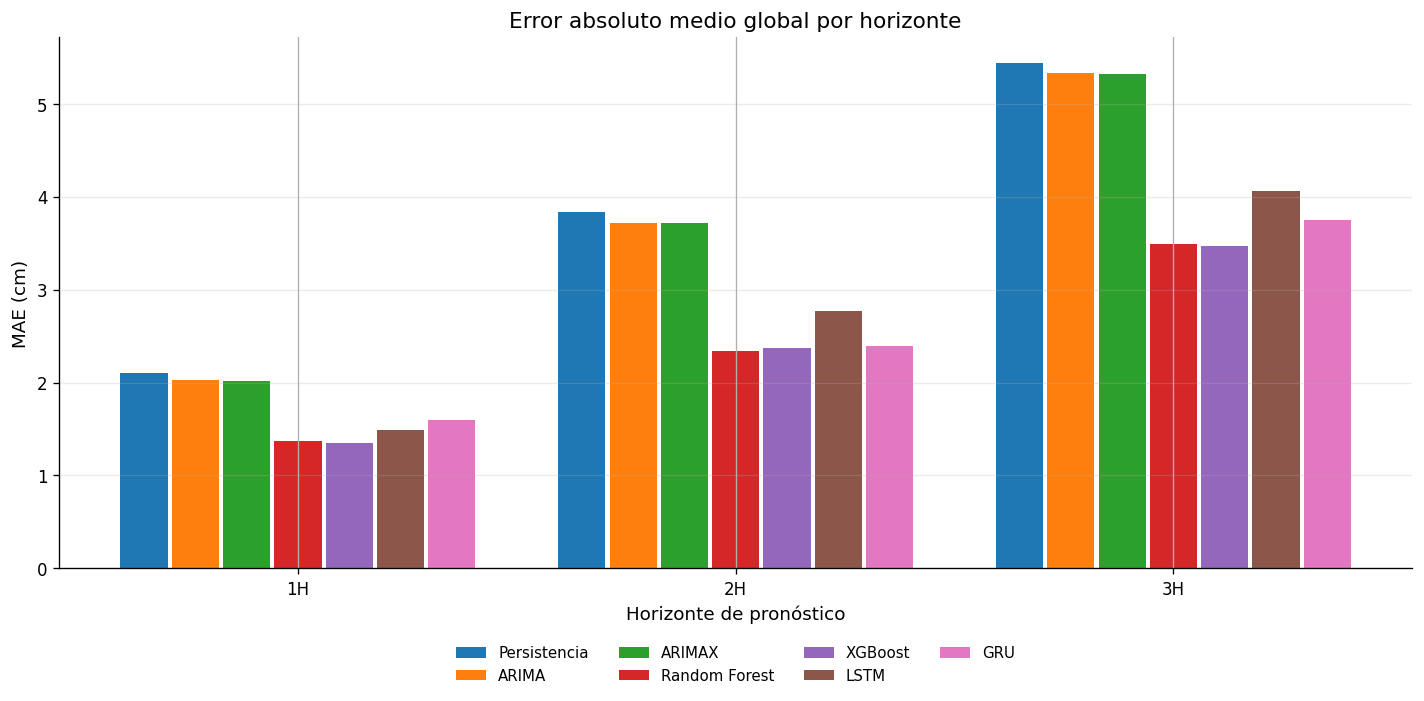

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Generando figura 2/7...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


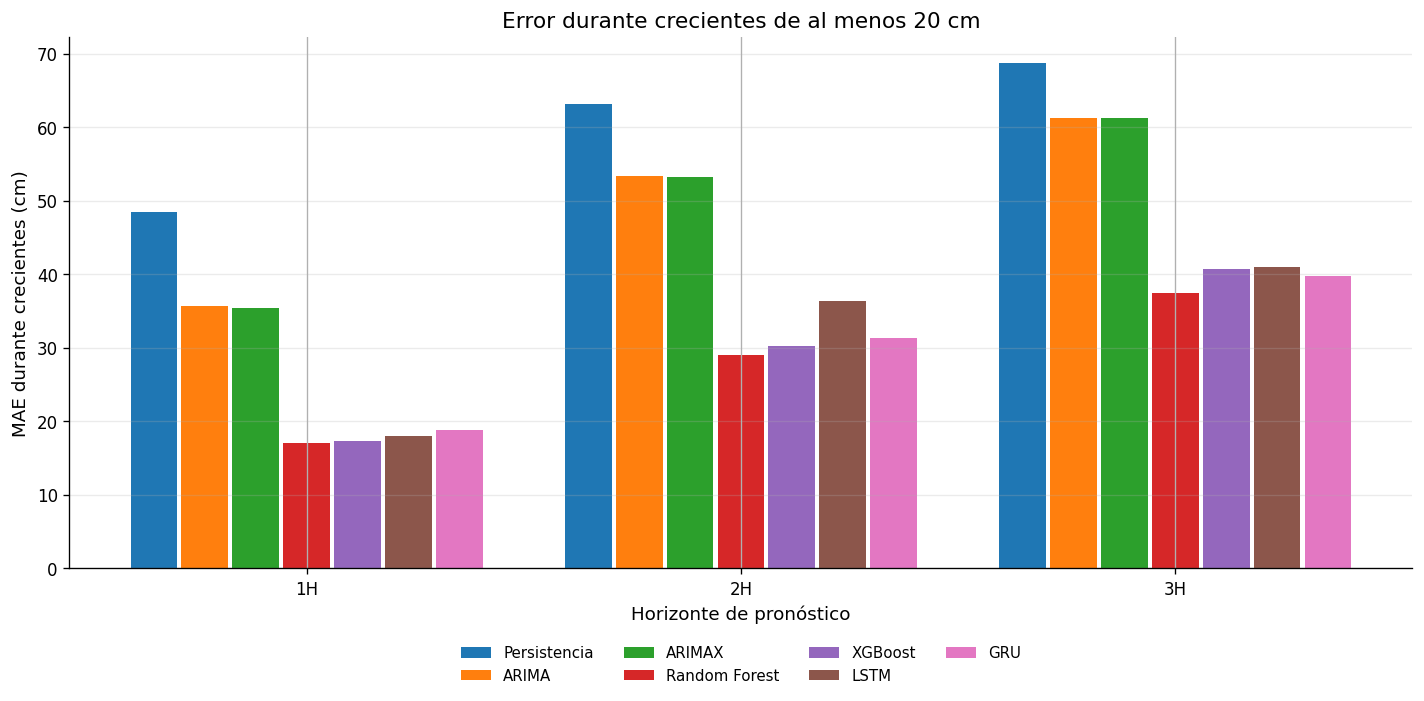

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Generando figura 3/7...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


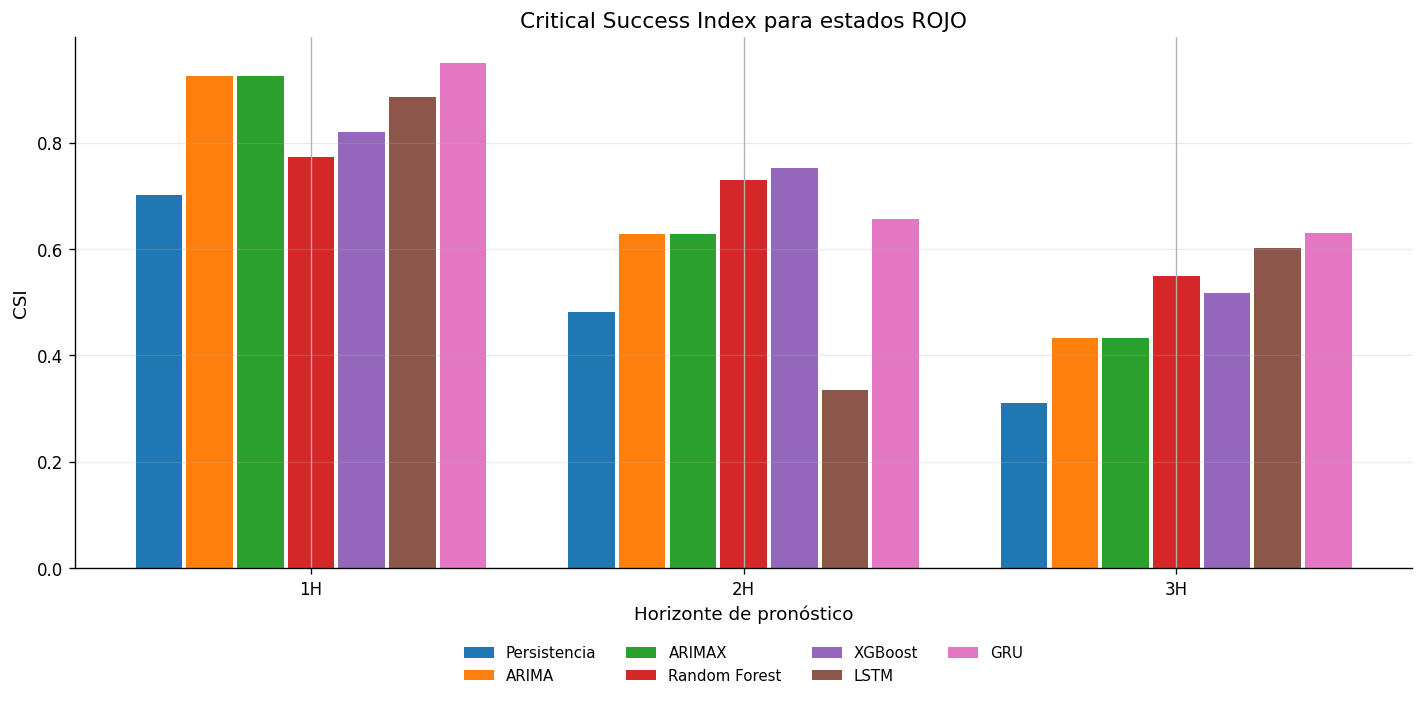

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Generando figura 4/7...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


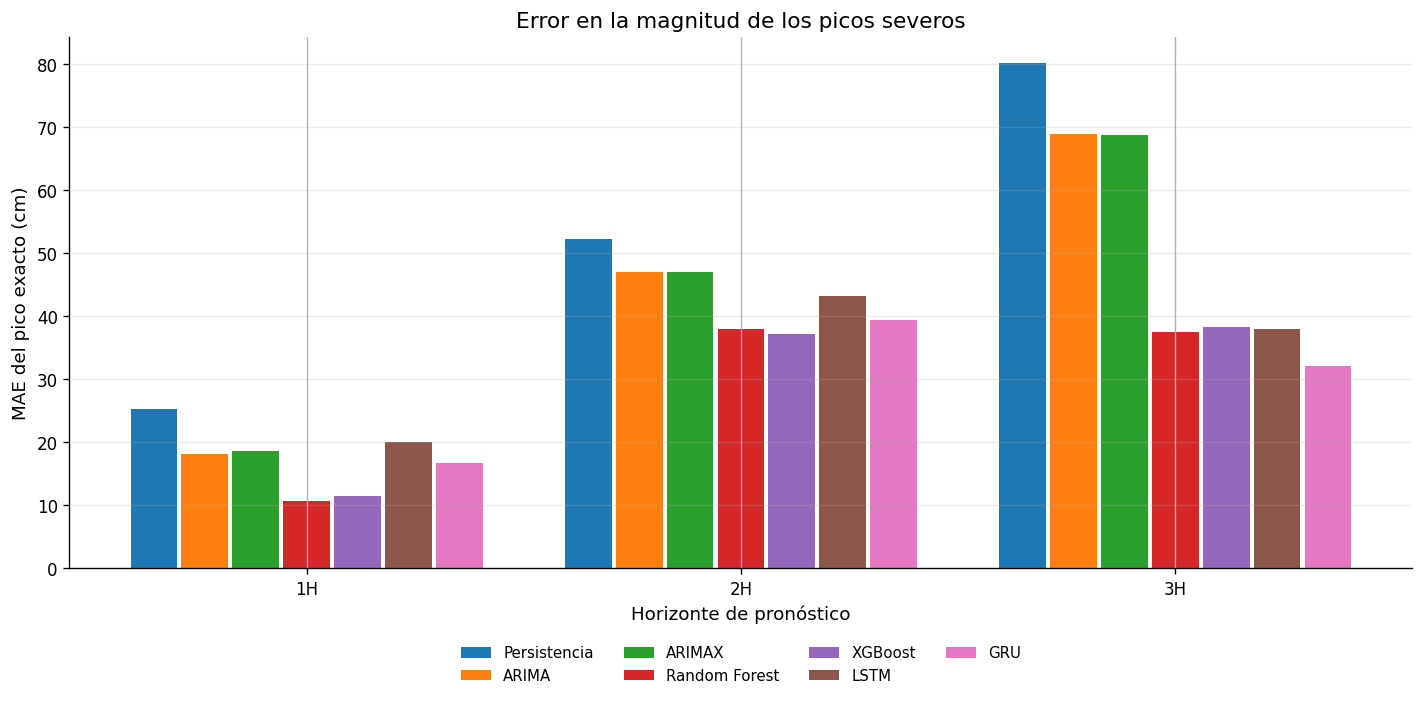

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Generando figura 5/7...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


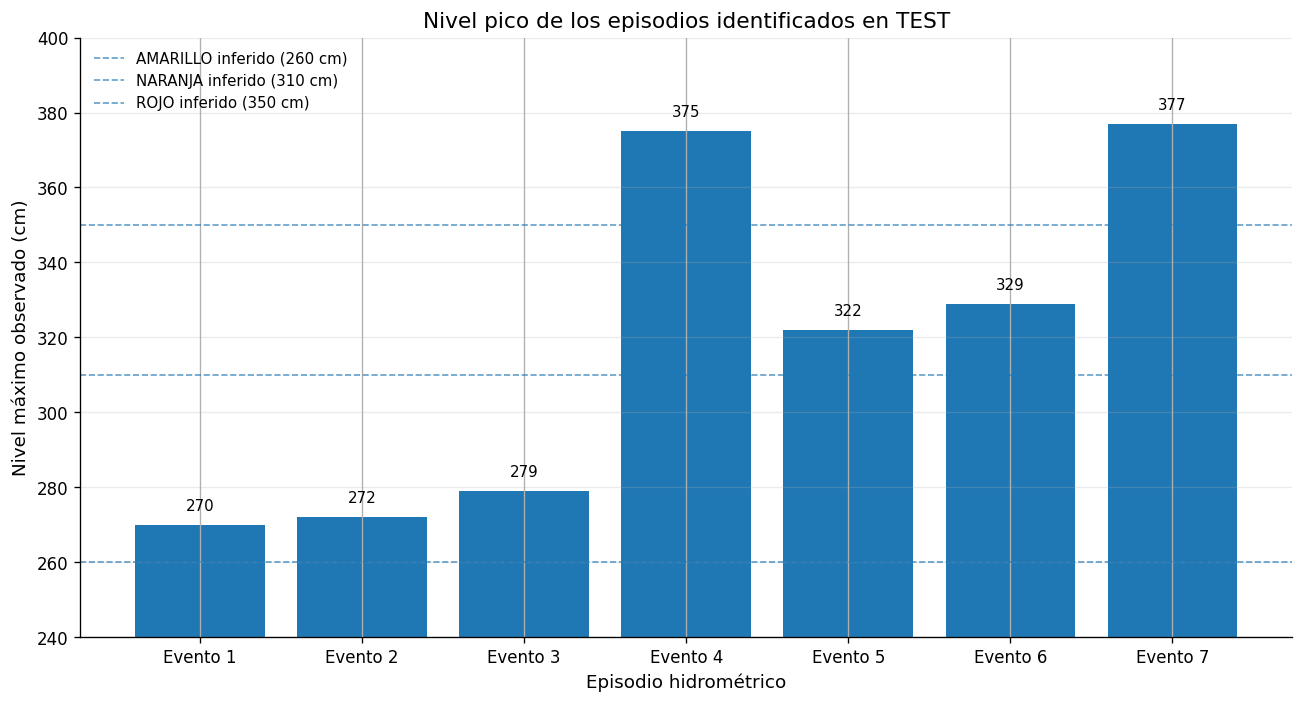

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Generando figura 6/7...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


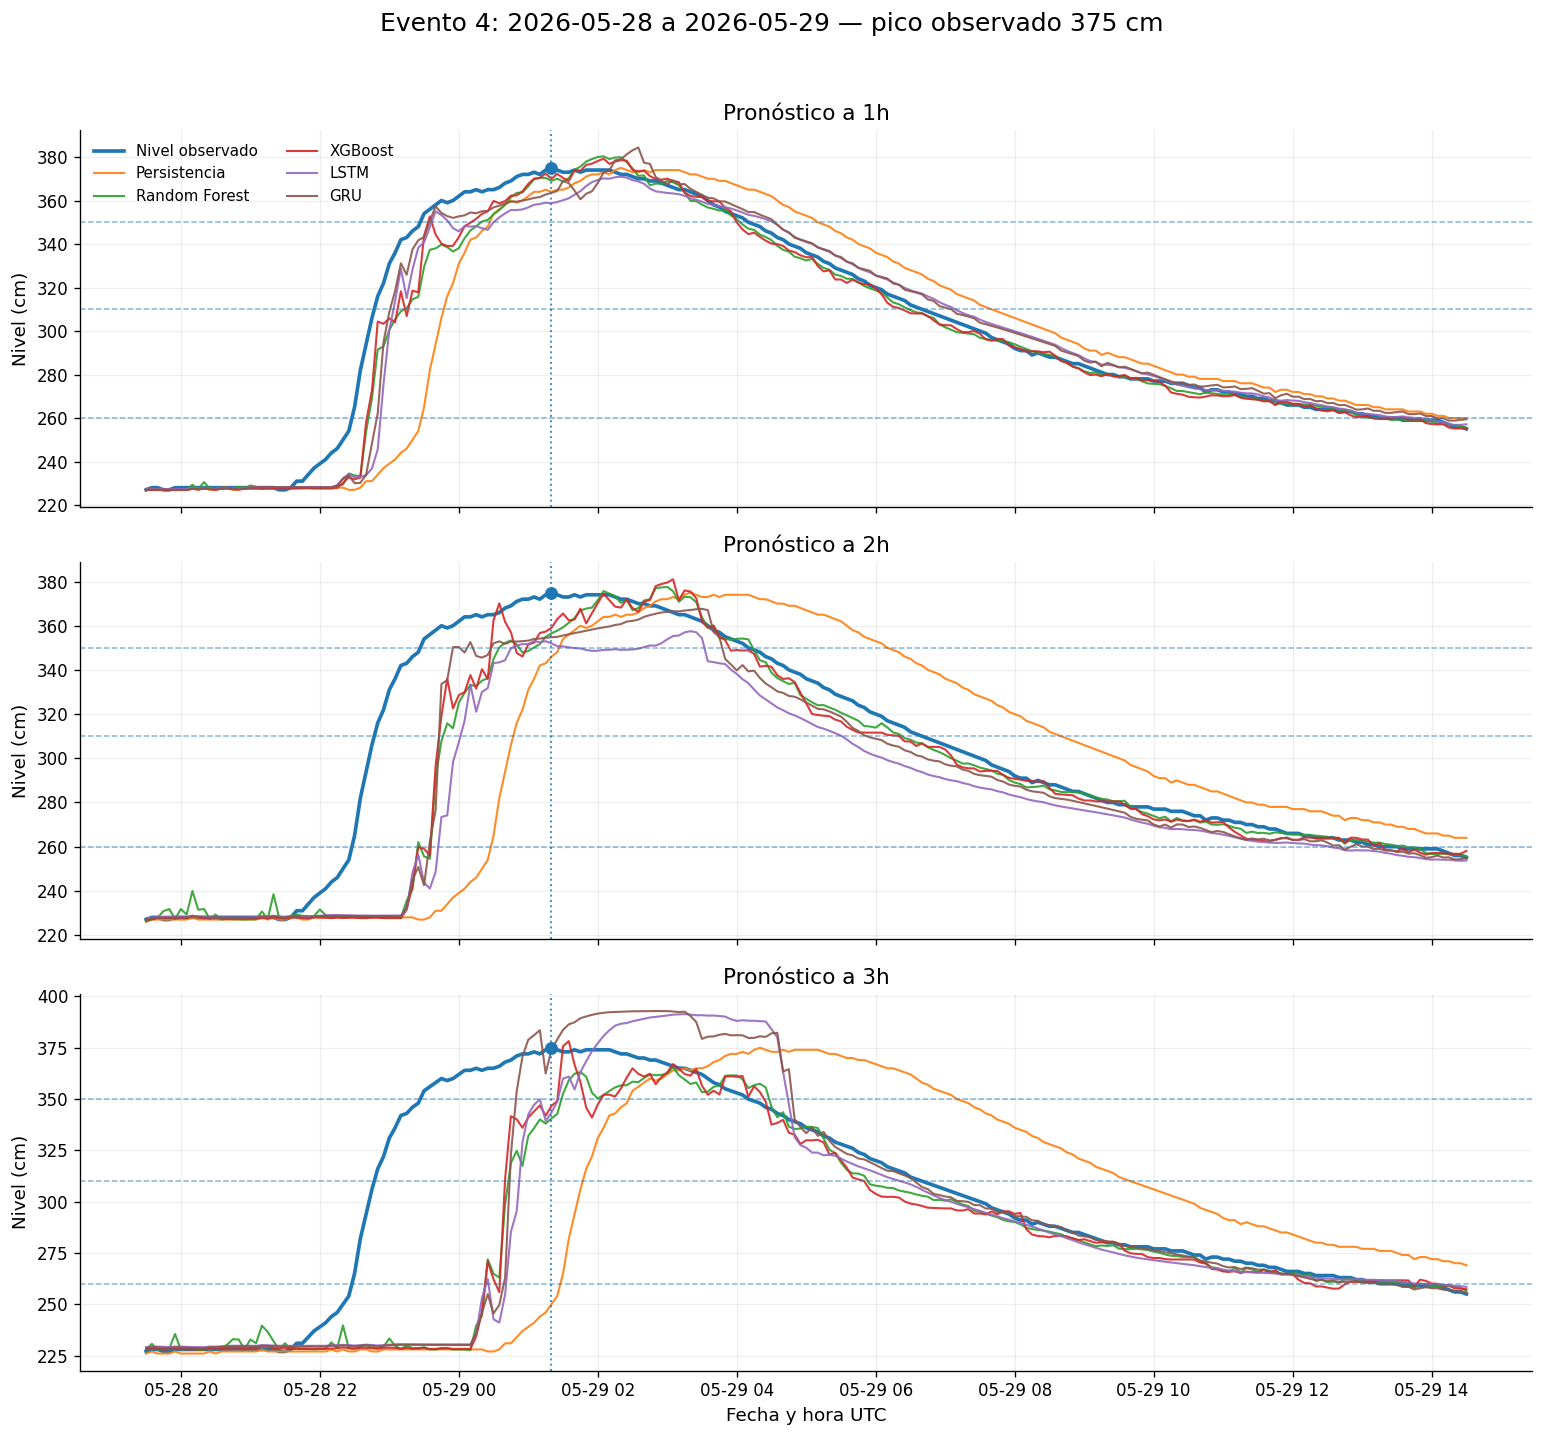

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Generando figura 7/7...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


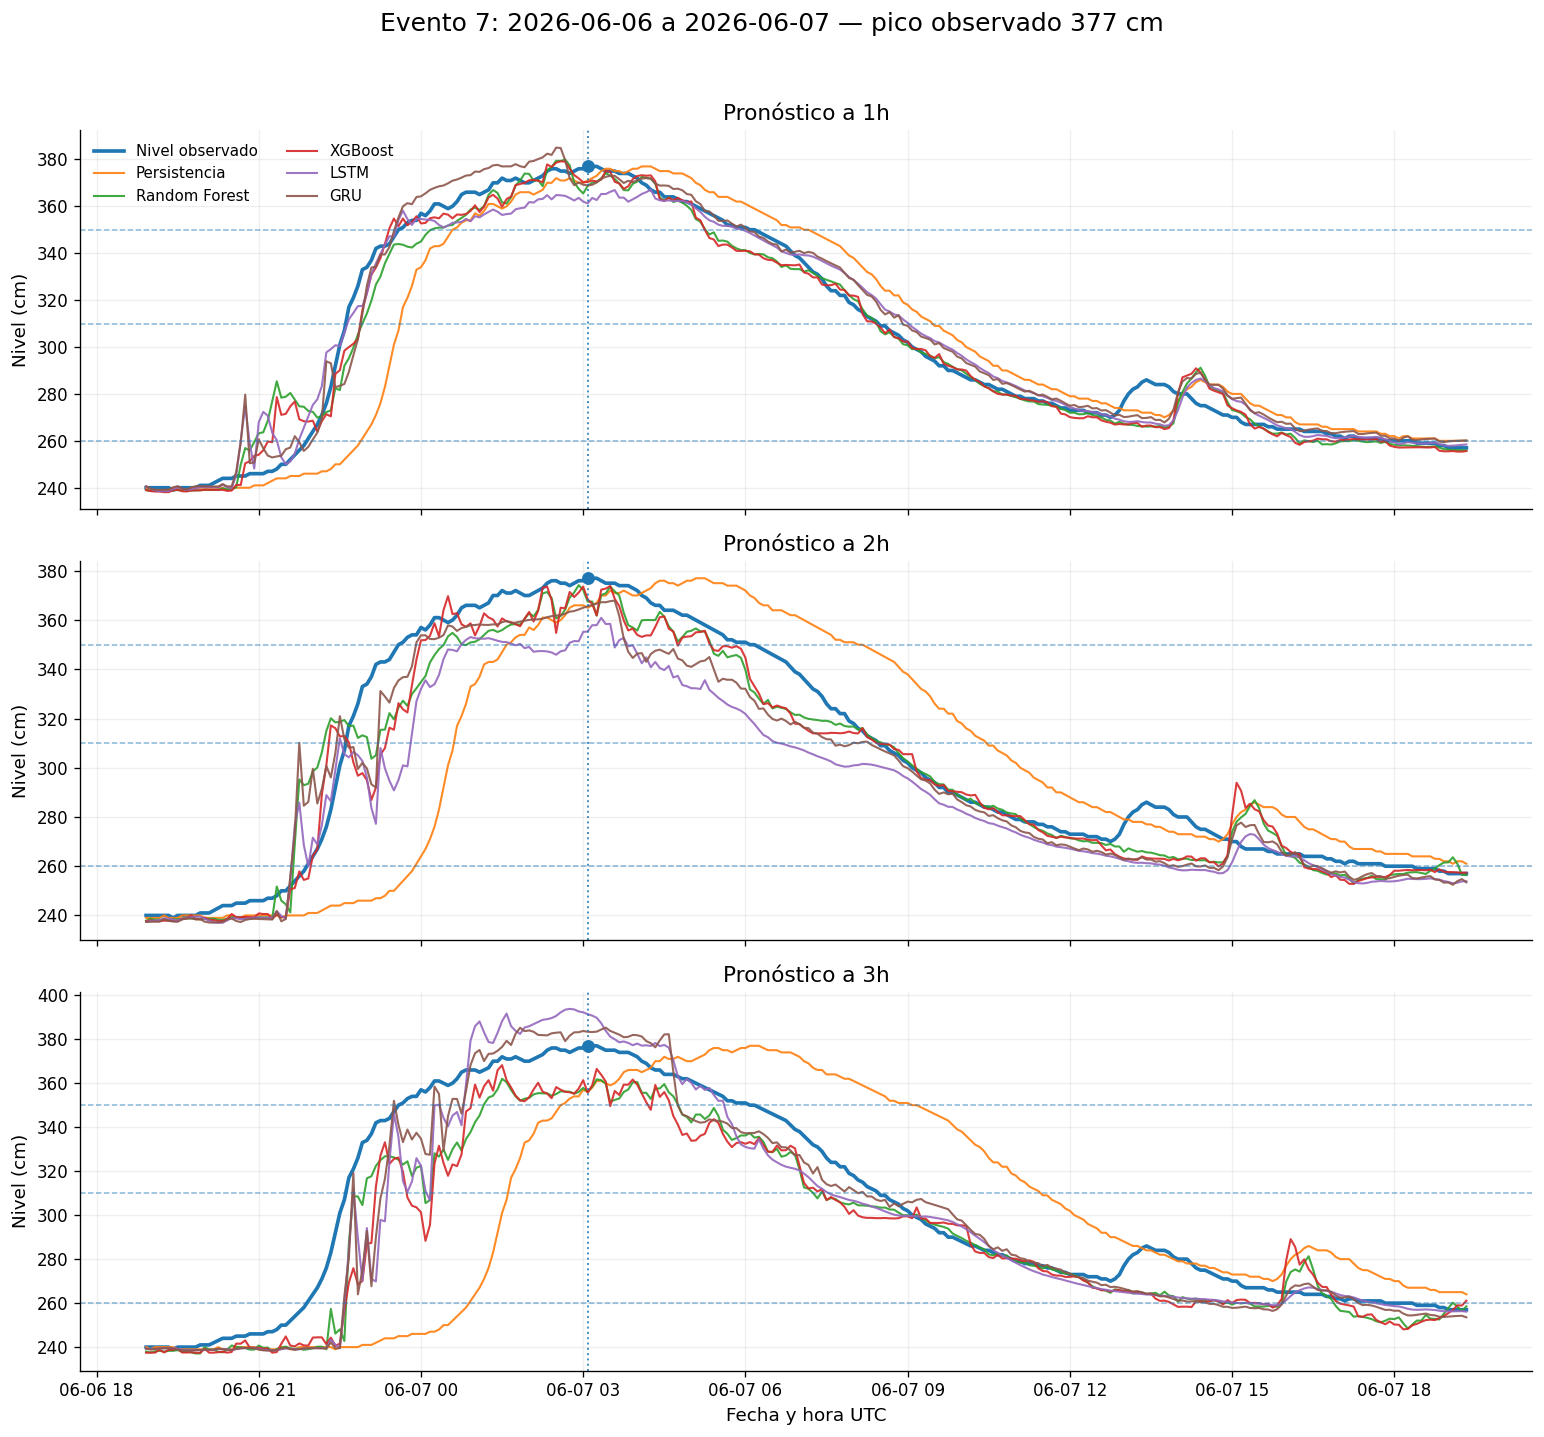


FIGURAS GENERADAS


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,figura,png,pdf,descripcion
0,fig33_01_mae_global,/content/salidas_la_oca/figuras/fig33_01_mae_g...,/content/salidas_la_oca/figuras/fig33_01_mae_g...,Comparación del MAE global de los siete modelo...
1,fig33_02_mae_crecientes20,/content/salidas_la_oca/figuras/fig33_02_mae_c...,/content/salidas_la_oca/figuras/fig33_02_mae_c...,Comparación de los modelos en muestras con inc...
2,fig33_03_csi_rojo,/content/salidas_la_oca/figuras/fig33_03_csi_r...,/content/salidas_la_oca/figuras/fig33_03_csi_r...,"CSI de alertamiento ROJO. Combina aciertos, fa..."
3,fig33_04_mae_picos_severos,/content/salidas_la_oca/figuras/fig33_04_mae_p...,/content/salidas_la_oca/figuras/fig33_04_mae_p...,MAE del nivel pronosticado exactamente h horas...
4,fig33_05_catalogo_eventos,/content/salidas_la_oca/figuras/fig33_05_catal...,/content/salidas_la_oca/figuras/fig33_05_catal...,Picos observados de los siete episodios identi...
5,fig33_06_evento4_pronosticos,/content/salidas_la_oca/figuras/fig33_06_event...,/content/salidas_la_oca/figuras/fig33_06_event...,Comparación de pronósticos rolling durante el ...
6,fig33_07_evento7_pronosticos,/content/salidas_la_oca/figuras/fig33_07_event...,/content/salidas_la_oca/figuras/fig33_07_event...,Comparación de pronósticos rolling durante el ...



CONTROL DE ARCHIVOS
fig33_01_mae_global                 PNG=True | PDF=True
fig33_02_mae_crecientes20           PNG=True | PDF=True
fig33_03_csi_rojo                   PNG=True | PDF=True
fig33_04_mae_picos_severos          PNG=True | PDF=True
fig33_05_catalogo_eventos           PNG=True | PDF=True
fig33_06_evento4_pronosticos        PNG=True | PDF=True
fig33_07_evento7_pronosticos        PNG=True | PDF=True

FIGURAS PRINCIPALES RECOMENDADAS PARA EL TFM

1. fig33_01_mae_global
   Resume el rendimiento general de todos los modelos.

2. fig33_02_mae_crecientes20
   Evidencia el fuerte aumento del error durante crecientes.

3. fig33_03_csi_rojo
   Resume el equilibrio entre detección, omisiones y falsas alarmas en ROJO.

4. fig33_04_mae_picos_severos
   Muestra la dificultad de anticipar la magnitud de los máximos.

5. fig33_06_evento4_pronosticos
   Caso crítico de creciente rápida del 28–29 de mayo.

6. fig33_07_evento7_pronosticos
   Permite contrastar el evento 4 con el segundo episo

In [ ]:
# ============================================================
# CELDA 33 — VISUALIZACIONES FINALES DEL EXPERIMENTO
#
# Genera figuras para el TFM:
#
# 1. MAE global por modelo y horizonte
# 2. MAE durante crecientes >=20 cm
# 3. CSI para alertamiento ROJO
# 4. Error del pico severo >=310 cm
# 5. Severidad de los 7 episodios observados
# 6. Evento crítico 4 — pronósticos rolling
# 7. Evento crítico 7 — pronósticos rolling
#
# Guarda:
# - PNG a 300 dpi
# - PDF vectorial
#
# IMPORTANTE:
# - NO entrena modelos.
# - NO modifica hiperparámetros.
# - NO recalcula predicciones.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path


print("=" * 82)
print("VISUALIZACIONES FINALES DEL EXPERIMENTO")
print("=" * 82)


# ============================================================
# 1. DIRECTORIO DE FIGURAS
# ============================================================

if "FIGURES_DIR" not in globals():

    FIGURES_DIR = Path(
        "/content/salidas_la_oca/figuras"
    )


FIGURES_DIR = Path(
    FIGURES_DIR
)


FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    f"\nDirectorio de figuras:\n"
    f"{FIGURES_DIR}"
)


# ============================================================
# 2. CONFIGURACIÓN GENERAL
#
# No utilizamos seaborn para mantener control directo
# sobre Matplotlib.
# ============================================================

plt.rcParams.update({

    "figure.figsize":
        (11, 6),

    "font.size":
        11,

    "axes.titlesize":
        13,

    "axes.labelsize":
        11,

    "legend.fontsize":
        9,

    "xtick.labelsize":
        10,

    "ytick.labelsize":
        10,

    "figure.dpi":
        120
})


# ============================================================
# 3. ÓRDENES CONSISTENTES
# ============================================================

if isinstance(
    HORIZONTES_MODELO,
    dict
):

    HORIZONTES_FIG = list(
        HORIZONTES_MODELO.keys()
    )

else:

    HORIZONTES_FIG = list(
        HORIZONTES_MODELO
    )


ORDEN_MODELOS = [

    "Persistencia",
    "ARIMA",
    "ARIMAX",
    "Random Forest",
    "XGBoost",
    "LSTM",
    "GRU"
]


MODELOS_PRINCIPALES_FIG = [

    "Persistencia",
    "Random Forest",
    "XGBoost",
    "LSTM",
    "GRU"
]


# ============================================================
# 4. FUNCIONES AUXILIARES
# ============================================================

figuras_generadas = []


def guardar_figura(
    fig,
    nombre,
    descripcion
):

    ruta_png = (
        FIGURES_DIR
        /
        f"{nombre}.png"
    )


    ruta_pdf = (
        FIGURES_DIR
        /
        f"{nombre}.pdf"
    )


    fig.savefig(
        ruta_png,
        dpi=300,
        bbox_inches="tight"
    )


    fig.savefig(
        ruta_pdf,
        bbox_inches="tight"
    )


    figuras_generadas.append({

        "figura":
            nombre,

        "png":
            str(ruta_png),

        "pdf":
            str(ruta_pdf),

        "descripcion":
            descripcion
    })


def grafico_barras_agrupadas(
    tabla,
    columna_valor,
    titulo,
    ylabel,
    nombre_archivo,
    modelos=ORDEN_MODELOS,
    descripcion=""
):

    fig, ax = plt.subplots(
        figsize=(12, 6)
    )


    x = np.arange(
        len(HORIZONTES_FIG)
    )


    n_modelos = len(
        modelos
    )


    ancho_total = 0.82

    ancho = (
        ancho_total
        /
        n_modelos
    )


    for i, familia in enumerate(
        modelos
    ):

        valores = []


        for horizonte in HORIZONTES_FIG:

            fila = tabla[
                (
                    tabla[
                        "familia"
                    ]
                    ==
                    familia
                )
                &
                (
                    tabla[
                        "horizonte"
                    ]
                    ==
                    horizonte
                )
            ]


            if len(fila) == 0:

                valores.append(
                    np.nan
                )

            else:

                valores.append(
                    float(
                        fila.iloc[0][
                            columna_valor
                        ]
                    )
                )


        offset = (

            i
            -
            (
                n_modelos - 1
            )
            /
            2
        ) * ancho


        ax.bar(

            x + offset,

            valores,

            width=
                ancho * 0.92,

            label=
                familia
        )


    ax.set_xticks(
        x
    )


    ax.set_xticklabels(
        [
            h.upper()
            for h in HORIZONTES_FIG
        ]
    )


    ax.set_xlabel(
        "Horizonte de pronóstico"
    )


    ax.set_ylabel(
        ylabel
    )


    ax.set_title(
        titulo
    )


    ax.grid(
        axis="y",
        alpha=0.25
    )


    ax.legend(

        loc="upper center",

        bbox_to_anchor=(
            0.5,
            -0.12
        ),

        ncol=4,

        frameon=False
    )


    fig.tight_layout()


    guardar_figura(

        fig,

        nombre_archivo,

        descripcion
    )


    plt.show()

    plt.close(fig)


# ============================================================
# FIGURA 1
# MAE GLOBAL
# ============================================================

print(
    "\nGenerando figura 1/7..."
)


grafico_barras_agrupadas(

    tabla=
        tabla_test_final,

    columna_valor=
        "MAE_cm",

    titulo=
        "Error absoluto medio global por horizonte",

    ylabel=
        "MAE (cm)",

    nombre_archivo=
        "fig33_01_mae_global",

    descripcion=
        (
            "Comparación del MAE global de los siete "
            "modelos para horizontes de 1, 2 y 3 horas."
        )
)


# ============================================================
# FIGURA 2
# MAE EN CRECIENTES >=20 CM
# ============================================================

print(
    "\nGenerando figura 2/7..."
)


grafico_barras_agrupadas(

    tabla=
        tabla_eventos_test_final,

    columna_valor=
        "MAE_cm",

    titulo=
        "Error durante crecientes de al menos 20 cm",

    ylabel=
        "MAE durante crecientes (cm)",

    nombre_archivo=
        "fig33_02_mae_crecientes20",

    descripcion=
        (
            "Comparación de los modelos en muestras "
            "con incremento futuro del nivel >=20 cm."
        )
)


# ============================================================
# FIGURA 3
# CSI DE ALERTAMIENTO ROJO
# ============================================================

print(
    "\nGenerando figura 3/7..."
)


skill_rojo_fig = (

    tabla_skill_alertas[
        tabla_skill_alertas[
            "categoria"
        ]
        ==
        "ROJO"
    ]

    .copy()
)


grafico_barras_agrupadas(

    tabla=
        skill_rojo_fig,

    columna_valor=
        "CSI",

    titulo=
        "Critical Success Index para estados ROJO",

    ylabel=
        "CSI",

    nombre_archivo=
        "fig33_03_csi_rojo",

    descripcion=
        (
            "CSI de alertamiento ROJO. "
            "Combina aciertos, falsas alarmas y omisiones."
        )
)


# ============================================================
# FIGURA 4
# ERROR DEL PICO SEVERO
# ============================================================

print(
    "\nGenerando figura 4/7..."
)


grafico_barras_agrupadas(

    tabla=
        tabla_resumen_picos_severos,

    columna_valor=
        "MAE_pico_exacto_cm",

    titulo=
        "Error en la magnitud de los picos severos",

    ylabel=
        "MAE del pico exacto (cm)",

    nombre_archivo=
        "fig33_04_mae_picos_severos",

    descripcion=
        (
            "MAE del nivel pronosticado exactamente "
            "h horas antes para el instante real del pico "
            "en eventos con máximo >=310 cm."
        )
)


# ============================================================
# FIGURA 5
# CATÁLOGO DE LOS 7 EPISODIOS
# ============================================================

print(
    "\nGenerando figura 5/7..."
)


eventos_fig = (

    tabla_eventos_observados

    .sort_values(
        "evento_id"
    )

    .copy()
)


fig, ax = plt.subplots(
    figsize=(11, 6)
)


x = np.arange(
    len(
        eventos_fig
    )
)


barras = ax.bar(

    x,

    eventos_fig[
        "nivel_pico_cm"
    ]
)


# ------------------------------------------------------------
# Umbrales inferidos
# ------------------------------------------------------------

ax.axhline(
    260,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label="AMARILLO inferido (260 cm)"
)


ax.axhline(
    310,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label="NARANJA inferido (310 cm)"
)


ax.axhline(
    350,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label="ROJO inferido (350 cm)"
)


# ------------------------------------------------------------
# Valor de cada pico
# ------------------------------------------------------------

for barra, valor in zip(

    barras,

    eventos_fig[
        "nivel_pico_cm"
    ]
):

    ax.text(

        barra.get_x()
        +
        barra.get_width()
        /
        2,

        valor + 3,

        f"{valor:.0f}",

        ha="center",

        va="bottom",

        fontsize=9
    )


ax.set_xticks(
    x
)


ax.set_xticklabels(

    [
        f"Evento {int(e)}"
        for e in eventos_fig[
            "evento_id"
        ]
    ]
)


ax.set_xlabel(
    "Episodio hidrométrico"
)


ax.set_ylabel(
    "Nivel máximo observado (cm)"
)


ax.set_title(
    "Nivel pico de los episodios identificados en TEST"
)


ax.set_ylim(

    bottom=240,

    top=max(
        400,
        eventos_fig[
            "nivel_pico_cm"
        ].max()
        +
        20
    )
)


ax.grid(
    axis="y",
    alpha=0.25
)


ax.legend(
    frameon=False
)


fig.tight_layout()


guardar_figura(

    fig,

    "fig33_05_catalogo_eventos",

    (
        "Picos observados de los siete episodios "
        "identificados en el periodo de TEST."
    )
)


plt.show()

plt.close(fig)


# ============================================================
# 5.1 FUNCIÓN PARA VISUALIZAR UN EVENTO CRÍTICO
#
# Cada figura tiene 3 paneles:
#
# - Pronósticos 1 h
# - Pronósticos 2 h
# - Pronósticos 3 h
#
# El eje temporal corresponde al timestamp TARGET,
# no al timestamp de emisión.
#
# Mostramos:
#
# - Observado
# - Persistencia
# - Random Forest
# - XGBoost
# - LSTM
# - GRU
#
# ARIMA/ARIMAX ya fueron suficientemente caracterizados
# en las tablas y se omiten aquí para reducir saturación.
# ============================================================

def graficar_evento_critico(
    evento_id,
    nombre_archivo
):

    fila_evento = (

        tabla_eventos_observados[
            tabla_eventos_observados[
                "evento_id"
            ]
            ==
            evento_id
        ]
    )


    if len(fila_evento) == 0:

        raise ValueError(
            f"No existe evento_id={evento_id}"
        )


    evento = (
        fila_evento.iloc[0]
    )


    inicio_evento = pd.to_datetime(
        evento[
            "inicio"
        ],
        utc=True
    )


    fin_evento = pd.to_datetime(
        evento[
            "fin"
        ],
        utc=True
    )


    timestamp_pico = pd.to_datetime(
        evento[
            "timestamp_pico"
        ],
        utc=True
    )


    nivel_pico = float(
        evento[
            "nivel_pico_cm"
        ]
    )


    # --------------------------------------------------------
    # Mostramos contexto antes y después del episodio
    # --------------------------------------------------------

    inicio_plot = (

        inicio_evento
        -
        pd.Timedelta(
            hours=3
        )
    )


    fin_plot = (

        fin_evento
        +
        pd.Timedelta(
            hours=1
        )
    )


    observado = (

        df_5min.loc[
            inicio_plot:
            fin_plot,
            "nivel_cm"
        ]

        .copy()
    )


    # --------------------------------------------------------
    # Figura con un panel por horizonte
    # --------------------------------------------------------

    fig, axes = plt.subplots(

        nrows=3,

        ncols=1,

        figsize=(13, 12),

        sharex=True
    )


    for ax, horizonte in zip(
        axes,
        HORIZONTES_FIG
    ):

        # ----------------------------------------------------
        # Serie real
        # ----------------------------------------------------

        ax.plot(

            observado.index,

            observado.values,

            linewidth=2.2,

            label="Nivel observado"
        )


        # ----------------------------------------------------
        # Pronósticos
        #
        # Se grafican contra timestamp_target.
        # ----------------------------------------------------

        for familia in MODELOS_PRINCIPALES_FIG:

            pred = (

                predicciones_test[
                    familia
                ][
                    horizonte
                ]

                .copy()
            )


            pred[
                "timestamp_target"
            ] = pd.to_datetime(

                pred[
                    "timestamp_target"
                ],

                utc=True
            )


            pred_evento = (

                pred[
                    (
                        pred[
                            "timestamp_target"
                        ]
                        >=
                        inicio_plot
                    )
                    &
                    (
                        pred[
                            "timestamp_target"
                        ]
                        <=
                        fin_plot
                    )
                ]

                .sort_values(
                    "timestamp_target"
                )
            )


            if len(
                pred_evento
            ) == 0:

                continue


            ax.plot(

                pred_evento[
                    "timestamp_target"
                ],

                pred_evento[
                    "nivel_predicho"
                ],

                linewidth=1.25,

                alpha=0.9,

                label=
                    familia
            )


        # ----------------------------------------------------
        # Umbrales inferidos
        # ----------------------------------------------------

        ax.axhline(
            260,
            linestyle="--",
            linewidth=0.9,
            alpha=0.55
        )


        ax.axhline(
            310,
            linestyle="--",
            linewidth=0.9,
            alpha=0.55
        )


        ax.axhline(
            350,
            linestyle="--",
            linewidth=0.9,
            alpha=0.55
        )


        # ----------------------------------------------------
        # Pico observado
        # ----------------------------------------------------

        ax.axvline(

            timestamp_pico,

            linestyle=":",

            linewidth=1.2,

            alpha=0.8
        )


        ax.scatter(

            [
                timestamp_pico
            ],

            [
                nivel_pico
            ],

            s=45,

            zorder=10
        )


        ax.set_ylabel(
            "Nivel (cm)"
        )


        ax.set_title(
            f"Pronóstico a {horizonte}"
        )


        ax.grid(
            alpha=0.20
        )


    # --------------------------------------------------------
    # Leyenda solo en el primer panel
    # --------------------------------------------------------

    handles, labels = (
        axes[0]
        .get_legend_handles_labels()
    )


    axes[0].legend(

        handles,

        labels,

        loc="upper left",

        ncol=2,

        frameon=False
    )


    axes[-1].set_xlabel(
        "Fecha y hora UTC"
    )


    fecha_inicio = (
        inicio_evento
        .strftime(
            "%Y-%m-%d"
        )
    )


    fecha_fin = (
        fin_evento
        .strftime(
            "%Y-%m-%d"
        )
    )


    fig.suptitle(

        (
            f"Evento {evento_id}: "
            f"{fecha_inicio} a {fecha_fin} — "
            f"pico observado {nivel_pico:.0f} cm"
        ),

        fontsize=15,

        y=0.995
    )


    fig.tight_layout(
        rect=[
            0,
            0,
            1,
            0.975
        ]
    )


    guardar_figura(

        fig,

        nombre_archivo,

        (
            f"Comparación de pronósticos rolling "
            f"durante el evento {evento_id}, "
            f"con horizontes de 1, 2 y 3 horas."
        )
    )


    plt.show()

    plt.close(fig)


# ============================================================
# FIGURA 6
# EVENTO 4 — CRECIENTE EXPLOSIVA
# ============================================================

print(
    "\nGenerando figura 6/7..."
)


graficar_evento_critico(

    evento_id=4,

    nombre_archivo=
        "fig33_06_evento4_pronosticos"
)


# ============================================================
# FIGURA 7
# EVENTO 7 — SEGUNDO EVENTO ROJO
# ============================================================

print(
    "\nGenerando figura 7/7..."
)


graficar_evento_critico(

    evento_id=7,

    nombre_archivo=
        "fig33_07_evento7_pronosticos"
)


# ============================================================
# 6. CATÁLOGO DE FIGURAS GENERADAS
# ============================================================

tabla_figuras_tfm = (
    pd.DataFrame(
        figuras_generadas
    )
)


print(
    "\n"
    +
    "=" * 82
)

print(
    "FIGURAS GENERADAS"
)

print(
    "=" * 82
)


display(
    tabla_figuras_tfm
)


# ============================================================
# 7. GUARDAR CATÁLOGO
# ============================================================

tabla_figuras_tfm.to_csv(

    TABLES_DIR
    /
    "catalogo_figuras_finales_tfm.csv",

    index=False
)


# ============================================================
# 8. CONTROL DE ARCHIVOS
# ============================================================

print(
    "\n"
    +
    "=" * 82
)

print(
    "CONTROL DE ARCHIVOS"
)

print(
    "=" * 82
)


for _, fila in (
    tabla_figuras_tfm.iterrows()
):

    png_ok = (
        Path(
            fila["png"]
        )
        .exists()
    )


    pdf_ok = (
        Path(
            fila["pdf"]
        )
        .exists()
    )


    print(

        f"{fila['figura']:<35} "
        f"PNG={png_ok} | "
        f"PDF={pdf_ok}"
    )


# ============================================================
# 9. RECOMENDACIÓN DE FIGURAS PARA EL TFM
# ============================================================

print(
    "\n"
    +
    "=" * 82
)

print(
    "FIGURAS PRINCIPALES RECOMENDADAS PARA EL TFM"
)

print(
    "=" * 82
)


print(
    "\n1. fig33_01_mae_global"
)

print(
    "   Resume el rendimiento general de todos los modelos."
)


print(
    "\n2. fig33_02_mae_crecientes20"
)

print(
    "   Evidencia el fuerte aumento del error durante crecientes."
)


print(
    "\n3. fig33_03_csi_rojo"
)

print(
    "   Resume el equilibrio entre detección, "
    "omisiones y falsas alarmas en ROJO."
)


print(
    "\n4. fig33_04_mae_picos_severos"
)

print(
    "   Muestra la dificultad de anticipar "
    "la magnitud de los máximos."
)


print(
    "\n5. fig33_06_evento4_pronosticos"
)

print(
    "   Caso crítico de creciente rápida del 28–29 de mayo."
)


print(
    "\n6. fig33_07_evento7_pronosticos"
)

print(
    "   Permite contrastar el evento 4 con "
    "el segundo episodio ROJO."
)


print(
    "\nfig33_05_catalogo_eventos puede utilizarse "
    "como figura descriptiva adicional."
)


# ============================================================
# 10. CONTROL METODOLÓGICO
# ============================================================

print(
    "\n"
    +
    "=" * 82
)

print(
    "CONTROL METODOLÓGICO"
)

print(
    "=" * 82
)


print(
    "No se entrenó ningún modelo."
)

print(
    "No se modificaron hiperparámetros."
)

print(
    "No se recalcularon predicciones."
)

print(
    "Las figuras utilizan exclusivamente "
    "los resultados finales de TEST."
)

print(
    "En las figuras de eventos, las predicciones "
    "se posicionan según timestamp_target."
)

print(
    "Los umbrales 260/310/350 cm se muestran "
    "únicamente como umbrales inferidos del dataset."
)

print(
    "Las figuras se guardaron en PNG 300 dpi "
    "y PDF vectorial."
)


print(
    "\n"
    +
    "=" * 82
)

print(
    "VISUALIZACIONES FINALES COMPLETADAS"
)

print(
    "=" * 82
)

In [ ]:
# ============================================================
# CELDA 34 — EXPORTACIÓN FINAL Y CIERRE DEL EXPERIMENTO
#
# Esta es la última celda del notebook.
#
# Objetivos:
#
# 1. Consolidar resultados finales.
# 2. Crear resumen del experimento en Markdown.
# 3. Guardar información del entorno.
# 4. Crear manifiesto de archivos.
# 5. Crear ZIP con tablas + figuras + documentación.
# 6. Crear ZIP independiente con los modelos entrenados.
# 7. Verificar integridad básica de los entregables.
#
# IMPORTANTE:
# - NO entrena modelos.
# - NO recalcula predicciones.
# - NO modifica hiperparámetros.
# - NO cambia conclusiones.
# ============================================================

from pathlib import Path
from datetime import datetime, timezone

import os
import sys
import json
import shutil
import hashlib
import platform
import zipfile

import numpy as np
import pandas as pd


print("=" * 86)
print("EXPORTACIÓN FINAL Y CIERRE REPRODUCIBLE DEL EXPERIMENTO")
print("=" * 86)


# ============================================================
# 1. DIRECTORIOS
# ============================================================

BASE_DIR = Path(
    "/content/salidas_la_oca"
)


TABLES_DIR = Path(
    globals().get(
        "TABLES_DIR",
        BASE_DIR / "tablas"
    )
)


FIGURES_DIR = Path(
    globals().get(
        "FIGURES_DIR",
        BASE_DIR / "figuras"
    )
)


MODELS_DIR = Path(
    globals().get(
        "MODELS_DIR",
        BASE_DIR / "modelos"
    )
)


DATASETS_DIR = Path(
    globals().get(
        "DATASETS_DIR",
        BASE_DIR / "datasets"
    )
)


EXPORT_DIR = (
    BASE_DIR
    /
    "exportacion_final"
)


DOCS_DIR = (
    EXPORT_DIR
    /
    "documentacion"
)


EXPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


DOCS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    f"\nDirectorio base      : {BASE_DIR}"
)

print(
    f"Tablas               : {TABLES_DIR}"
)

print(
    f"Figuras              : {FIGURES_DIR}"
)

print(
    f"Modelos              : {MODELS_DIR}"
)

print(
    f"Datasets procesados  : {DATASETS_DIR}"
)

print(
    f"Exportación final    : {EXPORT_DIR}"
)


# ============================================================
# 2. CONTROL DE RESULTADOS FINALES
# ============================================================

objetos_finales_requeridos = [

    "tabla_test_final",

    "tabla_sintesis_definitiva",

    "tabla_panel_principales",

    "tabla_limitaciones_test",

    "tabla_ganadores_globales",

    "tabla_ganadores_crecientes",

    "tabla_ganadores_alerta_rojo",

    "tabla_ganadores_picos_severos"
]


faltantes = [

    nombre
    for nombre in objetos_finales_requeridos
    if nombre not in globals()
]


if faltantes:

    raise RuntimeError(

        "No puede cerrarse el experimento. "
        "Faltan los siguientes objetos:\n"
        +
        "\n".join(
            faltantes
        )
    )


print(
    "\nControl de resultados finales: OK"
)


# ============================================================
# 3. EXPORTAR NUEVAMENTE LAS TABLAS CENTRALES
#
# Esto garantiza que las tablas definitivas estén presentes
# aunque alguna exportación anterior se hubiese omitido.
# ============================================================

tablas_finales = {

    "resultados_test_todos_modelos.csv":
        tabla_test_final,

    "sintesis_definitiva_por_horizonte.csv":
        tabla_sintesis_definitiva,

    "panel_modelos_principales.csv":
        tabla_panel_principales,

    "limitaciones_cuantitativas_test.csv":
        tabla_limitaciones_test,

    "ganadores_metricas_globales.csv":
        tabla_ganadores_globales,

    "ganadores_crecientes20.csv":
        tabla_ganadores_crecientes,

    "ganadores_alertamiento_rojo.csv":
        tabla_ganadores_alerta_rojo,

    "ganadores_picos_severos.csv":
        tabla_ganadores_picos_severos
}


for nombre_archivo, tabla in (
    tablas_finales.items()
):

    ruta = (
        TABLES_DIR
        /
        nombre_archivo
    )


    tabla.to_csv(
        ruta,
        index=False
    )


print(
    f"\nTablas centrales exportadas: "
    f"{len(tablas_finales)}"
)


# ============================================================
# 4. EXTRAER CONCLUSIONES DEFINITIVAS DINÁMICAMENTE
#
# No escribimos números manualmente.
#
# Todo sale directamente de las tablas finales.
# ============================================================

conclusiones_horizonte = []


for _, fila in (

    tabla_sintesis_definitiva
    .sort_values(
        "horizonte"
    )
    .iterrows()
):

    horizonte = (
        fila[
            "horizonte"
        ]
    )


    conclusiones_horizonte.append({

        "horizonte":
            horizonte,

        "modelo_global":
            fila[
                "mejor_global_MAE"
            ],

        "mae_global":
            float(
                fila[
                    "MAE_global_cm"
                ]
            ),

        "mejora_persistencia":
            float(
                fila[
                    "mejora_vs_persistencia_pct"
                ]
            ),

        "modelo_crecientes":
            fila[
                "mejor_crecientes_20"
            ],

        "mae_crecientes":
            float(
                fila[
                    "MAE_crecientes_cm"
                ]
            ),

        "subestima_crecientes":
            float(
                fila[
                    "subestima_crecientes_pct"
                ]
            ),

        "modelo_rojo":
            fila[
                "mejor_alerta_ROJO_CSI"
            ],

        "csi_rojo":
            float(
                fila[
                    "CSI_ROJO"
                ]
            ),

        "pod_rojo":
            float(
                fila[
                    "POD_ROJO"
                ]
            ),

        "far_rojo":
            float(
                fila[
                    "FAR_ROJO"
                ]
            ),

        "modelo_pico":
            fila[
                "mejor_pico_severo"
            ],

        "mae_pico":
            float(
                fila[
                    "MAE_pico_severo_cm"
                ]
            ),

        "subestima_pico":
            float(
                fila[
                    "subestima_pico_severo_pct"
                ]
            )
    })


# ============================================================
# 5. LIMITACIONES CUANTITATIVAS
# ============================================================

fila_lim = (
    tabla_limitaciones_test
    .iloc[0]
)


n_eventos_total = int(
    fila_lim[
        "episodios_total_test"
    ]
)


n_eventos_310 = int(
    fila_lim[
        "episodios_pico_310_o_mas"
    ]
)


n_eventos_350 = int(
    fila_lim[
        "episodios_pico_350_o_mas"
    ]
)


n_picos_severos_evaluables = int(
    fila_lim[
        "picos_severos_evaluables"
    ]
)


n_rojos_evaluables = int(
    fila_lim[
        "cruces_ROJO_evaluables"
    ]
)


# ============================================================
# 6. CREAR RESUMEN FINAL EN MARKDOWN
# ============================================================

fecha_exportacion = (
    datetime.now(
        timezone.utc
    )
    .isoformat()
)


lineas_md = []


lineas_md.append(
    "# Predicción de nivel — Quebrada La Oca"
)

lineas_md.append(
    ""
)

lineas_md.append(
    "## Resumen final del experimento"
)

lineas_md.append(
    ""
)

lineas_md.append(
    f"Exportación generada: `{fecha_exportacion}`"
)

lineas_md.append(
    ""
)

lineas_md.append(
    "Horizontes evaluados: **1 h, 2 h y 3 h**."
)

lineas_md.append(
    ""
)

lineas_md.append(
    "Modelos evaluados:"
)

lineas_md.append(
    ""
)

for modelo in [

    "Persistencia",
    "ARIMA",
    "ARIMAX",
    "Random Forest",
    "XGBoost",
    "LSTM",
    "GRU"

]:

    lineas_md.append(
        f"- {modelo}"
    )


lineas_md.append(
    ""
)

lineas_md.append(
    "## Resultados por horizonte"
)

lineas_md.append(
    ""
)


for resultado in conclusiones_horizonte:

    h = (
        resultado[
            "horizonte"
        ]
    )


    lineas_md.append(
        f"### Horizonte {h}"
    )

    lineas_md.append(
        ""
    )


    lineas_md.append(

        f"- Mejor MAE global: "
        f"**{resultado['modelo_global']}**, "
        f"MAE = {resultado['mae_global']:.3f} cm."
    )


    lineas_md.append(

        f"- Mejora de MAE frente a persistencia: "
        f"**{resultado['mejora_persistencia']:.1f}%**."
    )


    lineas_md.append(

        f"- Mejor desempeño en crecientes >=20 cm: "
        f"**{resultado['modelo_crecientes']}**, "
        f"MAE = {resultado['mae_crecientes']:.2f} cm."
    )


    lineas_md.append(

        f"- Subestimación en crecientes del mejor modelo: "
        f"{resultado['subestima_crecientes']:.1f}%."
    )


    lineas_md.append(

        f"- Mejor equilibrio de alertamiento ROJO: "
        f"**{resultado['modelo_rojo']}**, "
        f"CSI = {resultado['csi_rojo']:.3f}, "
        f"POD = {resultado['pod_rojo']:.3f}, "
        f"FAR = {resultado['far_rojo']:.3f}."
    )


    lineas_md.append(

        f"- Mejor estimación del pico severo: "
        f"**{resultado['modelo_pico']}**, "
        f"MAE del pico exacto = "
        f"{resultado['mae_pico']:.2f} cm."
    )


    lineas_md.append(
        ""
    )


# ------------------------------------------------------------
# Conclusiones generales
# ------------------------------------------------------------

lineas_md.append(
    "## Conclusiones generales"
)

lineas_md.append(
    ""
)


conclusiones_generales = [

    (
        "No existe un único modelo dominante para todos "
        "los objetivos de predicción."
    ),

    (
        "Random Forest y XGBoost presentan el comportamiento "
        "global más consistente."
    ),

    (
        "Random Forest muestra especial fortaleza durante "
        "crecientes de al menos 20 cm."
    ),

    (
        "GRU adquiere especial relevancia en horizontes largos, "
        "particularmente en alertamiento ROJO y estimación "
        "de picos severos a 3 h."
    ),

    (
        "El error durante crecientes y eventos severos es "
        "sustancialmente mayor que el error global."
    ),

    (
        "La subestimación de crecientes constituye una "
        "limitación recurrente de los modelos."
    ),

    (
        "ARIMA y ARIMAX funcionan como baselines estadísticos "
        "útiles, pero fueron superados globalmente por los "
        "modelos no lineales."
    ),

    (
        "La mejora de ARIMAX frente a ARIMA fue pequeña, "
        "por lo que la incorporación lineal y causal de "
        "precipitación no aportó una mejora sustancial."
    ),

    (
        "Los resultados sobre extremos deben interpretarse "
        "con cautela debido al número reducido de episodios "
        "severos independientes disponibles."
    )
]


for conclusion in (
    conclusiones_generales
):

    lineas_md.append(
        f"- {conclusion}"
    )


# ------------------------------------------------------------
# Limitaciones
# ------------------------------------------------------------

lineas_md.append(
    ""
)

lineas_md.append(
    "## Limitaciones cuantitativas del periodo TEST"
)

lineas_md.append(
    ""
)


lineas_md.append(

    f"- Episodios hidrométricos identificados: "
    f"**{n_eventos_total}**."
)


lineas_md.append(

    f"- Episodios con pico >=310 cm: "
    f"**{n_eventos_310}**."
)


lineas_md.append(

    f"- Episodios con pico >=350 cm: "
    f"**{n_eventos_350}**."
)


lineas_md.append(

    f"- Picos severos evaluables: "
    f"**{n_picos_severos_evaluables}**."
)


lineas_md.append(

    f"- Cruces ROJO evaluables: "
    f"**{n_rojos_evaluables}**."
)


lineas_md.append(
    ""
)


lineas_md.append(

    "Los umbrales **260 / 310 / 350 cm** utilizados "
    "en la evaluación fueron inferidos de las categorías "
    "presentes en el dataset y deben ser confirmados por "
    "el equipo de hidrología antes de considerarse "
    "umbrales operativos oficiales."
)


lineas_md.append(
    ""
)


lineas_md.append(
    "## Interpretación metodológica"
)


lineas_md.append(
    ""
)


lineas_md.append(

    "Los resultados corresponden exclusivamente al periodo "
    "fuera de muestra utilizado como TEST. Las configuraciones "
    "de los modelos fueron fijadas antes de observar estas "
    "métricas y no se realizó tuning posterior."
)


lineas_md.append(
    ""
)


lineas_md.append(

    "La generalización operacional requiere validación "
    "con un mayor número de episodios severos independientes "
    "y, preferiblemente, con periodos adicionales o nuevas "
    "cuencas."
)


lineas_md.append(
    ""
)


lineas_md.append(
    "## Archivos principales"
)


lineas_md.append(
    ""
)


lineas_md.append(
    "- `tablas/`: resultados numéricos del experimento."
)

lineas_md.append(
    "- `figuras/`: visualizaciones finales en PNG y PDF."
)

lineas_md.append(
    "- `modelos/`: modelos finales entrenados."
)

lineas_md.append(
    "- `datasets/`: datasets procesados utilizados durante el análisis."
)


ruta_resumen_md = (
    DOCS_DIR
    /
    "RESUMEN_FINAL_EXPERIMENTO.md"
)


ruta_resumen_md.write_text(

    "\n".join(
        lineas_md
    ),

    encoding="utf-8"
)


print(
    f"\nResumen final creado:\n"
    f"{ruta_resumen_md}"
)


# ============================================================
# 7. INFORMACIÓN DEL ENTORNO
# ============================================================

entorno = {

    "fecha_exportacion_utc":
        fecha_exportacion,

    "python":
        sys.version,

    "platform":
        platform.platform(),

    "numpy":
        np.__version__,

    "pandas":
        pd.__version__
}


# TensorFlow
try:

    import tensorflow as tf

    entorno[
        "tensorflow"
    ] = (
        tf.__version__
    )

except Exception:

    entorno[
        "tensorflow"
    ] = None


# sklearn
try:

    import sklearn

    entorno[
        "scikit_learn"
    ] = (
        sklearn.__version__
    )

except Exception:

    entorno[
        "scikit_learn"
    ] = None


# xgboost
try:

    import xgboost

    entorno[
        "xgboost"
    ] = (
        xgboost.__version__
    )

except Exception:

    entorno[
        "xgboost"
    ] = None


# statsmodels
try:

    import statsmodels

    entorno[
        "statsmodels"
    ] = (
        statsmodels.__version__
    )

except Exception:

    entorno[
        "statsmodels"
    ] = None


ruta_entorno = (
    DOCS_DIR
    /
    "entorno_ejecucion.json"
)


with open(
    ruta_entorno,
    "w",
    encoding="utf-8"
) as f:

    json.dump(

        entorno,

        f,

        indent=2,

        ensure_ascii=False
    )


print(
    f"\nInformación del entorno guardada:\n"
    f"{ruta_entorno}"
)


# ============================================================
# 8. GUARDAR CONFIGURACIÓN FINAL RESUMIDA
# ============================================================

configuracion_final = {

    "semilla":
        globals().get(
            "SEED",
            None
        ),

    "frecuencia_modelado":
        "5min",

    "historia_principal":
        "3h",

    "horizontes":
        [
            "1h",
            "2h",
            "3h"
        ],

    "variables_rnn":
        [
            "nivel_cm",
            "precip_mm"
        ],

    "timesteps_rnn":
        37,

    "umbrales_inferidos_cm": {

        "AMARILLO":
            260,

        "NARANJA":
            310,

        "ROJO":
            350
    },

    "modelos": {

        "Persistencia":
            "nivel actual",

        "ARIMA":
            "(2,1,1)",

        "Random Forest":
            "RF_sqrt",

        "XGBoost":
            "XGB_regularizado",

        "LSTM":
            "LSTM_64_32_Dense32",

        "GRU":
            "GRU_64_32_Dense32"
    },

    "epochs_finales_LSTM":
        globals().get(
            "EPOCHS_FINALES_LSTM",
            {
                "1h": 37,
                "2h": 31,
                "3h": 40
            }
        ),

    "epochs_finales_GRU":
        globals().get(
            "EPOCHS_FINALES_GRU",
            {
                "1h": 38,
                "2h": 36,
                "3h": 38
            }
        ),

    "nota_metodologica":
        (
            "Las configuraciones fueron congeladas "
            "antes de evaluar TEST."
        )
}


ruta_config_final = (
    DOCS_DIR
    /
    "configuracion_final_experimento.json"
)


with open(
    ruta_config_final,
    "w",
    encoding="utf-8"
) as f:

    json.dump(

        configuracion_final,

        f,

        indent=2,

        ensure_ascii=False,

        default=str
    )


print(
    f"\nConfiguración final guardada:\n"
    f"{ruta_config_final}"
)


# ============================================================
# 9. FUNCIÓN SHA256
#
# Permite comprobar posteriormente que un archivo
# no ha cambiado.
# ============================================================

def calcular_sha256(
    ruta,
    bloque=1024 * 1024
):

    hash_obj = (
        hashlib.sha256()
    )


    with open(
        ruta,
        "rb"
    ) as f:

        while True:

            datos = (
                f.read(
                    bloque
                )
            )


            if not datos:
                break


            hash_obj.update(
                datos
            )


    return (
        hash_obj.hexdigest()
    )


# ============================================================
# 10. CREAR MANIFIESTO DE ARCHIVOS
#
# Incluimos:
# - tablas
# - figuras
# - modelos
# - datasets
# - documentación
# ============================================================

directorios_manifest = {

    "tablas":
        TABLES_DIR,

    "figuras":
        FIGURES_DIR,

    "modelos":
        MODELS_DIR,

    "datasets":
        DATASETS_DIR,

    "documentacion":
        DOCS_DIR
}


manifest = []


print(
    "\nGenerando manifiesto de archivos..."
)


for categoria, directorio in (
    directorios_manifest.items()
):

    if not directorio.exists():

        continue


    for ruta in sorted(
        directorio.rglob("*")
    ):

        if not ruta.is_file():
            continue


        tamaño_bytes = (
            ruta.stat()
            .st_size
        )


        try:

            sha256 = (
                calcular_sha256(
                    ruta
                )
            )

        except Exception:

            sha256 = None


        manifest.append({

            "categoria":
                categoria,

            "archivo":
                ruta.name,

            "ruta":
                str(
                    ruta
                ),

            "extension":
                ruta.suffix.lower(),

            "tamano_bytes":
                tamaño_bytes,

            "tamano_MB":
                tamaño_bytes
                /
                (
                    1024 ** 2
                ),

            "sha256":
                sha256
        })


tabla_manifest = (
    pd.DataFrame(
        manifest
    )
)


ruta_manifest_csv = (
    DOCS_DIR
    /
    "manifiesto_archivos.csv"
)


tabla_manifest.to_csv(
    ruta_manifest_csv,
    index=False
)


print(
    f"Archivos registrados: "
    f"{len(tabla_manifest):,}"
)


# ============================================================
# 11. RESUMEN DEL MANIFIESTO
# ============================================================

print(
    "\n"
    +
    "=" * 86
)

print(
    "RESUMEN DE ARCHIVOS GENERADOS"
)

print(
    "=" * 86
)


if len(
    tabla_manifest
) > 0:

    resumen_manifest = (

        tabla_manifest

        .groupby(
            "categoria"
        )

        .agg(

            archivos=(
                "archivo",
                "count"
            ),

            tamano_MB=(
                "tamano_MB",
                "sum"
            )
        )

        .reset_index()
    )


    display(
        resumen_manifest
        .round(2)
    )


# ============================================================
# 12. CREAR ZIP PRINCIPAL PARA EL TFM
#
# Incluye:
# - tablas
# - figuras
# - documentación
#
# NO incluye datasets ni modelos para mantener
# un archivo manejable.
# ============================================================

ruta_zip_tfm = (
    EXPORT_DIR
    /
    "LA_OCA_resultados_TFM.zip"
)


print(
    "\nCreando paquete principal del TFM..."
)


with zipfile.ZipFile(

    ruta_zip_tfm,

    mode="w",

    compression=
        zipfile.ZIP_DEFLATED

) as zipf:


    carpetas_zip = {

        "tablas":
            TABLES_DIR,

        "figuras":
            FIGURES_DIR,

        "documentacion":
            DOCS_DIR
    }


    for nombre_carpeta, directorio in (
        carpetas_zip.items()
    ):

        if not directorio.exists():

            continue


        for ruta in (
            directorio.rglob("*")
        ):

            if not ruta.is_file():

                continue


            ruta_interna = (

                Path(
                    nombre_carpeta
                )

                /
                ruta.relative_to(
                    directorio
                )
            )


            zipf.write(

                ruta,

                arcname=
                    str(
                        ruta_interna
                    )
            )


print(
    f"Paquete TFM creado:\n"
    f"{ruta_zip_tfm}"
)


# ============================================================
# 13. CREAR ZIP DE MODELOS
#
# Se mantiene separado porque los archivos .keras
# pueden ocupar bastante espacio.
# ============================================================

ruta_zip_modelos = (
    EXPORT_DIR
    /
    "LA_OCA_modelos_finales.zip"
)


if (
    MODELS_DIR.exists()
    and
    any(
        MODELS_DIR.iterdir()
    )
):

    print(
        "\nCreando paquete de modelos..."
    )


    with zipfile.ZipFile(

        ruta_zip_modelos,

        mode="w",

        compression=
            zipfile.ZIP_DEFLATED

    ) as zipf:


        for ruta in (
            MODELS_DIR.rglob("*")
        ):

            if not ruta.is_file():

                continue


            ruta_interna = (

                Path(
                    "modelos"
                )

                /
                ruta.relative_to(
                    MODELS_DIR
                )
            )


            zipf.write(

                ruta,

                arcname=
                    str(
                        ruta_interna
                    )
            )


    print(
        f"Paquete de modelos creado:\n"
        f"{ruta_zip_modelos}"
    )


else:

    print(
        "\nNo se encontraron modelos para empaquetar."
    )


# ============================================================
# 14. OPCIONAL — ZIP DE DATASETS PROCESADOS
#
# Se crea por separado para no inflar el paquete del TFM.
# ============================================================

ruta_zip_datasets = (
    EXPORT_DIR
    /
    "LA_OCA_datasets_procesados.zip"
)


if (
    DATASETS_DIR.exists()
    and
    any(
        DATASETS_DIR.iterdir()
    )
):

    print(
        "\nCreando paquete de datasets procesados..."
    )


    with zipfile.ZipFile(

        ruta_zip_datasets,

        mode="w",

        compression=
            zipfile.ZIP_DEFLATED

    ) as zipf:


        for ruta in (
            DATASETS_DIR.rglob("*")
        ):

            if not ruta.is_file():

                continue


            ruta_interna = (

                Path(
                    "datasets"
                )

                /
                ruta.relative_to(
                    DATASETS_DIR
                )
            )


            zipf.write(

                ruta,

                arcname=
                    str(
                        ruta_interna
                    )
            )


    print(
        f"Paquete de datasets creado:\n"
        f"{ruta_zip_datasets}"
    )


else:

    print(
        "\nNo se encontraron datasets procesados "
        "para empaquetar."
    )


# ============================================================
# 15. VERIFICAR ARCHIVOS ZIP
# ============================================================

print(
    "\n"
    +
    "=" * 86
)

print(
    "VERIFICACIÓN DE PAQUETES"
)

print(
    "=" * 86
)


paquetes = [

    ruta_zip_tfm,
    ruta_zip_modelos,
    ruta_zip_datasets
]


resumen_paquetes = []


for ruta in paquetes:

    if not ruta.exists():

        resumen_paquetes.append({

            "archivo":
                ruta.name,

            "existe":
                False,

            "tamano_MB":
                np.nan,

            "zip_valido":
                False,

            "archivos_internos":
                0
        })

        continue


    tamaño_mb = (

        ruta.stat()
        .st_size

        /
        (
            1024 ** 2
        )
    )


    try:

        with zipfile.ZipFile(
            ruta,
            "r"
        ) as zipf:

            archivo_corrupto = (
                zipf.testzip()
            )


            zip_valido = (
                archivo_corrupto
                is
                None
            )


            archivos_internos = (
                len(
                    zipf.namelist()
                )
            )


    except Exception:

        zip_valido = False

        archivos_internos = 0


    resumen_paquetes.append({

        "archivo":
            ruta.name,

        "existe":
            True,

        "tamano_MB":
            tamaño_mb,

        "zip_valido":
            zip_valido,

        "archivos_internos":
            archivos_internos
    })


tabla_paquetes_finales = (
    pd.DataFrame(
        resumen_paquetes
    )
)


display(
    tabla_paquetes_finales
    .round(2)
)


# ============================================================
# 16. INVENTARIO DE FIGURAS
# ============================================================

print(
    "\n"
    +
    "=" * 86
)

print(
    "FIGURAS FINALES"
)

print(
    "=" * 86
)


figuras_finales = []


if FIGURES_DIR.exists():

    for ruta in sorted(
        FIGURES_DIR.glob(
            "fig33_*.png"
        )
    ):

        figuras_finales.append({

            "figura":
                ruta.stem,

            "archivo":
                ruta.name,

            "tamano_MB":
                ruta.stat().st_size
                /
                (
                    1024 ** 2
                )
        })


tabla_figuras_finales = (
    pd.DataFrame(
        figuras_finales
    )
)


if len(
    tabla_figuras_finales
) > 0:

    display(
        tabla_figuras_finales
        .round(3)
    )

else:

    print(
        "No se localizaron figuras fig33_*.png"
    )


# ============================================================
# 17. INVENTARIO DE MODELOS .KERAS
# ============================================================

print(
    "\n"
    +
    "=" * 86
)

print(
    "MODELOS NEURONALES FINALES"
)

print(
    "=" * 86
)


modelos_keras = []


if MODELS_DIR.exists():

    for ruta in sorted(
        MODELS_DIR.glob(
            "*.keras"
        )
    ):

        modelos_keras.append({

            "modelo":
                ruta.stem,

            "archivo":
                ruta.name,

            "tamano_MB":
                ruta.stat().st_size
                /
                (
                    1024 ** 2
                )
        })


tabla_modelos_keras = (
    pd.DataFrame(
        modelos_keras
    )
)


if len(
    tabla_modelos_keras
) > 0:

    display(
        tabla_modelos_keras
        .round(3)
    )

else:

    print(
        "No se localizaron modelos .keras."
    )


# ============================================================
# 18. ARCHIVOS PRINCIPALES PARA DESCARGAR
# ============================================================

print(
    "\n"
    +
    "=" * 86
)

print(
    "ARCHIVOS PRINCIPALES PARA DESCARGAR"
)

print(
    "=" * 86
)


archivos_descarga = []


for ruta, tipo in [

    (
        ruta_zip_tfm,
        "Resultados TFM"
    ),

    (
        ruta_zip_modelos,
        "Modelos finales"
    ),

    (
        ruta_zip_datasets,
        "Datasets procesados"
    ),

    (
        ruta_resumen_md,
        "Resumen del experimento"
    ),

    (
        ruta_manifest_csv,
        "Manifiesto"
    )

]:

    if ruta.exists():

        archivos_descarga.append({

            "tipo":
                tipo,

            "archivo":
                ruta.name,

            "ruta":
                str(
                    ruta
                ),

            "tamano_MB":
                ruta.stat()
                .st_size
                /
                (
                    1024 ** 2
                )
        })


tabla_archivos_descarga = (
    pd.DataFrame(
        archivos_descarga
    )
)


display(
    tabla_archivos_descarga
    .round(3)
)


# ============================================================
# 19. CONTROL METODOLÓGICO FINAL
# ============================================================

print(
    "\n"
    +
    "=" * 86
)

print(
    "CONTROL METODOLÓGICO FINAL"
)

print(
    "=" * 86
)


print(
    "No se entrenó ningún modelo."
)

print(
    "No se recalcularon predicciones."
)

print(
    "No se modificaron hiperparámetros."
)

print(
    "No se modificaron métricas de TEST."
)

print(
    "No se realizó selección adicional usando TEST."
)

print(
    "Las conclusiones exportadas provienen de "
    "las tablas finales del experimento."
)

print(
    "Se mantuvieron separados los resultados de:"
)

print(
    "  - rendimiento global"
)

print(
    "  - crecientes"
)

print(
    "  - alertamiento"
)

print(
    "  - episodios"
)

print(
    "  - picos severos"
)

print(
    "Los umbrales 260/310/350 cm continúan "
    "clasificados como inferidos del dataset."
)

print(
    "La validación operacional definitiva requiere "
    "más eventos severos independientes y confirmación "
    "de los umbrales por el equipo de hidrología."
)


# ============================================================
# 20. CIERRE
# ============================================================

print(
    "\n"
    +
    "=" * 86
)

print(
    "EXPERIMENTO FINALIZADO"
)

print(
    "=" * 86
)


print(
    "\nEl notebook ha completado:"
)

print(
    "  [OK] Auditoría y preparación de datos"
)

print(
    "  [OK] Construcción leakage-safe de datasets"
)

print(
    "  [OK] Persistencia"
)

print(
    "  [OK] ARIMA"
)

print(
    "  [OK] ARIMAX"
)

print(
    "  [OK] Random Forest"
)

print(
    "  [OK] XGBoost"
)

print(
    "  [OK] LSTM"
)

print(
    "  [OK] GRU"
)

print(
    "  [OK] Validación temporal"
)

print(
    "  [OK] Evaluación final TEST"
)

print(
    "  [OK] Evaluación por régimen"
)

print(
    "  [OK] Identificación de episodios"
)

print(
    "  [OK] Detección y anticipación de cruces"
)

print(
    "  [OK] Falsas alarmas y CSI"
)

print(
    "  [OK] Evaluación de picos"
)

print(
    "  [OK] Síntesis definitiva"
)

print(
    "  [OK] Visualizaciones finales"
)

print(
    "  [OK] Exportación reproducible"
)


print(
    "\nPAQUETE PRINCIPAL:"
)

print(
    ruta_zip_tfm
)


if ruta_zip_modelos.exists():

    print(
        "\nMODELOS:"
    )

    print(
        ruta_zip_modelos
    )


if ruta_zip_datasets.exists():

    print(
        "\nDATASETS PROCESADOS:"
    )

    print(
        ruta_zip_datasets
    )


print(
    "\n"
    +
    "=" * 86
)

print(
    "FIN DEL NOTEBOOK"
)

print(
    "=" * 86
)

EXPORTACIÓN FINAL Y CIERRE REPRODUCIBLE DEL EXPERIMENTO

Directorio base      : /content/salidas_la_oca
Tablas               : /content/salidas_la_oca/tablas
Figuras              : /content/salidas_la_oca/figuras
Modelos              : /content/salidas_la_oca/modelos
Datasets procesados  : /content/salidas_la_oca/datasets
Exportación final    : /content/salidas_la_oca/exportacion_final

Control de resultados finales: OK

Tablas centrales exportadas: 8

Resumen final creado:
/content/salidas_la_oca/exportacion_final/documentacion/RESUMEN_FINAL_EXPERIMENTO.md

Información del entorno guardada:
/content/salidas_la_oca/exportacion_final/documentacion/entorno_ejecucion.json

Configuración final guardada:
/content/salidas_la_oca/exportacion_final/documentacion/configuracion_final_experimento.json

Generando manifiesto de archivos...
Archivos registrados: 119

RESUMEN DE ARCHIVOS GENERADOS


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,categoria,archivos,tamano_MB
0,datasets,1,1.1600
1,documentacion,3,0.0000
2,figuras,14,3.1100
3,modelos,18,781.9600
4,tablas,83,18.0400



Creando paquete principal del TFM...
Paquete TFM creado:
/content/salidas_la_oca/exportacion_final/LA_OCA_resultados_TFM.zip

Creando paquete de modelos...
Paquete de modelos creado:
/content/salidas_la_oca/exportacion_final/LA_OCA_modelos_finales.zip

Creando paquete de datasets procesados...
Paquete de datasets creado:
/content/salidas_la_oca/exportacion_final/LA_OCA_datasets_procesados.zip

VERIFICACIÓN DE PAQUETES


,archivo,existe,tamano_MB,zip_valido,archivos_internos
0,LA_OCA_resultados_TFM.zip,True,6.0100,True,101
1,LA_OCA_modelos_finales.zip,True,166.2000,True,18
2,LA_OCA_datasets_procesados.zip,True,0.7500,True,1


...

,modelo,archivo,tamano_MB
0,gru_1h,gru_1h.keras,0.3070
1,gru_2h,gru_2h.keras,0.3070
2,gru_3h,gru_3h.keras,0.3070
3,gru_final_1h,gru_final_1h.keras,0.3070
4,gru_final_2h,gru_final_2h.keras,0.3070
5,gru_final_3h,gru_final_3h.keras,0.3070
6,lstm_1h,lstm_1h.keras,0.3890
7,lstm_2h,lstm_2h.keras,0.3890
8,lstm_3h,lstm_3h.keras,0.3890
9,lstm_final_1h,lstm_final_1h.keras,0.3890



ARCHIVOS PRINCIPALES PARA DESCARGAR


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,tipo,archivo,ruta,tamano_MB
0,Resultados TFM,LA_OCA_resultados_TFM.zip,/content/salidas_la_oca/exportacion_final/LA_O...,6.0110
1,Modelos finales,LA_OCA_modelos_finales.zip,/content/salidas_la_oca/exportacion_final/LA_O...,166.2020
2,Datasets procesados,LA_OCA_datasets_procesados.zip,/content/salidas_la_oca/exportacion_final/LA_O...,0.7480
3,Resumen del experimento,RESUMEN_FINAL_EXPERIMENTO.md,/content/salidas_la_oca/exportacion_final/docu...,0.0040
4,Manifiesto,manifiesto_archivos.csv,/content/salidas_la_oca/exportacion_final/docu...,0.0220



CONTROL METODOLÓGICO FINAL
No se entrenó ningún modelo.
No se recalcularon predicciones.
No se modificaron hiperparámetros.
No se modificaron métricas de TEST.
No se realizó selección adicional usando TEST.
Las conclusiones exportadas provienen de las tablas finales del experimento.
Se mantuvieron separados los resultados de:
  - rendimiento global
  - crecientes
  - alertamiento
  - episodios
  - picos severos
Los umbrales 260/310/350 cm continúan clasificados como inferidos del dataset.
La validación operacional definitiva requiere más eventos severos independientes y confirmación de los umbrales por el equipo de hidrología.

EXPERIMENTO FINALIZADO

El notebook ha completado:
  [OK] Auditoría y preparación de datos
  [OK] Construcción leakage-safe de datasets
  [OK] Persistencia
  [OK] ARIMA
  [OK] ARIMAX
  [OK] Random Forest
  [OK] XGBoost
  [OK] LSTM
  [OK] GRU
  [OK] Validación temporal
  [OK] Evaluación final TEST
  [OK] Evaluación por régimen
  [OK] Identificación de episodios
